IMPORTS + CONFIG

In [1]:
import ast
import json
import os
import time
from collections import Counter, defaultdict
from pathlib import Path

import nbformat
import requests
from secret import GITHUB_TOKEN
from experiments import largest_data_transformations
import numpy as np


loaded cached data
loaded cached data
loaded cached data
loaded cached data


In [2]:

# -----------------------------------
# GITHUB CONFIG
# -----------------------------------


HEADERS = {
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
}

# Better than generic ipynb search
#QUERYS = 'extension:ipynb train_test_split OR StandardScaler'#'extension:ipynb "import pandas"'
QUERYS = [
    'extension:ipynb train_test_split',
    'extension:ipynb sklearn.preprocessing',
    'extension:ipynb LabelEncoder',
    'extension:ipynb OneHotEncoder',
    'extension:ipynb pandas.read_csv',
    'extension:ipynb RandomForestClassifier',
    'extension:ipynb XGBClassifier',
    'extension:ipynb feature engineering',
    'extension:ipynb data cleaning',
    'extension:ipynb data cleansing',
    'extension:ipynb date prep',
    'extension:ipynb exploration',
    'extension:ipynb EDA'
    ]
MAX_NOTEBOOKS_PER_QUERY = 200

SAVE_DIR = Path("notebooks")#Path("notebooks_sanity_test")
SAVE_DIR.mkdir(exist_ok=True)

In [3]:
transformations = list(largest_data_transformations.keys())

EXTRACT GITHUB DATA

In [4]:
# -----------------------------------
# SEARCH GITHUB NOTEBOOKS
# -----------------------------------

def search_notebooks(query, page=1):

    url = "https://api.github.com/search/code"

    params = {
        "q": query,
        "per_page": 100,
        "page": page,
    }

    r = requests.get(
        url,
        headers=HEADERS,
        params=params,
    )
    print(r.status_code)
    print(r.text)
    if r.status_code != 200:

        print("GitHub API ERROR")
        print(r.text)

        return []

    data = r.json()

    return data.get("items", [])

# -----------------------------------
# DOWNLOAD NOTEBOOK
# -----------------------------------

def github_raw_url(html_url):

    raw = html_url.replace(
        "github.com",
        "raw.githubusercontent.com"
    )

    raw = raw.replace("/blob/", "/")

    return raw


def download_notebook(item):

    raw_url = github_raw_url(
        item["html_url"]
    )

    try:

        r = requests.get(raw_url)

        if r.status_code != 200:

            print("FAILED:", raw_url)
            return False

        # verify notebook JSON

        try:

            notebook_json = r.json()

        except Exception:

            print(
                "NOT JSON:",
                raw_url
            )

            return False

        # notebook sanity check

        if "cells" not in notebook_json:

            print(
                "NO CELLS:",
                raw_url
            )

            return False

        repo_name = (
            item["repository"]["full_name"]
            .replace("/", "__")
        )

        filename = item["name"]

        out_path = (
            SAVE_DIR /
            f"{repo_name}__{filename}"
        )

        with open(
            out_path,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                notebook_json,
                f,
            )

        return True

    except Exception as e:

        print("ERROR:", e)

        return False

CRAWL

In [5]:
# -----------------------------------
# CRAWL NOTEBOOKS
# -----------------------------------

def crawl_notebooks():

    downloaded = 0
    page = 1
    downloaded_notebooks = set()
    for query in QUERYS:
        print("\n*************\nQUERY:", query)
        while downloaded < MAX_NOTEBOOKS_PER_QUERY:

            print(f"\nPAGE {page}")

            items = search_notebooks(query, page)

            if not items:
                print("No more results")
                break

            for item in items:
                repo_name = (
                    item["repository"]["full_name"]
                    .replace("/", "__")
                )
                filename = item["name"]
                notebook_name = f"{repo_name}__{filename}"
                if notebook_name in downloaded_notebooks:
                    print("seen this notebook!")
                    continue

                downloaded_notebooks.add(notebook_name)
                success = download_notebook(item)

                if success:

                    downloaded += 1

                    print(
                        f"Downloaded {downloaded}"
                    )

                if downloaded >= MAX_NOTEBOOKS_PER_QUERY:
                    break

                # avoid rate limits
                time.sleep(0.2)

            page += 1

        downloaded = 0
        page = 1

    print("\nDONE")

In [6]:
# -----------------------------------
# LOAD NOTEBOOK CODE CELLS
# -----------------------------------

def extract_code_cells(notebook_path):

    try:

        nb = nbformat.read(
            notebook_path,
            as_version=4,
        )

        cells = [

            c["source"]

            for c in nb.cells

            if c.cell_type == "code"
        ]

        return cells

    except Exception as e:

        print(f"FAILED: {notebook_path}")
        print(e)

        return []

SEMANTIC RULE ENGINE

In [7]:
# -----------------------------------
# SEMANTIC RULE ENGINE
# -----------------------------------

class SemanticPreprocessingVisitor(ast.NodeVisitor):

    def __init__(self):

        self.transforms = []

        # ---------------------------------
        # symbolic quartile tracking
        # ---------------------------------

        self.last_q1 = None
        self.last_q3 = None

    # -----------------------------------
    # HELPERS
    # -----------------------------------

    def resolve_constant(self, node):

        if isinstance(node, ast.Constant):
            return node.value

        return None

    def get_argument(
        self,
        node,
        kw_name,
        position,
    ):

        # keyword arg

        for kw in node.keywords:

            if kw.arg == kw_name:

                return self.resolve_constant(
                    kw.value
                )

        # positional arg

        if len(node.args) > position:

            return self.resolve_constant(
                node.args[position]
            )

        return None

    # -----------------------------------
    # FUNCTION CALLS
    # -----------------------------------

    def visit_Call(self, node):

        # ---------------------------------
        # attribute calls
        # ---------------------------------

        if isinstance(node.func, ast.Attribute):

            attr = node.func.attr.lower()

            # qcut

            if attr == "qcut":

                q_value = self.get_argument(
                    node=node,
                    kw_name="q",
                    position=1,
                )

                if q_value in [2, 5, 10]:

                    self.transforms.append(
                        f"bin_equal_frequency_{q_value}"
                    )

            # cut

            elif attr == "cut":

                bins_value = self.get_argument(
                    node=node,
                    kw_name="bins",
                    position=1,
                )

                if bins_value in [2, 5, 10]:

                    self.transforms.append(
                        f"bin_equal_width_{bins_value}"
                    )

            # winsorize

            elif attr == "winsorize":

                self.transforms.append(
                    "winsorize"
                )

            # explicit iqr function

            elif attr == "iqr":

                self.transforms.append(
                    "IQR"
                )

            elif attr == "zscore":
                self.transforms.append(
                    "zscore"
                )
            # ---------------------------------
            # deduplication
            # ---------------------------------

            elif attr == "drop_duplicates":
                self.transforms.append(
                    "drop_duplicates"
                )

        # ---------------------------------
        # direct function calls
        # ---------------------------------

        elif isinstance(node.func, ast.Name):

            func_name = node.func.id.lower()

            # IsolationForest

            if func_name == "isolationforest":

                self.transforms.append(
                    "isolationForest"
                )

            # winsorize

            elif func_name == "winsorize":

                self.transforms.append(
                    "winsorize"
                )

            # IQR

            elif func_name == "iqr":

                self.transforms.append(
                    "IQR"
                )

            # MinMaxScaler

            elif func_name in [
                "minmaxscaler",
                "minmax_scale",
            ]:

                self.transforms.append(
                    "norm_min_max"
                )

            elif func_name == "zscore":
                self.transforms.append(
                    "zscore"
                )

        self.generic_visit(node)

    # -----------------------------------
    # ASSIGNMENTS
    # -----------------------------------

    def visit_Assign(self, node):

        # only simple assignments

        if len(node.targets) != 1:

            self.generic_visit(node)
            return

        target = node.targets[0]

        # ---------------------------------
        # variable assignment
        # ---------------------------------

        if isinstance(target, ast.Name):

            var_name = target.id

            # ---------------------------------
            # RHS is function call
            # ---------------------------------

            if isinstance(node.value, ast.Call):

                value = node.value

                # ---------------------------------
                # attribute call
                # ---------------------------------

                if isinstance(
                    value.func,
                    ast.Attribute
                ):

                    attr = value.func.attr.lower()

                    # -------------------------
                    # quantile(.25/.75)
                    # -------------------------

                    if attr == "quantile":

                        q_value = self.get_argument(
                            node=value,
                            kw_name="q",
                            position=0,
                        )

                        # Q1

                        if q_value == 0.25:

                            self.last_q1 = var_name

                        # Q3

                        elif q_value == 0.75:

                            self.last_q3 = var_name

        # ---------------------------------
        # df["col"] = np.log(...)
        # ---------------------------------

        if isinstance(target, ast.Subscript):

            value = node.value

            if isinstance(value, ast.Call):

                if isinstance(
                    value.func,
                    ast.Attribute
                ):

                    attr = value.func.attr.lower()

                    if attr in [
                        "log",
                        "log1p",
                    ]:

                        self.transforms.append(
                            "norm_log"
                        )

        self.generic_visit(node)

    # -----------------------------------
    # BINARY OPERATIONS
    # -----------------------------------

    def visit_BinOp(self, node):

        # subtraction

        if isinstance(node.op, ast.Sub):

            left = node.left
            right = node.right

            # Q3 - Q1

            if (
                isinstance(left, ast.Name)
                and isinstance(right, ast.Name)
            ):

                left_name = left.id
                right_name = right.id

                if (
                    left_name == self.last_q3
                    and right_name == self.last_q1
                ):

                    self.transforms.append(
                        "IQR"
                    )

        self.generic_visit(node)


In [8]:
# -----------------------------------
# EXTRACT TRANSFORMS FROM CODE
# -----------------------------------

def extract_transforms_from_code(code):

    try:
        tree = ast.parse(code)

        visitor = SemanticPreprocessingVisitor()

        visitor.visit(tree)
        return visitor.transforms

    except Exception:
        return []

In [9]:
# -----------------------------------
# PROCESS SINGLE NOTEBOOK
# -----------------------------------

def process_notebook(notebook_path):

    cells = extract_code_cells(
        notebook_path
    )

    notebook_transforms = []

    for cell in cells:

        transforms = (
            extract_transforms_from_code(
                cell
            )
        )

        notebook_transforms.extend(
            transforms
        )

    return notebook_transforms

In [10]:
# -----------------------------------
# ANALYZE ALL NOTEBOOKS
# -----------------------------------

def analyze_corpus(folder_names):
    if isinstance(folder_names, (str, Path)):
            folder_names = [folder_names]

    transform_counter = Counter()
    transition_counter = defaultdict(Counter)

    # 1. Collect notebook paths from ALL folders
    notebook_paths = []
    for folder in folder_names:
        save_dir = Path(folder)
        # Extend the main list with notebooks found in this specific folder
        notebook_paths.extend(list(save_dir.rglob("*.ipynb")))

    print(f"Found {len(notebook_paths)} notebooks across {len(folder_names)} folders")

    for idx, notebook_path in enumerate(notebook_paths):
        if idx % 50 == 0:
            print(f"Processing {idx}")

        transforms = process_notebook(notebook_path)
        if transforms:
            print("\n===================")
            print(notebook_path)
            print(transforms)

        # frequency counts
        transform_counter.update(transforms)

        # transitions

        for a, b in zip(transforms[:-1], transforms[1:]):
            transition_counter[a][b] += 1

    # ---------------------------------
    # transform probabilities
    # ---------------------------------

    total = sum(transform_counter.values())

    transform_probabilities = {
        t: c / total for t, c in (transform_counter.items())
    }

    # ---------------------------------
    # transition probabilities
    # ---------------------------------

    transition_probabilities = {}

    for a, next_ops in (transition_counter.items()):
        total_transitions = sum(next_ops.values())
        transition_probabilities[a] = {
            b: c / total_transitions for b, c in (next_ops.items())
        }

    return (
        transform_probabilities,
        transition_probabilities,
    )

RUN CODE

In [ ]:
crawl_notebooks()

In [11]:
(
    transform_probabilities,
    transition_probabilities,
) = analyze_corpus("notebooks")

Found 8792 notebooks across 1 folders
Processing 0
FAILED: notebooks\00dylan00__scGPT_playground__2025-08-13-pp-gex-qc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0413-mzy__portfolio__PythonIntro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0Taan0__AiiA_Assignment__distilroberta_base.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0Taan0__AiiA_Assignment__Distil_Bert_10_epochs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0xsingletonly__pdlfc__04_minibatch_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\10xac__crispdm-yabebalFantaye__du1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\12tsion__AI_Group4-project__ONE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\14zip__Tubes-Data-Mining-Kelompok-2__Tubes Datmin.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\1644heihei__Kaggle_Predicting_Loan_Payback__S5E11.ipynb
Notebook does not appear to 

C:\Users\danie\PycharmProjects\ATE-shifting\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
<unknown>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:51: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:52: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:53: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not 

FAILED: notebooks\9Deen__data-science-practice__tes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\a-kanaan__dm-practicals__prac2_pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\a-kanaan__dm-practicals__practical4_data-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\A-Morariu__hpai_project__HPAI_eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\A-P-S-Bhaidav__retailpulse-analytics__01_eda_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\A2-ashish__A2-ashish__Kaggle.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\a37950456__100Day-ML-Marathon__Day_032_HW.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\a8ksh4__python_workshop__D1-Pandas_Intro_and_Data_Selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aaaikins__CS251__Lab04b-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aabhi02__ML-LAB__8_Bay

<unknown>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.


FAILED: notebooks\amardeepambika__My-AIML-Projects__Copy_of_PYF_Project_LearnerNotebook_FullCode_Amardeep.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Amarpreet3__DS8003---PROJECT__DS8003_WorldEnergyConsumption_EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amazon-science__generalized-fairness-metrics__SQuAD-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ambarkumar37__MLOPS_AWS_SAGEMAKER_SIMCLASSIFICATION__research.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmberStoevelaar__DSP_project__KG.ipynb
Notebook does not appear to be JSON: ''
Processing 600
FAILED: notebooks\amenalahassa__women_poverty_insight__ft_en_ydf_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\america082__ia_biomedica__Practica 2_TMAP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amerXXX__KAUST-Academy-Advanced-AI__Day1_2_Image_Classification_CNN_CIFAR10.ipynb
Notebook does not appear to be J

...

<unknown>:34: SyntaxWarning: invalid decimal literal
<unknown>:37: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:26: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:27: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:28: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:30: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string 


notebooks\Xenaroxy__TIL____[01]Mini_proj_lg_obesity.ipynb
['norm_min_max']
FAILED: notebooks\xenificity__Data-Science__practice_descriptive_stats_python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Xenonition__dsc104project__Project Data Cleaning-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xenron__sandbox-da-python__Chapter 11- Handwritten digits.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Xerass__Data-Science-Course-Work__Taiwan-Bankuptcy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xiaosuhu__Kaggle-StudentPeformance__magic-bingo-exp_v66_model_param.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xiaowow233__well-log___Concise code_SVM Random Forests GBDT XGBoost facies classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\XiayidanAlimu__IBM--Data-Science__review-introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xisen-w__microsof

<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


FAILED: notebooks\yazidiyassine__EndToEnd_TextClassifier_Wikipedia_Comments__EndToEnd_TextClassifier_Wikipedia_Comments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeasen-z__LeakDojo__enron_mail_to_corpus.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yellatp__Supply-Chain-Analysis-Python__Data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yesh6289__workshop-dl__02_asl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yesid95__capresoca-data-automation__Mensajes_Texto.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeskay2__GenAI_AgenticAI_Projects__02.python-agent-framework-workflow-ghmodel-sequential.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeskay2__GenAI_AgenticAI_Projects__03.dotnet-agent-framework-workflow-ghmodel-concurrent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeskay2__GenAI_AgenticAI_Projects__05-dotnet-agent-framework.ipynb
Notebook doe

<unknown>:62: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:63: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:62: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:61: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.


In [ ]:
# -----------------------------------
# PRINT TRANSFORM PROBABILITIES
# -----------------------------------
print("\n=== TRANSFORM PROBABILITIES ===\n")

for transform, prob in sorted(transform_probabilities.items(), key=lambda x: x[1], reverse=True):
    print(f"{transform:30s} {prob:.4f}")

# -----------------------------------
# PRINT TRANSITION PROBABILITIES
# -----------------------------------
print("\n=== TRANSITION PROBABILITIES ===\n")

for transform_a, transitions in (transition_probabilities.items()):
    print(f"\n{transform_a} ->")

    for transform_b, prob in sorted(transitions.items(), key=lambda x: x[1], reverse=True):
        print(f"    {transform_b:30s} {prob:.4f}")

In [12]:
prob_dict = {}
eps = 1e-10
for transform_op in transformations:
    prob_dict[transform_op] = transform_probabilities.get(transform_op, eps)

prob_dict['zscore_clip_3'] = transform_probabilities.get('zscore', eps)
prob_dict['zscore_filter_3'] = transform_probabilities.get('zscore', eps)
print(prob_dict)


{'bin_equal_frequency_2': 1e-10, 'bin_equal_frequency_5': 0.006756756756756757, 'bin_equal_frequency_10': 0.005405405405405406, 'bin_equal_width_2': 1e-10, 'bin_equal_width_5': 0.00945945945945946, 'bin_equal_width_10': 1e-10, 'norm_min_max': 0.42702702702702705, 'norm_log': 0.14189189189189189, 'zscore_clip_3': 0.013513513513513514, 'zscore_filter_3': 0.013513513513513514, 'winsorize': 1e-10, 'IQR': 0.07027027027027027, 'isolationForest': 0.01891891891891892, 'drop_duplicates': 0.30675675675675673}


In [13]:
import ast
import re
import pandas as pd


text = r"""
Found 8792 notebooks across 1 folders
Processing 0
FAILED: notebooks\00dylan00__scGPT_playground__2025-08-13-pp-gex-qc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0413-mzy__portfolio__PythonIntro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0Taan0__AiiA_Assignment__distilroberta_base.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0Taan0__AiiA_Assignment__Distil_Bert_10_epochs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\0xsingletonly__pdlfc__04_minibatch_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\10xac__crispdm-yabebalFantaye__du1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\12tsion__AI_Group4-project__ONE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\14zip__Tubes-Data-Mining-Kelompok-2__Tubes Datmin.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\1644heihei__Kaggle_Predicting_Loan_Payback__S5E11.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\1644heihei__Kaggle_Predicting_Stellar_Class__stellar_classification_executed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\176deepak__DSA_in_Python__GFG_SDE_Sheet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\18baby__Next_POI_Recommendation__make_DF_new.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\18fanfan__mandarin_think_bayes__chapter_8.6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\1by0ai__time_series_forecasting_example_ml_competency__model_selection_and_parameter_tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\1FarZ1__SOAI-Datathon-Sentiment-analysis-nlp__np.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\2024aiml044__Capstone_Insurance_Renewal_Prediction__02_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\2026-1st__team-2__09_bumjun_data3_compact_l1_explainability.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\20B01A1225__DataThon-Vehicle-Insurance__Vehicle Insurance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\21Alul21__3MTT_Machine_Learning_Capstone_project__Augustine_Alul_Agaji_Capstone_Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\21B030720__financial-news-parsing__formatting-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\23AIBox__CAF-Net__preprocessData-II-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\23eg110e35-eng__k-means__kmeans_student_performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\25-spring-2nd-incon__Span-ASTE__demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\27abdullah__Football-Data-Analysis__a4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\28101991SUNNY__BusinessCase_Data_Exploration-__E_commerce_AwesomeWorks_sports_products_from_MavenAnalytics -checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\2coffeeboi2__CODSOFT__Task1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\3dvvarMvb__proyecto_DS__analisis_reproducible.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\3nrico00__HP-TM__HP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\465ankur__ankurverma465__MLR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\49pratham__DataScienceSkillcraft__t4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\4castRenewables__maelstrom-a2__gradient_boosting_catboost_classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\4RG0S__2021-Spring-ML-Study-Sprout__titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\4RG0S__2021-Spring-ML-Study-Sprout__따릉이.ipynb
Notebook does not appear to be JSON: ''
Processing 50
FAILED: notebooks\535A59__BENG0019-group-E__Classification_SOLUTION.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\56Percentt__box-office-dataset-and-modeling__01_box_office_dataset_builder.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\5elma__python-programming-SELMA-MAHMIC__06-functions-exericse.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\777tharun7__Direct-Market-Access-for-Farmers-__Untitled7.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\78f150__neural_data_science_textbook__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\7ji-hyung__ML-STUDY__Ttareungi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\9Deen__data-science-practice__tes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\a-kanaan__dm-practicals__prac2_pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\a-kanaan__dm-practicals__practical4_data-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\A-Morariu__hpai_project__HPAI_eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\A-P-S-Bhaidav__retailpulse-analytics__01_eda_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\A2-ashish__A2-ashish__Kaggle.ipynb
Notebook does not appear to be JSON: ''

C:\Users\danie\PycharmProjects\ATE-shifting\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
<unknown>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:51: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:52: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:53: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:54: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:55: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:56: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:57: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:83: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:85: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:120: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:153: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:159: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:165: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:171: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:221: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:227: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:387: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:390: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:391: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:392: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:393: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:394: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:395: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: notebooks\a37950456__100Day-ML-Marathon__Day_032_HW.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\a8ksh4__python_workshop__D1-Pandas_Intro_and_Data_Selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aaaikins__CS251__Lab04b-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aabhi02__ML-LAB__8_Bayesian_Belief_Network.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aabuyazid__MT5-EN-ID-Translator__Supervised_Finetune_EN_ID.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aadi0004__advanced-python__PCA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aadityane93__Machine_Learning_Notebooks__Condition monitoring of hydraulic systems.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AagabBhattarai__Human_pose__DOWNLOAD_and_CLIP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aahmed954__aidocs__langgraph_agentic_rag.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aai-institute__tfl-training-probabilistic-model-checking__03_storm-hands-on.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aaivu__In21-S7-CS4681-AML-Research-Projects__Adult_Processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aakashtandon__US_options_ORATS__Spread_ROC_Arb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AakashThakur23102000__llm-engineering-master-ai_by_Ed_Donner__ranskills-week5-p-chat.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aamir-ansari-44__Study__MLFlow_Experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aansubarkah__ssa__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AaronChen007__CNS_Model_Code__Training&Testing_Aim1_FCN_LabelCorrected.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aaronpisaa__IMT2200-AARON-PINO__IMT2200_Clase_05_clean.ipynb
Notebook does not appear to be JSON: ''
Processing 100
FAILED: notebooks\aaronpisaa__IMT2200-AARON-PINO__IMT2200_Clase_18.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aaryan2134__Linear-Regression-MLSA-Demo__LinearRegression.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Aathisivabalan__-AI-Based-Predictive-Modeling-for-Network-Threat-Detection__M1-DATA PREPROCESSING.ipynb
['drop_duplicates']
FAILED: notebooks\AatifUsmani__Invisible-Chem-City__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aayandeb__Beyond-Ball-v2-Simplified-Repo__q2_nn_flat.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aayushjoshi129__Data_Analytics_Full_Course__Pandas-checkpoint-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AB281610__SM-API__F3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ab3lT__AlphaCare-Insuracne-Solutions__data_preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\abawchen__kaggle-home-credit-default-risk__m_nn_10x.ipynb
['norm_min_max']
FAILED: notebooks\abbasshahid__FinancialFraudDetection__SanaML_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abcdddxy__kaggle__Stacking.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abdallahkhafagy__Shai-Internship__ShAI_BootCamp_Assignment.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\AbdelghaffourMouhsine__Mham_AWS_Car_Parts_Scraping_Project__code.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\Abdellaouihayder__rank-CVs-using-AI__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Abditivus__sklearn-group__data_cleaning_and_preparation_sk7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abdulkalam-3240__Titanic-data-cleaning-visualization-task2__Untitled28.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abdullah-alt23__Data_Science__Introduction to Pandas-Exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Abdulraqib20__epl-games-prediction__epl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Abdulraqib20__epl-games-prediction__epl_xgb-Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AbdulWadudh__medical_reports_summary__ps2_image_catalog.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abedelkarim6__Advanced-Python-Course__1_pillow_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abeeryehia__ADSN__Model Centrality-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abelguevara-upeu__unidad2-datamining__Clasificacion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abes-esr__labo-indexationauto__DataExploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhaytripathi21__Career-and-Course-Recommendation-System__Studies Recommendations.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__ForDA_noPretrain_NB_OH_KNN_SITS_30_R92_MAE28_sMAPE2009_s1p5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__ForDA_noPretrain_Wooster_OH_SVR_SITS_30_R48_MAE43_sMAPE2540_s1p5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__HighmoreSD8_local_p8std_3Class_MLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__KY_WI_2_GA_3Class_KNN_logReg_SVC_1k_TVAE-Copy4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__KY_WI_2_GA_3Class_MLP_200_01-Copy15.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__KY_WI_2_GA_3Class_MLP_5k-1013-Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__KY_WI_2_GA_3Class_MLP_CTG_1k_p88StdDev-Copy3.ipynb
Notebook does not appear to be JSON: ''
Processing 150
FAILED: notebooks\abhi1701__biomass-yield-forecasting__KY_WI_2_GA_3Class_RF_DT_1k_CTG_lr_2e5-Copy3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_2_OH_non-local_SVC_TVAE_1k-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_annual_2_HighmoreSD_p8std_3Class_MLP_2k_CTG-Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_Beresford_03_04_07_08_09_10_to_2011_mv_BRR_MAE37_R86_sMAPE1929-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_Beresford_1999-2010_to_2011_multivariate_KNN_MAE39_R90_CORRECTED-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_Beresford_1999-2010_to_2011_multivariate_LR_MAE27_R84.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_Beresford_1999-2010_to_2011_multivariate_XGB_MAE63_R51_CORRECTED-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_Beresford_1999-2010_to_2011_mv_SITS_10k_KNN_MAE52_R95_sMAPE2709-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__SD_OH_all5_2_Beresford_SD_DT_no_synth_R20_MAE75_plot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__ucdavis_2004-2012_to_2013-2014_univariate_DT_MAE26_R47_fh2_3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi1701__biomass-yield-forecasting__ucdavis_2004-2013_to_2014_univariate_DT_SMAPE1355_R70_MAE22_fh1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhi23455__machine-learning__oneHotEncoding.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\abhijha8287__beverage_p-rice_range_predictor__file.ipynb
['drop_duplicates']
FAILED: notebooks\abhimanyu1805__auto-sales-analysis-powerbi-python__sales_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AbhinavKatare__Smart-retail-sentiment-analyzer__SentimentAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Abhiram6588__Malaria-Parasite__final_model_all_laplacian.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Abhishek7Jangir__DDoSDatasetResearch__Labeled_Appender.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\AbhishekNatani__Neural_network_project__LEC.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\abhishekpatel946__machine-learning-100-days__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Abhisheksinghxabhi__OOPs-Assi.__Python_OOPs_Assi_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhivj__Resources__AutoEDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abhiyagupta__GEN_AI__2_Hands_on_Using_ChatGPT_or_Gemini_with_Python_and_LangChain_for_real_world_tasks_Solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AbidHR16__k__IDS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abishake-07__lending-club-cva__ab-testing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abmonsur__Heart-failure-improved__rfc-tuned.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abodh__Electricity-cost-forecasting-using-machine-learning-and-deep-learning-models__LSTM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abrahamroseman__DCI-Project__TimeSplitModelData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abrarsaigh__Final-Project-House-Sales-in-King-County-USA__House_Sales_in_King_Count_USA.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Abstract-Dex__Neural_Nets__classification.ipynb
['norm_min_max']
Processing 200
FAILED: notebooks\AburizalAN__learn-ml__cleansing_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\abzkrvni__rd-de-hw__spark_core-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Accelerator-xm__RL_notebook__06DQN_base.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Acclaim-Kim__portfolio__Importing Datasets_Laptop Pricing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AceTylercholine__npc_playground__Both_Rewarded_Pie_Plot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\achimgaedke__py-aws-vault-auth__demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\achinta__machine-learning__sberbank-russian-housing-market_kaggle_submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\achoubeyus__DP-750T00-Implement-Data-Engineering-Solutions-using-Azure-Databricks.__02_cleanse_cdr.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ACMILabs__wikidata-notebooks__data_statements.ipynb
['drop_duplicates']

===================
notebooks\acmilannesta__MIMIC-III_Sepsis_Prediction__Lightgbm_Model.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'norm_min_max']
FAILED: notebooks\acokafor__Springboard_Data_Science_Career_Track__03_08_email_begin-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ad1999-dev__Ai-and-Education__sklearn_sample_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adam-and-nisha-nlp__nlp_project__nisha_modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adam-Blf__Evaluation_Finale_DataScience_Beloucif__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adamlamee__UCF_labs__reading_data_from_sheet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AdamMunawar__Eksperimen_SML_Muhammad-Adam-Sirojuddin-Munawar__Eksperimen_MSML_Muhammad_Adam_Sirojuddin_Munawar.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AdamScherlis__notebooks-python__small.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adamsochorec__applied-machine-learning__1-Introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AdamZhouSE__Learn_Classifier__A4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adarshpheonix2810__fake-job-post-detection__Aimodel.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adeelmunir158__Class_Lectures__Libraries_installation_file.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adel-dabah__mid-project__P.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adelomana__BMCBF__pca.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adelomana__BMCBF__venn-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adelomana__BMCBF__venn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adelomana__egilsstadir__pca.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adelomana__HUVECs__01b.analysis_extra_kit.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\adetbekov__ydl-summer-school__stock_solution.ipynb
['norm_min_max']
FAILED: notebooks\Adewaleayub__SQL-Data-Analysis-Projects__Socioeconomic Indicators in Chicago..ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adgirish__kaggleScape__script450.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adhiban1__Data-Science__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adi-Abuj07__pwpython__knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adi-Senku69__Fibrenet__ai.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Adi3220__DSBDA__1)Data Wrangling 1.ipynb
['norm_min_max']
FAILED: notebooks\adiel2012__MachineLearning__Bias-Variance-Tradeoff.ipynb
Notebook does not appear to be JSON: ''
Processing 250
FAILED: notebooks\Adill-javed__ECO-ENGINE__Image_classicifaction_project_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adindaregita__player-segmentation__preprocess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AdithyaG-911__Small-Basket-Product-Recommendation-Engine__Recommendation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aditi098__CuneiformDating__ResNet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aditrijain__Operation-Mailbox___.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Aditya-1663__HealthGo__tf.ipynb
['norm_min_max']
FAILED: notebooks\aditya-gurav__Machine-Learning-__Loan_Approval-Logistic_Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aditya-Raj26__Gender-Prediction-model__Gender Classification based on Twitter Profile-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aditya14641__Shopper-Spectrum-Ecommerce-Analytics__project_ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aditya2160p__Data-Warehouse-Training__PysparkAndSparkSQL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adityakeshav__python-for-data-science__set.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AdityaMalu__L3Cube__xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adityanik234__A-Chatbot-for-medical-diagnosis__Word Embedding method evaluation for checking synonyms.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Adityarajj23__CropSense__model.ipynb
['norm_min_max']
FAILED: notebooks\adityasaxena-crypto__Ntcc-model-2__ntcc_Xbg_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adityasingh-0803__-Dynamic-Pricing-for-Urban-Parking-Lots__capstone_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ADITYASINGH77770000__Machine-Learning__Pipelines .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adityasinghz__smart-cpg-decision-agent__01_EDA_and_Data_Loading.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AdityaUjjawalThakur__NumPy__practise4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adityavardhansharma__basic-pose-detection__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Adityavenkatramani__Image_caption_generator__Image_caption_generator.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adlanfaras__hate-speech_detection_API_LSTM__ref LSTM-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adnanqidwai__RandomForestClassifier_implementation__random_forest_classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AdoniaMbarebaki__Exercise1__Copy_of_Exercise_3_Matplotlib.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adrianferu__BurgerMap-Bucaramanga-__1_dataCleansing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Adwait197__ML-and-DMV-Practicals__9.ipynb
['drop_duplicates']
FAILED: notebooks\adwiza__superdatascience__21. NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\adxthyx__Hack4soc__maze.ipynb
Notebook does not appear to be JSON: ''
Processing 300
FAILED: notebooks\adyarizki__Data-Analyst-Portfolio__Avocado Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AellaNandini__1512_python-for-data-science__Lab_03_Q2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aeskafi__Introduction-to-MongoDB__improve-query-performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aesthethic0de__Hate-Speech-Detection-deployed-on-Flask__hatespeech.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afamiliar__cis545__Homework 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afeld__data-cleaning__sql.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afeld__python-public-policy__lecture_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afifai__weekend-project-DLFNLPSeries__simple_chatbot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afifai__workshop_NLP__supervised_learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afikurrahman__Machine-Learning-with-Python__Credit card project_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Afiq139__Data_Science-AI__numpy_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Afirestriker__Python__DataCleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afontana1__Data-Engineering__09 Integration of GCP Cloud SQL Postgres with Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\afsmumu__Data-Cleaning-Cleansing-__cleandata.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AG2AI-Admin__FILEBOSS__build_classifier_doc2vec_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AG2AI-Admin__FILEBOSS__term_locator_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\agamordechai__MatchineLearningCourse__Preprocess_Scikit_Learn_Part1_Tut.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\agave233__2020-CCF-Crowd-Flow-Prediction__Fusion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AgneseNahuel__PI_ML_OPS__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\agrwalankit942__CUSTOMER-CHURN-PREDICTION__csv.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\agungsanjayas__SENTIMENT-ANALYSIS-OF-PUBLIC-RESPONSE-ON-TWITTER-TO-COVID-19-VACCINATION-IN-INDONESIA-SVM-METHOD__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahadxdev__Urban_Sense_AI__CA_file.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahadxdev__Urban_Sense_AI__TX_file.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahae29__new1__s4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahmad-alismail__Regression_Tasks__L2_Übung_Ames_Hauspreisvorhersage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ahmad10Raza__PPT-Assignment__Assignment_DS_06.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahmadabidb__pembelajaranMesin__soal_kuis2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahmadjundan__Analisis-Sentimen-Ulasan-Google-Play-Store-Menggunakan-Algoritma-Support-Vector-Machine__Pra_pemrosesan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahmadmagddy__coursera__ML0101EN-Proj-Loan-py-v1 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AhmadRafliR__Literasi-Data-dan-Intelligent-Artificial__01_Data_Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AhmadTawil1__ibm-python-data-science-ai__pandas_loading_data-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ahmed900Wael__Wrangle_and_Analyze_Data__wrangle_act_temp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahmedfahad04__PromptMark__exp4x_generation_humaneval_static_wm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AhmedHossam61__facial-emotion-recognition__Untitled-1.ipynb
Notebook does not appear to be JSON: ''
Processing 350
FAILED: notebooks\ahmetnihat__Classification-with-Machine-Learning-Algorithms__classification_ml_3_select_encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahnobari__2.155-Python-Demo__Python_Intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ahsanahmede7__social_network__Social_network.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AI-Diagnostic-Assistant__ML-Environment__UTO_XAI_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ai-rtistic__AIFFEL-Project__EP12_Session_Based_Recommendation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ai24-team-15__cbr-press-release-classifier__sentence_transformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aidan-Berg__blog__about.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aidanohara12__0010-Final-Project__Final-Draft.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aifimmunology__ALTRA-manuscript__06.1-Python_deepclean_partition_cell_types.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aifin-hkust__aifin-hkust.github.io__uncertainty.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AiJared__Advanced__Customization_basics_tensors_and_ooperations.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aiko-isnt-ded__speech_radicalization_analysis__1.01-vtf-merging_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aimacode__aima-python__Parsing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aimethmbog1__cancer__cc_Xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AiniNurM__Data-Analysis-with-Python__Analysis User Retention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AiniNurM__Data-Analysis-with-Python__Basket Analisis Market (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aisha630__cs220-lecture-test__lec_37_plotting2_scatter_plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aishwarya34__AlgorithmsIlluminated__C2W4_14HASHING_15UNIVERSAL_HASHING_16BLOOM_FILTERS.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\aithasahith02__Predictive-analysis-of-Heart-Patients-Re-admission__code.ipynb
['drop_duplicates']
FAILED: notebooks\aiwithqasim__StreamLit-Bootcamp__Assignment 7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aizaislam45__OIBSIP__Task3_CarPricePrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajaykumaretw__ajaykumaretw__QA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajaytech__headstartPython__08.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajemily96__machine-learning-challenge__SVC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajgquional__Coursera_The-Power-of-Statistics__Annotated follow-along guide_Compute descriptive statistics with Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajhaver4__MD_analysis__Analyze_Energies.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajk6604__DS340w_Ecom__retail-rocket-ecommerce-recommender-system (4).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajm2004__OpenAI-Sentiment-Analysis__filtering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajogwusalifu__Data-Analyst-Capstone-Project__M3ExploratoryDataAnalysis-lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajr930__motorcycle_price_prediction__XGBoost_and_Ridge_Lasso-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ajsscott__resilience_gentrification_analysis__00_acs-merge.ipynb
Notebook does not appear to be JSON: ''
Processing 400
FAILED: notebooks\AJStangl__research-things__1-lift-and-transform.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ak736__Dyslexia-Prediction__Input_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ak9403__Drug-recommendation-system-based-on-sentiment-analysis-using-drug-reviews__Disease_condition_detection_drug_reviews.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akanksha-dot-dev__PythonAZ__DataAnalysis.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\akarapunzl__minds-in-motion-project__Loan_approval6.ipynb
['norm_min_max']
FAILED: notebooks\Akarsh2604__ML__CC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Akarsh2604__ML__CQ.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AKASH-2019__Data-Mining-__svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AKASH-C-105__auto-mpg-regression-analysis-agent-with-langchain-groq__Reg_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Akash4415__Portfolio1__Discount AB Testing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akashlimkar09__The_Sparks_Foundation__TSF Task 6 Prediction using Decision Tree  Algorithm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akatsuki2bb__team-battle-ai-simulator__team_battle_ai.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akcortes__My_Portfolio__Parallelization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ake369__fraud_detection__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AkeemSemperDataScience__BSIP-Assignment-4-Students__START_Asn_4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AkeemSemper__BSIP_Assignment_4_Students__START_Asn_4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AKHIL-149__RNA__rna_structure_prediction_methodology_akhil.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akhiladubbaka__CodeAlpha_carprediction_project3-__project3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akhilas101__IPL_score_prediction__data-extraction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akhnasj__Smart-Tour-Guide__image_urls.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akie001__Sentiment-Analysis-CHN-ML-LSTM-BERT-TextCNN-__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AkithaPasandul__IBM-Machine-Learning-Professional-Certificate__IBM_ML_Prj_03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akramex-dz__Haick-2024-Cloud-Latency-Anticipation-Challenge-Wining-Notebook__VotingRegLgbmRfXgboost_After_Competition_Try.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Akshat-Amla__Fake-News-Detection__Fake news.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akshat-shethia__Deep_Learning__DUDL_data_oversampling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akshat-shethia__Deep_Learning__DUDL_FFN_CodeChallenge_normalization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akshat-shethia__Gen_AI_Automation_Deep_Learning__mushroom_classification_experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akshat37__Human-Action-Gesture-Detection__model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Akshay-Paunikar__Forage_Virtual_Internship_Program__summary.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akshay18iitg__Grounded_SAM__onnx_model_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Akshaydev10__sip-attack-detection__sipsignal.ipynb
Notebook does not appear to be JSON: ''
Processing 450
FAILED: notebooks\akshit-salhotra__Machine-Learning-Experiments__decisionTrees.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akshit7093__ML_Challenge_2025_Smart_Product_Pricing_Solution__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akshitgajera1013__Laptop-Price-Prediction__Laptop_Price-Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Akshurai2004__IMAGE_SUPER_RESOLUTION__srcnn1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\akskat__EEG_master__Data_Preprocessing-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Al-RaoushBasel__online-signature-verification-__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aL0NEW0LF__dl-tl-mini-project__model-test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alankritidixit__alankritidixit.github.io__visual_data_analysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\albeb3__AI1_Assignment__WalkingCliff.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\albertcalv__Tellmewhy__Hands-on I - White Box.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\albertw__Radio__SOTA WWFF Overlap.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Albish04__Banking-Dataset_Classification-__02Algorithm Implementation-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ale1726__clientes_eda__producto_ffon_general.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alefefreire__mlflow-tutorial__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aleicer__proyecto-integrador-III-entrega-1__EA2_Telco_Limpieza.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Alejandro-Tello__Importing_Dataset_with_pandas__Practice_data_loading.jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alejandroramirezucb__glycine-vision-dss__07_comparacion_app_vs_experto.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alejo-perez-upc-77__TextMining-LIU__TM-L5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlejoDuarte23__aps-automation-sdk__example_change_global_parameters.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aleksandar42__Sentiment_RNN__NN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aleksandrskoselevs__place-pulse-dataset__training_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alemr214__cimat-pedigri-forense__exploring_data_simulados_pi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Alena-Alexander__My-First-Python-Project__chapter10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AleSigno4__movie-recommender__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Alex-code-lab__tracking_and_analyze__tracking_parameters_optimisation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Alex-Kahwaji67__airbnb-review-tier-prediction__airbnb_review_tier_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Alex-Logan5__Portfolio__C3W4_Assignment.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Alex9667__Week12__.ipynb
['norm_min_max']
FAILED: notebooks\alexander-close__pinterest-data-pipeline235__functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexanderquispe__1REI05__20200323_r9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexanderquispe__1REI05__20200918_r2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexanderquispe__MediaLab_Summer_Python__group_3_ass_6_2022-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexanderquispe__QLAB_Summer_Python__group_3_ass_6_2022-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Alexandraa8__codespaces-jupyter__population.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexandre298__ml-academy__main.ipynb
Notebook does not appear to be JSON: ''
Processing 500
FAILED: notebooks\AlexDolch__some_data_science_projects__Housing Prices Prediction 1 - Intuitive.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexhalpin__simple_ORT__py.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexis-le-trung__nlp1__nlp_load_score.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexlyzhov__rateme__2_Extract_dataframes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexmak123__RL-mipt__sem-3-policy-gradient-solved.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexrbrett__is_4487__lab13_megatelco_compare_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexthorr__Castela-sp_-Cuasinoides__FQ.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alexunderch__Master_materials__options.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlexxGrigore__Gesture-Classification-Thesis__create_dataset .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aleynadikall__ColumnTransformerPractice__ColumnTransformerPractice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alfitranurr__DATA-INFORMATION-KNOWLEDGE__MarketBasketAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlfonsoVM0__APSE__model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alfredAnalytics__IBM-Data-Analyst-Final-Capstone-Project__practice_project - model evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlgoBrother__GENAI_CLASS__LAB01_GENAI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aliahalotaibi73__week7_exercises__Auto_Complete_Using_N_Grams.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aliakbars__ukara__Lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aliamirchoudhary__Fashion-Image-Classifier__random_forest_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AliArabi55__Digital-Egypt-Pioneers__project22.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\alibakh62__orderbot__Simple Bot.ipynb
['drop_duplicates']
FAILED: notebooks\AliciaFalconCaro__PythonColabExamples__AnomalyDetectionWithAutoencodersExample.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\alifzl__boston_irises__01 Project Cancer Detection.ipynb
['norm_min_max']

<unknown>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.

FAILED: notebooks\AlinaO90__boston_housing__boston_housing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlinaSabitova__-_-__4.1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AliNaveed01__IMDB-data-project__Dav project pt2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlinBolcas__ArX__05_exa_docs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alinowshad__DeepLeukemiaNet__featureselection-jaya-c-nmc.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\alio-programmer__DSBDA__4-checkpoint.ipynb
['drop_duplicates']

===================
notebooks\alio-programmer__DSBDA__4.ipynb
['drop_duplicates']
FAILED: notebooks\Alirezad126__PySnake__Run.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alirezafarzipour__MonkeyPoxDetection__Main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alisaeed007__A-simple-example-of-SVM-Classifier-using-custom-dataset__SVM.ipynb
Notebook does not appear to be JSON: ''
Processing 550
FAILED: notebooks\alishibli97__Scalable-Machine-Learning-and-Deep-Learning__sparkml_lab-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alisoncossette__ddi__ddi-workshop.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AllaFrolova__test__practice_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\allen-q__pytorch-learning__softmax.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\allia-wase__mlop_diabetes_prediction_pipeline__model_evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\allihisham__NLP__nlp-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\allindiacoderlife__Customer-Feedback-Analysis-System__data_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\allu0786ansari__Exploratory_Data_Analysis__Data_Cleaning_Lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\almtav08__course-python-ml__S2_A3_Validacion_Cruzada.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alojowska__Machine-Learning-Nanodegree-__smartcab-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aloksingh06__disaster_prediction__cyclone.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\alphardaniel020-droid__Data-analytics__titanic.ipynb
['norm_min_max']
FAILED: notebooks\alscom27__Ai_study__cifar10_cnn_torch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alsoub-labs__EndToEndMLProjectGenderClassification__03_data_transformation.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Altaieb-Mohammed__pytorch-tutorial-YouTube-__Ml1.ipynb
['norm_min_max', 'drop_duplicates', 'norm_min_max']
FAILED: notebooks\alteryx__compose__predict_turbofan_degredation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlugoIdris__decarb-rl-fmcg__05_paper_writing_support.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alvarofsan__EXIST_2021__FeatureExtraction_Train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlvaroLima__bvc-quotes__.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\alvimn__UOC-treballs__2-CAT-Ús avançat de funcions-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AlyaniNS__Online-Retail-Analytics__EDA.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\alyssa-tsh__CryptoMine__new.ipynb
['norm_log']
FAILED: notebooks\amaanx86__Data-Analytics__Data-Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Amahseyn__ADHD_Detection__rfc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmalDhouib__leaf_detection_cnn_llm__leaf_detection+++++ .ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Aman-Vishwakarma1729__Battery_Health_Insights-and_Prediction_for_Electric_Vehicles__E.ipynb
['norm_min_max']
FAILED: notebooks\Aman123lug__Job-MatchMaker__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aman8883__CV_website__.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Amanat1599__ChatBot__Simple_ChatBot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amardeepambika__My-AIML-Projects__Copy_of_PYF_Project_LearnerNotebook_FullCode_Amardeep.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Amarpreet3__DS8003---PROJECT__DS8003_WorldEnergyConsumption_EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amazon-science__generalized-fairness-metrics__SQuAD-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ambarkumar37__MLOPS_AWS_SAGEMAKER_SIMCLASSIFICATION__research.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmberStoevelaar__DSP_project__KG.ipynb
Notebook does not appear to be JSON: ''
Processing 600
FAILED: notebooks\amenalahassa__women_poverty_insight__ft_en_ydf_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\america082__ia_biomedica__Practica 2_TMAP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amerXXX__KAUST-Academy-Advanced-AI__Day1_2_Image_Classification_CNN_CIFAR10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmeyaKaloge__Rural-AI__village.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ameyhub__Sentimental-Analysis-of-Amazon-Product-Review-__Sentimental Analysis of Amazon Product Review.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amilworks__GanDetection__1.0_DenseNetGanDetection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aminahmed65__churn-optimization-user-journey__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AminMShahnani__PySpark_Classification_College_Project__College Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AMinSC__TIL__PUBG_Modelling_Final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmirFaridi-2002__Pyxcel__DataAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmirGadami__ReserVigil__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmirHashmi017__Forest-Fire-Prediction-Model__Feature Engineering and EDA of Algerian Forest Fires.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amirhossein-razlighi__IR_System_Semantic_Scholar__IR-phase-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amirhosseinkarimi7__predictive_analysis__q2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\amirhosseinkarimi7__predictive_analysis__q3.ipynb
['zscore', 'zscore']
FAILED: notebooks\AmirkulovOlzhas__ml_time_series_lr_knn__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amiskandarmuda__lumix__beamz_3layer_inverse_design.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmitBaroi__Codebasics---Machine-Learning__11_Random forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amlacasta__Data-Science-Fundae---IBM-SpaceY__01_data_collection_api.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ammar-Raneez__BitForecast__bitcoin_tweets_filteration_large.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmmarBMS__Machine-Learning__1BM22CS035_Lab3_logistic_Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Amna1922__Heartbeat-to-Heatmap__2_ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amoghnalwaya__medical-assistant-bot__qa_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AmoliR__nlp-for-book-recommendation__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amplab__clipper-v0__clipper-dbcloud-demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amr-yasser226__intrusion-detection-kaggle__ydata_profiling_code.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\AmRitJain0442__American-express-prediction-models-__dnn.ipynb
['norm_log', 'bin_equal_frequency_10']

===================
notebooks\amsha16__dvc_churn_prediction_hyperparemeters__DNC.ipynb
['drop_duplicates']

===================
notebooks\AmsterdamUMC__I-care4old__TEMPLATE-CLASS-MULTI-Exercise-HC.ipynb
['drop_duplicates']

===================
notebooks\amtbuzii__Recommendation-System__Vi.ipynb
['drop_duplicates', 'norm_min_max', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\amutebe__alexmutebe.github.io__Building a DBMS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\amytsaiyuansung__Machine_Learning_Ads_Click-Through_Rate__Code4_Decision_Tree(Random_Forest).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AnaliticaDelfos__tareas-python__tarea1_0.ipynb
Notebook does not appear to be JSON: ''
Processing 650
FAILED: notebooks\analytics-zoo__analytics-zoo.github.io__tf2_keras_lenet_mnist.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\analyticsrepo01__ai-workshop-my__part_mixtral-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\analyticsrepo01__pru-ai-labs__part_mixtral-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\analyticsrepo01__trailblazer2__part_mixtral-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anamel-vd__LABS__LABlambdaAmvd.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anand-me__Spring24VicarMLTutorial__01_12_2024_Multilayer_Perceptron_MNIST_DataSet_Tf_Keras.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\AnantaCoder__JIS-Idea-Jam-2025__crop_model.ipynb
['norm_min_max']
FAILED: notebooks\ananyanivarthi__codsoft_taskno__CHURN-PRED.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ananyasrivastava2609__Customer-Churn-Prediction__Customer churn prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anapstl__ONLINE_DS_THEBRIDGE_course__Ensembles.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anasbk__fake-news-detection-in-arabic-news__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anassaleh218__ocr__GUI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ancientsky__python4epi__07_time_series_baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anddai04__COMP90051-2026-1-Group-Assignment__MLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anderoos__cbc-customer-segmentation__rfm_analysis_jerry.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Anders-Stubberud__IT3212__notebook_Anders.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andersbogsnes__ml_tooling__Iris Demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andersonsimplicio__estudosia__02_naive_bayes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andhikalucas__tubes2-pengkom__Data Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Andi5986__jupyter-saga-accounting__jac0001.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andikasun__onemap-workshop-may-2025__OneMap_Workshop_28_May_2025.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andirian98__IMDB-Movie-Reviews-Project__data_manipulate.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andrea-mar__BBK_MScDataScience2reddit_posts__sentiment_analysis_aba_posts_full_set.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andrealopez47__goatdevice_evaluation__Gps_scenario_2_2_graph.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AndreaZecca__Machine-Learning__breastcancer-exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Andreihbk__Master-EDA__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andresmln__Assigment-1-NLP__02_baseline_experiments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andrew-sha__10714_hw4__hw4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andrewcalderwood__CosumnesRiverRecharge__Streambed seepage model (3D)-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AndrewGls__P4-Advanced-Lane-Finding__README.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andrewlenz__sp22__hw4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AndrewLim1990__dungeonsNdata__blog.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andrewto307__SoccerPrediction__model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andricmitrovic__poker_reinforcement_learning__dqn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Andru-1987__77695_data_science_i_flex__entrega_project_sample.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andrzej-konczyk__DataScience_projects__HR_Employee_Attrition.ipynb
Notebook does not appear to be JSON: ''
Processing 700
FAILED: notebooks\AndyLau223___deeplearning__DUDL_CNN_findGauss.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andyp14feb__IndonesiaAI_ML_Batch7_Project_04__smokerStatus_v6-MANUAL_FeatureEng.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\andywaltlova__python-1-podzim-2022__09-jmena.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anetbose__Predicting-Market-Price-of-a-House__House_Sales_in_King_Count_USA-20231003-1696291200.jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\angadsinghsandhu__Notes__Course 2 - Part 4 - Lesson 4 - Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\angban401__python_630am__03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AngelHer2005__BioFaker__biofaker.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Angelic-Interpretability__Model-Interpretability-Techniques__Linear Model Interpretability with Azure Dashboard.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\angemydelson__Internship-Projects__nlp.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\anggiearrizki__house-prix__aparna_experiment.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\angheljf__MIA-COG-VIRT-DATA-PT-02-2021-U-C__Ins_Random_Forests.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anhquanabczy__Smishing-SMS-using-XGBoost__split_by_label.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aniballll__Python-AI__66. ex_0602.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Anidipta__Machine-Learning-Models__Spaceship_Titanic_Classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Anii230__Malware-Research__anova_all_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aniketDash7__fake_news_detection__rf.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\aniketkumar101__Oasis-Infobyte---Data-Science__car_price_prediction.ipynb
['drop_duplicates']
FAILED: notebooks\anilmeena009__Machine_Learning__Day4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anindita220492__Mental-Health-Therapist__Mental_Health_Therapist.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anindya-saha__Generative-AI-with-LLMs__Lab_2_fine_tune_generative_ai_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anirban-m__anirban-m.github.io__LossFunction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anirbanteotia__HEART-DISEASE-PREDICTION-USING-ML--ECG__final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Anirudh8Sharma__AlphaVision__Datacollection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Anish62027__Machine-Learning__iris.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\AnishDhanork__CloudComp_mini__4.ipynb
['norm_min_max']
FAILED: notebooks\AnishKMBtech__LLM-Quantisation-LLAMA3.2__LLM_ASSIGNMENT_quantization_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AniShpiz__machine_learning_age_llms__machine_learning_age_llms_clean copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anita-camlic__Kings_County_Housing_Analysis__Sams_copy_of_Anitas_book-checkpoint.ipynb
Notebook does not appear to be JSON: ''
Processing 750
FAILED: notebooks\Aniteja-Reddy-Mutyala__Courseera__4.Multi-class Classification.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Anjali-Khantaal__cryogenic-digital-twin__Digital_Twin_Deployment.ipynb
['norm_min_max']
FAILED: notebooks\ankanghosh__anveshak__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ankidvlpr__Zero-to-AI__day4_pandas_practice.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ankit-rathi__Data-Science-with-Python__DataSciencePipeline.ipynb
['norm_min_max']
FAILED: notebooks\ankit-rathi__Quantvesting_v1__myProspects_200D_50D_SMA_Strategy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ankit1281998__Fake-News-Detection-using-LSTM-BLSTM__BLSTM_fake_news.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ankitbodar001__PW_Assignment__W20_Assignment-3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ankitkrsingh05__sms_lucknow__Complete_Data_Preprocessing_Feature_Engineering.ipynb
['norm_min_max', 'zscore', 'IQR']
FAILED: notebooks\ankitmisk__DA_Batch_12_01_wd_all_files__Pandas_day 16.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anly501__dsan-5000-project-Naomi-Yamaguchi1__Data_Cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anmol-singh7__GenAI-Exploration__Text_Summarizer_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\annabelbasford__AMS_Data_Analytics_2023__Workshop_2_take_home_challenge.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AnnaGary__Datamining__Anna_PA_02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AnnaKleinerman__project__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\annapanfil__ml__Zadania_lab3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AnnaT1990__SAR_forecast_experiment__sar_processing_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anniespx__Final-Project__edadataviz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ansell-OK__ckd__model_file.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AnshMittal1811__MachineLearning-AI__01_Intro_to_Pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anshuldante__ai-ds-ml-practical__02_02 - 02_03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anshuldante__ai-ds-ml-practical__03-01-Vectors.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AnshXGrind__AI-ML-Notebook__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AntBean94__BookFlex__unsupervised_learning_ISBN_na_TotalTest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anthonyjatoba__bioinspired-optimization__PSO.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anthonyrodrigues443__Used-Car-Price-Prediction-Project__main2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\anthonySemaan01__IEA__CNN.ipynb
['norm_min_max']
FAILED: notebooks\antmicro__test-colabs__arduino_nano_33_ble_hello_world_user.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\antmicro__test-colabs__black_f407ve_micropython.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\antmicro__test-colabs__qemu_riscv32_qemu_virt_riscv32_aia_imsic_smp_hello_world_user.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\antmicro__test-colabs__slstk3402a_efm32jg12b500f1024gl125_hello_world.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\antmicro__test-colabs__stm32wb5mmg_posix_eventfd.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\antngh__sklearn-estimator-caching__basic_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anton-roos__pytorch__cnn-design.ipynb
Notebook does not appear to be JSON: ''
Processing 800
FAILED: notebooks\anton031179__sf_data_science__Предсказание_дохода.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\antoniopaya22__apollon__mab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AntonWontonn__HtH_fallProgram__panda data manip assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anujisdead__Customer-outreach-campaign-using-Agentic-AI__L4_tools_customer_outreach.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\anujmshukla__Machine-Learning-Specialization-by-Deeplearning.ai__Lab_2_Deep_Learning_for_Content_Based_Filtering.ipynb
['norm_min_max']
FAILED: notebooks\Anukool97__INTRUSION-DETECTION-SYSTEM-ON-DOCKER-SWARM__IDS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anup0201__DS_course__nlp_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anupkumar08__Learning-Python__detecting-parkinson-disease.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anupkumar08__Learning-Python__Mall Customer Segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anushaihalapathirana__xai-t1d-ms-prediction-models__SH Prediction models.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Anushka123Garg__Time-Series-Analysis__rnn_uni.ipynb
['norm_min_max']
FAILED: notebooks\Anushkasethi__APS360_Labs__Lab5_Spam_Detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Anushreetc__Crime-data-analysis-using-BigData__bda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\anxta__Data-Scientist-with-Python-Track__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aoeftiger__sixtracklib_pyht_playground__MultipoleErrorsTest_with_dx.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\AozakiHayate__Kaggle__titanic-the-only-notebook-you-need-to-see.ipynb
['bin_equal_width_5']
FAILED: notebooks\apachecn__Interview__NLP电影预测.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\apandey306__SD4DS__chapter_04.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aparnavinayankozhipuram__Mistral-7B-Evaluation__MISTRAL_7B_Evaluation_5th_query_3rd_iteration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\apchavezr__-Analisis_Grandes_Volumenes_Datos__Kafka_PySpark_Hive_Airflow_(1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ape12b__assignment_2_randomized_optimization__tutorial_examples.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\apend10__epl_prediction__LeagueWebscrape.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\apgt60__ai-ml-course__Hands_on_Analyzing_Text_Data_Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aphrodine__logischain.ai__02_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\APMonitor__data_science__05. Prepare_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\APMonitor__dde__Biomechanics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\APMonitor__dde__Python_Text.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\APMonitor__pds__Cleanse_Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\apostleoffinance__ml_zoomcamp__car_p_predict.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\appiKaL__immo-eliza-analysis__cleaning_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\applepieiris__Coursera-Deep-Learning-deeplearning.ai__Autonomous_driving_application_Car_detection_v3a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\appletime81__Jupyter-Data-XGBoost-Regression-Stock-Taiwan-7__4_Inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Appy-Anand__SECOM_DS2__FinalPipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\APS106__APS106-winter-2025-tutorials__tutorial5_complete.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aptx1231__KDD-CUP-2023__rnn.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\aqillabf__Data-Scientist__Credit Card Fraud Detection.ipynb
['drop_duplicates', 'norm_log', 'norm_min_max']
Processing 850

<unknown>:39: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:40: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.

FAILED: notebooks\ARaOnn__wind_speed__4th.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arasdar__DL__Deep-FFNN-Tanh-Vanilla-Dendrite-NMDP-STDP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arcada-uas__TAIS-educational-material-public__1.3. Pipeline outline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arcane11__python-programming__lec14A.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\archanaadhi__LLMs-Healthcare-Evaluation__MedicalLLM_Evaluation_Pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\archx64-ait__ID-LD-ML__sklearn_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ardakayacioglu__AI-Powered-Smartphone-Decision-Support__model_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ardiant42__machine-learning__oneHotEncoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ariana848__historical_tech__cost visuals.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArifSolmaz__courseos-curriculum__W08_homework.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arifwidianto08__water-quality-classification__classifications.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AriiSM__UBB-Projects__Markov_1a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arimoro2020__Predicting_Churn_telecomUsers__01_Data_cleaning.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Arinatyas__Uas-pmd__Untitled2a.ipynb
['drop_duplicates']
FAILED: notebooks\ArinjaySinghal19__Maze-Solver-COL774__Transformer_Training_correct.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArishAmin__Predicting-House-Prices__Predicting House Prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arjunbhasin__python-notebooks__bond_math.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arjunparmar__IPL-2020__KNN_,_XBG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arka077__Fake-news-Detector__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arkaprabha13__ML_learning__loan_eligibility.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ArkashJ__CloudComputing__model.ipynb
['drop_duplicates']
FAILED: notebooks\arm-education__Advanced-AI-Hardware-Software-Co-Design__lab2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arman0z__nyc-rideshare-dnn__DNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\armandoordonez__AI-Engineering__Lab_2_fine_tune_generative_ai_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\armandoordonez__artificial_intelligence__NB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\armanjamwal0__ml-100-days-of-code__practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArmanTee__machine-learning-projects__boston_housing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arnav10goel__CSE343-ML-Assignments__MyNeuralNetwork.ipynb
Notebook does not appear to be JSON: ''
Processing 900
FAILED: notebooks\arnestarnanda__Python-For-Data-Science__04 Exploratory Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arnestarnanda__Python-For-Data-Science__07 Modeling.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\arnestarnanda__Python-For-Data-Science__10 Cross Validation .ipynb
['norm_min_max']
FAILED: notebooks\Arpit0324__Nykaa-Analysis__Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArpitaMaurya05__Module-7-NLP__NLptopicmodeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ars3ny-debug__olist-ecommerce-analysis__sklearn_pipeline_parquet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arshini-g__SMAI__MultinomialNB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arsidtarune__ANN-classification-churn__experiments.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Arsney091289421__RAG-Augmented-chatbot__plot_compare_reduction.ipynb
['norm_min_max']
FAILED: notebooks\Arsney091289421__RAG-Augmented-chatbot__plot_feature_transformation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arssite__GENAi-Assessment__AnmolRSrivastava-(Part-1)-Retrieval_Augmented Generation (RAG) model for a Question Answering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Art1star__Cleansing_Data__Data Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\artemisaix__SPRINT-9__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arthi0__Afame-Technologies__HR_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arththakkar1__netflix-data-analytics__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arthurjoel12__Danalysis__Analytica.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Artificial-Intelligence-kosta__Double-deep-Q-learning-Space-Invaders__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArtificialIntelligenceToolkit__conx-notebooks__01_Introductions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArTish100__new-repo__two-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArtyomShabunin__SMOPA-25__lesson_07.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ArtyomShabunin__SMOPA-25__lesson_10.ipynb
['drop_duplicates']
FAILED: notebooks\arunbretlee__demand-forecasting-for-inventory-optimization__demand_forecasting_for_inventory_optimization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arunn1011__Machine-Learning-Algorithms-from-Scratch__knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arunpune__PythonMLTraining__Iris Data Machine Learning Using Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ArushGumber__AmazonMlChallenge__lets_get_it_50_7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arv-98__Feynn-Labs-EV-Market-Segmentation__ev.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arvik07__ANN-Classification-churn__prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\arvind6599__N2S__MVP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Arwa-Galal__Doctory__Cardiovascular_Disease_Prediction_(AUC_=_0_93)_🩺.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ARXNDEV__capstone-2__01_extraction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aryaganu10-cpu__IB9AU0-GenAI-Required-Tasks__Task3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aryalpujan__superstore-analytics-Pujan-Aryal__CPSC201_Superstore_Analytics_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aryam643__Data_Analysis_manipulation__RFM_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Aryaman-Chauhan__Deep-Learning__iris_RandomForest-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\aryan02420__BITS-F464-Machine-Learning__g11.ipynb
['isolationForest', 'isolationForest']
FAILED: notebooks\Aryan2745__sensor-failure_detection__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aryanc381__Titanic-Survival-Rate-Prediction-using-RFC__titanicRFC.ipynb
Notebook does not appear to be JSON: ''
Processing 950

===================
notebooks\AryanRajeshK__VPN-Fraud-Detection__dt.ipynb
['drop_duplicates']
FAILED: notebooks\Asad-Afridi__NAVTTC-AI-Course__w4d3 - Introduction_to_Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\asadhasan73__CTI_Framework_Dataset_Processing__Domain_intelligence_on_http_log.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ascentic__pre-trained-language-model-demo__Ascentic_FIKA_Demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AsenSirakov__Data_Science_2024_SoftUni__Untitled1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ash0545__sdn-ml-ids__data_processing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Ashaduzzaman12__Machine_learning__06_Performance_Enhancement_and_Feature_Engineering.ipynb
['norm_min_max', 'norm_log']
FAILED: notebooks\ashalogic__Persian-Sentiment-Analyzer__Tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ashishanand7__human_activity__HAR_PREDICTION_MODELS-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AshishGusain17__ML_Projs__covid_stay.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AshishRaj97__IMDB-Dataset-Cleaning__messy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ashishsinha2005__Analytics_Models__Model_based_collaborative_filtering-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ashraf-yaseen__VRA__conference_rec.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ashraf439__ML_Projects__svr_implementation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ashrafulhossain__Machine-Learning__Urban Analysis Classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ashu0x__zkml-slashing-agent__hello.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AshwinKumarBV-git__Jupyter_Playbooks__ML3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Asit2003__Drought-Forcasting__pso-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Asmaa-khorkhash__Renewable-Energy-APPs__Seq2Seq_model.ipynb
['norm_min_max']

<unknown>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.

FAILED: notebooks\Asmaelmn__Human_Activity_Recognition__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\asmahanmohamed__asmahanmohamed__M3ExploratoryDataAnalysis-lab (4).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\asmaier__ImmoSpider__ImmoAnalyze.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Asom98__faceRecog__ANN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\assismauro__CursoPython__aula1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Astralex98__long-term-drought-prediction__Linear_classifier_with_neighbours-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AstraMeron__Fraud-detection__modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\astridwalle__python_jupyter_basics__3_ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\astro7467__GA_DAT5_Matthew__Presentation-SWI.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\asumanulusoy__recipe_recommender__vm.ipynb
['norm_min_max']
FAILED: notebooks\Asv53__Afame-Technologies__HR Data Analysis.ipynb
Notebook does not appear to be JSON: ''
Processing 1000
FAILED: notebooks\Aswinramesh04__100-Days-of-DataScience__Day55_Ensemble_Learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\atanugiri__kpms_analysis__01_project_setup.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\atharvabhoite7__Farming_Assistant_Hack-AI-Thon__disease-detection.ipynb
['norm_min_max']
FAILED: notebooks\atharvamete__3D_Gesture_Recognition__Skeleton_based_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\atharvapatil1905__Corinzo__Corizo_Class4_EDA1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\athena-masc__Codecademy__Cleaning US Census Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AthulyaSG__COVID_Prediction_Using_Logistic_Regression-SMOTE-KNNImputer-dropna__Method_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\atifrani__MyStepUp__lab09.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\atikahlestar__Data-Analysis__Project_4_User_Segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\atikant-sql__DataCleaningUsingFUZZY__FuzzyLogic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Atique-Qayum__Data_Science__03_numpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\atiumcache__flu-forecast-accuracy__ensemble_voting_weather_20240708.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ATLAS-Analytics__AnalyticsNotebooks__Perfsonar throughput predictor SVR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\atlas-outreach-data-tools__notebooks-collection-opendata__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Atomickilroy__Credit_Risk_Analysis__credit_risk_resampling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ATTO-RATHORE__DATA-SCIENCE-PROJECT__04.06-Customizing-Legends.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\audrbsdl__LG-Aimers-3__Moving Average Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AuggieDawg__Portfolio__SQL_Chicago_School_Data_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\augustomaillo__cdaf-performance-influences__VAPO.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aureavaleria__DataBalancing-Research__Versão_4_(comparação_balanceamento_Radius_SMOTE).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aurora-wzm0407__SDSC3002_Group4_Movie__sdsc3002_gp4_part1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aus10powell__Automated-Health-Responses__data_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\austin-crime__austin-crime__prepare.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\austinb-ultranaut__ultranauts-istqb-studyguide__ISTQB_Flashcards.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\austinlasseter__blazing-text-dbpedia__blazing_text_lab2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Austroads-Ltd__aam6201__3.2.0_NZTA_modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\auto-flow__ultraopt__08. Asynchronous Communication Parallel Strategy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Avaiga__dask_taipy_bigdata_DEMO__app.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\avartan007__deeplearning__4.ipynb
['norm_min_max']
FAILED: notebooks\Avenash005__claude-cookbooks-main__sampling_past_max_tokens.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Avinash-Chitransh__Assignments__CNN_Architecture___Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\avinesh-masih__Data-Analytics-Assignment__Assignment__Data_Toolkit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\avionerman__machine_learning_2025__Exercise_3_Monetary.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\avkhalkar__LangChain-Implementation__wikipedia_retriever.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\avneet-anand__vestas-internship__regression_frequency_1 min.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\avs-abhishek123__Computer-Vision-Projects__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Avvvvvvie__MLDM__L01_Data_Cleaning.ipynb
Notebook does not appear to be JSON: ''
Processing 1050
FAILED: notebooks\awagler__NODE__tensorflow_encodings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\awesoma31__ITMO_Labs__sai_lab5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aws-samples__amazon-sagemaker-product-classification__book_classification_fasttext_xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aws-samples__Meta-Llama-on-AWS__llama-3-2-knowledge-distillation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aws-samples__Mistral-7B-Instruct-fine-tune-and-deploy-on-SageMaker__Deploy_Mistral_7B_on_Amazon_SageMaker_with_vLLM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aws__graph-notebook__02-Identifying-1st-Person-Synthetic-Identity-Fraud-Using-Graph-Similarity.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\axa-rev-research__local-adverse-detection__Framework.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Axelrod-Python__An-open-reproducible-framework-for-the-study-of-the-iterated-prisoners-dilemma__analysing_the_repository.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\axiom-of-choice__tensorflow-certification__C1_W2_Lab_1_beyond_hello_world.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\axreldable__kaggle__Titanic_Starikov_8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AyanGairola__GDSC-BVP__model-nn-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AyberkEroglu__CS-464-Project__randomForest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ayllon__MatchBox__quasiclique-runs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aymaanshahzad23__22b1520_ColorizationUsingDNNs__week1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\aymen20002005__lime_ndt__comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ayseedncl__machine-learning-with-python-101__06_multiple_linear_regression_sirket_kar_mixed_bacward.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ayush-Giri__Data-Analysis-Projects__smart watch data analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ayushd150__mlpractice__oppe2p1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ayushd150__mlpractice__w1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\AyushDocs__spad_simulator__04-AyushDocs-DarkCurrent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ayushjaiswal21__-90DayML__Rainfall_pridiction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ayusuf9__Repo__lift.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\azatovhikmatyor__ai-roadmap__pipelines and custom transformers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Azimoj__API__API_intro (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Azri-oss__Deep_Learning_Project_29__processing_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Azure-Samples__azure-search-dotnet-samples__quickstart.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Azure__AML-Kubernetes__nyc-taxi-data-regression-model-building.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Azure__Azure-Sentinel-Notebooks__Guided Hunting - Use Machine Learning to Detect Potential Low and Slow Password Sprays using Apache Spark via Azure Synapse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\b-isry__Adey-fraud-detection__Model_Explainability_with_SHAP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\B-Kaya__Calliope-transport__Main Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\b0808__car-predication__research.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\b1060t__Levodopa_Parkinson_MRI__xgb.ipynb
Notebook does not appear to be JSON: ''
Processing 1100
FAILED: notebooks\babaiii07__Data_Preprocessing_Data_Science__Importing Datasets Practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\babaiii07__NLP-SERIES__L10_TF-IDF_vectorizer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BabesGotByte__DATA-MINING-Algorithms__ALGORITHM-10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\baebae-dev__ML__7-XGboost, LightGBM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\baggepinnen__baggepinnen.github.io__ql.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bagger3025__VaNSum_web__PreSumm_preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\bahanivissiley__fraude_detection_machine_learning__sn.ipynb
['IQR', 'drop_duplicates']
FAILED: notebooks\bajfi__Distributional-RL__IQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bajrang63__basicofpython__Task04.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BalaKowsalya__indian-air-quality__India Air Quality-checkpoint-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Balara00__ML_Lab01__ML_Lab01_label_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\balarabetahir__TAHIR-PYTHON-365__Day 108 Fetch PDF Text in Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Balthazark__datascienceAI__worldOfData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\banerjeesoumya__EquiHealth__DiseasePrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BangYudiss__Seleksi-Nasional-Nabil__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bantoinese83__melanoma-classification__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\barkle2__KNOU__06 Simple Linear Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\barren2k__NeuralODE_JAX__JAXNeuralODEs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bashashkin__MLOps__4.1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BasheerAhmedshk__Machine-learning-Practices__RF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bashirmohd__my-daphne__sdwan_rl_dqn_agent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bashSunny101__Task2-grp-6__movie_recommendation_system-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\basketballrelativity__l2m__l2m.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\basmalaeltabakh__Zag-AI__Task-part1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BasselWA__NLPAshrafBasil__m3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BassoMatias__Science-CoderHouse__Entrega 3 Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bastienbotrel__Predicting-lung-cancer-survival-time-by-OWKIN__Preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\BATspock__deeplearning__NAP.ipynb
['norm_min_max']
FAILED: notebooks\BavlyRemon__Big5Extraction__vn_llama3.ipynb
Notebook does not appear to be JSON: ''
Processing 1150
FAILED: notebooks\bayunugrozzz__ml_pipeline__test_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bbBerny__speed-and-structure__speed-and-structure-starter-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bcdaniels__CAS-503-Collectives__1-Scaling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bclabsio__algo-homework__high_frequency_trading_algo_optional.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bcprescott__MSDS__BenPrescott_MiniAssignment6-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bcrohit__applied-bayesian-data-analysis__data_processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bdemmett__Hyphosphere__DADA2-Fasttree-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\bdhruv671__Music-Recommendation-System__p.ipynb
['drop_duplicates']
FAILED: notebooks\bdi2357__StatisticalRebalancing__Rebalancing_tests.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BDM3014ProjectWinter2024__BankChurnPrediction__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bear1222__ClothesPredicting__prediction_rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bearloop__learning-resources__15_data_cleaning_with_spark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\beatriz-gutierrez__Linear-Regression-with-Python__sklearn - Linear Regression - Practical Example (Part 1)_with_comments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BeforeTheStorm202__NT230.N22.ATCL-Group5__LSI_Classifiers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\begumzubeda64__PGA02_Zubu__PCA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BehruzMaxmudov1203__data-processing-basics__03_DATAWRANGLE_01_Fayl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\beinghereandnow__drl-zh__05_AC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bekeodangyeuqn__Anime_Recommander__model-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\BelowzeroA__ComposeUniversity__DA.ipynb
['norm_min_max']

===================
notebooks\beluticona__licentiate-thesis-repo__2.2-mbto-single-optimized-estimators.ipynb
['drop_duplicates']

===================
notebooks\ben1234560__AiLearning-Theory-Applying__2_建模_建筑能源利用率预测.ipynb
['norm_min_max']
FAILED: notebooks\BeniIfland__Mapping-Israel-s-Political-Footprint-A-Temporal-Network-Analysis-of-Global-Events-Using-GDELT-2.0__data_collection.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Benjaxmen__prediccion-puntaje__implementacion_rf.ipynb
['norm_min_max']
FAILED: notebooks\bennix__data_analysis__20.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\BenouaklilHodhaifa__Machine_learning_TPs__TP01_Boukacem_Benouaklil_v1-checkpoint.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: notebooks\bensonnlee__ParkSmart__lot_30.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\benthomasson__faster-than-light__0006-Performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bepro-aiml__boraq__Yoqubova Himoyatxon M4C2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Berkeley-airdata-collaborate__UC-Berkeley-Deep-Air__Pollution_2010_2017-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\berndheidemann__fa23b_house_prices__04_ensemble-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Berniceboateng775__Heart-disease-project__age_group_mortality_preprocessing.ipynb
Notebook does not appear to be JSON: ''
Processing 1200
FAILED: notebooks\BertaVives__TheBridge_DataScience_PT_ALUMNI_sep22__python_03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\berthubert__audience-minutes__audience.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\berthubert__hello-dl__hello-dl.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Beshoy-Atef-Adel__Beshoy-Atef-Adel--1-house-prices-advanced-regression-techniques__1.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\beshoy-gamal__AWS-MLHub__Bring_Your_Own-Creating_Algorithm_and_Model_Package.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Beslan06__-Data-Science__Lesson_2_Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\betacatZ__PromptZip__example_usage_speckv.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BetaCollins__Malware-Detection__xgb.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\betr0dalf__TIMO__TIMO_NovikovDV_prac5.ipynb
['drop_duplicates', 'norm_min_max']

===================
notebooks\better-data-science__TensorFlow__002_TensorFlow_Regression.ipynb
['zscore', 'norm_min_max']
FAILED: notebooks\BetterBench__Academic-paper-classification__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BettyCheng__CathayML__DBSCAN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BgeeDB__expression-annotations-documents__SRP254063.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bhagas-Dewa__Mini-Portofolio-Properti---Rakamin-Academy__Homework RTC (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhagya-d36__Flight-Analysis__220639927_Part1B.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bhagyesh-vyas-009__Data-Mining-Lab-Practicals__Lab4-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bharath2003js__Flask_Project__LLD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bharath2003js__LC50__LLD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BharathSBSKR__Breast-Cancer-Prediction__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bharatr21__langchain-vectordb-course__llm_reasoning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bharatreddy__vel-analys__saps_vels-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhargavchippada__humor-generation__Jokes-Word-Controlled-Stacked-LSTM-Keras-Evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhattacharyasaikat__spam-detection__spam-detection.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\BhavaniPaili__FMML-LAB-1__Regression_Lab_2.ipynb
['norm_min_max']
FAILED: notebooks\bhavanvir__SENG-474__Lab 6-actual.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhaveshgorana09__Celebal_Internship_Assignments__week7_Bhavesh_Gorana.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhavya12345__Python-XGBoost-Codes__abcd.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhavyadubey__Prediction-of-heart-disease-using-data-mining-techniques__hd2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhnum__mlops-threats__1. dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhoomikahegde85__Confluence-LLM__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bhoomiyd__DLMA_LAB_PRO__lab1 DL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhoop70233__complete_xgboost_tutorial__Demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhuiyanmobasshir94__Clickstream-Datawarehousing__QA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhumik805__StockPrediction__NN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bhumika-ui__10-MLP-models__MLP_2.ipynb
Notebook does not appear to be JSON: ''
Processing 1250
FAILED: notebooks\bibekjoshi01__ai-ml-journey__ColumnTransformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bigdata-i523__hid331__random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bigdatavik__Python-Machine-Learning__Decision Trees and Random Forests in Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\biglocalnews__sync-fed-contracts__check_csv.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BigSuez__gizz-analysis__album_stats.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\bigzhao__Aliyun_Security_Rank_38th__RNN.ipynb
['norm_min_max']
FAILED: notebooks\bihealth__ngs-chew__PCA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bijaygautamcode__Apple-Stock-Forecast__Final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bilal-ozgur__my-Data-Analysis-studies__InClass_(Working_with_Text_and_Time_Data).ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\bilhalvadiego__ds-course__Aula_07_pandas.ipynb
['drop_duplicates']

===================
notebooks\BILIM488__projet_ML_2025-__SVRegressor.ipynb
['zscore']

<unknown>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\Billie1717__ColIVTurnover_Simulations__PlottingStress_FromData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Billie1717__CollagenIVProject__EquilibFeatures.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Billie1717__CollagenIVProject__NonEquilibriumHighStress.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Billie1717__ESCRTProject__ReactPathSplitting-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Billycan1972__Labo3__xgboost_febrero2020_experimento.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bimo-Cahyo__Pembelajaran_Mesin__oneHotEncoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bini-fish__Turing_Tribe__Suggestions-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\biof509__biof509-fall2018__Week3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BiomedSciAI__biomed-multi-omic__cellxgene_mouse_dataset_split.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BirYazilimci74__SentimentalAnalysis-NLP-TermProject__Amazon_Comments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bishal2059__gen_ai__L1-Model_prompt_parser.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Biswajit-17__ml-journey__Level 2 - Scaling, Encoding, Data Preparation.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\bithu30__myRepo__long_sequence.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bitwalk123__stock__report_20240811_n225.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bjduva456__cs354-fraud-checker__model_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bjstewart1__kidney_glomTI_response__6_genotype_calling_perfusion-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\bkleyn__restaurant_inspections__data_prep.ipynb
['drop_duplicates', 'norm_log']
FAILED: notebooks\bkotu6717__Intellipat-datascience-ai-course__5-11-2023 Stats basics Handson by Tanmay.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bkty1122__com6003_cancer_classifier__IT_stacking.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BlackKnight625__ArtificialIntelligenceForGames__Colab_UnityEnvironment_2_Train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\blakedallen__summary-of-science__summarization_full_task-burity.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\blakewford__HarvestProj__Read_Coverage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\blankwatermelon__kenney02-CS506-ExtraCredit__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BlazeWild__Travel_GURU__exa_py.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\blitznihar__agentic-ai-quant-researcher__02_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bloodstrawberry__data-science-with-python__Macro F1 Score Example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BlueAsuka__CAFA__e2e_codegen_llama3.1_8B_lpwp_gurobi.ipynb
Notebook does not appear to be JSON: ''
Processing 1300
FAILED: notebooks\blukitas__POC-Mlflow__flowers_tf_lite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\blux-cl__benchmark__ChEBI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Blvisse__DSProjects__BankAuth.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bmbodj__Gosc-Contributions__rl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bmognetti__Chemical-Learning__CL_gradient_descent-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bmognetti__Chemical-Learning__CL_gradient_descent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bmunday3__ad-placement-agent__01a_Data_Preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bnizart__bni-education__TP1_sujet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BobKerns__epi-structure__contact_matrix_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bodacea__datascienceforbeginners__2.2 Python Basics inputs and outputs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bogdan-miron__iaio-riyadh-prep-team-romania-2024__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BogdanNastasovic__BogdanNastasovic__1. Normalna raspodela i godine programera.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bogdansalyp__ml_course__pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bojatin781__BIA__Multiple-LR-Housing-Dataset-1 (2).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\boker__udacity-plagiarism__2_Plagiarism_Feature_Engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bool-bird__accident-data__streamlit_web-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\borahanmirzaii__learn-from-google-adk__automl_image_classification_online_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\borahanmirzaii__learn-from-google-adk__evaluate_langchain_chains.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\borahanmirzaii__learn-from-google-adk__get_started_with_visionapi_and_automl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\borahanmirzaii__learn-from-google-adk__model_garden_movinet_action_recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\borahanmirzaii__learn-from-google-adk__showcase_custom_image_classification_online_container.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\borhanitrash__BhashaBodh__bnlp_sylhet_to_chittagong_mbart_50.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\borjabarber__ML_Cancer_Predict__ML_Cancer_prediction(simple_version).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BotMaximeDupouy__oc_code__implementer_modele_scoring_google_colab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BoulderPublicData__Election-Results__Cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BoZenKhaa__PricingMDP.jl__analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BoZenKhaa__PricingMDP.jl__MCTS_params_experiments_views.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bpbpublications__Generative-AI-for-Financial-Services__esg-agent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bpriya42__DeepLearning__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\braccinocorto__MLZoomcamp__train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BradDoty__SpringboardDataScience__Unit 4 Challenge - Tier 3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bradleyboehmke__uc-bana-4080__29_hyperparameter_tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bradwicklund__Springboard__1.0-bjw-relax-inc-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brainiak__brainiak-tutorials__04-dimensionality-reduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brains-on-code__conducting-and-analyzing-human-studies__PredictionTriangulateAggregationLevelParticipantSplit_Deact.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brandao34__DAATP__5_XGboost_Processamento.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Branden-Kang__Natural-Language-Processing__Texthero.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Branden-Kang__Web-Scraper__Scrap_data_with_Pandas_in_Python.ipynb
Notebook does not appear to be JSON: ''
Processing 1350
FAILED: notebooks\BraydanNewman__QUT_Uni__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brayway05__fraud-detection__model_testing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Breeganzo__Quant__day-02-linear-regression-as-an-ml-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Breinich__EnvironmentAnalysis__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brendanbadhe__taxi-trip__trip_duration_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brendonwp__Anomaly_Detection__2022-Anomaly Detection-Week1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brendonwp__Anomaly_Detection__Chapter-1-AnomDetn-DataCleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brendonwp__Anomaly_Detection__P1_M2_Full_Solution_082323-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brendonwp__Anomaly_Detection__P1_M4_Full_Solution_082323.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BrendzRdgz__ONLINE_DS_THEBRIDGE_Brenda__llm_programatico.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brengall99__eda__Activity_Build a decision tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brenwildt__Kaggle_House_Prices__CatBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Brett-Plemons__PDF-to-JSON-Converter__WalkthroughIDTtoJSON.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bri-yan__HapticCopiloting__blackbox_fit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BrianArbuckle__GALA__GALA Coding Club 14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\briancabbott__programming-sandbox-cloudcert-aws-ml-specialty__Sklearn_on_SageMaker_end2end.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\briandevvn__aws-sagemaker-tutorial__Bring_Your_Own-Creating_Algorithm_and_Model_Package.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Brianlnm__NO2-Italy__Tunning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BrianMohamadSafiudin__PCVK_Ganjil_2023__ModelTrained_Kelompok3_BrianFebryanFafan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\briansu2004__MySpark__ThresholdFree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brienna__BIOF509__Wk09_Dataset-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brio-plus__rizzoma-export-notion-import__Rizzoma_export_Notion_import.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BroderickHigby__data_science_in_practice__A4_H7031.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\brucefan1983__GPUMD-Tutorials__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bruceyoungsysu__gsoc_2019_aimacode__rl.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\BrunoFCastro__ADMF01__a.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\brunogrbavac__Apnea__VCM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bryan-nvidia__gpu-python-clone__Chapter_03_Python_on_the_GPU.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bryanriosb__PythonDataScienceHandbook__01.03-Magic-Commands.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bsakizli__AWSMLAI__03_train_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bsraigur__CustomerLifetimeValue__flow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BStaff1986__Dataquest-Assignments__Bike_Rental.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\btdeering__nosql-challenge__NoSQL_analysis_starter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BU-Spark__ds-boston-d7-indicators__Race_data_clean_D7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bucholz-kim__LA-metrics__FIG04_calc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bucuram__llms-and-cognition-labs__lab3.ipynb
Notebook does not appear to be JSON: ''
Processing 1400
FAILED: notebooks\BukkaNikhilSai__ML_TA_IIITB_2019__06_linear_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bulgogipedas__burnout-scoring__02_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Bunnydavid27__British_airways_holiday_planning__British_airways_customer_booking_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\burhanuddin6__Khidmat__week1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\busramkurnaz__Collective-Learning__augmentation_llm.ipynb
['drop_duplicates']
FAILED: notebooks\BustamantePablo__VC__Cartera_Seguros (4).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\buthontingtimothy__Capstone__Data_Cleanse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bwgoudey__IntroMLforLifeScienceWorkshopPython__IntroMLforLifeScienceWorkshop.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\by-student-2017__lammps_education_LJ_win__walkthrough.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BY571__FQF-and-Extensions__FQF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\byoungj__second-adiabatic-invariant__j_plotting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ByronAllen__dsi1_exercise_book__Project_4_Data_Collection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\BYSD__House-Prices-Advanced-Regression-Techniques__House Prices, Advanced Regression Techniques -Part_2-.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bysergr__MetNumUN2024I__sreym_Quiz2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\byui-cse__cse450-course__Exploration_03_Polars.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\byungjun0689__DataScience__R_proramming_for_basic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\bzzqq__workspace__08_13.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\c5063565-coder__FACE_EMOTION-DETETCT__Emotion_detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CaaaseyD__restaurant_address__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CabellPasco__CabellPasco__Copy_of_pandas1_student.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CAChemE__learn__diameter-effect-on-PFR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cademirch__bme205__problem19.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cahya-wirawan__Bloom__bloom_comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cal-data-eng__fa25-materials__proj3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\calcoafrancisca__ML-Group52__ProjectML.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\calebsiow0228__Credit-Approval-Prediction__ML.ipynb
['drop_duplicates']
FAILED: notebooks\callezenwaka__machine-learning-1__Pandas_Fundamentals.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\calliopeai__aidemorepo__04-chronic-disease-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\callmesanfornow__sssihl-deep-learning-summer-workshop__20-newsgroup-word2vec.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\callysto__jupyterlite__covid-19-cases-sunburst.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\calmantara__py-data-course__sesi5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cameron-marsden__pitchfork_analysis__pitchfork-web-crawler.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cameroncochrane__Term-Deposit-Classification__DepositMarketing_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cameronhu__MSSESpring2024__lec05-part-2-eda-structure.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cameronmcewan__intro-to-AI__Worksheet 3 Week 15.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\camillaysm__final-project-bootcamp__User_Retention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CamillyPI__Score-de-Clientes__prj.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\camilogrey__To_organize__4. simple_logistic_regression_model_avalanche.ipynb
Notebook does not appear to be JSON: ''
Processing 1450
FAILED: notebooks\camilogrey__To_organize__5_Assessing_a_logistic_regression_model_avalanche.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\canayter__web-scraping-data-collection__part_1_mars_news.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\candlewill__document_rating__Process Kaggle Dataset Train+Test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\canuzdrn__AdvancedNLP-2__task11.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\caovy-univers__rootedremedies__model_performance_feature_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CapGalius__Exercicios-python__regressao_logistica_sklearn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\capigian__AnalyticsSummit__Apigian_Solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\capigian__AnalyticsSummit__ML_Template_Apigian.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\capnmav77__No-SQL_Gen__DatasetAnalytics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\capslockint__python_p__EDA-A-02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Capstone-B10-2022__Training_Experiments__Expt1_other_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CaptAlpha__Team-SQuAD-Tasks__DTC+RF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\carissa406__100-days-of-code__Google Trends and Data Visualisation (start).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\carlomazzaferro__neoantigen__Base File Creation For Immune Stealth Workflow - Mouse Alleles.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\carlomazzaferro__neoantigen__Immune Stealth MultiProt Analysis From Prot List - Combinatorial Search - New Proteins.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\carlosbkm__car-destination-prediction__data-cleansing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\CarltonLobo__SA-hackathon2__c1.ipynb
['IQR']
FAILED: notebooks\caromedellin__Python-notes__README-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\carotinoid__course-library__sub3, 4.ipynb
['norm_min_max']
FAILED: notebooks\carpenter-singh-lab__2023_Cimini_NatureProtocols__AssessBleaching.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\carroll1118__DataAnalysis__xgboost实战-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Carto-gis__site__Spatiotemporal-anim-QGIS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CartoDB__cartoframes__cluster_size_style.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\castillohair__DaniO5P__calculate_secondary_structure.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\catli__sklearn-practice__Practice Exercise-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cbelo__resonators__design.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CcIsHandsome__-TOP1-__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cdsvitbhopal__ProjectArena-ML__reservation_status_classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CE-Storage__CE417-AI__ai_hw4_practical_q2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cednotsed__blood_microbial_signatures__proportion_unclassified_reads-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\celine-kanagwa__celine-kanagwa.github.io__Untitled-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\celtaced__DAJ__ArbolesDeDesicion.ipynb
Notebook does not appear to be JSON: ''
Processing 1500
FAILED: notebooks\cepdnaclk__e20-4yp-ai-driven-automated-feedback-and-tutoring-system-for-higher-education__mas-usb-19.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Cephuez__PastProjects__AWS_Upload_Data-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ceres0__entrance432043__NN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cesarhttpc__Projects-and-Courses__practice_data_wrangling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cg-gdsc__GDSC-8__Tutorial_1_Account_setup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cgpeanut__LLM_Workflow__advanced_serpapi_tutorial_Marktechpost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ch-Abhinav-Chowdary__Complete-AIML-course__6_Random_Forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ch-ankit679__handwritten_digit_prediction__handwritten_digit_prediction.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Chaan0210__study-ai__datamining_project.ipynb
['norm_log', 'norm_log']
FAILED: notebooks\chaandsheikh__Machine_Learning_Course__neural_nets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chaewoncutie__ADV-ML-tests__GMM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chahatdhupar__Pythonbasics__neuralnetwork.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChaitanyaT0109__Be-My-Client__mlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chaithanya1128__CODSOFT__3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chaitra-Bhat383__100-Days-of-Machine-Learning__Prescribing_Drugs_using_Consumer_Reviews.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chakrapani2122__Data_Science_Foundation_Final_Project__Final_Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chalhotra__Hands-on-ML__linear_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chamrun__MusicRecommender__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chamrun__MusicRecommender__Visual.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chanheeYun__AIProgramming__20241112.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chaosignal__ai.ml.dl__dlnd_tv_script_generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chaosignal__ai__dlnd_tv_script_generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chapmanbe__6018_2017__working_with_mimic2_radiology_reports.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chapmanbe__dbmi_6950_2018__working_with_mimic2_radiology_reports_spaCy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\charakajg__uom-student-performance-analytics__preprocess_xapi_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\charangt-ai__flood-prediction-pipeline__j.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CHARANJOD__LLM-Platform-Analytics__02_Data_Cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\charbelbahry__RAG-Question-Answering-Human-Nutrition__rag_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Charlene393__MachineLearning-basics__HyperparameterExercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Charles702__Cow_SytleGAN2__latent_space.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\charlestang06__apma0111__PandasTutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\charlieh0tel__ee_stuff__ThermistorBuffering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\charliezou__stock__a.ipynb
Notebook does not appear to be JSON: ''
Processing 1550
FAILED: notebooks\charvibannur__100-Days-of-Machine-learning__Prescribing_Drugs_using_Consumer_Reviews.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chasecarter2023__projects__Carter_Chase_ProjectTwoMilestone.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\chathumiamarasinghe__ANOVA-Test__ODIN.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\chayandatta__Heart_disease_prediction__hd2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chch1022__cs6220_2024__M6-A6.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\chdoig__scipy2015-blaze-bokeh__2. Blaze.ipynb
['drop_duplicates']
FAILED: notebooks\Cheetah-lhp__MachineLearning__KHDL_Data_Mining.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chefaiqbal__AI-ML__ex00.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chelseaparlett__CPSC393ParlettPelleriti__HW3_SP24.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chendaniely__2021-07-13-scipy-pandas__01-intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chengensung1219__machine-learning__Exploration_02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chengjun__Research__GAT.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Cheol-Will__custom_autogluon__eda-auto-analyze-interaction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chepngeno-langat__DS-projects__disaster_tweets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cher16__FDSfE_ANjoku__HW2_movies_exploratory.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CherianK__mobility_mate__dw_metrodata.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chetan5373__DAV-6150__DAV 6150 10 Sentiment Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chetanshere__Data-Science-Assignments__Assignment - 7 - ML - 3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chiarasammarco26__ADM-HW3__R2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chiayewken__Span-ASTE__demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChickenTenders2__cm3203-phishing-nlp-one-semester-project__kaggle_simhash.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chihiro1998__HVAC_DATA__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chihyu1206__ML-Marathon__Day_004_first_EDA-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chinmai1608__Afame_Technologies___HR_Data_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chinmay0805__Fake-News-Detection-System__FakeNewsDetectionModel.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chinmayabs224__ML-Lab__pr4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chinmayee770__DLLAB__5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chinmayee770__DLLAB__6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChiNonsoHenry16__META-Stock-Sentiment-Analysis__META_Stock_Sentiment_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chinskiy__futurealms_task2__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chirchir92__machine-learning-challenge__LR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chirchir92__machine-learning-challenge__RF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chiyanglin-AStar__science_coding__Classical_Machanics_numerical_methods.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chloe-caville__APST2_Projet__FrozenLake_qlearning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chloe-H08__avz1__xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chloethu__CS161-f23__Chronicling America API HW-checkpoint.ipynb
Notebook does not appear to be JSON: ''
Processing 1600
FAILED: notebooks\chogh824__machine-learning__5_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\choprahetarth__MLHackathons__JantaHackJul25.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chris-ch__ethereum-prices__analyse-prices-hourly.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chris-codes1212__housing-prices-dash-app__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chrisbilliard__python__Exploratory Data Analysis WW2 - Data preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChristianCahyono__DataVisualization_Pandas__Pandas_12.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChristianConchari__tp_final_amq1_fraud_dataset__feature_engineering_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\christianmerkwirth__colabs__Rpy2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChristianPala__meteorite_landings__meteorite_landings_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChristineSi__neuroCraft__pdf-api.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\christophergarthwood__jbooks__STEM-006_AIReadyData-IO-Tests_002.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\christospi__PythonNLP101__Language Technology_Tutorial_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ChrisW09__Python-for-AI-Driven-Automation__42_topic_modeling_stream.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chronos-nsb__generative__question_answering_documents.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chryzanthemum__xgb2sql__idk.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Chu-c-git__Automated_Trading_System__LSTM_single_stock.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chua-n__ZTE-2020-AI-Competition__seq2seq_translation_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chuckmccullough85__MLOpsAISecLabs__2b_DataCleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chuitee__MicrosoftAI__Text+Speech.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chukwuk__Networks_in_comput_biology__class03_degdist_python3_template.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\chulminkw__PerfectGuide__2.5 데이터_전처리.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\ChungWasawat__data-notes__Basic_Pandas_&_Polars.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\chv-sneha__EEG_Emotion_Project__01_EDA_VAD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ci2c__code__NetworKit Benchmark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cicily19__NaturalLanguageProcessing__NaturalLanguageProcessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cidmedeiros__ml-projects__titanic_survival_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cilab-ufersa__thyroid_disease_AI__PycaretFeatures(Correlação).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CISC-372__Notebook__A2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\citysiva180__DS-and-Algo---Revisited__ds_and_algo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CityTech-PJS__CST2312_H11__CST2312_Class23_Combine_Merge_DataFrames.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cjporteo__meta-layoffs-analysis__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CJReinforce__PURE__verl_getting_started.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\CJsGit-tech__FinancialBERT-Project__Modeling-Model_TF-IDF_LM_Dictionary_part2.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\ck18vish__MLOps__vision-transformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ckass__f25cCaseStudy---Team2__By_ZCTA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ckass__sp26ccapstone---Team02__Supervised_ML_Pipeline_Template_V4.ipynb
Notebook does not appear to be JSON: ''

<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.

FAILED: notebooks\clachic00__nlp__02_cleansing_normalication.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\clairekope__hpc-python-dask-modin__01_dataframe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\clara-codes__chinese-text-classification__DataPreprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\clarice-wang__openbench__b_poc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ClarissePansoy__CSST-102-3A__3A-PANSOY-MP3.ipynb
Notebook does not appear to be JSON: ''
Processing 1650
FAILED: notebooks\ClarkLabCode__MitochondrialMorphologyPosition__smo_write_cellfiles.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\clarsendartois__Smart-Engineer-AI__ML_Project_Template.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ClayHunn__Phase3Project__Final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\claytonshaw__loan_approval_app__loan_approval_ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cledat__Hydrologie_Calibration__Analyse_Calibration-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\clee7__Sentiment-Analysis-of-Amazon-Reviews__Untitled-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\clerisy47__CricPix-Classifier__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CLM-BONNY__sw-ai-contest__morph_tfidf_xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cloud36__uplift_modeling_criteo__MM.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\cmagliano__Proj__WineQualityPrediction.ipynb
['norm_min_max']
FAILED: notebooks\cmendonsa__brfss-diabetes-trends__2_data_preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cmHuang777__Fintech-Project-2__Main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cmisid__Karadoc__color_histograms_knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cmmcirvin__ReinforcementLearningPapers__cartPole.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CMS-ETROC__tamalero__cosmic_run.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cms-lpc-llp__delayed_jet_analyzer__muon_llp_analyzer_bdt_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Co2Lo__Connor_CSCI_1070__week_04_homework_4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\coarse-graining__cgnet__Variable-Sized-Data-With-CGSchNet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CoAxLab__Data-Explorations__techniques-for-data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CoCoMilkyWay__trade__qlib.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cod3astro__kaggle_ML_competition__kaggle_podcast.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\codcordance__Hackaton-Ekimetrics-ENSAE__tests notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Code-innovat0r__Machine-Learning__Encoding the Categorical data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\codeamt__Human-Activity-Recognition__HumanActivityRecognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\codebusters-MIAD__rasa-alpes-project__ETL-Cargue_Dim_Condiciones_pago.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\codegennexusmax__66433bcab9f5f25881ebcccc20240514-105014dataprep1__dataprep1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\codegnv__City911Data__Explore.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\codehacken__CognitiveQuery__LDA imdb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\coderanandmaurya__Internship-ineuron.ai-Mushroom_Classification__CL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\coderanandmaurya__MCAML__RF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\coderanandmaurya__Mushroom-Classification__CL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CodeToLead__MLOpsDemoGCP__get_started_vertex_training_lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CodeToLead__MLOpsDemoGCP__mlops_formalization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CodeupClassroom__mirzakhani-regression-exercises__regression_explore.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\codevet210__ConsumerComplaintClassifier__Consumer_complaint_classify.ipynb
['drop_duplicates']
Processing 1700
FAILED: notebooks\coecms__coecms.github.io__2022-03-15-reading-nonstandard-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cofacts__rumors-ai__BOW Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\colehoener__DataMining-DBM2__PreproccesingNotebook-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\CollaboratoryColumbiaClinic__genetics__genetic.ipynb
['norm_min_max']
FAILED: notebooks\Collegenie-X__python_ex__10. 샘플 csv 데이터로 DataFrame 데이터 생성하기_Before.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Collegenie-X__python_ex__[해설]18.기사 텍스트 정제 - gensim을 이용한 토픽모델링 분석.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Collegenie-X__python_ex__[해설]23~26.NSMC 감성분석 - 감정분석.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\commit-live-students__GLabs_DSMP__Gradient Boosting Machines.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\comp-strat__data_management__pvi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\comp-strat__text_analysis__NBClust.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\complexity-science-hub__disease-phenotypes-public__live-analysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CompOmics__SCI__02_Results_to_AnnData_DIANN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\computational-data-science__futurelab2025__FutureLab2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\conatus-recedendi__420-de-hw2__predict_promotion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Conni2__BigData_Study__0513.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\coolD9__4543_SpatialData__04-Indexing_and_Selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cooolbabu__GoogleGemini101__8_chat_models_labelling_documents.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\cooperleong00__NCCCU2019-Big-Data-Algorithm-Rank2__avg.ipynb
['norm_min_max']
FAILED: notebooks\Coragg__GRDprediction__RedNeuronal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CornellDataScience__Social-Tribes__Histogram, PCA, Spectral Clustering - V3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Courtcho5__hcde-410-final__A4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CraneHertz__Coursera-Project__Lab2-jupyter-labs-webscraping.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\crashka__euchre-plt__train_bid_model_2-best.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CreateCodeLearn__data-science-track__Exploratory Data Analysis WW2 - Data preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\crestr25__Data-Projects__World Cup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\creyesp__ml-workshop-campus-party__3.1_modeling_bagging.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cricksmaidiene__mids_machine_learning__prompt_engineering_mids_290_gen_ai.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\crieux__courses__b_feature_engineering_wd.ipynb
Notebook does not appear to be JSON: ''
Processing 1750
FAILED: notebooks\Crisliu__Agile-Data-Science__Introduction to PySpark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CrispenGari__keras-api__02_text_classification_RNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CristianDavidRodriguez__UDEA-ai4eng-20251-Cristian-David-Rodriguez-Osorio__03 - modelo con LightGBM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CristianoDataScience__Analise-Estat-stica-Enem_2019__Distribuicao_discreta.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cristianomendieta__DimensionalityReductionENEM__rfe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CristiDatas__DataScience__1_numpy_operations.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\criteo-research__master-iasd__pandas tricks.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\crowley409__Project-4__model_fitting.ipynb
['norm_min_max']
FAILED: notebooks\crsawyer314__NAMCS-pain-and-chronic-conditions__pain_XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CS-433__ml-project-1-ml_pls2021__run.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CS-433__ml-project-1-pistache__run.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cs124__deprecated-pa2-naive-bayes__pa2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cs124__pa0-jupyter-tutorial__pa0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cs124__pa1-regular-expressions__pa1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cs124__pa2-logistic-regression__pa2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cs124__pa4-embeddings__pa4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CS7150__CS7150-Homework-1__HW1.1_Introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cshiwei330__ICP-ASG3-Insightify__inventory management backup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CSID-DGU__2020-2-OSSP1-WhatsUp-5__Cha_Edit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cspirito__itc-jordan__02_Aberrant_Behaviors_and_Continous_Monitoring.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cswcjt__Dacon-Oil__oil_cjt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ctkqiang__MalaysianSignLanguage__Untitled-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CU-ESIIL__CulturalES_WildfireRx__01_Process_Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\CumulusCycles__Python_for_Data_Science_and_Machine_Learning__demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Curtis-Jiang__Hull-Tactical-Market-Prediction__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cvejoski__FIM-SDE__04_ps_data_exploration_of_polynomial_drift_and_diffusion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cvirginie__DS3-2019-Courses__04_Content_Analysis_DS3Text.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cwlgadd__SurvivEHR__RSF-Hypertension.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cybera__adsl-cohort-workshops__practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cyrilgabriele__RL__Lab_02_Q_Learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cytan17726__UAQ_Fact__lm-eval-overview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\cytoscape__py2cytoscape__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\D-ANIELLUIS__AlgoritmoeEstruturadeDadosEngSanitria__Atividade_05_contar_palavra.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\D-Cru__Macroconf__rdkit_ETKDGv3mmff_NOE.py.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\d-mour__KnowledgeGrpahCourse__RL3_CliffWalking.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\d-passaro__pyPlumbing__examples-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\d3ac__uavenv__caculator.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\d9sus4__GL-TS__simple_mimic3.ipynb
Notebook does not appear to be JSON: ''
Processing 1800
FAILED: notebooks\dacarlin__bagel-benchmark__gaussian_process.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dacarlin__bglb_family__low_energy_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dacarlin__bglb_family__visualize_family_agreement.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dacarlin__bglb_machine_learning__gaussian_process.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dachengx__machine_learning__rl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dacon-official__competitions__3. Predicting_semiconductor_thin_film_thickness_2nd_winner.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dactechie__atom-analysis__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dactechie__atom-analysis__b.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\daffaaprilio__masters_thesis__reviewing_scoring_approach.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DaGuo97__RecSys-torch-practise__FM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DakshaLearning__srivatsan88-YouTubeLI__TPOT.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dalmia__udacity-deep-reinforcement-learning__Discretization_Solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DAMG7245-Team-2__InterviewGraph__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damiangajd-db__nbks--90__regularized-linear-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damiangajd-db__nbks-193__regularized-linear-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damiangajd-db__nbks-810-no__stacked-regressions-top-4-on-leaderboard.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DamienLopez1__WM-GEP__DQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damipop7__Data-Science-projects__Clean and analyze social media usage data with Python Coursera Project Network.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Damodar2295__GenAiProject__Vendor_Document_Analysis2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damodhar918__Colab-Google-lab__get_started_with_model_registry.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damodhar918__Colab-Google-lab__question_answering_documents.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damonjw__datasci__ex2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damonjw__datasci__ex3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damonjw__datasci__freq.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\damonjw__datasci__nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danecollins__analysis__Phased_Array_Usage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danforthcenter__5702-plantcv__PlantCV-Image-Analysis-Basics-reference-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\DangThiKiemHong__MachineLearning_DeepLearningForcastStockPriceAndMacroeconomics__HPG_sLSTM.ipynb
['norm_min_max']
FAILED: notebooks\daniel-bogdoll__machine_learning__utf-8''Planning_Assignment-v2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\danieleciciani96__tesi_mlops__lstm.ipynb
['norm_min_max']
FAILED: notebooks\DanieleLoiacono__DRViz2018__HO_Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danielgao-1__ds_340w_drought_prediction__Linear_classifier_with_neighbours-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\daniellgelencser__CryptographicEngineering_Assignment2__Lab 2_1B - Power Analysis for Password Bypass (MAIN).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danielm52778__Los-Angeles-2022-Weather-Analysis__Weather Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danielomartin9__DataScience__Martin_Daniel_Lab2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DanielPerezJensen__uber-data-analytics__data_exploration.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.

Processing 1850
FAILED: notebooks\DaniloPaula__Titanic---Kaggle__gpc-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danimataonrails__python_basics_4_analists__2_python_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dankyboy11__Data-Analytics__Model Building .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dannil2410__Recommendation_system__feature-process-and-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dannnmr__dashboard-maintainance-ml__modelado_transformadores copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danpinocontrollino__Pok-mon-Battle-Submission---6-Bidoofs__MAX-NOTEBOOK-DEF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\danushkhanna__self-percept__final_eval+classwise_eval.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Danxer27__RevieWer__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DanyloShmorhun__DiplomaNLP__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DaoRungphailin__Meachine_Learning__Lab1-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\daphrut__lab-experiment__1_2_0_check_unique_values.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dardeep__Springboard__Springboard Regression Case Study - the Red Wine Dataset - Tier 1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Daredevil1915__Customer_Churn_Pred__experiments.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Darkprogrammerpb__DeepLearningProjects_when_I_was_a_noob__OMP House Prices.ipynb
['norm_min_max']
FAILED: notebooks\DarkWorldCoder__LearningAI__Untitled6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Darnivo__NLP__L3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\darpham__open-disclosure-data__data_processing2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DarrelASandbox__playground-db__C4_W2_Lab_1_Feature_Engineering_for_ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DART-Laboratory__Flash-IDS__OpTC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dartwinshu__rakamin-digital-festival-data-science__Analyze the Behavior of Loan Property Customers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\darurauf__permasalahan_institusi_pendidikan__Permasalahan_Institusi_Pendidikan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dasarpai__old.dasarpai__image+document-renaming.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\data-8__geospatial-connector__place_name_parsing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Data-Science-Community-SRM__Cryptocurrency-Price-Prediction__ts.ipynb
['norm_min_max']
FAILED: notebooks\Data548__Mainflow-Task-3-__Task_3_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\datablazor__MPS-Analytics-CPS-Northeastern-Univ__12.06.20.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\databricks-industry-solutions__contextual-content-placement__01a_Data_Preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\databricks-industry-solutions__many-model-forecasting__local_univariate_weekly.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\datadrivenenvirolab__EnvEconDataDDL__C_seea_download_with_json_config-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\datakolektiv__dss03python2023__tasklist16_solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\datalex42__Collection-of-Data-Science-Projects__3_Project_Exploring_eBay_Car-Sales_Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dataosean__hibread_project__google_crawling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\datasci4all__Python_notebooks__Ch_4_Python_TiY_Calculate_Mean_Mode_Median_and_90_Trimmed_Average.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DataScienceWorks__AV-McKinseyHackathon-InsuranceRenewal-2018-July__1-data-wrangling.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\DataThinkers__Machine-Learning-Projects-Code__Predicting Employee Churn Using Machine Learning (1).ipynb
['drop_duplicates', 'drop_duplicates']

===================
notebooks\datawithalvin__Crude-Oil-Price-Forecasting__build-function.ipynb
['norm_log', 'norm_min_max', 'drop_duplicates']
Processing 1900
FAILED: notebooks\dathihi1__User-Behavior-Prediction__02_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\datnerde__Kaggle_RAG_dataset__omarsalah123_notebookeb25fbb1d2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\daved01__Question_Classification__Exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\daverlon__ai-notebooks__mnist.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\davew-msft__notebooks-everywhere__DataPreparation.ipynb
['norm_log', 'drop_duplicates']
FAILED: notebooks\DaviCastelo__CN-RACHA__sampling_past_max_tokens.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\David-7805__DI-Bootcamp__Week_4_Day_1_Exercises_XP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\David-Barnes-Data-Imaginations__cookbook-hierarchical-reasoning__train_SMALL_HICRA_v2_phi4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\david-klindt__NIPS2017__CNN-NL-mcintosh-more-types.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DavidAvenda05__Talleres-de-programacion__Taller_06 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DavidCharles473__3101-AIHT-Proj_229796_Team_2-Public-Transportation-Efficiency-Analysis__Code with Explanation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\davidecaste__elem_data_analysis__10_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Davidelvis__Data_Science_Portfolio__Sales_prediction_rofiah-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DavideWiest__EmpfehlungsmodellVideoStreaming__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\davidhristov59__DataScience__aud_xgb_decisiontree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DavidnBui__DataStormers__Andrew_testing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\davidongora__50-DAYS-0F-PYTHON__8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DavidOrmsby__CityBikes_API__joining_data_EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\davidpgithub__Book_recommender__text_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\davidreiman__pytorch-atari-dqn__dqn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Davidshah__Machine-Learning-Engineer-Nanodegree__student_intervention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Davygupta47__Vilearnx__Task 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\davykiash__ai-ml-toolkit__ann.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Dawittsegaye12__movie-recommendation-system__eda.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\dawood1000__data-science-portfolio__Activity_Run simple linear regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dbalette__MSDS_Class_Work__Project_Phase_2_Balette2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DBertazioli__meetology__project_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dc-aichara__competitions__boosting_ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DDDavides__MLProj__NN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\de5hpande__japan_heart_attack__EDAandMODELTraining.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\de69p__CLV_Prediction_for_EcomX_Retailers__final_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deanakbar__Final-Project__DataProcessing.ipynb
Notebook does not appear to be JSON: ''
Processing 1950
FAILED: notebooks\debadridtt__IIIT-Delhi-PostGradDiploma-CS-AI__AML Module Assignment 1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\debajyotirkmveri__ATS_System__v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\debanganghosh08__AI-voice-assistant-__amazon-sales-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DebapriyaK__IoT_IDS__compressed_modelnc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DebapriyoSaha__MLP__Week10 - Boosting.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Debbizz__Diabetes-Prediction-Using-Machine-Learning__Diabetes-Prediction-Project-checkpoint.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\DEBOTTAM-5464__Machine-Learning-Projects__Car_Price_Prediction_Model_Task_3_ML_Oasis_Infobyte.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deburky__calibration__shap_values_xAI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DecisioNaut__hands-on-data-science-example__hands-on-data-science-example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Deep-Learning-Hub-Jersey__Paper-2-Data-April-2021__5 F5-P2D-NER-CUAD-v1-Inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deep-petro__curso-verao-public__S03A03_1_Regional_CNNs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Deep79194__nyc-taxi-lakehouse__02_silver_transformation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deepalibhattarai92-debug__fifa-world-cup-prediction__01_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deepchem__deepchem__Working_With_Datasets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deepix__w266finalproject__lstm_georgemc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deepkamal__ampba-mlsl1__Used Car Price Prediction KNN ISB 1.0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\deepkorat__msc107__abalone_SVM-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\DeepMathukiya__FloodAiHackthon__p3.ipynb
['norm_min_max']
FAILED: notebooks\DeepMathukiya__FloodAiHackthon__p8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DeepSoft-Tech__Machine-Learning__Module 4 K-means Clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Deepthi10__Intrusion-Detection-using-Machine-Learning-on-NSL--KDD-dataset__IDS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DeepthiAddanki__Major-Project__M1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Deepu2013__vertex-ai-samples__UJ4 Vertex SDK AutoML Tabular Binary Classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Deezzir__DataScience-Python__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dei-cs__data_things_colab__14_ethical_reflections_data_science.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DeklanMA__Tf-idf__shopee2021.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Delyespadon__Employee-performance-and-productivity-__Employee performance Anlysis .ipynb
Notebook does not appear to be JSON: ''
Processing 2000
FAILED: notebooks\demonhawk007__AWS-BERT-Workshop__distilbert.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\den1ksk__NLP-With-DisasterTweets__nltk.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\denisvirissimo__500mais-kissfm__youtube_scrapping.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dennis-Farias__cursoIAeML__PCA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dennisddschulz__cas-artificial-intelligence__DQN_Benchmark_Comparison_Study.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dennislamcv1__IBMDS__Neighborhoods in Toronto.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Denolle-Lab__cascadia_obs_ensemble__4_quality_control_reloc_cog_ver3_cc_p_4_s_4_rms_2_5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Deonixlive__modulated-DQN__DoubleDQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Der-Die-Das__DSPRO2__Code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\derivativek__BCU-recurrent__Demo_GradCam.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\derpflections__DELE_LanguageGenerator__.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Desbordante__desbordante-core__Desbordante_demo_scenario_2_deduplication.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\desik1998__jailbreak-gpt3.5-using-finetuning__Finetune_for_harmful_behaviors.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\desmondbai__crosslingual_ner__main.ipynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Desoky231__bike-store-etl__cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\desyka-s__DQLab__Data_Science_in_Telco_Data_Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\detrout__encode3-curation__mad-vs-median.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DeusVaulte__Sentiment-Analysis__TextProccessing_and_sentimentAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dev-gauravpingale__banking-data-platform-pyspark__01_Project_Setup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dev777777__TESTPRO__Decision_trees.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Devanshi-Y__RTAM_ML_Module__UPDATED_sensor_anomaly_detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Devanshumahala__chemical-product-recommendation__Chemical_Recommendation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\devBOX03__Amazon-Fine-Food-Review__k-NN on Amazon Fine Food Review.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\developmentseed__titiler-cmr__time_series_api_limits.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Devendra-Kumar-Dhayal__AlzheimerDetection__BRF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\devendradk__AIML__prompt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\devidrees__AI-Data-Analytics-Bootcamp-October-Batch__Day 3 - Data Analysis with Python - Part 1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\devika-singh__Long-Term-Fairness-In-Recommendation-Systems__improvement-1-data-pre-process-da-626-team-33.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Devilvamp17__XAI_Crop_Rotation_Research__model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DevinDeSilva__DoctorAssist__model_MLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DevitaMaulidya__Customer-Churn-Prediction__optimasi copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DEVJUNEJA23__NLP-LAB__6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DevTedd__100DaysOfCode__working_main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dewloosh__SigmaEpsilon__helix.ipynb
Notebook does not appear to be JSON: ''
Processing 2050
FAILED: notebooks\dextroy01__lclsDex__csv_data_examples.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dgerosa__scientificcomputing_bicocca_2025__L08_pytest_pip_cprofile.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DGT-Network__PAMOLA__01_clean_invalid_values_simple.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dguari1__AIforMovementScience__08.02 Pose Estimation - Application - part 3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DH3773__Quantum-Algorithms-Coursework__PTP-P1-V00932621-DylanHughes-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dhanush-r-m__NLP__Bag Of Words.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dharmasamvarthini7196__internship__Movie Rating Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dhesse__STK-INF4000__Lecture 5 - Annotated.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dhriti212003__MLOps__d1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dhruv-pandit__bigDataLabsIMS25_26__lab10_bda_pipelines_student.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dhruvbalwada__mesoscale_buoyancy_param_ML__sponge_damping.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\dhruvg029__Data-Science-Bootcamp__1_knn_implementation.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\dhruvg24__Machine_Learning_Project__2. Model Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dhruvilgoswami35-dot__Flappy-learner-Wids___Week1 ML Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\diabateyoussouf__supply-chain-contract-rag-agent__RAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dianakhajieva__IBM-Data-Analyst-Capstone-Project__Hands-on Lab 10 Normalizing Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dianemans__Tweeter_Disaster__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DianeSoHungry__ShallowMachineLearningCodeItOut__ID3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DianeSoHungry__ShallowMachineLearningCodeItOut__kNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DiangelisF__FASE3__códigocomentado.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dicksontan__Brat_annotation_tool__Brat_scrapbook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\diegfernv__breast-cancer-classification__4-Scale.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Diego-Luna__Landmark-Classification-Tagging-for-Social-Media-udacity__cnn_from_scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DiegoGurrola__Probabilidad-Y-Estadistica__probabilidad_U5_Programa1 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DiegoIEC__deds_project__clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\digimatronics__MicrosoftCNTK2__CNTK_203_Reinforcement_Learning_Basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\digitalhemanth__Data-Science__data_eng.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Diishasing__MAXIMUM_REVENUE-Statistical-project__max_revenue.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\diljeet1994__Python_Tutorials__Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dim10p__deduplication-challenge__main.ipynb
Notebook does not appear to be JSON: ''
Processing 2100
FAILED: notebooks\dimaphuket__project_3__Dima_Solution_v12.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dimitreOliveira__Cassava-Leaf-Disease-Classification__79-cassava-leaf-inf-bit-resnet50x1-plant-exp-adam.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\dimitreOliveira__KaggleCareerCon2019__[61th iteration] - LSTM New val - Add ft 2.ipynb
['norm_min_max']
FAILED: notebooks\dimitrod__ehu_atai_strawberry__DQN_n_Step.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dimitrod__ehu_atai_strawberry__DQN_n_Step_with_evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DindaFeb__Proyek-Capstone-Analis-Data-IBM__Modul 3 Exploratory DataAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DinithKumudika__RetailARVA__rag_eval_dataset_source_gen - local.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dipanjanS__nlp_workshop_dhs18__14 - Sentiment Causal Analysis - Topic Models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dipnil07__Deep-Learning-based-Feature-Extraction-with-sMRI-data-in-Neuroimaging-Genetics-for-Alzheimer-s-Disea__Whole_image_classification_final.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\dishaphalle27__AMAZON-PRODUCT-Review---Sentiment-Analysis-__sa.ipynb
['norm_min_max', 'norm_min_max']

===================
notebooks\DistrictDataLabs__03-censusables__20150822.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\Dithizone__Data-Science-Practice__House_Sales_in_King_Count_USA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DitteGilsfeldt__MSc_Human-Centered_Artificial_Intelligence_DTU__02477_exam2024_guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dityas__SensorWeb__ansi_regression-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ditzhaki__Neural_Network_Charity_Analysis__AlphabetSoupCharity_Optimization_3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\DivyaBansal__FortyFiveDays__ML.ipynb
['norm_min_max', 'drop_duplicates']
FAILED: notebooks\DiwaKar-011__predictive-pulse__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dixitpranjal10__student-score-PRACTICE-PROJECT-1__pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Diyorbek-MY__House_Price_prediction__Data_Preparing_For_ML(3).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\djbyrne__TD3__TD3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\djdhawal__ddpm-trajectory-prediction__train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\djk2120__CLM5PPE__phenology_params.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\djkjohnston__Feature_Selection_Classification_GA_DSI_Proj3__3_Pipelines-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DjoleMNE__Python_Examples__NN_DjordjeVukcevic_171127-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\djtom98__compds_hw5__run.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dkaikas__AI-in-Cybersecurity__CyberThreatHunting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dkraynev__Projects__FinalProjectCovid19.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DL4CV-NPTEL__Deep-Learning-For-Computer-Vision__Week_11_Lecture_4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dlmacedo__starter-academic__sequence_models_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dlmtvch__masters__Lab 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dlsyscourse__hw4__hw4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dmartinj12__Census_Inequality__PredictiveDawson.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dmshipov__home_work_MEPhi__classification_si_median-checkpoint.ipynb
Notebook does not appear to be JSON: ''
Processing 2150
FAILED: notebooks\dmshipov__home_work_MEPhi__IC50_median.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\doaa222002__XGboost_Model__XGboost_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dockreg__ca4015_assignment_3__Data_Exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\doda__advances-in-financial-ml-notes__Chapter 04 - Sample Weights.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dogaanismail__pandas-data-cleaning__mid-module-assesment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dogukartal__AI-Self-Learning__Preprocess_Fine_Tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dohmandjo__Trading_Sentiment_Platform__risk_analysis.ipynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DominicReneSchu__RFT__demo_batch_study.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\domparsons__fraud-detection__coursework.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\doms911__titanic-ml__03_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\donelianc__my-kaggle-tools__0.0-ic-ipca-lgbm-bayes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dong-Xuyong__Aprendizagem__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dong82won__sourceCode__data_preprocess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DongHyoek__Campus-Project__4. Ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Donguk-Kim-kr__BigData-Practice__17_seaborn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\doorwakshi__PythonBasics_Assignment1__ML_BoostingTechniques (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Doritoiap__Doritoiap.github.io__comfyui_colab_with_manager.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dothegee__classification_of_cancers__xgb_scale_pos_weight_contest_data.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Dowee2__March-Madness-Predictor__Book.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\dpeerlab__Lineage_Plasticity_in_CRPC__Prostate_Organoid.LP.single_cell.combined.prepare_upload.010122-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dprakash05__Topic-Modeling__Topic Modeling and Clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dpshah23__Secura-Zero-Trust-Security-Platform__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dr-Mohamed-Elkholy__Machine-Learning-Projects__convolutional_neural_networks.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\dragosandreibobu__fiicode-2026-ai-bank-telemarketing-prediction__improved.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\dragosbuhnila__CI2024_lab2__tsp_greedy_and_recursive.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drakearch__kaggle-courses__04-order-by.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dremovd__sibur2020-matching-baseline__Naming baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drewverzino__Neural-PDE-Option-Greeks__System_Stress_Test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DrFriedrich__nmfce-2025-26__W07-W1_NMfCE_Numerical_differentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drgee1000__ai-tutorial__practical2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\driscoll42__chicago-engineering-and-tech-communities__chicago.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drlphysics__Real_Estate_ML_Project__sfr_data_optimization_II.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drmartins2__EDIT_DE__07-udf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drmartins2__EDIT_DE__challenge_4_drm.ipynb
Notebook does not appear to be JSON: ''
Processing 2200
FAILED: notebooks\drsalonsogil__RPGsoccer__RPGsoccer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drshahizan__HPDP__big_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drshahizan__Python-big-data__bigData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drshahizan__Python-big-data__BigDataProcessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\drummondjason__Data100__hw02.ipynb
Notebook does not appear to be JSON: ''

<unknown>:22: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.

FAILED: notebooks\DS-100__fa21__hw4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DS-100__sp22__hw02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ds-and-ml-learnings__ds-education__03_CustomHueristics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ds-dti__DS02_06_Dashboard-Loan-Prediction__data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ds-modules__featured-modules__nb-pt1-intro-text-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ds-peer-consulting__fa20-intro-to-python-dataviz-workshop__intro-to-data-visualizations-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dsaf0722__AIEN0724__recommender-systems-in-python-101.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DSAISummerCamp__dscamp_public__Cartpole.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dsc-courses__dsc10-2025-sp__lec19.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DSC-SPIDAL__rankpredictor__lapstatus_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dsml-bootcamp-1__extra-material__Introduction to Big Data & PySpark.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\DSRoCCO__modelos_seguros_privacidad_TPT__run.ipynb
['drop_duplicates', 'IQR']
FAILED: notebooks\dtbinh__NetLogoModel__MainModelwithNetlogo-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dtrelays__NLPClassifier__quora_question_classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\duc12111__AnalyticalCup__scripts_ SuperFreakonomics-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\duc12111__AnalyticalCup__scripts__SuperFreakonomics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dugi000__kaggle__new-0515_0.63387.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dumindagamage__House-Price-Analysis__02_data_trasformation_and_loading.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dungdungptit__Machine-Learning__loanPrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dunhord__projekt__5-metric-ray-tune-hyperopt-catboost-cox (1).ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\durupudiruthvika__Machine-Learning-Lab02__A7.ipynb
['norm_min_max']
FAILED: notebooks\DushyantPal78__Internship__hand_writen_digit_classification (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dustykat__ce-3372-webroot__epanet_pumps.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\duynguyenhoang22__SMS_Phishing_Detection__split_by_label.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\duythien0912__Deep-learning__implementing_rnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\DveloperY0115__DataScienceStudy_NationalFlagRecog__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dvk65__Blog-Recommend__blogs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dwakel__anc-model__ANC.ipynb
Notebook does not appear to be JSON: ''
Processing 2250
FAILED: notebooks\Dxy1307__Machine-Learning__Lab 7 - K-means Clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dybondzy__Amazon_Vine_Analysis__Covid_19_Pandemic_Must_Know.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dyk9916__Lg_aimers5__0817_xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dyk9916__Lg_aimers5__0822_rf_baek.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\dyk9916__Lg_aimers5__ver2_autoclave_catboost_optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dykim991222__AICE__01_Importing-Libraries.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Dylan-Gallagher__binary-churn-classification__v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\e-kirkland__datascience__Client Command Assessment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\e1548423__Team23_IT5006_Predictive_Policing_AY2526Sem2__Retrain_Inference_Engine_UI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\earosenthal__AoU-Notebooks__00 README.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EarthByte__MPM_Lachlan_Laterite__MPM_Hypogene_Features.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\easonlai__content_based_product_recommendation_samples__content_based_product_recommendation_sample_1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\easonlai__product_recommendations_with_gpt__shampoo_by_product_name.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Eastonco__CS437__H4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Eathus__Thesis-Edvin__06.1-embedding-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EazyML__eazyml-docs__Heart_attack_classification_using_custom_model_and_custom_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ebadi__PyTorchCourse__DUDL_autoenc_occlusion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eberleben15__CNN-Cancer-Detection__histopathologic_cancer_detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ebmdatalab__fdaaa_requirements__update_Final FDAAA Issues Notebook_2021.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EbolitaDevelopment__MALDONADO_ALCALA_LEONARDO_6IV8_ANALISIS_DE_DATOS__4.- Funciones.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ecabestadistica__series-temporales-multivariantes__Arya_Juego_Tronos.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ece1786-2024__AIChing__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Echo9k__real-time-anomaly-detection__.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ECYBER-Academy__courses__online_session_3_on_decision_tree_and_random_forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Edch23__examendojo__intento1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eddiecarrascoai__dataquest-lessons__seaborn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edgardocris022__telco-churn-analysis__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EdGonz44__Project-3__Scratch_work.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edhenry__ml__kNN_with_caret.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Edinburgh-Futures-Institute__CoBenefits__dataProcess.old.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Edoardo644__Data-Quality-Repo__2 Data Profiling (before).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edogawa-liang__DS-2023fall__data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edsu__notebooks__Ukraine.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eduardodazac__Modelos-Regresion-Supervisados__Modelo de regresion lineal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edumunozsala__Forest-Cover-Type-Predictor__Roosevelt Forest - First intuition in a stacked Ensemble model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edupmon__fiap__metodos-matematicos-para-data-analytics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EdwallScaffold__TFM__AlphaFold2+MD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Edwardp17__iris_project__Iris_ML-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edwardsmoses__gcp-developer-certification__sdk_metric_parameter_tracking_for_custom_jobs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\edyoda__machine-learning-for-beginners__3. Preprocessing using scikit-learn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eecs291staff__eecs291-w26__Lecture14_BFS_DFS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\efepekgoz__darksouls__report.ipynb
Notebook does not appear to be JSON: ''
Processing 2300
FAILED: notebooks\efunkner__Thesis-Funkner-Schwarz__doku_martin.out.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\egalibert__Udemy_100_Days_Of_Code__Lego_Analysis_for_Course_(start).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\egecjdemir__how_football_teams_play__create_ball_gain_df_h1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EGertze__QCTO---Workplace__QCTO---Workplace-Module-Notebook-Erico Gertze .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eggegg0419__Predict_IPO-UnderpricingRisk__XGB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EhsanGharibNezhad__TelescopeML__3__Data_Processing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ehtisham-sadiq__Final-Year-Project-Material-__Emotions detection from Tweets Data.ipynb
['drop_duplicates']
FAILED: notebooks\EidSubaie__DeepQuantumChem__Working_With_Datasets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ejwang8__PandasExercises__Exercises_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ekeany__Ireland_building_heights__Building_Heights.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ekendall658__CECS-399-499__anomaly_model_validation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ekkirinaldi__webapp-ml__EDA Titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ekovegeance__datascience-nb__3-data-cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\elaine17016__2025-NTHU-BCI-final-project__Rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\elaktif__student-performance-analysis__student_analysis.ipynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Elcasvi__ECG-Heartbeat-Categorization__sample.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\eldesokye__Naive_Bayes_project__NB.ipynb
['bin_equal_frequency_10']
FAILED: notebooks\electricmechanism__python-machine-learning-projects__Model_prediction_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ElenaBarrioMaceira__Concordia_TFG__veraneo3_output_run24.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ElenaFerreira__machine-learning__TP7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eleosni__regression__Okoneshnikova_task2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\EliAndrade__CoinGeckoAPIML__ML.ipynb
['norm_min_max']
FAILED: notebooks\elifrumeysademir__HybridID__HybridID_S5_Tune_Colab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eliliao0515__IMLP343__DecisionTree_RandomForest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\elisa-qb__human-transcriptomic-clock__clock-training-2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Elise23__MLSP_Project__GEC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ElizabetDA__VK_practice__VK.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\elizabeththrall__MLforPChem__Cyanine_Dye_Regression_Tutorial_Instructor.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\ellaTTTT__Python__【Week07】Data Science basics (3) DataPreprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Elle518__rrhh_rag__docling_chuncking.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\elliestrande__StrokeDataAnalysis__Project1-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Elmata2__fi-thesis__AppendixB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\elnassim__ProjectML__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\elouden__Dog-Breed-Classifier__Project 3 - TV Script Generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ELounissi__open-ml-notebooks__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ElProdigo331__TrialRun-Hackathon-2026__Interactive_Spectral_Clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\elvisandsivle__sf_data_science__lecture_06_assignments_01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EmAchieng__DataSciencePracticeSeries__MLEngineering_Model_Prediction_server.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\emadef1__FaultGuard__type.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\emadef1__FaultGuard__zone.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ematth__DeepInTheWeb__412-proj-code.ipynb
Notebook does not appear to be JSON: ''
Processing 2350
FAILED: notebooks\Embule__scientific-programming-2025__pandas-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Emekaborisama__Sex4Grades__clean_dataset by Nestornav-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Emelie23__microbEvolve2__03_diversity_significance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\emenelka__CNN__CNN_LR1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EmiJov__python-programming-EMILIA-JOVANOVIC__06-functions-exericse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Emilien-mipt__Yandex_MIPT_MLspecialization__OverfittingTask_REVIEW1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\emilkayumov__kaggle-dota2-win-prediction__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\emily-gibbs__launchcode-teaching-materials__Introduction to Data-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Emilye42__INFO442__time-series-analysis-using-arima-sarima (1).ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\EmincanY__Machine-Learning__MultipleLinearRegression.ipynb
['norm_min_max']

===================
notebooks\Emma03299__Energy-Usage-and-Prediction__ML.ipynb
['norm_min_max']
FAILED: notebooks\emmanyamasi__MlYou__PythonBasics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\emmaxshen__APCS_Blog__2023-04-19-tri3_lesson.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\emmaxshen__APCS_Blog__database.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\EmreTYucel__Iphone_Price_Prediction__EDA_V1-checkpoint.ipynb
['drop_duplicates', 'IQR', 'IQR', 'drop_duplicates']
FAILED: notebooks\emron24__data-houisng-ml__Data-Housing-Machine-Learning-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ENCODE-AWG__encode-202006-jamboree-detrout-rna-sc-pipeline__compare-cell-ranger-to-star2.7.9a_2021-06-25-cr_compatibility.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\enescnby__mobile_phone_price_classification__mobile_phone_price.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\engie4800__dsi-capstone-spring-2025-Loreal-graph-creation__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EngrGhulamAhmed92__Python-Advance-Programming-on-Jupyter-Notebook__Pandas and Numps for Google Play Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\enricd__curso_python__100-pandas-puzzles.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EnricRovira__TFM_DNN_Recomendator__11_Recommendator.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\enridaga__data-journeys__depression-on-twitter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\enuguru__DataScienceLevelOne__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\enumerbs__Project3-Group6__etl_part4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eo344__Text-Summarisation-Analysis__falconsai-text_summarization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eokwukwe__ibm-data-engineer-course__Spark_MLOps.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eotp__python-FU-class__07-01-Exploratory_Data_Analysis_Power_Plants.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\epheemeeral__Machine-Learning__4.1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\epigen__Geneformer__gene_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eplarocco__spark_traffic_data__rm_Destination_bin_undersampling_lr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eps-research__rag-corpus-series__hs_a_05_exploring_the_database.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ERA-Software__computational-data-analysis__T3_from_missing_to_insights_solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eradriver9312__ML-projects__Seleção de variáveis e engenharia de recursos.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EraYJS__ND_Data_Scientist__Interpret_PCA_Results_SC.ipynb
Notebook does not appear to be JSON: ''
Processing 2400
FAILED: notebooks\erdm38__ml-exercises__gradient-descent-models-and-robust-evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\erfaw__elasti_py__main2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eric-batista__ml-algos-cedeteg__ID3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Eric-Schneider-Bellarmine-University__DS_Final_Project_ESS__Tweedie Regression Model.ipynb
Notebook does not appear to be JSON: ''

<unknown>:15: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


===================
notebooks\Erick-Faster__challenge-ml__3-previsao-falhas.ipynb
['drop_duplicates']
FAILED: notebooks\ericmanley__S26-CS195NLP__F1_1_HuggingFace.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ericshenggle__PandasVSPyspark__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ErikaRoguie__Udacity__02_exercise_Erika_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\erin-berardi__Erin_dataV2-labs__challenge-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Erin-Boehmer__p2p-loan-capstone__Nathan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\erjbroek__hz-krammersluis__modeling-random-forest-regressor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\erlendsorknes__Master__aborted_missions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ermakovpetr__npl_for_students__w2v.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ErosVillegass__ML-Course__basic_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ErosVillegass__Programmation-101__06_numpy_arrays_ipynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ErrorNginx__My-project-google-colab__ data_cleansing_titanik_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ertugrul-Kurubal__Data-Scientist__Word N Gram And Sentence In Each Other ReDe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ervin007__POC_L__Step 2 - ExtractVocabulary.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Es-Kiani__AI__Es. Kiani - ML - HW02.6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\esarrazin__large-dataset-cookbook__pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\esarrazin__large-dataset-cookbook__pyarrow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\esegaul__tedtalkvis__nmf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eshanprashar__judges-conflicts__04_01_00_matching_fullsample_create_docket_party_list.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\esmeralday__MARL__MAAI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Esri__advanced-guide-to-python-book__Tutorial 08-02.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\estcr__Machine-Learning-Project__main.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\estevaosmith__Portifolio__PROJETO_Churn_Prediction_com_RandomForestClassificator.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\estherguiuhernandez__UCI_prediction_final_project__data_cleaning_step2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\estherkxy__GA_Projects__3. Preprocessing and Feature Engineering.-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\estraviz__Become-a-Python-Data-Analyst__DataAnalysisWithPandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\estuarine-utokyo__xfvcom__plot_inout.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\esviswajith95__MLP__Week10 - Boosting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ethannguyen2k__Electricity-and-Demand__debug.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Eugeo101__APIKey_and_OAuth_Methods__OAuth Flow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EURECOM-CLOUDS-COURSE__StochasticGradientDescent__SGD-public.ipynb
Notebook does not appear to be JSON: ''
Processing 2450
FAILED: notebooks\eurostat__Industrial_ecosystems_indicators__Eurostat-investment positions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eurostat__NLP4Stat__Eurostat_word_vectors_identify_datasets_v5_rev_Feb2022.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eurostat__NLP4Stat__Use Case A prepare data_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eurostat__NLP4Stat__Use Case A prepare data_v2_rev_Jan2022.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\evanavaughan__us_house_architecture__inceptionV3-train-validation-test-refactoring.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EvanGks__linear-regression-diabetes-sklearn__LR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\evcoats__rl_workshop_blackjack__blackjack_mc_workshop.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Evelynn1014__sundial_code__new_数据分类.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EverGarden13__Data-analysis-of-Nvidia-Stock-Price__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EvgenijGod__HSE__homework-practice-08-random-features_Dang_Quynh_Nhu.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\evitanegara__House-Price-Prediction-Using-Spark-ML__ House Price Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EvoML__evolved-forests__evolved-forest-demo-original-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\EwaltsJ__cf_copilot__xgboost_finetuning_derntoan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eWaterCycle__projects__step_3b_model_run_future_executed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ewills1__actions-test__06_tdlearning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ewizzle13__Mental-Health-Text-Classification__xgboost_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ExcelsiorCJH__Deep-Learning-with-Python__Chap04-Fundamentals_of_machine_learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\exp-euler__Machine_Learning__House_Prices_XGB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\explorewithsumit__explorewithsumit__196. Delete Duplicate Emails.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Exteal__IAR_TD3__ImplémentationBBRL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eyspahn__personal_care_parser__probe_scraped_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ezfrigate__python-training__diabetes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\eztakesin__applied-data-science-with-python-university-of-michigan__QueryingSeries_ed-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\F1Square__Customer_Churn_Prediction__predication.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fabianalejandrogomez__2B4U-Bot__Q-Learning-Taxi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FabianDubach__NLP__project_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FabianGD__TeachingAST__Practical_Course_ASM_2_Solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fabigr8__ML4LE__1_DataPrep_CDHDR-CDPOS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fabiofabrizi__fun-data-analysis__05-Cleansing-ex.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fachriansyahmh__H8-PYTN-KS14-010-4__PYTN_Assgn_2_4_Fachriansyah M. Haikal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FaculdadeDescomplica__Statistics-for-Data-Science__2 - Intervalos de Confiança para Proporção.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Facundo-CC__Streamlit_APP__run.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FadedPigeon1__nba-predictor__nba.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FadelI__EqHazard__02_pga_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fadh54__Projek_PSD__projek1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FadliAhmadYazid__week11__b.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\faelk8__spark__Classificacao.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FahmedaKhanom24__MIT_FutureMakers_2023__Regression_Loss_Functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Fahmi-IT__CSI4142_A4__A4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fairlearn__fairlearn.github.io__plot_adversarial_basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FaizanAhK__Coursera_GADA_mini_assignment__Explore confidence intervals.ipynb
Notebook does not appear to be JSON: ''
Processing 2500
FAILED: notebooks\fakhrulnurmulyana__HukumQ-ML_Part__HukumQ.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\falahamro__Data-Science--Foreseeing-Variable-Problems-in-Building-ML-Models__Pinpointing_rare_categories.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Falli007__RAGModel-Evaluation__RAG_Metrics_Evaluation_outputs_preserved.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FalsoMoralista__Notebooks__kernel_results_SVM_inception_v3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\faniloo08__ANNPrediction__Prediction.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\FanqiQAQ__Pyspark__svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\faoezanf__Dog-VS-Cat-Classification__LBP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\faranbutt__Machine-Learing-MIPT__knn_assignment_0_01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\faraz1272__student-score-mlops__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FareedKhan-dev__big-data-with-KG__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FareedKhan-dev__save-llm-api-cost__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\faresZzz__machine_learning_from_scratch__39_optimal_transport_walkthrough.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\farhanreynaldo__project-friends__Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\farhanreynaldo__project-friends__scrapping test-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\farkasvic__Bolt-Datathon__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\farrelsp__tutor-langchain__02-chains.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FarrukhMammadli__Ml-Starter__w01_research_question.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Fasmanuel2002__AICompetition__F1BinaryTest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fastdatascience__clinical_trial_risk__TrainNumArmsClassifier_07_Spacy_combined_with_Naive_Bayes-predetermined_vocab_filtered_by_page.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fastforwardlabs__ldaworkshop__lda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fasthill__factors_affecting_stock_price__l-hmm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fatihes1__TensorFlow-TR__B08_01_Yaygın_Kalıplar.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FatimaMumtaz86__IBM-Data-Analyst-Capstone-Project__Hands-on Lab 9 - Imput Missing Values-v1 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\favleo__HeartDiseaseDetection__final_model_stability.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Faysalseifu__Fraud-detection__modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Fazlul-Karim-Shahed__Python__Logistic Regression (Binary Classification).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fberetta8__ML_in_Finance_Spring_2025_ETH__Solution9_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\febatech__febatech-full-hands-on-aws-ml-certification-course__Domain 1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fedeflowers__RAG_BGG__evaluation_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\federicopuy__HP-English-Learning-Assistant-Llama-RAG__HP Llama 3 RAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fedy-benhassouna__TP1-ML__TP1_EX2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Feifei04Git__CMPU250-Project-Group5__preliminary_analysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\felipemegale__simuvent-clean__010_current_speed.ipynb
Notebook does not appear to be JSON: ''
Processing 2550
FAILED: notebooks\felipemunarol__machine_learning_projects__fault_classification-v.2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Felix-Lin-0907__YB_Data_Analysis__exercise_outlier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\felixpoirier1__Prosperity__R1 Exploratory Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\felixwainaina__HR-Analytics-Employee-Attrition-Performance__HR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\felpscunha__projects_datascience__portoseguro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Femi-tech__DJ-30-Trading-BOT__ML.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\fenago__datawrangling__Activity_1_01_Structure_Quality_Investigations.ipynb
['drop_duplicates']
FAILED: notebooks\Fenil-Techy__ipl-player-performance-eda__ipl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ferdinandputra86__Emotion-Detection-NB-SVM__Sampling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FerideCeren__Quant_finance_2025__1_Homework_Solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fernandezmarti__TP-Integrador-RN__5_Inicialización pesos.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FernanESP0__Proyecto-AA1_GCED__mod2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ferris-Solutions__goalspotter_public__topic_detection_modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\feyzaakyurek__newsframing__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fg91__Deep-Q-Learning__DQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fhdkmrn__fhdkmrn.github.io__Prep.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\final-project-log-anomaly-detection__final-project-log-anomaly__preprocess_ait_user.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\firmai__techniques__Python-Javabridge calling directly Py-Causal ImaGES Continuous Example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FishAres__kaggle_clouds__FFT_classifier_colab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FisherKK__F1sherKK-MyRoadToAI__dlnd_tv_script_generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fiyud__Multimodel-Joint-Emotion__training_a_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FKgk__AIFrenz2__DL.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\flashstep11__IoMT-Proto__02_hypertension_model.ipynb
['drop_duplicates']
FAILED: notebooks\FlashWhite__ecs170__playlist_preprocess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flatiron-school__BSC-DS-2022__OPTIONAL_13_TimeSeries_SARIMA_AutoARIMA_complete.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flatiron-school__DS-Deloitte-0212__pandas_data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flatiron-school__DS-Deloitte-070723__pandas_data_cleaning.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\flatiron-school__ds-k-nearest_neighbors-kbo33__knn.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']

===================
notebooks\flatiron-school__ds-k-nearest_neighbors-kvm32__knn.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']

===================
notebooks\flatiron-school__ds-k-nearest_neighbors-kvo32__knn.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']

===================
notebooks\flatiron-school__ds-k-nearest_neighbors-opw32__knn.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']

===================
notebooks\flatiron-school__ds-k-nearest_neighbors__knn.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\flatiron-school__ds-object_oriented_programming_2__oop.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flatiron-school__dsc-Deloitte-D3-1030__pandas_data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flatiron-school__NATL-DS-Live-062623__08_Natural_Language_Pre-Processing.ipynb
Notebook does not appear to be JSON: ''
Processing 2600
FAILED: notebooks\Flavio-Mangione__Self-Preservation-An-Investigation-into-LLM-Consistency__vn_llama3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FlavioFRibeiro__hotel_reviews_nlp_analysis__Crete_Reviews.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flaviogf__examples__test004.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flavioialongo__cultural_classifier__Transformers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FlorianaGargiulo__Python4SHS__1-Intro2Jupyter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FlowBoat123__ML_BTL__xgboost-v3 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\flux-framework__Tutorials__01_flux_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fmedrano2019__TraderJoes__AE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Foco22__INGENIERIA-DE-SOLUCIONES-CON-INTELIGENCIA-ARTIFICIAL_002D_OLS__procedural_memory_explicado.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fonnesbeck__ngcm_sklearn_2017__1b-Data-Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ford0318__machineLearning__recommender-systems-in-python-101.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\forgedsignature__Reinforcement-Learning__DDPG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\forgi86__dl-sysid-eeci2025__narx_rnn_exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\forward469__Practical_RL__homework_pytorch_debug.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\forwchen__celeste__mkdata.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\fosetorico__pH_level_forecasting__2. Model_Training.ipynb
['IQR']
FAILED: notebooks\foundation-models__ppg2bp__Data_preprocess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FourthBrain__Building-Generative-AI-Apps__💮 GenerAd AI💮 Fine tuning BLOOM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fpmanna1__Big-Data-Engineering__NewsRAG_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FPT-AIT-Bee-Queen__bee-acoustic-classification__MFCCs_80_Stack-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\FranciscoAlves124__AC__coty.ipynb
['drop_duplicates']
FAILED: notebooks\francois-gonon__kagglechall__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\franec94__Pittsburgh-Bridge-Dataset__Section 2.7 - Random Forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Frankalexej__featln__train_eng_8.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\FrankyFresh17__first-working-ML-model__train_model_lightgbm.ipynb
['drop_duplicates']
FAILED: notebooks\friedlich__shujufenxi__taitannike.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Friendchie__Samsung-Ethan-Martinez__Ethan Martinez Act 4-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\frkroe__EDEM2022__11. calibrated_probabilities.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fs-ise__analytics-and-big-data__synthetic-dataset_exercise2_EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fslaborg__blog__post.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fsluizvictor__tcc_experiments_az_ml__infogain_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fulati__Airbnb-Price-Prediction-Model__DefineAndSolveMLProblem.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FullOfKRapp__JakeVDPCourse__01.03-Magic-Commands.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fum-cs__data-mining__02.00-Introduction-to-NumPy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FxIII__BigDataCourse2025__01_dataframe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fxjollois__cours-2022-2023__sujet-tp.ipynb
Notebook does not appear to be JSON: ''
Processing 2650
FAILED: notebooks\fxjollois__cours-2024-2025__seance4-afc-correction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fxjollois__cours-2025-2026__seance4-afc-correction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\FxskyCode__project2__Cleansin_chess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\fyakkan__Predicting-Heart-Disease__04_shallow_nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\g-troiani__AI-Fall-25-Project-Phase-5__project5_final_integrated_system_over_9000 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\g0900971__Analytics_Capstone_Projects__Data_Manipulation_with_Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gabejg__DST-Assessment-01__Data without attacks.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\GabMeng__Estimating-permanent-price-impact__RL.ipynb
['norm_log']
FAILED: notebooks\gabriel1200__shot_data__series_gamelevel-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GaganDeepAlusuri__Classifying-Human-and-ChatGPT-generated-answers-using-Bert__Bert_Text_Classifier_without_Regularization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GaganM141__ml-daily-proj__16mar2026.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GaggeraVinodh__datascience__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gajendrarajv-star__GitHub-Data-Dive__new.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GalKepler__snbb-atlas-pack__mmp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gamana__DataScience__pandas_guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gamboaalejandro__ML-Vocational-Interest-Project__preprocess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gammapy__gammapy-docs__hess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ganesh1997oli__Decentralized-Claims-Registry__01_dataset_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ganeshbmc__MLP_project__select_features.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ganler__code-r1__verl_getting_started.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\garthmortensen__past_present_future__Gutenberg.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\garvit-agarwal-purdue__VERA-Dataset__rw_family_classification_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GARVIT256__AIML__iris.ipynb
Notebook does not appear to be JSON: ''

<unknown>:52: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.

FAILED: notebooks\Gatsby0916__Neural-Network-Study-Practice__MLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gaurav-Adlakha__portfolio__sagemaker_exploration_summary.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\gaurav-maheshwari-sada__ExoplanetExploration__svm.ipynb
['norm_min_max']
FAILED: notebooks\GauravKudeshia__Kent-State-University-Intractive-Data-Projects-__matplotlib_Challenge.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\gaurshivangi__CS550_Assignment1__q4.ipynb
['norm_min_max']
Processing 2700
FAILED: notebooks\gautamnaik1994__SalesForecasting_ML_CaseStudy__01.InitialDataExploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gautamsagar99__Practiced_Summer_Vimal_Sir_ML_Projects__linear_regression_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gavin-hyl__customer-churn__XGBoost_kfold.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Gayatri8-sys__Machine-Learning__NN.ipynb
['IQR']
FAILED: notebooks\gbencke__pyAstroTrader__Predict.swing.trade.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GEHAH__PACVP__feature selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\generated-books__caderno-de-analise-de-bioimagens__magic_numbers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Geo-Developers__geosquad__1. First steps with Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\geohci__miscellaneous-wikimedia__media_changes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\geopan2000__Exploring-Mental-Health-Data__Mental-Health-Data-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\george-aristides__data-sourcing-challenge__retrieve_movie_data-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\George9822__CICIDS_2017and2018_IntrusionDetectionSystem__PartII_dask.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\georgsmeinung__rn1-perceptron__NeuronaGral_AND_RN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gerardorochabenigno__macro-data__ex.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gerdaly__hello-world__Introduction pratique a l'apprentissage automatique.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Germaine01__amazon-sagemaker-examples__vision-transformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gerritjandebruin__gerritjandebruin.nl__consumer_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ghada1997__W2023__Lab_07_Solution.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ghn9zh__ds3001-HW5__assignment_knn.ipynb
['norm_min_max']

===================
notebooks\Ghostvulture__TradeMaster2026__LBM.ipynb
['bin_equal_frequency_5']
FAILED: notebooks\ghrahul__Spark-for-ML__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ghub-gateway__jupyterexamples__Reference Guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GianMan89__finding_donors__finding_donors.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gibranfaktiananwar__Loan-Eligibility-Prediction-using-Naive-Bayes_Mini-Python-Projects-For-Data-Science-__Notebook_Loan Eligibility Prediction.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\GihanAyesh__CS4622-ML-Challenge__ML_Challenge.ipynb
['norm_min_max']
FAILED: notebooks\gilangrab__Hate-Speech-Classification-Thesis-Machine-Learning__Text_classification_random_forest_max_depth_200.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gilangrab__Hate-Speech-Classification-Thesis-Machine-Learning__Text_classification_random_forest_max_depth_50.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gilfernandes__hubmap_notebooks__22_pdf_sample_train_unet_entropy_loss_512.ipynb
Notebook does not appear to be JSON: ''
Processing 2750
FAILED: notebooks\giovanni-vaccarino__codegen-nlp__Fine_Tuning_transformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GiovanniIacuzzo__Classification-instruments__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Giri1426__3101-AIHT-Proj_229796_Team_2-Public-Transportation-Efficiency-Analysis__Code with Explanation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GIRIJAOK__Data-Analytics-Project__M3ExploratoryDataAnalysis-lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Git-Aarya__seismic-velocity-inversion__speed-and-structure-starter-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GitH-Priyanshu__airIQ__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gitter-badger__machine_learning__LabModelsAndValidation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gitter-badger__machine_learning__lab_1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GitYiheng__Reinforcement_Learning_Tutorials_in_Chinese__2.8. Introduction to Reinforcement Learning-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\giuseppemaiorano__-House-Prices---Advanced-Regression-Techniques___House Prices - Advanced Regression Techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\giuseppeporcelli__end-to-end-ml-application__03_train_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GiuseppeZappia__Quantum_Classification_on_Wine_dataset__CLASSIFICATORI_NON_QUANTISTICI.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Gj00110__testrepo__M2DataWrangling-lab (1).ipynb
['drop_duplicates']
FAILED: notebooks\gjiajanelle__Final-Project__jupyter-labs-webscraping_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gjkaur__Machine_Learning_Roadmap_From_Novice_to_Pro__Part_7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gkrishna247__AgriCastV01__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gkrishna247__AgriCastV01__data_splitter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GKSrinivasan__Data-Science__Encoding-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gkxornjs__Artificial-intelligence__MID.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Glanceman__Real-Time-Stock-Price-Monitor__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\glenn93516__BookFlex__unsupervised_learning_ISBN_na_TotalTest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\glennpck__MachineLearning-Experimentals__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Global-Data-Plane__sdtp__elections-cleanse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GlobalPathogenAnalysisService__gpas-covid-testsets__coguk-18mar21-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GlobalPathogenAnalysisService__gpas-covid-testsets__create-testset-genetically-diverse-192samples.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmcgibbon__udacity-dlnd-project-2__dlnd_image_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmineo__CFA-Financial-Data-Wrangling-and-Visualization-in-Python__tutorial_03_numpy_pandas_intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmpal__ie2026-tutorial4__02b.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmrampe__Python-for-Datascience__Exception_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmsai12345__Predictive-Maintenance-Bearing__RUL_NASA_Bearing_(Mean,_RMS,_Skewness,_Kurtosis).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmshroff__aicourse__learning1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmum__ml2017__L6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gmum__ml2017__L8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gnamiro__HandsOn_ML__gpt_dev.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GnanaDeepika29__ddos-detection-mitigation-system__model_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gnanas458__Tourism_experience_analytics__classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GoatWang__IIIMaterial__recommender-systems-in-python-101.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gobind-singh23__activation-steering-darkbench__generate.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GodWar101__God_Samoylov_TOD__TOD_1_lab.ipynb
Notebook does not appear to be JSON: ''
Processing 2800
FAILED: notebooks\gokhant1988__Goekhans_Projekte__Mobile_Phone_LRvsRF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GoldbergData__Machine-Learning-Book-Ratings__data_clean-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\GoloMarcos__MVAEs-FakeNews__Multimodal_LIME_OCL.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\golovart__NEWS-master__node2-Copy9-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\GOMEZBORIS6__deforestation-streamlite-app__projetdeforestationMAG3.ipynb
['drop_duplicates']
FAILED: notebooks\GomezKhoo__GA-Projects__Project 4 Part 3 - Feature Engineering (v2)-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gonaloppcc__projetoDAA__random_forest_tensor_flow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GoodFaithExteriors__docs-master__input.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Goodness10__mlflow_dagshub_demo__ml_flow_dagshub.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\google-research__google-research__acs_fit_models.ipynb
['drop_duplicates']
FAILED: notebooks\google-research__spade_anomaly_detection__spade_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GoogleCloudPlatform__agent-starter-pack__evaluating_langgraph_agent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GoogleCloudPlatform__dataplex-labs__hyperparameter_tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GoogleCloudPlatform__generative-ai__intro_vertex_ai_multimodal_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GoogleCloudPlatform__training-data-analyst__ai_platform_qwik_start.ipynb
Notebook does not appear to be JSON: ''

<unknown>:8: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\GordeevKV__fuzzy-giggle__ML_2_HW_Гордеев К.В-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\GoshaSerbin__ML-notebooks__HW1.ipynb
['norm_min_max']

===================
notebooks\gowprial__ML-Assignment__ML_Assignment_9_Feature_Engineering.ipynb
['norm_log', 'norm_log', 'norm_min_max']
FAILED: notebooks\Gowthamraj445__FOML-LAB-231801045__mlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gowthamraj445__FOML-LAB-231801045__slp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gpimenta42__CIFO_project__1.2_SA_grid_search.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gplinkage__Core-Python__Pandas_data_Cleaning.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Gracezu__Neural-Network-Deep-Learning-Training-and-Evaluation__CNN_LSTM_STOCKPRICEPR.ipynb
['norm_min_max']
FAILED: notebooks\GradinaruLab__aavomics__Figure 5B,C.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gramener__cleaning-data__Cleansing-Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\graphistry__pygraphistry__splunk_demo_public.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\graviraja__100-Days-of-NLP__Sentimix using LSTM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GreatLearningAIML1__gl-pgp-aiml-uta-intl-aug20-vnnair__NLP - Twitter US Airline Sentiment Classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\greatrxt__deep-suggestions-LSTM__smart-reply-clustering-output.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\greatrxt__unsw-nb15_nid_nac__Final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\greatzt__quick-python-book-3rd__QPB3E Exercise Answers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\greendiscbio__PET_software__nnprediction30.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\greengod63__generative-ai-apps__💮 GenerAd AI💮 Fine tuning BLOOM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\greg-mogavero__loan-approval__loan_approval.ipynb
Notebook does not appear to be JSON: ''
Processing 2850
FAILED: notebooks\Gregsai__GRAPH_THEORY__Find_influencers_yourname.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\greyluo__News-Recommender__FM.ipynb
['norm_min_max']
FAILED: notebooks\gridgentoo__langchain__searchapi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\griffinulsh__IBM_Data_Science_Certificate_Program__Python_SQL_Data_Analysis_Chicago.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\grimbough__biocworkflows__Annotation_Resources.notrun.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Grimjoff__SaveInput__ModelTraining.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\grocerease-capstone__grocerease-ml-notebooks__ml_product_classification_nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gromoveveryday__Ml_models_with_examples__lasso.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gruz2520__predict_energy_of_mols__tests_m3gnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gSalvadormm__real-estate-exploration-ct__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gsartoretti__Deep-SEA-Snake__A3C.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gsu-ds__campus-burglary-risk-prediction__01_wrangler.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gthejesraj__Data_Science__Data_Encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gtrev500__election_deduplication__workflow_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gtw2i__MSDS-565-Summer-2025__U3_Keras_Reg_RealEstate_CrossVal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\guadaluperamirezc__diplomado2023_PYTHON__group_3_ass_6_2022-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GUG12345__Today-I-learn__01 자료형과 변수.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GuilhermeGML__Analise-Valorant-ESport__3 - Aplicação de ML-China.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\guilhermesam__data-science__Assignment2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gulyev57__restaurant-review-sentiment__deep_learning_course_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gumaonelove__data-science__Машинное обучение в бизнесе.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GunikaSharma__Zomato-Discount-Cohort-CLV-Analysis-Food-Delivery-Platform__01_data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\guryaniv__GDS__0.408---bparesh---costa-rican-household-poverty-eda-basic-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\guryaniv__GDS__NULL---jiachuan---simple-exploration-notebook-sberbank.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\guryaniv__GDS__NULL---vfdev5---data-exploration-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\guryaniv__GDS__X---flygare---loan-data-worksheet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\guryaniv__GDS__X---rahulvks---topic-modeling-using-gensim.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gustavo-H-Martins__base_leads_cnpj__Z_TESTE..ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gustavopierre__flight_delay_project__Flight_Delay.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\GustavoValenca__DataScience-Placas-de-Video__regressao.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\Guylord__Breast-Cancer-Classification-Scikit-learn-and-TensorFlow__Breast_Cancer_Classification_Scikit_learn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gw-00__Flight-Delay-and-Predicitons__4_raw_flight_s3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\GyanPrakashkushwaha__DataScience__handling_Outlires.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Gyembowangs__student-project-showcase__1746752051658-model_development (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\gyq1985__nlp__SVM&LR.ipynb
Notebook does not appear to be JSON: ''
Processing 2900
FAILED: notebooks\haaalu__dl__5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\haaalu__dl__6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Habath__BangaloreHousePricePrediction__house_price_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Habeeb-sh__geo-analytics-dashboard__01_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\habilisfisio__no-show-api__no_show_model_july_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hackabit19__Bootstrap-Paradox__forest_initial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hadarpinhas__Courses__C3_W4_Lab_2_TFX_Evaluator.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hadyaziz05__Big-Mart-Sales__svr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hadyelfadaly__Machine-Learning-Labs__Lab 3 Study Session-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hadyelfadaly__Machine-Learning-Labs__Lab 3 Task 202361113.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hafizharis246__thyroid_disease_recurrence_classifier__thyroid-dataset-classification-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\haininhhoang94__funix-data-science__Lab_3_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HajiyevH__DataScienceTechAcademy__Cars.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hakimmurphy__nyc-schools-analysis__queries.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\halilkrkn__MachineLearning__8. XGBoost.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hamaadshah__gan_tensorflow__gan.ipynb
['norm_min_max']
FAILED: notebooks\Hamido85__Taxi-Demand-Prediction__Spark_preprocess_2020.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hamiltonleemark__learning__C1_W2_Lab_1_beyond_hello_world.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hamnasz__Class-Assignments__SALARY REGRESSION.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hamza-aziz-ai__heart-disease-risk-prediction__Heart_Disease_MLOps_Assignment_Report.ipynb
['drop_duplicates']

===================
notebooks\HamzaaAkmal__Data-Analysis-Project-First-Semester__analysis.ipynb
['drop_duplicates']
FAILED: notebooks\hamzajamil12__AWSSageMakerTrainingPipeline__research.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hanah0304__QUEST__240725_시계열분석_미니프로젝트_한아영.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hanarotg__question_quality_assessment__task3_eda_old.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\HANEENAVP__HANEENA-V-P__Haneena_CLASSIFICATION.ipynb
['drop_duplicates']
FAILED: notebooks\hank1377__Pytest__Demo20170813_student-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hansaja1119__ml-opsidian-TensorTitans__v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hansaka2001__IPL-Score-Prediction-using-Deep-Learning__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hansawani__Data-Science-Capstone-Project__edadataviz.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\HanyMedhat10__YouTube-comments-Segment-analysis__app.ipynb
['drop_duplicates']
Processing 2950
FAILED: notebooks\hanyzead123__Loan-Default__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hao-Zhang-2000__Group36-INLPT-WS2023__example_rag.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Haosam__HPthingy__ML.ipynb
['norm_min_max']
FAILED: notebooks\haoylle__19_CourseRegistration-Prediction__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Happily-Coding__TimeSeriesForecasterStoreSales__exploration2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\har33sh__Dueling-Deep-Q-Learning__DQN .ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Harddik02__ML_mini_project__Mini_Project.ipynb
['drop_duplicates']

===================
notebooks\Hardfive__ProBettor__modelling.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\hardik7863__NetworkSecurity__notes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HARDIKJODHANI27__Netflix-Data-Analysis__Netflix_Data_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hargurjeet__LJMU_Thesis_Results_Hargurjeet_Singh__07-Classical_ml_traning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HariAr2__Python__basics of state vector representation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HARIS2003JULY__Artificial-intelligence-lab-work__lab3home task.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\harishhirthi__AAAI-2024__Zero-shot-hourly_Bareilly.ipynb
['norm_min_max']
FAILED: notebooks\harita-gr__ICTACK-AI-ML__Intermediate_Assessment_01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\harljackson__ai-realtime-ddos-ids__02_baseline_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Harmanp456__cinemind__movie.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Haroon-64__EEG-Code__Dev_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Haroon-jay__heart-disease-classifier__heart-disease-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HarryVTripathi__scikitlearn-examples__XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\harrywang__streamlit-basics__app.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\harsh-kakadiya1__Autosweep__1.ipynb
['drop_duplicates', 'IQR', 'norm_min_max']
FAILED: notebooks\harsh1795__Hackathons__Untitled1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Harsha1811819__retailpulse_zidio__07_checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HarshadaPati1__Ecommerce-Sales-Analysis-Using-PySpark__data_ingestion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Harshasri-Balusu__HARSHASRI_LAB_ASSESMENTS__Mod7_lab1_K_MeansClustering.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\HarshCasper__NeoAlgo__Income_Classification.ipynb
['zscore']
FAILED: notebooks\Harshdalal__GENAI_Developer_GCP__ReAct_and_TOT_notes_and_implementation_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Harshini-N23__Natural_Language_Processing__10-Topic_Modelling_LSA-NMF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HarshiniKomali__SharpEye__item_MF.ipynb
Notebook does not appear to be JSON: ''
Processing 3000
FAILED: notebooks\harshitgupta412__Surgical-Fine-Tuning-for-NLP__TestJupyter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HarshKumarGuptagit__Data-Analytics-Portfolio__artist_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\harshp24asopalav__churn-predict__e-commerce-churn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\harshraj-jadeglobal__Assignment-6__PPT.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Harvard-IACS__computefest2018-pandas__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HasangaDineliKavindya__Fraud-Detection-using-Machine-Learning__FD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hasanjawad001__CausalML_Concept_Driven_Causal_Discovery__script_4_dist.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Haseebi-khan__MachineLearning__EsembleLearningXGboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hashansl__ornl-overdose-modeling-per-images__xgboost_undersample_10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hashir-Ashraf-Awan__Santander-Customer-Transaction-Prediction__q1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HasinthakaPiyumal__AI-Pattern-Mining-Project__Embedding_Model_Comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hasnainaliasghar__ai-journey__titanic_without_using_pipelines.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HassanPY__AI-ML-Demo__RL_Qlearning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hasyashri__MLprogramming_PROG8245__Ecommerce_Data_Analysis.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\haufjan__TimeGAN-PyTorch__timegan.ipynb
['norm_min_max']
FAILED: notebooks\Havlong__ya-profi-2023__6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hawawou__HuggingFace-NLP__pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hayannn__AIFFEL_STUDY__4_7_LightGBM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HaydenUFSC__datascience__Aula_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hayleeBae__saltlux_project__ml_predict.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hazalvarez__MachinLrningswa__Bring_Your_Own-Creating_Algorithm_and_Model_Package.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hazem-khriji__AgenticAiProject__django-users-perms.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HazmanNaim__IBM-Data-Science-Professional-Certificate__DB0201EN-Week3-1-4-Analyzing_SQLite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hebosse__Jupyter-Notebooks__openalex_get_works_by_list_of_persons.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hebrink__capstone-ui-newton__flask-ui-skeleton.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hedata__thrive-tutorials__6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\heena-parveen23__Content-Based-Book-Recommender__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Heity94__AugmentedHierarchicalShrinkage__SHAP_HS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\helenen__project-1__Doc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HelenLiu-JS__cs224w_cb_graph__parse_speeches.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HelgeS__predml4copboundaries__Loss Function.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hello2333__cs-course__bahdanau-attention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hellonish__AML-System__AML_Baseline_and_MultiGNN_Replication.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\heltonbts__antrometropia__sampling_past_max_tokens.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hema9121__Insurance-Premium-Prediction__demo.ipynb
Notebook does not appear to be JSON: ''
Processing 3050

<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:21: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:23: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\hemakarumuri__BIBA-DATA-ENGINEERING__time_difference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hemambika007__Facies-identification__Facies_Classification_short shr - Copy - Copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hemanshthakur__Amazon-Sales-Anaysis__Sales_Overview-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hemant3580__Final_Year_Project__LSTM_power_analysis.ipynb
['norm_min_max']
FAILED: notebooks\hemanthballa07__medical-xray-triage__setup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HenokAsaye__Reinforcement_Learning__Task1_Tabular_Q_Learning_Taxi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\henriquepeixoto__Data-science-cool-stuff__Course_1_Part_4_Lesson_2_Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HERALDEXX__python-basics-and-advanced__video_games_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HermelaDev__IMDB-Sentiment-Analysis-Traditional-NLP__IMDB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\herutomo__CSH1F2-2018-IF4202__CSH1F2_2018_Session5_Class-Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\herutomo__CSH1F2-2018-IF42INT__CSH1F2_2018_Session5_Class-Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Herutriana44__natural-language-processing__Analisis_Sentiment_Vaksin_Booster_clustering_kmeans.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Herutriana44__natural-language-processing__BERT_For_Tiktok_Shop_Closing_In_Indonesian_Sentiment_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Het-Samirbhai-Akbari__IITB-Summer-of-Code__Decision Tree-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hexu1985__python-data-science-examples__05.04-Feature-Engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hey-harton__ml-classification-project__05.analysis-conclusion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\heyitsgautham__predictive-maintenance-system__Notebook_1_DataCleansing_FeatureEngineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\heyjianjing__eliu_summer_2024__04_linear_1d_classification_squared_loss.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hfdfk__ComputerStudent__股票回测教程.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hgmhd7__LEGACY-Wine-O-Vation-project__UPDATED_final_model_training.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\Hi-Day__RAG-Content-Generation__Experiment Auto-merging_Retrieval .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hi-paris__structured-predictions__10-Comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hidulislampw__ML__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hieuchi911__open-domain-translate-service__test-sanic-app.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hieundx__ML-pytorch-sklearn__chapter 4 - data preprocessing.ipynb
['norm_min_max']
FAILED: notebooks\HigherEdData__Private-Equity-and-For-Profit-Colleges-as-Agile-Predators__Predators_Table1_20200116.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HimakarRaju__preskilling__websearchSummariser (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Himalaypatel75__MLFlow-basics__mlflow_dashboard_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\himanshu-shekhar2327__Machine-Learning-Model__BaggingClassifier.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\HiPatil__Machine-Deep-Learning__finding_donors.ipynb
['norm_min_max']
Processing 3100
FAILED: notebooks\hirenparmar05__IBM-Data-Science-Certificate-on-Coursera__ML0101EN_SkillUp_FinalAssignment_jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HiroshiSano0711__programming-learning__ch04-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HirudikaAnupama__health-insurence-finetune-LoRa__BERT_Score.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HIT400__CapstoneProjects_-2021-2022-__Data analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hiteshmr-7637103__lendingClub__lending_club_eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HivanA98__DataScience-BinarAcademy__TFIDF-Cleansing - KamusAlayLama.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HivanA98__DataScience-BinarAcademy__TFIDF-CleansingGoldChallangeData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HiZhihao__hdqn__Untitled.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hjooh__Mixed-Reality-Cybersecurity__trying_pca.ipynb
['norm_min_max']
FAILED: notebooks\hkshitesh__INTERMEDIATE-TO-MACHINE-LAERNING-AND-NLP__Multiple-Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hkshitesh__INTRO-TO-ML-10-SEP-2025__Multiple-Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hkshitesh__INTRODUCTION-TO-ML-4-JUNE-2025__Multiple-Regression.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hluu01__DSC180A_B09_2__FullModelPipeline.ipynb
['drop_duplicates']
FAILED: notebooks\HM3R1NO__Statistics_for_Data_Science_with_Python__1. Review-Introduction.jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hmcts__ARIAMigration-Databrick__GOLD_REASON_FOR_APPEAL_SUBMITTED_JSON.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hmzkhnswt__TalentProfiler-__Resume Parsing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hn-yu__atom_ml_2024__Python快速入门.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hnanhtuan__projected_gradient_unlearning__MIA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ho1yShif__cgi_flood_prediction_mitigation__Flood_Stats.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hochschule-pforzheim__project-st23-team-ccpl__V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hochschule-pforzheim__project-st23-team-ccpl__V3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hodakamori__ml-tutorial__ranksvm_unified_ranking.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hoelzl__python-einsteiger-live__07 Named Tuples.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\holatuwol__liferay-faster-deploy__datajoin2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\holehouse-lab__ALBATROSS-colab__idrome_constructor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\holistic-ai__metrics-and-mitigations__improving_privacy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\holla2040__valvestudio__The Mectron Load Line - Triode.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\homodudu__Data-Engineering__xetra_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HongruL__Compact-Machine-Learning-and-Deep-Learning__Tackle the Titanic dataset with Random Forest Classifier-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hongwei8sun__GEOS-Chem__H2SO4_Gas_40BinLiquid_Partition.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HoodyH__Coin-Trade__presentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\horkydorky__Data-Analysis__salesanalysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Horneringer__UdemyProjects__Coordinates-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\horvathcso__Adaptive-Covariance-Estimation-in-Convex-Multi-Objective-Optimization__ant.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Houvered__Predictive-Maitainace-System__04_random_forest_baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\howardisaacson__Intro-to-Astro-2019__GaiaTutorial_KEY-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\howardisaacson__Intro-to-Astro-2020__GaiaTutorial_KEY-checkpoint.ipynb
Notebook does not appear to be JSON: ''
Processing 3150
FAILED: notebooks\howardisaacson__Intro-to-Astro-2021__GaiaTutorial_KEY-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\howardisaacson__Introduction-to-Astronomy-Research-2018__GaiaTutorial-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\howtodie123__howtodie123__ML.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\HOXOMInc__feature-engineering-book__9.ipynb
['drop_duplicates']
FAILED: notebooks\hpi-dhc__robotehr-kidney-transplant__training-baseline-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hpzhang94__289g-project__BiLSTM_TextClassification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HR014__BE_IT_DL-PL__Assignment 6 Cifar10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hrbolek__learning__04_client.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hridhikjal-sb__pdg_chat_bot__LLM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hringbauer__hapROH__sloppyROH_hurray_for_github.ipynb
Notebook does not appear to be JSON: ''

<unknown>:99: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\X" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\X"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\X" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\X"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.

FAILED: notebooks\hrutuja-patil__heart-disease-prediction2__hd2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hselino__YZTA-2026-Datathon__V3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hsharifi7__ISYE-6740__test_tworings.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\htetaunglynn94__coursera__holab_1_regression_tts.ipynb
['norm_min_max']
FAILED: notebooks\huaiyukhaw__speech-emotion-recognition__CNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\huangBnn__NLP_Project__C4W1_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hubert-dudek__medium__begin end.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hubertdomagalaa__Finances_playground__S&P50_price_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hucann__ALPS__regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hug0Xu__hth_fall_program__Titanic data 11_1_22.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hugomaartinez__ia25-2do-examen__diabetes_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hulseyvincentr__WCC_MachineLearning__04-Keras-Project-Exercise-Solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Humanoid-z__d2l_RecSys_pytorch__FM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hung-dev-guy__Python-Assignment-1__EX4-p2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hungreeee__Speech-Enhancement-Project__test-notebook-crn-mel-loss.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hunterhogan__mapFolding__buckets.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\hurhu__recommendation-pytorch__FFM.ipynb
['norm_min_max']

===================
notebooks\hurhu__recommendation-pytorch__NFM.ipynb
['norm_min_max']
FAILED: notebooks\Husayn01__Machine-Learning-Projects__Heart_Failure_Prediction.ipynb
Notebook does not appear to be JSON: ''
Processing 3200
FAILED: notebooks\husnasherin327-oss__Machine_learning__Winequality.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\huso987__Machine_Learning__ödevtenis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hussain0327__risk_modeling__03_feature_engineering.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Hussainaquib__Deep-Learning__rnn-gated-recurrent-unit.ipynb
['norm_min_max']
FAILED: notebooks\huyh0__Chest-X-ray-Classification-for-Respiratory-Conditions-Using-Hybrid-CNN-SVM__CNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\HuynhDucPhu2502__Data-Analysis-Learning-Projects__22653551_HuynhDucPhu_TH_Tuan02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\huyvanzzz__KF-TRACK__01_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\huyvu15__dataflow-2025__data_flow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\huzaifa003__skin_disease_identification__GPT_Questions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\huzaiffff__Network-Intrusion-Detection-System__5_3 LightgbmWithADASYN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hvblack__translates__lookalike_filials_home признаки.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hvijayh__udacity_machine_learning__boston_housing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hwan1113__Jupyter_DataScience__04.02 데이터 입출력.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hwittlieff__DSC550__Titanic Model Building Project Sample.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hxt0917__erp-project__svc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hycho1__python_study__워드클라우드_연습-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hydroframe__cssi_evaluation__ccss_swe_collect_observations.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\HyeongseopSo0914__my-project__dacon-enterprise.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\hyokwan__python-lecture__1. Data cleansing-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Hypernova101__MihirCSA__25-08-29-wr001-plagiarism.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hypr02__first__House_Sales_Data_Analysis_Final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\hyun-min-park__phishing-email-detection__mlp.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Hyunkio__LG_Aimers_LightGBM__main.ipynb
['norm_log', 'norm_log']

===================
notebooks\Hyunzuny__classes__04_데이터_전처리.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\hzy102332__pythonfiles__ImageColorizerArtisticTests.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\i-am-batman-28__Cold-Email__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\i-zaitsev__bowl2019__13_adv_cv_features.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ia-project-org__Credit-eligibility-model-recommendation-system__model_selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iainjai__eniac__3_datetime_challenges.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IALABGARAGE__intialisation-manipulation-donnees__Initiation-à-la-manipulation-de-données-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ials__ML4EO__Lesson_03_TimeSeries-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iamratheesh__Agentic_Al_Workshop__Building_an_intelligent_Travel_Assistant_Al.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ian-costermani__PS-Analytica_UFRJ__P2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ianCristianAriel__2021-internacional-analisis-sql-comercio__dml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IanDublew__Machine-Learning-Football-Soccer-Prediction-Model-__predict.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ianfrederickk__clickbait-detection__clickbait-bert.ipynb
Notebook does not appear to be JSON: ''
Processing 3250
FAILED: notebooks\IanTsai1__Custom-GNN__GNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IanTsai1__GNN__GNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iassael__torch-policy-gradient__dpg.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IBM__watsonx-ai-samples__Use AutoAI and AI lifecycle to predict credit risk.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IbrahimOued__NLP-with-Pytorch-1.x__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ibraztech2__Face_mask_detector__ml_test.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\icta-tecaji__python-machine-learning-public__05_Example_Pipelines_usage_CLEAN.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\Icyyybro__Lhy_Machine_Learning__ML2022Spring_HW2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\idaholab__MontePy__1_PinCellCorrection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\idanbeck__pyjunk__Spatial View Conv VAE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Idank96__Chronic_Kidney_Disease_models__maman22.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Idannny__Finance_JupyNotes__Monte Carlo - Forecasting Stock Prices  .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\idavoong__Dropout-Predictor__xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ideaguy3d__data-engineering-practice__exploratory_data_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ideven85__Notebooks__Mulitple Linear Regression.ipynb
Notebook does not appear to be JSON: ''

<unknown>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:19: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\y" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\y"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\IEEE-Galala-University-Student-Branch__Technical-Repo-24-25__xgboost-fruit-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IEEE-NITK__OPTICharge__0_I_Plot_Here-PCAstates-Results-25degC&15degC-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IES-Rafael-Alberti__programacion-inteligencia-artificial__07_deep_learning_intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ifesteves__Projeto-Integrado-1-Analise-de-Vendas-de-Videogames__4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ifromeast__AI_analysis__KL.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\iftikhar200__ml-tip-prediction-scalers__ai.ipynb
['norm_min_max']
FAILED: notebooks\ighodaro-daniel__yellowTaxiETL__dataframe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IgnacioOQ__multiagentrecommendation__testing_rows.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IgnasiusDarnell__ML__latihan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IgorvH-Developer__SearchEngine__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IhdalFahroni__Tubes-Machine-Learning__enji_vers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ijessicachen__introdatascience__dataprep.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ikakkar03__GPT2-From-Scratch__Byte_Pair_Encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ikalamar__EEG__TP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ikerUdG__Me-vs.-IBM__regressio_linial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ikiearth__generative-ai-DSW23__question_answering_documents.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ikramul2012__Credit-card-fraud-detection__v2.ipynb
['norm_min_max']
FAILED: notebooks\iliana-marquez__trade-care__4_ModelTraining.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ilinashah177__QM2__W1_Python_Recap.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ilyassjai__RockvsMine__Notes.ipynb
Notebook does not appear to be JSON: ''
Processing 3300
FAILED: notebooks\ilzelda__fiftyone-test__custom_importer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Imaad08__tri-2-csp__2024-01-23-API_methods_and_Model_updates.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\imad-collab__Data-Science__TomekLinks.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Imcyj123__hw2-M11223041__KNN-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\imdipul__CET140-Specialist-Project__Basic_Project_SecA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\imengu__tf26__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ImGAMP__AlgorithmsUN2020II__gmojicalecture2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\immarianaas__cat-dog-breeds-classifier__part_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\impelfin__python__sql_database.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ImRaNM-001__fastapi-pydantic-mania__feature_engg_ml_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\imraviarora__gcp-training-data-analyst__sdk_metric_parameter_tracking_for_custom_jobs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ImRiteshMittal__training-data-analyst__sdk_metric_parameter_tracking_for_custom_jobs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Imteyaz5161__Pre-Placement-Training-Program__Data Science Assignment 5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\imvaibhavthakur__IPL-score-prediction__IPL_Score_Predictor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\imVariable__LLM-finetuning__BERT_fine_tuning_for_Multi_class_Classification_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\indrianirakhmalia__Python__Makna Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ine-rmotr-projects__XGBoost-Wine-Model-Explanation__Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\inEXASCALE__llm-abba__peft_lora_embedding_semantic_similarity_inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\inf032__introducaoML__Farmaco_Comparacao.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\info-370__classification__demo-complete-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\INFO-523-Exercises__r-python-exercises1-syedaslamsheikdawood__HW1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\InfoAdam1998__Thesis-Project__group_two_random_forest_method.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\InfoAdam1998__Thesis-Project__logistic_regression_tpe_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\informrohit1__DataScience-Minor__Ds_work.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ingu627__BigData__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\INI-VN__TestRepo__House_Sales_in_King_Count_USA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\INmahi__Ostad-DS-ML__a9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\inogii__bthesis__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\inp2__Security-Plus-Data-Science__Module_12_08.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Insight-Sogang-Univ__insight-13th__사전과제_EDA전처리_김현서.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Institute-of-Applied-Technology__IATD-Python-Data__3_b_masks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Intelligent-molecular-systems__LLM_finetuning_for_biochemistry__xgboost_baseline.ipynb
Notebook does not appear to be JSON: ''
Processing 3350
FAILED: notebooks\interaction-lab__exp_engagement__of_low_confidence.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Intina47__ALGORITHMS_ARCHIVE__who.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Intina47__DEEP_LEARNING__who.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\invincible1786__ICU_datathon__pre.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\InvincibleTyphoon__CPL-20191-Team8__ExtractData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\inyoot__PythonWordleSolver__Wordle.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iomegak12__ms-agentic-v14-sources__11.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iqbalzayn01__data_quality_with_python__Data_Quality.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iqra-ai-engineer__assignment_piaic__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\irchhjc__projet_ML_Optimisation__G10_Projet_Complet.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\irfanhasib0__Machine-Learning__ANN_From_Scratch_modular_class-exp-mod-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\iridescent0923__Quantum_Optimization__plot_[0].ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ironhack-Data-Madrid-Julio-2023__apuntes_clase__3.1 - Data Cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ironhack-datalabs__data-ber-01-20__main-solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ironhide554__Machine-Learning__Predict_without_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ironmanciti__infran_recommenders__921. User_based_Collaborative Filtering-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ironmanciti__Recommenders_Lecture__921. User_based_Collaborative Filtering-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Irummumtaz__EDA-Notebooks__Practice EDA1 .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\irvanggtq__ML-Linear-Regression-and-Time-Series-Forecasting__Simple Linear Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\irvanggtq__ML-Linear-Regression-and-Time-Series-Forecasting__Time Series Forecasting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\isa-group__bpi-challenge-performance-analysis__Effects of the Authors’ Profile-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Isabella373__hw5-330__hw5.ipynb
['norm_log', 'norm_log']
FAILED: notebooks\isadrtdinov__lsdl-cub__homework-week12.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\isahaq777__My_Projects__Customer Transaction  Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iseegr8tfuldeadppl__SmartImpedanceControl__badTuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\isegura__MultimodalFakeNewsDetection__CNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ishaan1977__BreastCancerPrediction__BreastCancerPrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ishana-Dewmini__IOT_WiFi_as_a_Sensing_and_Communication_Tool__xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ishani-Patel__data690_fall2022__assignment_08.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\isharedigital__finalproject_data-science__02.10_Clean_ingredients.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ishasingh2025__NYCCongestion__Six Datasets cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ishitabansal21__Banking-Churn__DT_Modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Iskken__Echoes-of-Longevity-Research__data_collection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\isllam-colon__Hotel-Booking__SecondTaskLlinear.ipynb
Notebook does not appear to be JSON: ''
Processing 3400
FAILED: notebooks\IsmaDDamara__Optimizing-Customer-Strategy-with-RFM-Analysis__RFM_Segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ismail0T__Practical_RL__homework_pytorch_debug.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ISTTeo__TextSummarizer__TestPhi3.5Mini.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ISU-PAAL__DL-VD-Empirical-Study__process_data-vertical.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\isumizumi__DSC25-PlatinumChallenge__model_lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Isuru-Sandaruwan-Kumarasiri__Interduction-to-Deep-Leaarning-__Untitled10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\isuruij__llama-1B__convert_and_quantize_chinese_llama_and_alpaca.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\itanvir__dlai-deep-learning__05_Emojify.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\itortouch__garage-data-pills__accelerating_pandas_with_vectors.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\its-alireza__ai-course-solutions-2025__ex17.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\itsalok2__TechIndians__making_model_final_4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\itsananyaa__Internship_Assigments__celebal_week_6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\itsarifworld__Machine-Learning__aur_roc_curve.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ItsDarker__Cyber-Attack-Classification-Using-Supervised-ML__M1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\itsdivya1309__ML_Algos__Random Forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ItsmeBlackOps__ds_course__01-NLP (Natural Language Processing) with Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\itsNIVESHTEJA__Data-science-projects__02_Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iuj180__practice__hongong_5-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\iupui-soic__wound-forecast__1_Merging_Big_WE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ivanarielcaceres__timeseries-lstm-keras__timeseries-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ivanich-spb__CDScourse_tasks__6_3_Automatic_Stacking.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\IvanLebedevdDS__yandex-practicum-projects__tariffs_recomendation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ivasslides__ds4320-project-1__2-data-cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ivi-SCD__breast-guard__preprocessing-ntbk.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\iwangmoeslem__CNN-Malware-Detection__CNN.ipynb
['norm_min_max']
FAILED: notebooks\Izumiiiii17__AI-ML__AIML_LABSHEET8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\j-atishay__Lights-Camera-Earnings-What-Drives-the-Show-Biz-__B07-Lights-Camera-Earnings-What-Drives-Show-Biz (1).ipynb
Notebook does not appear to be JSON: ''
Processing 3450
FAILED: notebooks\j-prt__cronicle__source-exploration-06-06.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\j450h1__P1-Test-a-Perceptual-Phenomenon__Project Questions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\J4nvg__ResearchWorkshop__ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\j8xixo12__QuantFinance__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaathavan18__Multi-Attribute-Vehicle-Classification-System__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaber-the-great__MachineLearning_DeepLearning__random_forest_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jac6779__brooklyn-home-sales-llm__03_brooklyn_home_sales_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaceklaskowski__learn-databricks__Meetup_2025_04_10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jacheung__databricks-blueprints__00_data_preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JackCurragh__RDG-Viewer__RDG_Viewer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jackie-Mboya__Tutoring__Data Cleaning-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JackronyK__Python__function_arguments_and_return_values_examples.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jacksonchen1998__2023-NYCU-DL__bonus.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jacky0405__100Days-ML-Marathon__Day_022_HW.ipynb
['norm_min_max']
FAILED: notebooks\Jaenami__project__연도별 사교육 비용.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jaenami__project__출산율.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JafarMansouri__ML-in-management__tweet_calssification_binary_ent_all tweets.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\JaGuzmanT__Logistic-Regression-to-predict-the-risk-of-death-in-Covid-19-Patients__Feature selection and model.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\jahanashirin09__machineLearning__Iris_dataSet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jaidhuria__ML-journey__Function Transformer (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaikrishann__SITP_2june_batch__9-onehotencoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jaimedfc__TFM_KnowledgeGraphs__VerDatosParaProbar.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaimeisaac2020__Python-analsisis-basicos__discriminante1_Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jain651__spacex_stage1_landing__w2_eda_dataviz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JainamPatel4801__DS602__week04_regression homework_GI67216.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jainhardik06__Jupyter_env__svm_randomforest.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Jainivas03__AI-Enhanced-Personalized-Career-Guidance-System__Main.ipynb
['drop_duplicates']
FAILED: notebooks\JairusJia__thesis__v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JaiSuryaPrabu__reinforcement-learning-guide__Q_Learning_from_scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaiswalvik__DeepLearningPractice__nppe3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jajohnsylvester__IBMGenAI__930Exploratory_data_analysis_cars.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jakartaresearch__quora-question-pairs__R1_data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jakechen__data_cleansing_tutorial__master_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jakobwes__State-of-Wildfires---Bias-Adjustment__01_debiasing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jalanwang__Robot-AI__xor_deeplearning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jalinroberts__Aquaberry-Algebra__SQL Python Graphs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jalvord1__nfl_sentiment__final loop.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jam9501__Jupyter-access__(In)Accessible_Notebooks.ipynb
Notebook does not appear to be JSON: ''
Processing 3500
FAILED: notebooks\jamal221__Machine_Learning_Project__TextMiningDR_UMAP-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JamesMcGuigan__dataset-kepler__4_Stellar_Scatter_Plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JamesMTucker__DATA_340_NLP__Lecture_06_2023_02_14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jamesperes-zz__CartolaFC__Heads.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JamesRestall__machine_learning__Model_Churn-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JamesSample__rid__12_final_ospar_template_2021.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jamesscho99__Gachon_University_study_code__201936915조현서m1실습2_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jamiewelsh25__Cricket_Data_Project__target_predictor_ipl.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Jana1805__ML-Assignment__linear_regression.ipynb
['drop_duplicates']
FAILED: notebooks\jandimter__EPG4506-1-Aprendizaje-Estad-stico-y-Computacional__Trabajo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JANG-YEJI__python-data__boston_house_price_dl.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\janice880624__3rd-ML100Days__Day_031_HW.ipynb
['norm_min_max']
FAILED: notebooks\janisaiad__grmdil__02_spectral_cleaning_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\janisme__RecommendationSystemBasedOnGeoLocation__ETL and Firts Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\janmolemans__hass_utils__inject_fluvius_in_statistics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JanNiklasWeder__maldi2resistance__train&test.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jansiddiqui__Women-Safety__Random_Forest_Women_Safety.ipynb
['bin_equal_frequency_10', 'bin_equal_frequency_10']
FAILED: notebooks\jansoe__ANNet__Tokenisieren.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\janvdmerwe__Data-Science-Ecosystem__edadataviz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\japneetsk__English-Translator-Classification-for-SGGS__FinalProjectNaiveBayes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jared-T__ds4i-assignment2-code__base.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jarviscanada__jarvis_data_eng_DavidGordon__0 - ETL pgexercieses CSV files.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JasaSK__DataCleansingStudentPerformanceFactors__2318063DataCleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jash-git__Python-Data-Science-Handbook__01.01-Help-And-Documentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jashbhatia07__BirdsSpeciesAudioDetection__ModelEstimation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jashwanth020__Summer-Analytics-2025-assigments__hack.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jason-Gitau__ai-course-modcom__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jason030603-blip__dli-assignment__model 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jasonliu1990__brainchild__tbrain_2022_kwlee_trytrry.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jasonliu1990__brainchild__txbranch_debit_credit_ratio_0.082a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jasonzelaya__Citi-Bike-Analytics__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JaswanthKrishnaE__Credit-Risk-Analysis-of-P2P-Lending-Platform__TeamA_Random_Foresst_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaswanthkumar-2816__Titanic-data-cleaning-visualization-task2__Untitled28.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jathinreddy__jakevdp_PythonDataScienceHandbook__03.09-Pivot-Tables.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jatinj615__Multilingual_Detection__Priority Languages-checkpoint.ipynb
Notebook does not appear to be JSON: ''

<unknown>:3: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:13: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.

FAILED: notebooks\jatinm17__forestfire__EDA and FE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JatinRokde__MLForge__02_text_as_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\javier-jaime__Tool-Crib__data-wrangling.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\javierreansyah__ML-Battle-Royale__mlnew.ipynb
['drop_duplicates']
FAILED: notebooks\jawadahsan131__Mini_python_project__Titanic_accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jaya9522__almabetter_assignments__M1W3_Guided_Project_EDA_on_IMDB_Dataset.ipynb
Notebook does not appear to be JSON: ''
Processing 3550
FAILED: notebooks\JayaniAbhiram__automatedmailingbot__final_bot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jayasmita05__Titanic-data-cleaning-visualization-task2__Untitled28.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jayc-Z__2022HuaweiCup__Q3_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaycode-archives__datalab-projects__Anomaly Detection in HTTP Logs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jaydipkumar__Data-Science-Python__NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jayesh-soni204__ML_PROJECTS__Iris.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Jayk5__ML_mini_project__Mini_Project.ipynb
['drop_duplicates']
FAILED: notebooks\jaytouz__pyMboxAnalyser__1.1 - Nettoyage des données.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JayWadekar__CovaPT__Survey_Window_FFTs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jb-612__cursor-analytics-platform__dox_dev.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jb6465__wetsa-wp3-bmkg__extract_proj.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jbestenlehner__mat1820_example__session10_notebooks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jbofficial2003__cognitive-computation__Assignment9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jbrosamer__PonyPricer__example_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jbuckel__SpringboardNew__Clustering Case Study - Customer Segmentation with K-Means - Tier 3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jbuusao__taxis__Main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jbyers-ctrl__Data_Engineering_Trng__notes343.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jcarloshg__data-science-federco-garay__07-excercise-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jcbraz__bbs-ml__lab2a_intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JCherry101__Data-Analytics-IPYNB__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jcjoaocarlos__Shoes-Images-Classification-with-Transfer-Learning__shoes-images-classification-with-transfer-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jcmartinezs__llm_engineering__end_of_week_assesment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jcw-2002__competitions__qs1-集成预测.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jcw-2002__competitions__集成预测.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jdgsmallwood__lambda-commissioning__eigenfilter-rfi-mitigation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jdtibochab__coralme-gut__3.3.4.SaveIntegration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jdvelasq__courses-source__2-01_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Je-97__SDAIA-T5-Tuwaiq__Artificial_Neural_Networks_Exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Je-97__SDAIA-T5-Tuwaiq__Bagging_Exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeanbaptistepriez__spark_jupyter__Example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeancpa__ai_engineer_challenge__ithreex_ai_engineer_prueba_tecnica.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeanhao__SparkLearning_NoteBook__L06_SparkALSCollaborativeFiltering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeanroths__AtividadesPonderadasM7-Jean__Ponderada3-Colab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jeen-Freecs__ADM-HW3__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeesuk__NFL-offense__NFL_offense.ipynb
Notebook does not appear to be JSON: ''
Processing 3600
FAILED: notebooks\jeetsil07__ML__prac6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeevaklonare01__Customer-360__C360_Propensity_Model_Using_XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jeffateth__XAllergen2.0-paper__02_data_exploration_deepalgpro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeffersonlicet__santander-questions-classification__Informe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jefferythewind__VisionLOB__run_train_tensorflow-version2_baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeffreyfitzpatrick__Big-Data-Analytics-Capstone-Project__Random_Forest_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jehadabed__ocx25-dashboard__cleaning_DashboardData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jejjohnson__rbig_eo__2_time_overlap.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jellybee02__LLM_Research__[Databricks Community Edition] 사용자별로 처음 채널과 마지막 채널 알아내기.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jems-Chawin__Machine-Learning-Lab__Lab1_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jengler__nbks-605mb__regularized-linear-models.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Jenil7828__Sem-VII__Practical2a.ipynb
['drop_duplicates']
FAILED: notebooks\Jenn2626__Python__e_commerce.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JennerAnalytics__fsql__07_operate_and_tune_federated_queries.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jennhu__rnn-tutorial__demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JeongSW123__NLP_Practice__01_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JeremyJosephLin__STA275_final_project__LatentLearning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jerielizabeth__Gospel-of-Health-Notebooks__PTAR-OCR-Evaluation-and-Correction.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jermynyeo__fake-news-detection__Compiled.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\Jeromexsu__business_data_analysis__analysis.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jeron-williams__Easy_Visa_Classification_Hypertuning_Bagging_Boosting__Copy_of_EasyVisa_Full_Code_Notebook.ipynb
['IQR']
FAILED: notebooks\Jerry-britto__Job-Analysis__Job_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jessica-Rene__DSCI235__exercise_01_csv_files.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jessyca-ferreira__mth-ids-implementation__improvement_classe2_holdout.ipynb
['norm_min_max']
FAILED: notebooks\jesussantana__Modern-Artificial-Intelligence__Example_3_Spill_Detection_from_Video.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeswanthyda__Adtracking-Fraud-Detection__Big_data_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jetztlos__IBM-AI-Engineering__09_4_Encoder Models with Baby BERT__M.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JeyDi__FruitRecognition__experiment1_p1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jeysura1__Jey_Python__Python_vis_practice4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jfasch__jfasch-home-pages__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JFPach98__Robocupido__Preprocessing and data cleansing-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jfvanreu__NLP__Bayesian_Inference-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jgh03__DM_w12_Jesslyn-Gabrielle-H__W12-Exercise-Jesslyn Gabrielle H .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jgrocha__covid-pt__Mobilidade_Ilhas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jgte29__india_cotton_market__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jh-wanderer__class__04_preprocessing.ipynb
Notebook does not appear to be JSON: ''
Processing 3650

<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: notebooks\JhangShengLuo__ML__ShinYee_MySQL.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jharrisong830__cs513-final-project__main.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\JHC90__Basic-DataScience-Skills__01-Deep-Nets-mit-TF-Abstraktionen-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JHC90__Basic-DataScience-Skills__5-Tensorflow Projekt - Loesung.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jhstat__Data-Projects__jupyter-labs-eda-sql-coursera_sqllite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jhurrle__Projects__GenAI_Data_Science.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jhwaffles__cse6242-team58-project__nutrition_data_descriptive.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JHyuk2__TIL__Data_cleansing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ji3g4m6zo6__100Day-ML-Marathon__Day_028_HW.ipynb
['norm_min_max']
FAILED: notebooks\jiajiaPang2004__2026_ai_agents__evaluating_adk_agent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jiangxxxue__KOCO-bench__05_dpo_vs_grpo_vs_supervised.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jianjhihlai__2nd-ML100Days__Day_016_HW.ipynb
['norm_min_max']

===================
notebooks\jiaolong1988__Machine_Learning__finding_donors-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\JiaQuanLim__sniffing_for_phishing__evaluate_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JiayaoLi00__CMPE255__resume_classification_tfidf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jieunyoo__makeTemplates_dec2024__failFake_TopCR-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jigsawlabs-student__zero-to-ml__5-coercing-data-lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jihed503__Flights_delay_prediction_system__regression-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jihoonkim__MED263__week8_HannahCarter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2024__CLT_CI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2024__CSVreading_instructions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2024__descriptives_carparking 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2024__MT_wk1_taables-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2024__ttest_oneSample.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2024__ttest_pairedSamples 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2025__CLT_CI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2025__CSVreading_instructions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2025__descriptives_carparking 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2025__MT_wk1_taables-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2025__ttest_oneSample.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook_2025__ttest_pairedSamples 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook__CLT_CI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook__descriptives_TutorialExercises.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook__plotting_pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook__Untitled23.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jillxoreilly__StatsCourseBook__Untitled8-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JimiHenning__sql-database__world_bank_data.ipynb
Notebook does not appear to be JSON: ''
Processing 3700
FAILED: notebooks\JingfengS__rumor-detector__QDA.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jingyuanchan__Real-time-video-anomaly-detection__Optical_Flow_Ang.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\jinho-choi123__TGNet-Taxi-Demand-Prediction__plot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jinminjoon__AIFFEL_quest_rs__올리브영_전체.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JiteshBangera-EXE__SmartCity__03_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jithendiran__mlTask__lstm_fakenews.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JitHoon__cnuai__week5_aimodel_with_AWS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jiunx7174__MIH-Dashboard-Project__ActivitySummaryFunctionTest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jiyun-kang12__Study_SKN__05_LSTM_감성분석.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jjeong53__tobigs_20_assignment__ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jjungyujin__TIL__4_news_groups_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jkarpen__Springboard_Projects__json_exercise_jkarpen.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jkcm__UW-particle-phase-classifier__plot_f1scores.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jkxiao0911__geneformer_test__gene_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jllewis11__Urban_Safety_ML__DNN.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jm55__Evaluation-and-Comparison-of-Boosted-ML-Models-in-Behavior-Based-Malware-Detection__[TEST] Dataset.ipynb
['drop_duplicates']
FAILED: notebooks\jmezallamosas__qibs2026__pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JMistral__Yelp_Challenge__Yelp_Dataset_Data_Preprocessing-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jmoraledac__GoogleCloud_Vertex__get_started_vertex_training_lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jmoraledac__GoogleCloud_Vertex__mlops_formalization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jmoro0408__Terms-Conditions-Comparison__2_compare_summaries.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jndiogo__gptbench__next_token_probs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jngetuny__GoogleCloudPlatform-training-data-analyst__sdk_metric_parameter_tracking_for_custom_jobs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jngomm00__early-student-burnout-detection__conf1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jnvandermeer__nf-rtime-preview__Example_Plotting_and_Movie.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jnvandermeer__nf-rtime__Example_Plotting_and_Movie.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jo9looo__Praktikum_Pemrograman_phyton__oneHotEncoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JoachimVeulemans__PXL-DIGITAL__NeuralNetworks_Bulldozers-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\joakor89__Hyperparameter-Tuning-with-Python__11_MHB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\joakor89__Modern-Time-Series-Forecasting-with-Python__05_NLNF-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Joanmei__Engage-Project__G1Capstone.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Joao-pedrosantos__SuperComp__ALUNO_Avaliação_Intermediária_SuperComp_2024_2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\joaoaleite__mmo__test.ipynb
['norm_min_max']
FAILED: notebooks\JoaoGabrielDS__ml-worldcup-goals-prediction__02_features_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jobregon1212__rulecosi__RuleCOSI example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JoeAustin1996__Project-1-Multiclass-image-classification-with-ANN__Project_1_Multiclass_image_classification_with_ANN.ipynb
Notebook does not appear to be JSON: ''
Processing 3750
FAILED: notebooks\JoelG-007__TY-Programs__Set A.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\joellink1__educom-data-science__4 Geospatial Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JoergStrebel__MachineLearningEngineerND__deeprlagent_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\joguldi__digital-history__hist3368-week13-intro-to-parts-of-speech.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\johann-tam__Skincancer-Detector__L3_Densenet.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\johirul398__Machine-Learning-for-Heart-Attack-Prediction__machine-learning-for-heart-attack-prediction.ipynb
['bin_equal_width_5', 'bin_equal_width_5', 'bin_equal_width_5', 'bin_equal_width_5', 'zscore']
FAILED: notebooks\John-Atha__diploma__2_mini_batch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\John-Ragland__ooi_NI_inversion__seismometers.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\john-z-huang__learning-materials__C3_W3_A1_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\johnlaudun__tedtalks__Td-02-Parsing_the_Descriptions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\johnlaudun__tedtalks__Tt-03-bad_talks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JohnnyHyytiainen__bigdata_cloud_DE25_johnny_hyytiainen__EDA_silver.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\johnnyyang722__fraud_detection_app__DTSC 691 Project Notebook-Final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JohnnyZ67__DAAN570-DL-project__ViT_HuggingFace_Model10_PT_vit-base-patch16-224-in21k_AZ.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\johnpyp__stonks__AI.ipynb
['norm_min_max']
FAILED: notebooks\johnsondillond__MarchMadnessPredictor__loading_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jon123321s__-__IMDB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JonahBreslow__Neo4j-Physician-Payments-Graph__2021-12-08Final_Drug_Matching.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JONAHKYAGABA__-Whisper-ASR-Fine-Tuning-for-Amharic__whisper_eval_CLEANED.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JonasHagstrom79__Quantum__Quantum_Hello_world.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JonathanDZ__Data100__hw02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jonathanlex1__cv_analyzer_rag__rag.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JonComo__stumbly__q.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JonlUVA__King_fisher__from_scratch_36_para_models.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jonrtaylor__twitch__FN_with_OLS.ipynb
['norm_min_max']
FAILED: notebooks\JorenBE__GPT-Challenge__traditional_ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jorge-jrzz__zolkin-backend__calendar_toolkit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JorgeCarmona323__CHEM_280_Final_Project__01_starling_idp_ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JorisHeemskerk__NLP__FA4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jose0628__data_science_bootcamp__4_api_exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\josearangos__Voice_Recognition__Example_Pipe_line-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JoseDave369__NotebookIBM__SpaceX_Machine Learning Prediction_Part_5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JosefZ13__Examensarbete-software-defects__Source (3).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JosephChomboM__IBM-Data-Science__4. Feature_Engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JoseRMatos__more-data-labs__02_02 - 02_03-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\joshd97__autocleania__loading_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JoshuaChoa__IYKRA__Practice_Case_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\josue-rdgzcb__airbnb-price-prediction-mexico-city__04_model_deployment.ipynb
Notebook does not appear to be JSON: ''
Processing 3800
FAILED: notebooks\josuekla__PythonForData__cap_machine_learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Joyfreaky__Ashrae-Energy-Prediction-III-21-22__RNN_Dense_Final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\joyfulcumulus__aml-sia-review__03_XGB_Word2Vec(Experiment 3b) (3).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JoyLeeA__POSCO_BigdataProject_PDP-ProcessImprovement__BUS DEVELOP 호기와 작업소요시간.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\joysmita312__ML-Model-with-feature-Engineering-Real-time-Dataset-__ML ACT 1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Jp1823__Projeto_DAA__Data_Analysis.ipynb
['IQR']
FAILED: notebooks\JP3000__learn-data-science__PY0101EN-4-3-LoadData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jpalmat__masterMayrita__outliers_compare-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jparkie__Programming-Notebook__Database System Concepts.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jpioug__predictionio-template-kaggle-house-prices__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jplee1969__Python_Work__01.03-Magic-Commands.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jpmbrito123__DAA__SupportVectorMachine.ipynb
['IQR']
FAILED: notebooks\jpmusenge__omics-capstone-project__exploration-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jraleman__qcra__quantum_risk_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jrfalck__GWU__Life_Expectancy_PySpark-GWU.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jrreda__Udacity__1_csv_exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\js-rushing__100DaysPython__Lego_Analysis_for_Course_(start).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jsboige__CoursIA__FT-01-Introduction-FineTuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jsboige__CoursIA__Planners-10-LLM-Planning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jsboige__CoursIA__Search-15-NetworkX-Csharp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jsharpna__141Blectures__lecture4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JSJeong-me__Sound__deeplearningexamples_waveglow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jslhost__machine_learning_course__4 - Recherche d'hyperparamètres-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jsong060__csi4106asg1__CSI4106_A1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\juanbracho__UT_Module23__lstm_model_training.ipynb
['norm_min_max']
FAILED: notebooks\juanbucz__FullStackAcademyAICourse__Capstone_Session_1_Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juanjo-bltrn__cimat-pedigri-forense__exploring_data_simulados_pi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juanspinelli__practicas-otros__Linear and polynomial regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jubaer36__CUET-Datathon__clip_banglabert_xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juleshenry__tatuagem__Eager_execution.ipynb
Notebook does not appear to be JSON: ''
Processing 3850
FAILED: notebooks\Juliansan__LLM_Engineering__end_of_week_assesment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juliosol__music_recs__Music_rec_EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juliotorresma__Curso_MachineLearning__regresion_lineal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jumabek__net_intrusion_detection__training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juniperlovato__AASP__AI_Art_Paper_Categorical_to_Ordinal_Kruskal_Wallis_5P.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juniroc__ML_ops__210818_prac_-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\junqilu__GEVALytics__histogram_data_cleaning_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\junxi-haoyi__PythonDataScience__03.09-Pivot-Tables.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jupotter37__JupOtter__HOXOMInc_feature-engineering-book_9.ipynb
['drop_duplicates']
FAILED: notebooks\JUPUDI-VAMSI-KALYAN__Data_Science-Python-__Kidney_disease_case_study.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jurgen-tan-git__PDS-Assignments__Graduate Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jurgen-tan-git__PDS-Assignments__Overseas Graduates.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Just3nzo__Football_Project__241.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\justHman__NLP301c__C3W1_Assignment.ipynb
Notebook does not appear to be JSON: ''

<unknown>:26: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:27: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:28: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:30: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:31: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:34: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:35: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:36: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:37: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:38: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:39: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:40: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:41: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:42: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:43: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:44: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.

FAILED: notebooks\juuansete01__seaborn.ipinb__seaborn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\juvers__stats-analysis__wrangling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\JvCostaF__TCC__2020_07_07 - Clusters for semester problem solutions.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Jvelasquez980__Aprendizaje-Automatico-MQ__QML.ipynb
['norm_min_max']
FAILED: notebooks\JVENKATAPHANISAI__Irisflowerclassification__ir.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jwywoo__SAE-Multi-Agents-Dev__SAE_RAG_Agent_Feedback.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\jxplanet0__ekt_sur__sur.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\JxxHxxx__Ubion-CorporateBankruptcyAnalysis__baseline_finan_step2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jyjoshi__XLM-Pipeline__xlm_r_models_evaluate-Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jyothimanoj12__Afame-Technologies__HR Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Jyotibrat__Speech-To-Text__Openai_Whisper_STT_with_NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\jzapataca__DataScienceLearningPath__codificacion_nominal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\K-eet__Portfolio_Projects__2. feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\k0nig1__llm_engineering__end_of_week_assesment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\k1tch0p__TP_FASI__try.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ka-sa-004__SUMMIFY__Sentiment_analysis.ipynb
['drop_duplicates']

===================
notebooks\kaan4dev__microsoftCourseML__df.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\kaan4dev__regressionAnalysisToolkit__df.ipynb
Notebook does not appear to be JSON: ''
Processing 3900
FAILED: notebooks\kaartikeya15__NYC-311-Resource-Optimization-Resolution-Time-Prediction__311_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kacp-i__BCU-Work__Pre_Processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kaggle__learntools__ex5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kahalandkh__ZSL_Master__2_initial_data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kaikai03__IndicatorLab__Ind_ALPHA_SET.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KailinTong__My-Deep-Reinforcement-Learning__Tile_Coding_Solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kaimo455__Coursera-Course__9.4.1ConvolutionalNeralNetworkSimple example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KaiquanMah__Training__C2_W3_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KaiquanMah__Training__Energy_Savings_Python_Certification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kaiquevalentim__fair-launch-analytics__v1v2_download.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kajal1301__Pwskills__PPT_DS_Assignment_7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kakarodrigues__google-ai-training-data-analyst__sdk_metric_parameter_tracking_for_custom_jobs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kalaidin__allen-ai-challenge__dh_cleaning_datasets-topkek.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kalash99__EDA-SpotifyData__EDA_Spotify.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kalebsampaco__libro-machine-learning__03.09-Pivot-Tables.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KalimaraPeleteiro__Viventis-DataRepository__sujithmandala.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kaloyan-Dimitrov__Object-classification-using-ensemble-learning__Object Classification Using Ensemble Learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kalsep__Hyperparameter_tuning__04-04-Nested-Cross-Validation-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kalugotlaharshi-source__customer-churn-prediction__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KamalMahanna__MeExploring__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kambojipranav__BigDataAnalytics_Programs__BDA_Exp11_12.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kamil-rafalko__ml-fundamentals-edx__diabetes-regression.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kanakrajarora__Insure-Pro__code copy.ipynb
['drop_duplicates']

===================
notebooks\Kancherla-Amulya__AIML-2303A51242__adm_lab_06.ipynb
['drop_duplicates']
FAILED: notebooks\Kandeeban5__BusinessCase_Data_Exploration-__E_commerce_AwesomeWorks_sports_products_from_MavenAnalytics -checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kang25-gif__BA810__HW2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KanikaGupta-22978__Japan_Internship__2 - Forecasting.ipynb
Notebook does not appear to be JSON: ''
Processing 3950
FAILED: notebooks\kaomatsu8888__Python_school__chap005.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kapiasecki__predict-housing-prices__Module 7_Building_a_Model_to_Predict_Housing_Prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karan4533__RAG-langchain-main__03.dotnet-agent-framework-workflow-ghmodel-concurrent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karanciitb__CS231n-Assignment__knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karempudi__cellbgnet__Fluorescence image.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KarimKishly__data-science-chatbot__neural_network.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\karisamarykopecek__545ML__inclass_04_21_Kopecek.ipynb
['norm_log', 'norm_log']
FAILED: notebooks\Karishini-S__BDA__sentenceBert.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karishma-battina__kaggle__podcadtcatboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karkir0003__Deep-Learning-Specialization-Coursera__Trigger_word_detection_v2a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karlelad__BerkeleyAIML__prompt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karlhabana-cg__vertex-ai-samples__get_started_vertex_training_lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\karlhabana-cg__vertex-ai-samples__mlops_formalization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KarolinaCar__UFCprediction__Top_features_and_average_f1_Daniel.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Karthikatika__Task-2__Task 2 -.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Karthikeyan2420__machinelearning24__ml7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kartikaggarwal98__NLP_scratch__Q1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kartikeVr__Python-basics__Iris.ipynb
['drop_duplicates']
FAILED: notebooks\kashishkebab9__kashishkebab9.github.io__talkmap_out.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kasramojallal1__breast-cancer-stage-prediction__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\katherinezhao123__DIMACS_REU__peft_lora_embedding_semantic_similarity_inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kathy42xu__DL_TA__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kaushikvasu__Data_Science_Projects__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KAUST-Academy__2025_Artificial-Intelligence-Summer__Arabic-English_Seq2Seq_Translation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KAUST-Academy__PGDip_Courses__Day_2_2_Conditionals.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kaustubh-Mathur__DataAnalysis__Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KautsarAqsa__indo-hate-speech-prediction__Hatespeech_Cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KAVAL42__mynewjourney__DW.ipynb
Notebook does not appear to be JSON: ''
Processing 4000
FAILED: notebooks\kavinaya005__Farm-Savior__notebook_leafdisease.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kavitha-2607__Kavitha_portfolio__Convolution_model_Step_by_Step_v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kavvvvya__CodSoft-Projects__Task_2_Movie_Rating_Prediction.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Kay-Sap5__Yangon_House_Price__Steps_for_cleaning.ipynb
['drop_duplicates', 'IQR', 'IQR']
FAILED: notebooks\kaybao062__job-match-hackathon__agent.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Kaybhee__Internship_hamoyeHQ__sec2_tag.ipynb
['norm_min_max']

===================
notebooks\KayChansiri__Demo_GBT__GBT.ipynb
['IQR']
FAILED: notebooks\kaygun__2022-Fall-381E__HW3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kaylawright26__AAI-540-Internet-Churn-Project__Monitoring.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kaz004__Smart-Parking-Management-System__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KaziAmitHasan__Biomarkers_HNSC__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kazimayaan__Machine-Learning-Lab__id3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kbraunlich__SEA__sim_less_is_more.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kbutrum__Python-Labs__Analyzing_SQLite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kcthota__AIML-coupon-exercise__prompt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kd9x0__python-scripts__Linear Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kdavid001__Data-Analysis-2__Google Trends and Data Visualisation (start)-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kdgenez__ARI-T1-P2__Preprocesamiento.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kdodhia06__GraphLab_tutorial__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\keanteng__wqd7001__draft.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KedarGurav__Onpoint_Timesheet__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kedharkota__LLM-Assisted-Energy-Management-System-with-Optimal-Battery-Scheduling__new_05_chronos.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\keeeg4n__covid19_detection__covid19_detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KeerthiSadanand2512__Capstone-Project-Group-5-ttc-service-reliability-analysis__gtfs_eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kemal-faza__praktikum-gti__operatorRoberts.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kemalavsever__Alzheimer-detection__detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kencasimiro__CSE-158-258-Assignment2__BOW.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KenEzekiel__Healthkathon2022__Healthkathon.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KennyRich__GraphRAG__GraphDatabaseAndRAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kenperry-public__ML_Advanced_Fall_2025__RL_Policy_gradient_methods_classic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\keras-team__keras-io__molecule_generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kershrita__Heart-Attack-Prediction-Model__3 - Linear SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KESHAV-26-2004__ai_insight_pipeline__app.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\keshav-rathor__Pytorch-tutorial__L4_LSTM.ipynb
['norm_min_max']
Processing 4050
FAILED: notebooks\Ketan10111995__databricks-code-repo__VVImportant_BB2_End_End_Transformations_Analytics_SQL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kethambabu__dlp__experiments.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kevin-291__startup-health-scoring-model__neural_net_tensorflow.ipynb
['norm_min_max']
FAILED: notebooks\kevinalexandr19__python_for_geologists__1a_variables.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kevingo__Python-Machine-Learning-Mini-Course-zh-TW__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kevinhongzl__STASD__week_3_inclass_practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KevinShindel__MachineLearning__7_Spam Detecting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kevmo__iceberg__03_model_training_and_evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kevo-1__Hospital-Readmission-Prediction__docs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kevoa__Cancer-Prediction-__04_model_trainer.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\KFMBB__T5_Weekly_Tasks__Weekly_Project_Khalid_AlBakr.ipynb
['IQR']

===================
notebooks\kgpark88__visionai__DNN.ipynb
['norm_min_max']
FAILED: notebooks\khaitha__DataMining__Programming_Assignment_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Khalid-atyatllah__Analytics__spotify_songs_analysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\khalidumar29__video-game-sales-prediction__main.ipynb
['IQR']
FAILED: notebooks\khalildh__pandas-geocoding-py__Testings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\khanhnamle1994__applied-machine-learning__data_preparation_for_gradient_boosting_with_XGBoost_in_Python-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KhanhVHM17__AIO-Exercise__Sentiment_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kharshini7__Data_Mining__1001937948_1001963580_1001960046_PA1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KHH-AKA-Lucifer__Time_Series_Analysis__GPC_ARIMA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\khongtrunght__breast-cancer-detection__DA0101EN-Review-Introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\khteh__JupyterNotebooks__fortune500_basic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kibindy__DMW_Lab2__Scratch_Francis_v3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kibo4__OLT-C3D_with_CTC_and_SelectiveNet-ICPR2022__CreateAndProcessArtificiaUntrimmedlDataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KielLagmay__RPTEL_CausalImpact_Lagmay_Rodrigo__DataCleanser_Client.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kijen28__P4DS_22G1__exploring_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\killer-abhi__CampusX-Machine-Learning__predict-without-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kimjaehwankimjaehwan__marketing__Power_Shift_Pentagon_Structure_(PSPS).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kimseojin0-0__project__[Dacon]_감귤_착과량_예측_AI_경진대회.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\King-Ogunnowo__ds_assistant__v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kingdee60__SuperBowlPrediction__Project2_Deep Learning.ipynb
Notebook does not appear to be JSON: ''
Processing 4100
FAILED: notebooks\KingOliver666__d2l__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kingshukdash123__Machine_Learning__column_transformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KinNeko-De__certification-claude-api__054_caching.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kiplikipli__django-AI__rl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kiran3454__rain__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kiranteja2005__IIT-Ropar-Minor-in-AI-for-Content-Recommendation-System__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kirilcvetkov92__Deep-Learning__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kirill-Streltsov__churn-prediction__01_eda.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Kirisannn__IBM-Data-Analyst-Capstone-Project__(Lab 7) Removing Duplicates-checkpoint.ipynb
['drop_duplicates']
FAILED: notebooks\kiselevart__lol-pro-ranking__combine_csvs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kishore-Vijayakumar__ml__Problem_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KishorKumarParoi__AI-Engineering__end_of_week_assesment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kittisak008B__Data_Engineer_Project__Data_cleansing_with_spark.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kiwimaya__XGBoost__SF.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: notebooks\Kkhurana007__machine_learning_projects__heart_disease_detection_using logistic regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kkuichi__vb190mq__5.Random Forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kkzkwtr__GCI_2025_summer_competition01__GCI_competition01_v9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kloetergensc__Physiome-ODE__Analysis_LinODE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kmarx-kmarx-kmarx__m2unet_quantized__m2unet_tensorrt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kmnvz-mayvez__Medical-Abstract__nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kmock930__CodeML-Hackathon-2024__Data Preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kmsanjar47__Ml-Session-7__Batch_18_Class_11_Handling_Imbalanced_Class_&_Cross_Validation.ipynb
['drop_duplicates']
FAILED: notebooks\kmsaumcis__mcis6273_f21_datamining__hw2b_supplemental_01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kmutt-cpe__Prediction-Model__Cosine_play.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kmutt-cpe__Prediction-Model__Siamese_malstm_with_category_play_performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\knoppds__CSCI_5502_Group_Project_01__gp_01_steam_data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\koaning__skdocs-demo__plot_release_highlights_1_3_0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kofi__premier-league-prediction__epl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Koi-ren__only_code__4.6 XGBoost(eXtra Gradient Boost).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kokchun__Databehandling-AI22__L0_pandas_basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kolbya__DTSC4050__Week_02_In_Class_Activity.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\koleslena__notebooks_2sem__pipelines.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kolhizin__bujo__d03_char_cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KomalJaiswal1999__Data-Science-Master__knn_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\komalkotra1__NMA-languageAgnosticProject__cell_AI_part1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KomatiRockey__jobjet-Employee-Performance-Prediction__PerformanceAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\konderal333__HGT-2022-EmDomArDon__bert2bert.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\konfuckyus__anime-recommender__dataset1.ipynb
Notebook does not appear to be JSON: ''
Processing 4150
FAILED: notebooks\KonievicRobert__BerryPick__LSTM_exp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KonstantinData__SQL-Data-Warehouse__python_sql_server_connection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\koto253__Applied_Machine_Learning__Module08_Report_Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\koumajos__Classification_by_NetTiSA_flow__dos.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kousukeyamakubo__study__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\koutsompinask__MSC__lecture_07b_pandas_methods.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kov225__Projects__03_user_segmentation.ipynb
['norm_min_max']
FAILED: notebooks\kowaalczyk__astronomical-classification__Clustering_Key_Features_exploratory.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kozaka93__2025Z-DataVisualizationTechniques__hw6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kozase__Sentiment-analysis__Platinum_Challenge_Neural_Network_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kpirap18__coursera_ML__week1_task2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kpm-lnu__student-applications__coursework_program.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kranthi-kiran-kk__my_projects__IncomePredictionEDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KraZ09__ONIA__86 - Fairplay.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kremlin-showers__reinforcement-learning__DQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kren-ai-lab__RUDEUS__02_machine_learning_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krgvyas__KSCST_Demo__training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krishauser__RoboticSystemsBook__SystemsEngineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krishnanlab__microbiome-metadata-annotation__microbiome_metadata_annotation_April10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KrishnapriyaVP__Aiml_project__Hr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krishnaratnala__Mlprojects__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krishnas005__Media-Analytica__Multi Label Classification Models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krishnasidhvi__krishna_data690__Assignment5_Part1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krishnasrikard__IIT-Hyderabad-Semester-Courses__HW2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KRISHNPRIY2820__ML_PROJECT__N6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kristofrabay__genai-llm-experiments__deep_research_experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krittikaiitb__Scratchboard__BlackBodywithFilters.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krmullaney__advanced_python_amex_cc_analysis__Notebook_3_cython.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krotkikhmaxim__rsm_hackathon_2026__Untitled3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krshsl__DS_Project__datacleanup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\krunalsalunkhe23__Afame-Technologies__HR_Data_Analysis.ipynb
Notebook does not appear to be JSON: ''
Processing 4200
FAILED: notebooks\kruth-s__Data-Engg-Lab__ETL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KruzeZab__Tribune-News__algo.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\KryakPingvi__Exam__K.ipynb
['drop_duplicates', 'IQR']
FAILED: notebooks\kryvokhyzha__examples-and-courses__week02_extra_data_preprocessing_example_full.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\krzysiekniburski__Network-Traffic-Classification__ANN.ipynb
['norm_min_max']
FAILED: notebooks\Ksenox__ANN-2021__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kshellenberger__Portfolio__Medical_Complication_Prediction_TreeBased.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kshilin__Fintech-AD-ML__ML-06-03-Encoder.ipynb
['norm_min_max']
FAILED: notebooks\kshitij1010__cricket__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ksm26__LLMs-as-Operating-Systems-Agent-Memory__L6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kswanjitsu__epidural__scrapey.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ktsprnp__Classification-of-Mobile-Application-User-Reviews-for-Generating-Tickets-on-Issue-Tracking-System__find_similarity_threshold.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kudkudak__python-for-data-processing__L10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kudkudak__python-for-data-processing__L9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kuluruvineeth__Agrosahakar-An-AI-Chatbot-for-Agriculture-Sector__Crop_Recommendation_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kumarprakhar14__Gen_AI__day02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kunalpa__Peer2Peer_lending_insights__A3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kungfumas__aplikasi-deep-learning__DeepLearningDataBank.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kunjanshah0811__Fine-tune-experiment__openai_fc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kuouu__MLG_HW2__DTs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KurbanovDaler__deep-learning-kbtu-2019__Hw.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kurtsenol__machine-learning__customer-churn-prediction.ipynb
['norm_log']
FAILED: notebooks\kuruisu__capstone_web_scraping__Notebook Skeleton Guide Capstone Beautiful Soup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kurveai__kurveclient__odsc_west24_ex2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kusalkrp__End-to-end-Churn-Prediction-Project__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kush1434__kushs_2025__2025-02-19-pandas-df_intro1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kushagras94__College-Chatbot__CB.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kutikova2016__see-me__R.ipynb
['drop_duplicates']

===================
notebooks\kvv1618__neuralnetworks__model.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\KW-DataMining__DATAMINIG_PROJECT__model_df.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kwabena-A__Alzheimers-Classification-Decision-Tree__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\KwachOjunga__DataScience_ML_journey__sec_rev.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\kwierman__CustomerChurn__05_predictions.ipynb
['norm_log', 'norm_log']

===================
notebooks\KwintaJ__MachineLearningClasses__Jan_Kwinta_exercises_4.ipynb
['norm_min_max']
FAILED: notebooks\kyeav__IBM_DS__Final Assignment Database Querying using SQLite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kyle-Briggs8__Research1__dt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\kynexstudio__langchain__searchapi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Kytusla908__CasoPracticoSpecialist__scrap3_abused.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\L-ashwin__Advanced-ACO__ACO.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\L00SIRE__QL_DLF__HW6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\L0khi__EMG-Fatigue-Detector__EMG.ipynb
Notebook does not appear to be JSON: ''
Processing 4250
FAILED: notebooks\Lab-for-Integrated-Decision-Support__vps-pdc-aki-public__get_final_feature_sets_and_coefficients.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\laban254__ml-for-infrastructure__bagging.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Laboratory-for-Energy-Systems-Analysis__internal-PSI-training-2024__1 - BW structure and first LCAs-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\labsyspharm__ad-rna-editing__generate_liu_raw_TE-counts-fractional_AND_secondary.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Lacenedihia__Data-Science-Challenges-__LoanDefaultPrediction.ipynb
['norm_log', 'norm_log']
FAILED: notebooks\LackesLab__dmc2019__XGB_Unscaled_Search_low_trust.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ladrians__sandbox__L4_function_calling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LahiruTjay__Machine-Learning-With-Python__Machine Learning Workflow on Diabetes Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lairifangtang__Typhoon-Forecast-based-on-LSTM__台风预测.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lake-Commander__premium-prediction-model__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lakeshkumarkhatri__flyrank-ml__w01_research_question.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LaKrUwaNS__sinhala-news-classification-ml__DataFilter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Laksh-Mendpara__Football_Match_Outcome_Prediction__Supervised Learning Models (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Laksh-star__Medium_Articles__Medium_True_Multiagent_system_storyteller.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lakshitasharma2903-oss__pw__DATA CLEANING .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lakshmi204__Sephora_project__Treatment_Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lalit767__Expedia_Case_Study__datacleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LalithAdithyanSuresh__CollegeStuff__HousingPredict.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lalitlc__html-media-assignment__Apr29assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lambertae__Disentangle-features__tinyber.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lambo313__Should-We-Build-A-Pipeline__explore_admit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lamthuyvo__cuny-advanced-data-journalism__pandas-data-exploration-ask-science-exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lamtung16__ML_ChangepointDetection__MLP.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\LandinGabriel13__Introducci-n-a-Pandas__Introducción a Pandas.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\lanl__alpine-lanl__moment_based_comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lao8n__ibm_quantum_challenge__ex1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\lara-62__CSE472_MachineLearning__1905062.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: notebooks\laristig__product-pulse__01_sentiment_classification_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\laserchemist__datascience__lab2_dataTypes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LASOS-INT__Barreiras-e-Facilitadores__models_hp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\latentghost__NLP-Specialization-deeplearning.ai__C4W1_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\latika-15__DecodeLabs-Internship__week1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lau-Tisca__FlyRank_ML_1__w05_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LauraAva__LauraAva__DATA_CLEANSING.ipynb
Notebook does not appear to be JSON: ''
Processing 4300
FAILED: notebooks\LauraJeanWheeler__DBS_on_beta_oscillations__DBS_on_beta_oscillations.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lav1shkumar__mlp__nb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lavinigam-gcp__io24-gemini-api__GAI.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\LavishBhatia-Projects__ML-Project__Model.ipynb
['drop_duplicates']
FAILED: notebooks\Lavishgangwani__MLOPS-Production-Ready-Machine-Learning-Project__FE & Model Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lawrencerowland__Data-models-for-portfolios__2020 08 Oxford US Portfolio-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\laxatives__rl__ray.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lazarust__JupyterNotebooks__hf_competition.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LazyHooks__models_aon_FI__ops_bp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LBHB__NEMS0__demo_2p.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lbj2011__PV-LLM__compare_gpt_gemini.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LBNL-ETA__CyDER__create function to send back scada.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\LCAlloyance__ml_Alloyance__main-checkpoint.ipynb
['drop_duplicates']
FAILED: notebooks\lcroash__spam_filter__Spam_Classifier - body extract ref-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LDJ5098__machineLearning_class__CCE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leanaco__udacity-courses__finding_donors-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LeandroLuna__ai-medicine__C3_W1_Lab_1_pandas_for_a_medical_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LeanGJ__Proyect_MLOps__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\learn-co-curriculum__ds-skills2-introducing-python-libraries__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\learn-co-students__dsc-1-03-03-introducing-python-libraries-demo-inperson-ds-000__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\learn-co-students__dsc-1-03-03-introducing-python-libraries-online-ds-ft-100118__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\learn-co-students__dsc-1-03-03-introducing-python-libraries-online-ds-ft-112618__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\learn-co-students__dsc-1-03-03-introducing-python-libraries-online-ds-pt-021119__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\learn-co-students__dsc-1-03-03-introducing-python-libraries-online-ds-pt-041519__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\learn-co-students__dsc-knn-seattle__knn.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\learn-co-students__hbs-ds-060120__pipelines_roc_auc-enkeboll.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\learningconstraints__experimentsV2__plotMeanMetrics-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lebomashatola__CRCPhenotypePredictionTool__NonTDA_FeatureSelection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LeeDohoun__Learn__RNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Leemisa__ML-Classification-Project__my_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leestephy__Data-Analysis__Market Basket Analysis.ipynb
Notebook does not appear to be JSON: ''
Processing 4350
FAILED: notebooks\LegrandNico__hmm-mne__1-EnvelopeHMM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lekimalepa__tltb-valuation-pilot-ames__Test1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lelegod__computational_data_analysis__w6_ex5-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LenaNevel__CAPSTONE__03_cleaning_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LeninGF__CoursesNotes__00-TragaMonedas-RL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lennart-Martens__Explaining-Uncanny-Text__GPT5.4-mini_RoBERTa_Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leoalord__PathAtlas__dev_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leobezerra__python-zero__01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leobezerra__python-zero__04.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leobrewer10__msba-portfolio-leobrewer__Retention_Data_Final_XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Leomutz__NIDS1__2025_06_March_UNSW_NB15_dataset_.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\LEON-JU__CS182-Final-project__SVM.ipynb
['bin_equal_frequency_5']
FAILED: notebooks\Leon301200__Impact-of-data-quality-on-machine-learning-models__CatBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LeonardoAlchieri__pretrained_foundation_models_physiological_data__checking_results.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leonardthomson__lecture_bam__homework01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Leone-Glorioso__ml_toolset_complete__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leonlha__PSO-ConvNet-Dynamics__20211023_2_Cifar10_Share_Inception-ex20_11.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leonlha__PSO-ConvNet-Dynamics__20211023_3_Cifar10_Share_Inception_ex19_14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leonlha__PSO-ConvNet-Dynamics__20211023_3_Cifar10_Share_Inception_ex24_06.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leonlha__PSO-ConvNet-Dynamics__20211023_4_Cifar10_Share_Inception_ex20_03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lerney__schizophrenia_eeg_classifier__ROC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lestermartin__events__Workshop4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LetianY__project-bisg__process_nc_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\letztek__Sikit-Learn__recommender-systems-in-python-101.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\levdjepko__cloud_traning__neural_network.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\leventgundogdu__MachineLearningExercises__Multiple Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Levigamage__Heart-Disease-Prediction-System__hd2.ipynb
Notebook does not appear to be JSON: ''

<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: notebooks\levondov__cmsc643__partIII-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lewagon__data-analytics-sprint__Lecture.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lewgaowei__qf600_asset_pricing__04_machine_learning_symbolic_regression_v3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lewinsohndp__scSHARP__class_imbalance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LewisT1424__Chat-Bot__Data Collection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lexas-f-utokyo__lexas__Main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lexoz-bedra__rank_model_vk__vk.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lg960214__2022-lguplus-AI-Ground__[EDA]Get_Pairs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lGikundiro__timeseries-forecasting__air_quality_forecasting_starter_code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\liambarstad__Bird-Watchers-Emporium-ML__science_qa.ipynb
Notebook does not appear to be JSON: ''
Processing 4400
FAILED: notebooks\liamwazherealso__twitter-sentiment-analysis__twitter-sentiment-analysis-tf2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\liewyihseng__20090325_submission__Choudhury Imitation Unexpanded-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LifeOnFloor__nar.db__st.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lighthouse-labs__DS_auticon_data_engineering__pipelines_challenge.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lilianabs__ecommerce-search-engine__search_engines.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\LilianYou__Maze_Learning_Neural_Analysis__mvpa_pipeline_test-checkpoint.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\lilimatic__hepatitis_data__xgboost-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lilre11__capstone-project__model_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LimJames180__temp__plot_target_encoder.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LimJY03__DataVisualization__4. scatter-plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\limyuzheng88__GeneralAssembly-DataScienceImmersive11-Nov19toJan20-Notes__intro-to-pandas-starter-code-yz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lindsey-Warr__AIND__IMDB_In_Keras_Solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\linh222__face_cleanser_recommendation_dataset__Content_based_filtering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\linhmai1603__Info212__INFO212-Final-Project-Report(1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LinhPham132__IBM-Data-Science-Professional-Certificate__practice_project.jupyterlite-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\linked0__deep-learning__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\linkml__linkml-store__Predict-Missing-Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\linlih__ML_By_NTU_Hung-yi-Lee__ml_2019spring_hw1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\linmou__LLM_EmoBehav_game_theory__data_analysis_gameTheory_0205.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\linmou__LLM_emotion_decision_making__data_analysis_gameTheory_0205.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lirikaS__DataScienceSPRINGBOARD__Clustering Case Study - Customer Segmentation with K-Means - Tier 1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\littleteapot3__Data-Projects-TripleTen__fp_churn_modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Littlewart213__Final-Project-Classification-with-Python__ML0101EN_SkillUp_FinalAssignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Liu-Hy__GenoTEX__GSE68950.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Liu-Hy__GenoTEX__TCGA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Liuhongzhi2018__Zheng_2019CV__FullyConnectedNets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\liulh111__ScenarioMax__map_expansion_tutorial.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\liulin7576__The-structure-of-data-and-Algorithm__house_price_kernel.ipynb
['norm_log']
FAILED: notebooks\LiviaLelis__CompeticaoML-Hasan__Instruções - Competição Aprendizado de Máquina 2020 CEFET-MG-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\liyibo__cv_notebooks__NLP.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\LizJnuzyt__zyt__trainEDA_v0508.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\ljm524__esaa24-1__esaa_hw0322.ipynb
Notebook does not appear to be JSON: ''
Processing 4450
FAILED: notebooks\lknelson__future-of-coding-revisited__generate_accuracy_metrics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LKnopf__vmodel__Untitled5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\llh139__Data-Analytics-Portfolio__Vacation Preference Prediction Classification Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lliai__D2MoE__lm-eval-overview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lluna4__codespaces-jupyter__population.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LMVieira2__mtg-t2-color-pie-analytics__silver_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LNRobertson__Springboard__Springboard Decision Tree Specialty Coffee Case Study - Tier 3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LoanQuick__Credit-Scoring__KNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\loevlie__loevlie.github.io__talkmap_out.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\logicalclocks__hopsworks-tutorials__3_churn_batch_inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LogicJake__2020-yizhifu-credit-risk-user-identification-Top2__xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lokeshub__Apython__Instagram_time_format-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\longnguyenQB__Luanvan__ssl copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lonj7798__Google-ML-Course__ML Practicum 05 - Leveraging Pretrained Models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\loramoon__101daysOfDataScience__25.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\loramoon__101daysOfDataScience__26.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LorenzoBianchi02__Benchmarking-RL-Algorithms-on-Gymnasium-and-Model-Building-Environments__drl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LorenzoMinon__ml_workspace__pyColumnTransformer-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\louiseworsdorfer1__codespaces-jupyter__population.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\loujoseftan__DCML__course5-chap1-2-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lourenco500__Data-Mining-25-26__lab02_data_exploration-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LourensWalters__cor_art_dis__explore_data_2020_10_13_lw.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lovefirst02__ML100Days__Day_004_first_EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lowql__EdgeAI__HW1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LoyumM__Text-summarizer__new.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lparize__Data-Science__Análise_de_Dados_Airbnb_New_Brunswick.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LPC-HH__HH4b__PicoAODBDTInference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lroesg__ie-mlops-nyc-taxis__nyc_taxi_duration_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LRTGithub2023__DTSA5511IntroToDeepLearning__week3KaggleMPRev1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lshahsha__WM_chunking__prem_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lshpaner__python-datascience-cornell__ReadPandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LSouzaCosta__DataScience__02_PreProcessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lsst-dm__DMTR-261__test_LVV-T1264.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LSSTC-DSFP__LSSTC-DSFP-Sessions__FeatureEngineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LSSTDESC__desc-wfmon__monexp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LuanBarbs__tcc-emotion-detection-nlp__balanced_05_GoEmotions_TFIDF.ipynb
Notebook does not appear to be JSON: ''
Processing 4500
FAILED: notebooks\LuanEvander__pb-compass-data-engineer__analise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lubula__Ecommerce-Customer-Analytics-Using-Machine-Learning__01_data_preprocessing_and_nn_building.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lucas-Balduino__UniCEUB__ManipulacaoDeDadosProfessora.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucasbalponti__classificacao-ementas-processos__MLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucascavalcante01__Topicos-Contemporaneos---Cesar-School-2023.2__05_HuggingFace_Intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucaslobao-18__Data-Science__MedidasTC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucasnunesilveira__estudo__Semana3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucasorge13__Final-Project-DS3010__ds3010.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucasosouza__fasterRL-legacy__Experiments_Malmo_20181015-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucasosouza__fasterRL__Experiments_Malmo_20181015-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucianaa__topicosIC__aula6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucimaralye__TCC__svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Luckilyeee__Natural-Language-Processing-with-Disaster-Tweets__version4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LuckyBoy587__Statistical-Methods__05_Data_Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lucy3__context_semantic_axes__axes_occupation_viz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LucyIvatt__snake-ga__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ludotosk__university-projects__TopicModeling - DailyMail-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ludovicmoncla__insa-5gi-dsc-tutorials__notebook.03-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ludovicus-hispanicus__eAkkadian__11_00_intro.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\LugoBlogger__SI-201-542-forecasting-technique__week-13.ipynb
['norm_min_max']
FAILED: notebooks\LUH-DBS__GDBS_Script__sql.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Luipebeltran3107__Chicago-Data__mod5_final_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LuisEnriqueKaiser__Tree_Based_Ensemble_Methods__Text_Version.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\luisgh87__Project_Madrid_Pedalea__data_cleansing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\luisjbranco__Pieran_Data_Learning__RNN_multivariate_timeseries.ipynb
['norm_min_max']
FAILED: notebooks\luislauriano__Data_Science__Seleção de variáveis e engenharia de recursos.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\luisppereira18__copilot-flight-hackathon__manage-flight-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\luisresende13__Data-Science-Projects__LogisticRegression-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\luizcartolano2__udacity-ai-for-trading__Skip_Grams_Exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukaBrennan__LinearRegression__GettingStarted.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__abhishekroy12221830_VEDAVERSE-2024_Langchain_With_Gemini_And_Build_RAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__ajupeter23_Big-Data-Analytics-A2_Task-3-Time Series Data Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__AliciaFrame_Public-Python-Notebooks_LinkPrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__Coleridge-Initiative_bdss-notebooks_02_3_Data_Visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__Desmo-nd_Skill-Gap-Analysis_job_description.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__DS-Jay_time-series-for-business-impact_03_Additional_Time_Series_Concepts.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__dvk65_Blog-Recommend_blogs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__JacintoDR_TFM_6_sick_euthyroid_vae.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__jkropko_surfing-the-data-pipeline_ch1.ipynb
Notebook does not appear to be JSON: ''
Processing 4550
FAILED: notebooks\LukasOttenhof__JupOtter__nasa-petal_data-collection-and-prep_SVM_with_golden.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__prabudhall_placement_analysis_try_mapping.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__simonverret_materials_data_api_scripts_example_icsd.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__trasse_OpSeF-IV_OpSeF_IV_Run_001-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukasOttenhof__JupOtter__Unidata_unidata-python-workshop_Basic Time Series Plotting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lukassnoek__random_notebooks__iem.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LukazdNguyen__XGBoost---Telco-Customer-Churn__XGBoost - Machine Learning - Telco Customer Churn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\luke1399__Evaluating-AI-Models-on-ETHICS-Dataset__tune.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lukebillings__ai-for-beginners__FamilyOntology.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\lukegbenson__parking_lot_analysis__lot_feature_analysis.ipynb
['norm_log']
FAILED: notebooks\lukehamm03__Math-485-Projects__TextDataUnitProject (1) (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lukfd__city-of-austin-car-crash-ml-study__cleaning.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\lunamoonsun__QSPR-STUDY__kNN for (Q)SPR.ipynb
['drop_duplicates']
FAILED: notebooks\Luqman1221102096__DataScienceProject__Q4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\LuxembourgTechSchool__python-big-data-adventure-notebooks__02-FacebookPostData-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Luxflamy__BIZ_RV_data__Order_Table_Add.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Luxflamy__STAT-628-Module-3__dep_delay_nn.ipynb
['norm_log']
FAILED: notebooks\lvllvl__writing_sample__data_dataiku.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Lworakan__spaceship-titanic-final__spaceship_titanic_final_kaggle (2).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lxdv__hse-yandex-ml__02. statement-importance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lxdv__hse-yandex-ml__13. statement-gbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lyang24__KaggleComp__WLF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lydiaZeleke__Integrated-Encounter-Modeling-Tool__model_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\lzheng28__test-helics__Untitled-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\M-F-Tushar__Complete-Data-Science-Machine-Learning-Deep-Learning-NLP-Bootcamp__24.5-Nominal-or-OHE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\M00N7682__Youtube-View-Predict__youtube_pred(category) (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\M0hit1029__dsbdal__Flipkart Webscraper.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\m0hitchaudhary__Music-Recommendation-System__p.ipynb
['drop_duplicates']
FAILED: notebooks\m1guelperez__jupylab_cli__aakashnain_mass-shooting-detailed-eda-and-data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\m1guelperez__jupylab_cli__royisland_price-this-house.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\m1guelperez__jupylab_cli__rraghav5600_titanic-fresh.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\m9tadeo__real-estate-price-prediction__data_analysis.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

Processing 4600
FAILED: notebooks\maaz0511__health-prediction-project__thyroid.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mac999__AI_foundation_tutorial__transform_nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MACHARODRIGO__tRNASec-Study-Project__4_tRNA_ml_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Machine-Learning-in-Credit-Scoring__Credit-Scoring__KNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\machinelv__Dive-Into-ML__cnn-design.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maciad__movie-genre-prediction__create_dataset.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MaCoZu__dsr__custom_encoder.ipynb
['norm_min_max']
FAILED: notebooks\mad-ending__BreastCancerClassification__svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\madhurithika22__Pathway__multimodal-rag.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Maelstro__twitter-semantic-analysis__spmf_mining-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Mageshwaran18__Multi_Modal_Brain_Tumor_Segmentation_2023__Data_Processing.ipynb
['norm_min_max']
FAILED: notebooks\maggss44__AI_Products_FP__FP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maggujyoti__IoT-Based-Pulse-Oximeter-with-CAD-Prediction-using-ML__ML.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Maham-j__Data-Mining-and-Machine-Learning__Dataset Preprocessing.ipynb
['norm_min_max']
FAILED: notebooks\Mahenoor-Merchant__Machine-Learning__Feature Engineering Assignment 1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MaheshHuddar86__Salary-Prediction-Machine-Learnig-Project__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mahi-ndoung-rodrigue__python-API-web-scraping__18- chargé les données LoadData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mahmood-Anaam__reinforcement-learning-cliff-walking__reinforcement-learning-cliff-walking.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mahoni1983__tc_chess__spotify_EDA_after_review.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mahsanghani__udemy_py3.7__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MahsaSeifikar__Deeplearning.ai-NLP-Specialization-Coursera__C3_W1_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maicon-berndt__market-analysis__stocks_filter_v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MaidulHasan__ML_Introduction__07_Custom_Data_Types.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mail2mhossain__practical_data_science__9_Otto_Group_Product_Classification_Scaling_Transforming_Model_Based_Feature.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\majidarasteh__GNN-with-pytorch__08. Code - Node2Vec.ipynb
Notebook does not appear to be JSON: ''
Processing 4650
FAILED: notebooks\Mal-web-cmd__Python_Libraries__Sentiment_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mal0101__Kaggle-Submissions__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MalakAlaa2004__Reression-project--NeuronetiX-Machine-Learning-Intern__imple-multiple-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\malaysia-ai__malaya__prepare-standard-chinese-others-sample-50k.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\malaysia-ai__malaysian-dataset__generate-question.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MalihaSabasMinzu__Phishing-Website-Classifier__phishing-website-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\malteos__aspect-document-similarity__evaluation.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mambo06__TCL__XDG.ipynb
['norm_min_max']
FAILED: notebooks\mamtajha-ts__MAI__Random+Forest+-+Credit+Default+Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Manan1907__Assignments-for-PW__Assignment_Data_Toolkit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ManasaMLPython__latest_python__NB_03_Pandas_Index_Objects-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manasc12__Road_Mishap_Risk_Analysis_Using_Machine_Learning_and_Deep_Learning__RandomForest_Implementation_3.0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manashbaral__Automatic-Modulation-Classification-AMC-__explore_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manasiChoughule__Course-Projects__Image_generator_no_validation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manavjoshi12__Machine_Learning.__Logistics Regression-3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ManchineLearningENN__Hw1_ML__HW.ipynb
['norm_min_max']
FAILED: notebooks\MandilKarki__Numinous-research__15.RAG_LangChain.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ManeSayali__Fraud-bank-account-Detection__fraud_detection_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manfredcalvo__courses__sarsa.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mangalcodes__ML_learning__1.ipynb
['norm_min_max']
FAILED: notebooks\mangoggul__EfficientNet_textAndImg__grad_cam.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Manikanta6205__ml__xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manikantap75__Heart_disease_prediction__Heart_disease_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manisai07-cmd__AI-ML__AI(LAB1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manisaiprasad__Communicate-Data-Findings__exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manish-tripathi__Projects__classifying-unbalanced-dataset-using-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manishbhima__Data690_DVS__Assignment5_Part1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manishbhima__Data690_DVS__summary.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manjit28__gen-ai__boto3-bedrock-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Manogna-1171__ML-Internship__task_8.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Manogna-595__Gemstones-Price-Predictor__gemstones.ipynb
['drop_duplicates', 'IQR', 'IQR', 'IQR', 'IQR', 'IQR', 'IQR', 'IQR']
FAILED: notebooks\ManoharRavula__Manohar_INFO5731_-Spring2024__Ravulapalli_Manohar_Exercise_4.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\manojdon777__HPCAP_ALL__S03c_ santender_xgb_pt3_wip.ipynb
['norm_log']
FAILED: notebooks\ManonYa09__Fundametal_Data_Science_G8__01-02-Series.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ManonYa09__Statistics_with_Python_G7__02. Working with normal Distribution v2 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ManrajK5__Glucose-Forecasting__02_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
Processing 4700

===================
notebooks\MANTHAN137__Machine-Learning-Lab__4.ipynb
['norm_min_max']
FAILED: notebooks\ManthikaL__Forest-Cover-Type-Prediction-using-Machine-Learning-Algorithms__forest_cover_prediction_ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manual123__Nacho-Jupyter-Notebooks__1_Feature_Selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manuelapop__python_exercises__final_scripts.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manuelarink__possum__log_reg_sex_subset2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manushii__IMDB_DataScrapping__IMDB_datascrape.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\manwestc__Contingences-MexicoDF__SuperTML.ipynb
['norm_min_max']
FAILED: notebooks\manyaagarwal__HybridQCEnergy__VQE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ManziBryan__THaW-MSUDartmouth__makeTable-USED.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\manzt__deno-jupyter-blog__post.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mapping-police-violence__cities-breakdown__Mapping Police Violence Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maranasgroup__scRBA__A2_plot_bar_charts.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marcellojung__m3svm_improve__2_Fashion_MNIST.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Marcelloprime__ScrapiPhone-Report__Comparacion_de_precios-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marcfong-cymbal__vertex-ai-samples__get_started_vertex_training_lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marcfong-cymbal__vertex-ai-samples__mlops_formalization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marcjackl__capstone-web-scrapping-apollo__Notebook Skeleton Guide Capstone Beautiful Soup Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marckleyman-ucb__Capstone_Final_Project__Update Output copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marco-canas__algebra_y_trigonometria__1_practica_medicion_indirecta_con_imagenes_celular.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marcoslwbasso__regular_spacetimes__regular (M,g).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Marcus-Max-12__M4-Things-to-do__M4 Things to Do.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mardhani2N__Homework-Digifes-Rakamin-31__Homework_Mardhani Dwi Novianto.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\margokhokhlova__parkinson_project__xgboost_classification-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mariaaslam706__CVD_data_XQFD_demo__CVD_XQFD_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MariaElise-T__Resilience_Lit_Review__crossref_ris_writer-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mariajoaolavoura__measuring_forgetting__Avaliacao de Holdouts - sample Amazon Books ISGD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marie202__ML_jupyter_reader__3_Feature_scales.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marilenamade__TestIBM__House_Sales_in_King_Count_USA-20231003-1696291200.jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marivrnina__girly-ml-101-__Mood prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\markalirjes__markalirjes__tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\markgsheppard__Piketty-Saez-Zucman-Auten-Splinter__final-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\markingle__deeplearning__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\markisonka__ai_lab_3__generative RNN.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Marklieflat__Course_codes_grad__Trial2.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\markositu__tfm__nn.ipynb
Notebook does not appear to be JSON: ''
Processing 4750
FAILED: notebooks\MarkX04__DWH-DSS__dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marlene-alcobendas__Project6_MachineLearning__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MarlNox__pipelines__x.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MarlonRF__MarlonRF-decisao-risco-saude-clima__05_calibracao_probabilistica.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MarlouGielen__MasterThesis__titanic-classification-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marlowe-lang__awesome-marlowe__ReadMe.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\marouaneguemimi__iav_perso__MLP.ipynb
['norm_log', 'norm_min_max']
FAILED: notebooks\MarquestSci__LabWaterQuality__Water_Safe_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marta-ba__lab__laboratorio-modulo2-leccion01-numpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MartaCunillGartmann__newspaper-scraping__08_pm_texte_extrahieren.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\martians-sheep__NLP_samples__bert1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\martinaainembabazi__GROUP-D-DATA-SCIENCE-PROJECT-ON-CUSTOMER-SEGMENTATION__customer_lifecycle.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MartinMashalov__SportsAnalytics__Updated_TennisOverUnderMENS (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MartinUnt__Basisseminar__Basisseminar Digitalisierung Anwendungsbeispiel Überwachtes Lernen - NN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marufmullah50__AI-Twin-RAG-QLoRA__data_preprocessing_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marwanhossam00__Fraud-Detection__FraudDetection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maryam478__AI-ML__db_connection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\marybellavia__project-three__ETL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MaryKavalion__DeepQLab__session1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maryline321__datascience__Iris_Flower_Dataset_Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MAS2323__Pyviz-JavaScritHtmlCss__2-Customization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\masaboe__dm-2023__oneHotEncoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\masakhane-io__NLP-DLIndaba__Machine Translation NLP Workshop Deep Learning Indaba.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\masashi16__udacity__boston_housing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\masato-ka__jetpilot__train_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\masum-auch__AI-Engineer__05-mixed-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\masum-auch__Machine-Learning__ordinal-encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mate7lord__Analisis-Retensi-Pengguna-Mengapa-Loyalitas-Pelanggan-Penting-dalam-E-Commerce__User_Segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\matei19989__stock-predictor__01_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MateoGomezTamayo__Data-Science-knowledge-base__etl_quiz_complete.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MateuszKuchta88__PandasCourse__Exercise_11-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mathan0946__Bayesian_LSTM_Stock_Market_Predictor__01_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mathan4__StockVision-Analaysing-tcs-accenture-stock-using-regression__M1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\matheus-asilva__Data-Science-Micromasters__Introduction to Pandas-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\matheusyukio__investigate-a-dataset__Project - Investigate a Dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MathiasMoelgaard__SongRetrieval__wasabi_scrape.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mathieu-clement__cs686-big-data-p3-d2__P3-D2.ipynb
Notebook does not appear to be JSON: ''
Processing 4800
FAILED: notebooks\matildez0__DAA_Projeto__0.83555-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\matsa0__compass-uol-data-science-scholarship__petr4-deepar.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mattmaxtane1203__Using-Machine-Learning-for-the-Prediction-of-Diabetes-with-Emphasis-on-Blood-Content__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mattmourad__LifeExpecGDP__life_expectancy_gdp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mattsebastianh__Sampling-Distributions-Dance-Party-Project__Sampling Distribution Dance Party!.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mattslyons__JLPS_capstone_project__2nd_stage_cv_func.ipynb
['norm_log']
FAILED: notebooks\mattwparas__iems308textanalytics__companies.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MaudGes__PyAnyw_API__pipeline_test-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mauricios20__Gamblers_Investors__LR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mauricios20__Gamblers_Investors__Naive-Bayes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Maurynho__dissertacao__hiperâmetros.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mauurits__ironhack_gpw4__GPW4_maurits.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Maven-Geek__stage_c__Hamoye_Internship_Stage_C.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\maviator__recommendation_system__RS.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: notebooks\mawarmhrnii__Sentiment-Analysis-Review-Aplikasi-Gojek-__Sentiment_Analysis_Gojek.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MAXCASMAR__LabProbabilidad2023__ProblemSet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maxime-langevin__diverse_molecule_generation__egfr_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\maximofn__Curso_Pytorch__04 Redes neuronales.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MaxKwen2__LSTM-Code__UNVR.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\MaxWong03__aima-python__rl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mayank459__DietPlanner__w3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mayankaggarwal__MyLearning__HousePricePrediction_WithLearning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MayaraMachado__tweets-sentiment-analysis__data_labeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mayo-Radiology-Informatics-Lab__MIDeL__16A.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mayuresh0711__Data-Science-Portfolio__Assignment_09_Data_Preprocessing.ipynb
['norm_min_max', 'norm_log']
FAILED: notebooks\mayuri-gaikwad5__Pandas__Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mayurjain95__Fake-News-on-Social-Media__data_preperation-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mazen-ALG__data-science__Feature Importance in Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MazenWaleed320__AI-Agent-Surveys__Bp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mazwiibaxolele__capstone-data-analytics__M1ExploreDataSet-lab_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mbaak__synthsonic__intrusion_categorical_variables_bayesian_network_reweighted.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mbaezpy__hsbi-nlp-2025__P01_Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MBAhmadi__Neural-Networks__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mbakunas__AI-Accelerator__multiple_images_chatcompletions_example_restapi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mbbatukan__mbbatukan.github.io__DataPrepHandsOn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mbeanii__pyspark_tutorial__015joins.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mbuguajackson__Data-Science-with-Python__test_1_ML.ipynb
Notebook does not appear to be JSON: ''
Processing 4850
FAILED: notebooks\mbugyis__Fraud_Detection_Project__fraud_project1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mbura98__Lawrence_Mbura17__ad.ipynb
['drop_duplicates']
FAILED: notebooks\mcaroba__TurboGAP_School__gcmc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mcarter-00__Rats-in-the-Restaurants__Rats in the restaurant _ Random forest_with less features only LA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mcastrol__genaiengineeringwithllmspecialization__RAG with Hugging Face.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mcdre1995__SQL-QUERIES__CHICAGO SCHOOL DATA USING SQLITE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MCHERONO137__assignmentrepo__M2DataWrangling-lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MdAbdurRahaman__Guided-Project-1__2_Model_Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mdanish6580__Sagemaker__Bring_Your_Own-Creating_Algorithm_and_Model_Package.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mdgrossi__climatology__NOAA-CO-OPS-records.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mdkbmi__capstone-sniffing-for-phishing__evaluate_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MdMahamudulHasan__ML-AI_99DaysWithCPC__Implement_a_Random_Forest_model_and_compare_it_to_a_single_decision_tree.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MDS7202__MDS7202__11_Feature_Engineering_Part_I.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\mdujic__nelder-mead-with-heuristics__NelderMead_wSimulatedAnnealing-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\meccaLeccaHi__RL_pybay2020__prez.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MechaKaradi__Spatial-Crime-Prediction__Responsible_data_analytics_kb.ipynb
['drop_duplicates']
FAILED: notebooks\Meenakshi0907__Data-Warehouse-Training__PySpark_Assessment_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MeetBhuva1125__ADHD-detection__HRV.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\meetSpar__DS_Project__digitClassification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\meettyj__Tobacco-on-Twitter__filterECigar_SF_month.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mehrannazir__udacity__Your_first_neural_network_mnazir.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\meirelesricardo__ai4chem_catalyst_predictor__02_data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MekhyW__Facial-Emotion-Classification__model_tpot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\melandlabs__openloomi__eval_procedure.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Melchipaul__AI-for-Data-Engineer__Data Parsing and Extraction-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\meldrop66__IBMDataAnalyst___Final Project_Module7.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MelisSezer__air_quality_prediction__au.ipynb
['norm_log']
FAILED: notebooks\melling__ml-kaggle-titanic__titanic-xgboost-optuna.ipynb
Notebook does not appear to be JSON: ''
Processing 4900
FAILED: notebooks\MengOonLee__Google_cloud__Bayes_flight.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mengwangk__dl-projects__04_06_auto_ml_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\menonpg__CMU_PGSS2020_MENON_CSLab_LectureFiles__CarDataAnalysis_01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mepa__datasci-from-scratch-notes__Ch03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mepa__datasci-from-scratch-notes__Ch10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mershavka__DataScience__saving_planet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mertdemir0__ibm__ibm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mervatkheir__CSEN1095-Data-Engineering__Introduction to Pandas-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\metafy-social__py-scripts__Linear Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\metafy-social__python-scripts__Linear Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\metu-trai__Projects2025__temp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Meyzan16__jst_main__MLP_Regresi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mhaniffajari__Data-Science-Project__02_SQL_Query.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mhardik003__CVIT-SummerSchool-2023__PyTorch_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mhill93__IBM-Data-Science-Certification__Importing Data Sets - Used Cars Pricing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mhmmdziyadd14__BizSight__NB.ipynb
['norm_min_max']
FAILED: notebooks\MHoffmannAC__nfl_project__classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miavong__HCDE-410-Final__A4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\micah-shull__AI_Agents__336_SalesEnab_Orchestrator.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\micahjsmith__ballet-ames-notebooks__06_tannercarbonati.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michael-ngx__deep-learning__Data_Imputation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michael-weinstein__BattleStar__createKeyTree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michaelashtari__Vince-Staples-Discography-Analysis__3 - Track Cluster Analysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michaeldatascience__IITM-MLP__Week10 - Boosting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michaelepsilon__best_ideas__rest_ideas_after_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michaelmeilers__geospatial-local-test__04-clustering-aggregation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michalmolka__spark_notebooks__MLFlow_manage_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\michalwietecki__text-emotion-classification__main.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Michelle-Watson__aten_ai_classifier_ner__Aten_Classifier_v2_1.ipynb
['drop_duplicates']
FAILED: notebooks\MichoelSnow__boardgame-library-recommender__get_ratings.ipynb
Notebook does not appear to be JSON: ''
Processing 4950
FAILED: notebooks\mickelonius__refs__deap_trees_ga_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MickunasM__DSA_Session_9_LLMs__v2_session_10_llms.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MicPie__genomics__DL_Genomics_v6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\microbiomedata__nmdc-schema__ReadQcAnalysisActivity_slots.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MicrosoftDocs__mslearn-introduction-to-machine-learning__0c - unit 07.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MicrosoftLearning__DP-750T00-Implement-Data-Engineering-Solutions-using-Azure-Databricks__02_cleanse_cdr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\microsoft__ai-agents-for-beginners__15-browser-user.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\microsoft__fabric-samples__04-train-and-track-machine-learning-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\microsoft__generative-ai-for-beginners__aoai-assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\microsoft__intelligence-toolkit__detect_entity_networks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Midun32__FDSFE_AAdesola__citibikes_assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miggle711__natural-language-processsing__RAG_Pipeline_KungFuPanda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MiguelAdolfoV__EvaluacionECBD-2__modelo_random_forest_cancer_mama-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MiguelAdolfoV__EvaluacionECBDRemedial__modelo_random_forest_cancer_mama-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MiguelGaspar01__Thesis-Space__40 features XGBoost_Feature_Selection - Cópia.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miguelhermar__Ironhack-Labs__Intro to ML Lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miguelromerogutierrez__machine-learning-the-ninja-path__C1W3_UGL_1_vector_operations.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miinks__Regression__Multiple_Linear_Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mikaelag06__STA130__Project_Proposal_MikaelaG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mikayla-bryant__insurance-churn-analysis__Insurance Customer Churn Analysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mikele02171__Main-Stuff__Activity_Explore descriptive statistics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mikenguyen13__mlpy__50-credit-score.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mikerabs__StuffLocation__Stuff_File.ipynb
Notebook does not appear to be JSON: ''

<unknown>:10: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\mill-5__bigdata-project__20241482_김미송_data_load_explore.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MillendRoy__prefer__3_user_preference_vector_stochastic_gumbel_extractor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\millengustavo__epileptic-seizure-recognition__ZvsS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MillerBrews__Coursera__Course-9_Final-Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miltoncandela__miltoncandela.github.io__talkmap_out.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MimoHasPurpose__100DaysOfMachineLearning__titanic-using-pipeline-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\mindeleven__trading-sytem-exploration__ch10b_use_case_financial_report.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mindful-ai__temp__cw_random_forests.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ming-Kai-LC__self-learn__02_word_embeddings.ipynb
Notebook does not appear to be JSON: ''
Processing 5000
FAILED: notebooks\MingXXI__8-Puzzle-Solver-with-Heuristics__rl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Minhchuyentoancbn__Lab-Training__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\minhhailtv6a1__Project_Group_MachineLearning_2025-2026__main_251018.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\minhnion__spotify_trends__Explore_data copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mini-pw__2021L-WUM__pd2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Minigonga__Y4S1-MachineLearning__players_teams_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MinkiGao__TectonicDiscrimination__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mira-dmh__DS_Study_Python__Pandas_Movies2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mirahmani__linkedinwebscraping__DataPreparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Miranita-ar__Stroke-Analysis-Factor-__Stroke_Analysis_Factoripynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miriamzara__SB_Project__8_cross_validation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mirioeggmann__ost__choropleth_map.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mirko-m__kaggle_whale_identification__predict.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mirseo__pandas_learning__chapter2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\misbahsy__APMonitor-do__DeepLearning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\misclassified__super-reviews__03.Super Reviews-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MishaMaiuradze__spark_env__spark_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MishaVertCV__DS__10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\missnatitties__Actividades-PDL__R2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mistobaan__2025-oct-17-agent-hackathon__senso_ai.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MitchellCarey__Financial-Computing-Course-Labs__Drawdown-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miteshmanani__mtechpracticals__03_logistic_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MiteshPuthran__Document_Classification__Code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mitgar14__etl-workshop-1__003_cleanDataLoad.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mitrarokni2019__UKimigrationStudy_MiningInSocialData__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mitreac__b575f20__advanced_scripting_modules_packages_continued_MoWe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MittalMonika__DataScience__studentperfromance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mitul23__Techincal_interview_projects__Part_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\miyosuda__snmf__snmf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MJ029__Notes__Data-Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mjcota__my498-capstone__enoe_process.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mjorni__ML_Trading__nm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mjphalili__mlops-and-systems-design__[class notes] ml-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MK2112__nn-zero-to-hero-notes__N005 - Makemore_4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mkharlam__CNN__CNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mkinach__ML-tutorials__natural-language-processing.ipynb
Notebook does not appear to be JSON: ''
Processing 5050
FAILED: notebooks\MKiranAchari__DRD-VGG19__deep-feature-extraction-drd-5-classes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mkofmanusc__Dementia-Bank__DSCI 351.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mksmakarov__math-statistics__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mlberkeley__Machine-Learning-Decal-Spring-2019__Sentiment Analysis Assignment-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mlepennec-ensae__formation_cepe__correction_sep25.ipynb
['norm_min_max']
FAILED: notebooks\mlflow__mlflow-legacy-website__hyperparameter-tuning-with-child-runs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mlflow__mlflow-legacy-website__MME_Tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mlightsnow__text_preprocess_hate_detection__text_preprocessing_func.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mlutaaya__Data-science-portifolio__1.OPEN_ME-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mmartinb75__master_ai_rl__MultiCarflee.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mmc-tudelft__trustworthy-ml-interview-tasks__task.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mmcdan13__capstone_project__Final_Chipotle_Neural_Network.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mmdrezazarei__Supervised_Learning_Projects__adaBoostRegressor.ipynb
['IQR']
FAILED: notebooks\Mme-box__DataScientest-CO2-Project__002 - 1c - IT_Data_Prep_Consolidated_Code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mmicek43120__Data_Science_examples__Binary_Classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mmkeyes140__ai_learning__mini_astro_rep.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MML2015QiShi__Project1Titanic__Week3-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mmorgan23__atlas__exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mne-tools__mne-tools.github.io__evoked_topomap.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mngh037__h1b-data-project__graphs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mnozkiewicz__Introduction-to-AI__lab_7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mnrclab__Modul3_Data_Cleaning_1__03 DATA CLEANING & PREP - Handling Outlier.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MobeenQaisrani__Academic-Projects__C3_W2_RecSysNN_Assignment.ipynb
['norm_min_max']
FAILED: notebooks\mocha0017__kadai_machine-learning__scikit_learn基礎.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\model-citizens-1__travelers-umc__knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\modirshanechi__ComplexEnvExploration-Modirshanechi2025__HowTo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\modlee-ai__modlee__image_2_image.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moduIo__Deep-Q-network__DQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moeiniamir__AttentionRL__agent1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mofan-coding__energy_dps__test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mohamadouhayatouabbassi-glitch__Deploiement-Modele-ML-Gradio-Prediction-du-CA__Projet_deploiement_modele_ML_Gradio_Mohamadou_Hayatou_Abbassi (2).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mohamed-Elmz__Fraud_Detection__SMOTE,Logistic_Regression,Naive_Bayes,_XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MohamedAliKhedr__automate__M2DataWrangling_lab.ipynb
Notebook does not appear to be JSON: ''
Processing 5100
FAILED: notebooks\Mohammadhariswani__Network-Traffic-Classification-DISSERTATION__TomekLinks Random_forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mohammadi-hadi__Explainable-Sexism-Detection__LLama_70B_Spanish.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mohammadijoo__Machine_Learning_Tutorials__Chapter6_Lesson07_Fa.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MohammadWasiq0786__Pre-Placement-Training-Program-Assignments__PPT Big Data Assignment for Lecture 8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mohammed-Hofy__bike-data-lakehouse__silver_crm_sales_details.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MOHAMMEDFAHD__Pytorch-Collections__Reverse_Time_Diffusion_Equation_Models_and_related_New_work_in_Diffustion_Models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mohammedfaizan3103__ML-pracitice__Week_8.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\MOHAN-DATTA-24__AI-ENABLED-CAR-PARKING-USING-OPENCV__SB_Assignment_2.ipynb
['IQR', 'IQR', 'norm_min_max']
FAILED: notebooks\Mohan-this-side__Classify.ai__classification_project_test_session_123_20251014_012041.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mohanrajmit__ML-training__lem.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mohcinemadkour__ML-Workshops__boston_housing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mohdrasbi__Coursework__hmwk03_Al-Rasbi_Mohamed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mohit-Sharma1__neural_networks_deeplearning_course_learnings__Initialization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mohitderek__CelebalAssignments__CelebalAssignment1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MohitPunglia__Machine_Learning_Algorithms__xgboost_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moinuddinkhaja__stock-market-web-scraping__Data_Collection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MoisesJuarez13__Data_Analysis_Mi_Bici__data_analysis.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mojc__titanic__ESP.ipynb
['bin_equal_width_5']
FAILED: notebooks\MojoS96__20thcentury-test__ex 1.4-20th_century_scrape-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\moky1477__AgroSense__Crop_Recommendation_Model (1).ipynb
['norm_min_max']
FAILED: notebooks\Momentum-Research-Team__session-assignment__3기_김지우_방학_4주차_회귀평가_실습.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\monica-serwala__ITRI616-Diabetes-Classification__Diabetes-616.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MonikaRosen__Moje_Ukoly_Python__ukol_8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\monishar2006__apexplanet-data-analytics__EDA_Task1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\monochandan__Text-CheckWorthy-Classification__generate_feature_for_scrapped_tweet_data_zero_shot_prompt_falcon_7b_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\montajesaj1__RA-AJ-S2024__Untitled3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moon088__March-Machine-Learning-Mania-2025__1stplace_solution_2023-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moonpy-a11y__gke-labs__ai_platform_qwik_start.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moorepants__application-materials__Forced Vibrations with Viscous Damping.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moranenzo__Hickaton-24__processing-X_train-withdrawal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Moreira-Ruan__machine-learning__revisão-prova.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Morgenmuffel__llm-engineering-course__1.2_tokenization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moro24__ds_gdap_projects__practice_notebook_trainers_Part_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Morrisdata__Data-Science-2024-Cohort__07_investigate-a-dataset-template.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mortalreminderpt__text-representation-matters__train.ipynb
Notebook does not appear to be JSON: ''
Processing 5150

===================
notebooks\mosalov__Notebook_For_AI_Main__#6 Pyslar.ipynb
['norm_min_max']

===================
notebooks\mosalov__Notebook_For_AI_Main__Галеев task4.ipynb
['norm_min_max']

===================
notebooks\mosalov__Notebook_For_AI_Main__Петров - задание 4.ipynb
['norm_min_max']
FAILED: notebooks\MosesKKhoza__Crop-Yield-Estimate__mk.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moshethebeadle__cs6460__M1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MosleyJD65109__Mission-to-Mars__practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mostafa-Allahmoradi__PROG8245_Final_Project__PCA-Reduced_Demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mostafadentist__python-ipynb__02_04_cleaning_begin.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\moulai__climate-change-air-pollution-review__figure_generation_exploratory.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mpparra__DataScience__LeadScoring_07_Modelizacion para Clasificacion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MPRaghava__rag_codes__RAG_MongoDb_Atlass_Vector_Search_Index_.ipynb
Notebook does not appear to be JSON: ''

<unknown>:39: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.

FAILED: notebooks\mr-fool__Taskifier---Intelligent-Task-Allocation-Management__taskifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mr23-49__Insider-Threat-Detection__GMM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mraduldubey__bostonbombing__StopwordsRemoval.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MrArthor__Health-Care-Management-Software__Heart Disease Detection-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MrfoxAK__Evaluate-Lip-reading-using-Deep-Learning-Techniques.__ln.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Mrfrktmrck19__Istanbul_Earthquake__ensemble.ipynb
['drop_duplicates', 'norm_log']
FAILED: notebooks\MrFuguDataScience__Python_Basics__Sales_DataPLots_02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mrin2810__100-days-of-machine-learning__Day 29 - Part 2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mrinaald__online-courses__C4_W3_Lab_1_Kubeflow_Pipelines.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mrityunjay-singh-99__Deeplearning_ANN__wine_quality_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mrojefe__ImmoVision360_DataLake__00_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MrPaganiniFeeD__Introduction-to-Competitive-Data-Science__2.2 - Pandas intro (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mrpankajpandey__100DaysPython__100 days code-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MRTARSL__Projects__Prog_lab_01_ MERT_ARSAL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mrtluh__my_book__Course10-DataFrame运算.ipynb
Notebook does not appear to be JSON: ''
Processing 5200
FAILED: notebooks\MrunaliTupsoundar__idgaf__14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MS-406__RetailPulseAI-Zidio__07_churn_xgboost_optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\msafryx__music-classification-model__music-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\msalexford__lede_hw_6_dirty_data__Dataset ONE - Beer cans-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MSameerAbbas__entity-embedding-reimplementation__Improved models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\msankar__deepLearning__intro_to_tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MSchukking__FirstRepo__240719_2049_interview_assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Msh36345__tutorials__01_aggregate_functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mshearer0__HandsOnEntityResolution__Chapter2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mskim94__seminar__seminar.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Msurya-05__surya__SURYA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuaazWahid__cs550__03-Module4-ColumnTransformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mubbashirr__WhatsApp_chat_analysis__WA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\muehlburger__qrs21-dl-anomaly-detection-scada__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mugdha812__IMDB-Data-Scrapping__IMDB_datascrape.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Muhammad-Bilal-Manzar__Machine-Learning__SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\muhammad-umar-ramzan__Digital-Empowerment-Pakistan__Task 1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuhammadAdeel-DataScientist__IBM-Applied-Data-Science-Capstone__05-eda-data-Visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuhammadAdilRizwan__Crypto-Performance-Prediction__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuhammadHanzala-13__PkW-Scraper-DataMining__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\muhammadraihan__object-detection-using-mobileNet-SSD__nmt_with_luong_attention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuhammadRehanRiaz75__SQL__Connection To SQL Server.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuhammadTalha549__EDA-and-Visualization-of-a-Real-World-Dataset-Titanic-__EDA and Visualization of a Real-World Dataset(Titanic).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuhammadUmairShahid__IBM-AI-Engineering-Professional__Capstone_Keras_Phase3_Pre_Trained_Models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\muhdadbachmid__Descriptive-Analysis-of-Earthquake-Indonesia__Descriptive_Analysis_of_Earthquake_Indonesia.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mukhammadkodir27__Python_Machine_Learning__Collections.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MukhlisMaulanaA__data-analytics-python__data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mukulre__Data-Science-Projects__E0322052_TensorFlow_Serving.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mukundaparajuli__deep-learning__only_bow.ipynb
Notebook does not appear to be JSON: ''
Processing 5250
FAILED: notebooks\multimodalart__majesty-diffusion__v.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MultiverseLearningProducts__dfv1__lesson_plan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\muneeb30442__MultiAlias-Repo__Group_8_Chest_Ray_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\muneebaadil__cnns-for-visual-recognition__FullyConnectedNets-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MuneebUH__powerbi-data-scraper__Code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\muntisa__neural-networks-for-breast-cancer-proteins__CVs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MurariChilukuri__AI-ML__Labsheet_7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mushketyk__ztm-data-engineering__03-features-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mustkhan__Intro-To-Self-Driving-Cars-Nanodegree__project_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Mutahir-2003__AI-LAB-3__Untitled42.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Muten-Roshi-Sama__AI--ML-real-world-systems__4-pipelines.ipynb
Notebook does not appear to be JSON: ''

<unknown>:16: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<unknown>:22: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:22: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:26: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.

FAILED: notebooks\mvallet91__SmartPub-TSENER__Indexing_Scripts-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mwatkin8__class_repos__1-OOP-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mwatkin8__class_repos__working_with_mimic2_radiology_reports-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mwatkin8__class_repos__working_with_mimic2_radiology_reports_class1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mwatkin8__class_repos__working_with_mimic2_radiology_reports_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mwesterby__complete-python-bootcamp__13.1 Working with CSV Files.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\mwtichen__llm-zoomcamp__demo-es.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\myeghaneh__BZML__09_Exo_Eval_DocClassify_tuning_confusion_matrix_eli5.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\myscratchbooks__Python-and-R__Dimensionality Reduction in Python.ipynb
['norm_min_max']
FAILED: notebooks\MysterieuxMan__pilpres2024__Twitter Naive Bayes FIX - Copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MySureStart__MIT_FutureMakers__Regression_Loss_Functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\MySureStart__PAS4AI_2024__Regression_Loss_Functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Myszka__io__THERM.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\mzhyui__wutong__agent copy 8-0.ipynb
['norm_log', 'norm_log']

===================
notebooks\NabilMik__Applied-ML-Project-Credit-Card-Campaigns__AML_MC.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\NachoGV__CS-584-MachineLearning-FinalProject__real_time_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NadiaHirwa__DataEngineering__Lesson 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nadilahmad13__STEI-Introduction-To-Computation__data_uas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nadzima__IBM-Machine-Learning-Capstone__11-cf-classification-w-embeddings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nafiee-R__Finals-XLM-RoBERTa__[4] content-cleaning.ipynb
Notebook does not appear to be JSON: ''
Processing 5300
FAILED: notebooks\NagaPrasanna84__Data-Analysis__LiveCodingExam1_SalesData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nagarsumit__BITS-ML-Assignment-2__train-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NageshaSriram__python__Question1_ESA_PDS_Question_Answer.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Nagpal45__Customer-Segmentation__v.ipynb
['norm_min_max']
FAILED: notebooks\naivoder__machine_learning__eager_execution_basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nakamotoo__perceptron-pos-tagging__sample_program.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nakul2707__XpertSim__model2_11.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\nam-vdes__salespredict__AdsLinearRegression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\namankhurpia__Spoiler-detection-and-classification-using-NLP__IR_based_Question_Answering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NamaSuryaVaralakshmi26__Surya_Vara_Lakshmi_FMML_LAB_ASSESMENTS__Mod7_lab1_K_MeansClustering.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Namir-Khan__MLL__Supervised_Learning_and_K_Nearest_Neighbors_Exercises-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\namvdo__bdpa-clickflow__leo_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NancherlaKoushik__ff_race_dashboard__ff.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\NandaCj__data-science-class__Optimizers-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\Nandana-Chigaterappa-HemanthKumar__PulseNet-Problematic-Internet-Use-Predictor__CSV_data_Features_EDA_I.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nandapratama21__TA-2026__12_biggan_midjourney_multiclass_iqa_fft_xgboost_mlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nandinip92__Data-Engineering-Projects__Capstone Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NandiniPD__Data_Engineer_Lab_Programs__ETL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\naniri04__FinanceProject__project3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\naphon1999__IBM_Machine_Learning__DistanceMetrics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Naradon64__MLproject__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\narare0551__ocrtesseract__nmt_with_luong_attention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Narasimha-kambham__agentic-ai-learning-series__01_Gemini_LangChain_Essentials.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\NarimanYou__Data-Analytics-efforts__Advanced_Python_1_Thursday_Lesson_Completed.ipynb
['drop_duplicates']
FAILED: notebooks\Narula901__Python-Library__Reshaping with Pivots.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\narz0001__Titanic_ML_Kaggle__Titanic ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NASA-IMPACT__veda-docs__download-assets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NASA-Openscapes__2021-Cloud-Hackathon__07_Harmony_Subsetting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NASA-SUITS-Teams__JARVIS-2025__metric_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nashra-Tazmeen__python__5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nassersaazi__ml_models__crime-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\natalia-nw__analiza_duzych_zbiorow__lab10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NataliaZsiros__OST_SM_Project5_ChangeDetection__Data understanding and exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\natasha-chen__STA130__HW1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nate2611__Personal_projects__labs-jupyter-spacex-Data wrangling-v2.ipynb
Notebook does not appear to be JSON: ''
Processing 5350
FAILED: notebooks\nathanansel28__geo-mapping__pg.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NaufalArsyaputraPradana__Data_Mining-A11.2022.14606__Analisis_Klasterisasi_Pada_Transaksi_Penjualan_Menggunakan_Algoritma_K_Means_Clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Navaneethoudoju__E-Commerce-Product-Recommendation-System__rs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nawaf-alageel__Research-Methods__API.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nawakorn23__CEDT-DSDE-Project-2024__data_prep.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nawrin1__First_Program_SM__L9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nazmunmansur__4543-Spatial_mapping_new__08-pandas_wrangle_lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NCAR__SOARS2017_DataWorkshops__ws01e_jupyter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nceder__qpbe3e__QPB3E Exercise Answers.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nchamara91__MLModalClimateDisease__Climate_Disease_Model.ipynb
['IQR']
FAILED: notebooks\NCHQ02__python-for-da__intro.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ndmch3w__ML_AppliedStat__pj.ipynb
['zscore', 'zscore']
FAILED: notebooks\Nearby-Galaxies-Lab__-Ben-CMZ-and-NGC253-Notebooks-and-papers__B2y, Krieger NGC253 Result (low noise) Dendrogram.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Necip235__Data-Science-ML__ann.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Negm2000__RNN-Neural-Net-From-Scratch__CH3.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\nehageete26__RiskGuard__mlflow_tracking.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nehashukla91__-Python---Data-Structure__Feature_Engineering.ipynb
['norm_min_max']
FAILED: notebooks\neilzhangpro__langchain_course__04.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nelioasousa__iiot_threat_detec__exp01__basic_decision_tree.ipynb
['norm_min_max']
FAILED: notebooks\neo4j__docs-aura__Connecting_with_Python_(GDS_client).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\neroksi__fprize-eff-2nd-place__inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nestyme__Statistics__Hometask_2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\netanelazran11__BiomedSciAI_ACL_Project__cellxgene_mouse_dataset_split.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\neumj__genai_foundations__text_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\neural-data-science__NESC_3505_textbook__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Neuralk-AI__neuralk-notebooks__organisation_creation_and_inference_first_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Neuromophic__eNAS_learnable_selectable_LNC__1_act_power_output.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nfz4777__CodeIot__PR-SS-iot23 - improvement-F(DNN).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nguyenhao2k__TinyML__Lab2_Computer_Vision.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NguyenXuanGiang30__Data_Mining__02_preprocess_feature.ipynb
Notebook does not appear to be JSON: ''
Processing 5400
FAILED: notebooks\Nhb170405__Home-credit-default-risk__feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nicain__dipde_jupyter_4__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nicholaspudjihartono__JIA_Associated_Traits__Multimorbid3D_SNP-gene-trait_clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nickeubank__practicaldatascience_book__exercise_dask.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nickhamlin__open_ag_hacking__iati_ne_extraction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nickjwheatley__march_madness_predictor__supervised_model_selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nicky-lenaers__dne-project__training_cartpole_ppo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nicodecastro__gdrive-rag-system__gdrive-rag.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NicoHenzel__BigDataBIWS__ToDO.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nicoladilillo__advancing_spectral_based_lettuce_classification__XGBoost_10_SG_MSC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nicolasguillard__Udacity-RL-nanodegree-program---Course-2-Project__Training DQN Agent.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nicolemd7__Used-Car-Prices-Predictions__Used Audi Price Prediction-checkpoint.ipynb
['IQR', 'IQR', 'norm_min_max']
FAILED: notebooks\Nicolepcx__quantminds_agents_talk__lats.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nidal-Shahin__Block-and-Breach__llama-direct-pass-baseline-response-evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nidal-Shahin__Block-and-Breach__llama-direct-pass-x-guard-response-evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nidhish2002__Insurance-Premium-Predictor__nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nidhishapatel__Dat_tasks__pr_18.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nidhzzz__vct_hackathon__vct_bedrock.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nidula__Unicorn-Dreams---Analysis-of-Unicorn-Startups__Selected_Models-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nifedara__Modeling-Earthquake-Damage__Modeling Earthquake damage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nifoluwa__Analytics-repo___Modelling-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\niharik22__TechMasteryEncyclopedia-MachineLearning-Layer__1.Linkedin_Scrapper.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\niharraju4__AdaBoost__ada_boost_classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nik299__Intel_AI_Hackathon__intel_major.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nikasa1889__ShortTermLoadForecasting__TidyHvaler.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Niketanr__DataAnalytics-Project__Uber.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NikhilSoni15__oopsfix__311_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nikhita008__Automated-Model-Selection-and-Hyperparameter-Optimization-Using-Bayesian-Optimization__abc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nikitha-1766__Titanic-data-cleaning-visualization-task2__Untitled28.ipynb
Notebook does not appear to be JSON: ''
Processing 5450
FAILED: notebooks\nikkon404__ANN-Classification-Churn__salary_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nikolay027__Nikolay-Working__py9_dataframe_operace.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nikolivaz__IBM-Data-Science-Project__Data-collection.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nilayb12__Scripts__Processor.ipynb
['drop_duplicates']
FAILED: notebooks\nils-dahlin__Templates__PCA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NimaWyd__FIFA-WC-2026__01_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NimishPrakash__IBM-Data-Analyst-Capstone-Project__3_Explore_the_Data_Set.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NimsaraLiyanage__Sinhala_spelling_corrector_and_grammar_checker__Combine Model 2020E082 , 2020E014.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ninduyi__Mata-Kuliah-AI__03_XGBoost_Baseline (2).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NipunPatel2004__Data-analytics--task__pr11-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nipunsaif__CSE499B__9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\niravrshah__snowflake-implicit-bpr-retail-recommender__RECOMMENDER_SYSTEM_WITH_IMPLICIT_BPR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NirBtw__Customer-Clustering-task__crude_oil_price_forecast.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nischalshrestha__automatic_wat_discovery__notebook8a95ec97d7.ipynb
['bin_equal_width_5']
FAILED: notebooks\nishankode__pgvectorscale-rag-solution__wb.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nishanthoo7__YBI-foundation-__Data science.ipynb
['drop_duplicates']

===================
notebooks\NishiParikh16__stability-PSCs__ANN_for_Perovskite_stability.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\Nishmithabhandary__ExoplanetDataAnalysis__Exoplanet Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nismod__southern-africa-freight-exposure__preprocess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nisrinelemrabet-iss__ML-Journey__linear_regression_taxi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nithinkumar55__Full-stack-Data-Science-AI-using-chatgpt__PROJECT-4_ IMDB RATING ANALYSIS USING PANDAS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NithinKumarKR__bank-customer-churn__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nitish11__ImagesTalks__ImageClassification.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\nitishtalekar__ProjectsGit__Classification(root).ipynb
['norm_min_max']
FAILED: notebooks\niujie__hands-on-ml-zh__c07.ipynb
Notebook does not appear to be JSON: ''
Processing 5500
FAILED: notebooks\Nivasini26__Credit-Card-Approval-Prediction__credit_card_approval.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\njisly__online_ds_thebridge_Nur__Kaggle_submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nkapila6__nvidia-seminar__02_asl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nkjadhav__PythonDataScienceHandbook__01.03-Magic-Commands.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nkuegler__r2_processing__niklas_t2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nladkins__tableau-challenge__DataFrame.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NLeSC__rcn_py__data_acquisition.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NLM-DIR__pm4ngs-rnaseq__03 - Alignments and Quantification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NMAnuda__cell2cell_churn_drift__04_model_retraining.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NMHK-134711__maritime_dqn__sibal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nmouky__Sonar-Dataset__Sonar Dataset Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NOAA-PMEL__EcoFOCI_FieldOps_Documentation__EcoFOCIpy_1d_filter_23bs2c.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NOAA-PMEL__EcoFOCI_FieldOps_Documentation__EcoFOCIpy_24bs4a_s39_0569.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\noahgift__aws-ml-guide__Lesson2_AWSML_Data_Engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NoB0__NorthSeaPQA-force-npd-hackathon__paragraph-extactor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NoDoGyun__2025ai__[AI2025_Assignment]_Classification_ipynb의_사본.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\noelcodes__aiap_tech_test__5-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nogibjj__SA_project1__eda.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\noiseless47__icse-final__isce.ipynb
['drop_duplicates', 'drop_duplicates', 'norm_min_max', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\NolanChai__active-passive-alternations__UID_analysis-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nonsensens__LLM-Rag-Mini-Wikipedia__Тестовое_задание_LLM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\noraelruwie__CSCI-1070__Quiz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nosckid__pytorch-self-study__PyTorch_Fundamentals.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Not-A-Builder__AI-and-Soft-Computing__TPOT_Classifier_Example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NotHydra__evori-dreamwings-finalis-hackathon-kic__ml_alias_resolution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Notorious-D-A-T-A__WHL-2026__dir-xg-disp-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nour-hatem__ML-DEPI__01_Data_Cleaning_or_Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NourKotb1__Student-test-preparation-and-performance-__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\novalsungkar__Data-Scientist__oneHotEncoding.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Novly57__IA_Framework_DefiIA__analysis-checkpoint.ipynb
['drop_duplicates']
FAILED: notebooks\NoxMoon__inside_beauty__statistical_test_price.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\npbcts__PythonDataAnalysisLearnNote__02-seaborn-linepolt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nqa112__times-series-forecasting__lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NS027__CS7980_Capstone_RBCMuseum__ragchecker.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nsakel__dairy-cow-milk-yield-and-stage-prediction__Milk Yield. No Lactation - High Lactation model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NSB22__Dispersion-Trading-Project__02_explore_crsp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NSCI274-NeurophysDataSciLab__NSCI-290-SP22-Team-1__Pre-Lab_ELN_Week9_Troubleshooting_dFF_Traces.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nsgowebjavaprog__Generative-AI-Agentic-AI__3_Langraph_With_Astradb.ipynb
Notebook does not appear to be JSON: ''
Processing 5550
FAILED: notebooks\nshruti14__PersonalProjects__Netflix Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nster101__data-science__2-data_wrangling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ntsrigaud__IBM-Data-Engineering-notes__analyzing_data_with_Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NTU-LANTERN__GRASP_retro__Library.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nudge4__Bias-In-Predictive-Modeling__03_quantify_calibration_bias.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nullchemy__WeCare__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NumEconCopenhagen__lectures-2019__Workflow_and_debugging.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nunesgh__topics-api-analysis__QIF-analyses-AOL-treated.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nursnaaz__Data-Science-Training-Python-__LogisticRegression-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nursnaaz__Inceptez__08_Logistic Regression in Python - Step by Step.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NurulhudaAi__ml-salary-predictor__step3_train_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nutanbagde__pwskill__28March_assignment_ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Nuthan03__Transfer_Learning__Tansfer_learning_in_TF(Feature_extraction).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nuttert__data_fetcher__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nycdatasci__bootcamp007_project__project5_RandomForest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nycdatasci__bootcamp008_project__plotting_functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\nycdatasci__bootcamp009_project__Random Forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NYUDataBootcamp__Projects__Ding-Baseball+Weather.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\NYUDataBootcamp__Projects__Kim-Lee - Kor_Apt01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oaqque__nn-for-fun__transformers_from_scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\obiradaniel__IBM-DBS-for-DS-Python_SQL-Chicago__DB0201EN-PeerAssign-v5_SQLite-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ocansey11__betting_prediction_model__Betting Prediction Model - Scrapping Premier League Table (For Training)-checkpoint.ipynb
Notebook does not appear to be JSON: ''

<unknown>:37: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:28: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\oceangiri23__AI_Resources__Torch_for_NN,_CNN (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\odeanmaye__Berkeley__coding_activity_12.3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Odeyiany2__ACCESS-6.0-Skills-Acquisition-Program-Data-Science__Week_6_Session_11_Model_Evaluation_and_Tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OdiseeDataScience2324__Leerstof__DataVisualisation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oe-openeconomics__sam-playground__SAM Playground.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oelanr__Credit-Risk-Prediction__credit_risk_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OfficiallyXenos__30-Days-Of-Data-Analysis-Projects-__chap01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ogbinar__random_notebooks__lazzzscrapy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Oggy23__Analysis-and-prediction-of-water-quality-and-water-quality-index__WQI_PNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OGladfelter__comic-book-characters__Marvel Wikia Data Collection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Oheneapaw__IOD_NEW__IOD_Lab-2_1_1b-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ohjho__recommendation_system__Hybrid with Lightfm.ipynb
['drop_duplicates']
FAILED: notebooks\ohkjin__K5_MachineLearning__ML05_Kaggle_Titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ohtar10__ml-python__Spam vs Ham - Classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oikoweather__oikoweather-sample__forecast-sample.ipynb
Notebook does not appear to be JSON: ''
Processing 5600
FAILED: notebooks\okara83__python-pytorch-workshop__boxplot_chart.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Okkenji230__PythonTech__predictive_modelling_demo-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\okkk11111__m5CStack__ind_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\okox01__Data-Science-Problem-Solving__4.Replacing_and_Standardizing_Text_Values.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\okravtsova123__ironhack_study__rent prediction-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olawaleibrahim__2020_FORCE_Lithology_Prediction__STACKING_FORCE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olawaleibrahim__TRANSFORM-2021-tutorial__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oleksiyskononenko__mlfem__ML_FEM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olethrosdc__ml-society-science__ANN Classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olferuk__MLSummerSchool__07.1. Бустинг.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olgasilyutina__emopok__emopok_xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olha-kaminska__Int20h_Petitions__Petitions_Hack.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olibolly__w0207-final__w207 - OZ - final project-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olivergrau__project-showroom__Continuous_Control.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olix20__google_keyword_detection_challenge__2dconvs_lstm_256.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OluAyinde__Data_With_Danny__Data_Mart.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\olumidebalogun1__Decoding-Consumer-Spending-Strategic-Retail-Insights-That-Drive-Growth__1. Monthly Sales Performance Trends.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Olzanetti__Statistics-for-Data-Science__2 - Intervalos de Confiança para Proporção.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OM3NCODE__Retail-Saarthi__kirana-shop-cash-spike-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\om7503__Multiple-diseases-prediction-System__HeartFinal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omar-Mokhtar101__Market-Basket-Analysis-__EDA_Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omarabdalla869__data-analalisys-of-SFsalaries__project data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omarshaarawy111__NLP_Projects__Recommender_System_Using_TFIDF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omarsorour123__BooksSolving__Titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Omega404__PFG-lstm-sales-prediction__LSTM_Customer_Training_Kaggle_MEDIUM_v3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omerayvaz__speech_emotion_recognition__ser.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OmGuptaIND__gpt__bigramv2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omidvarnia__mlip_tutorial__example_DCGAN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Omkarkoli727__Screen-time-prediction__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omkarmali347__AIML-projects__final_ENGINE_HEALTH_PREDICTION.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\omoke664__Data_Cleaning_Python__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Omvishesh__ML-Assignment__10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Omvishesh__ML-Assignment__14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Omvishesh__ML-Assignment__2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\oneapi-src__oneAPI-samples__Clustering_Methods_Exercises.ipynb
['norm_log']
FAILED: notebooks\OneMoreDavid__Designing-and-Implementing-a-Data-Science-Solution-on-Azure__1-5-exercise-improve-models.ipynb
Notebook does not appear to be JSON: ''
Processing 5650
FAILED: notebooks\onlyphantom__tokopedia-fundamentals__Classification_and_Clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oostendo__2022-SI699-011__YieldData-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oowous__Exploratory-Data-Analysis-Lab__M3ExploratoryDataAnalysis-lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\opagani__2024-08Aug-pandas-csv__LernerPython - 2024-08Aug-pandas-csv.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OpenJ92__machine_learning__run-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OpenPPAT__ai-course-2019__topic1_grid_problem_path_search.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Openscapes__codespace-testing__07_Harmony_Subsetting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\optas__changeit3d__2_preprocess_raw_shapetalk_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\orazios98__youtube_sentiment_analysis__youtubeSA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\orbin123__Machine_Learning__review.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\oreo496__BUDGET_MANAGEMENT__AI_DL_MODEL.ipynb
['isolationForest']
FAILED: notebooks\ORIE4741__homework__incomeTax.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\orifelszer__CrimeData__XGB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OrionSmedley__SagnacOperatingSys__MagnetVoltageToField.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ormorteey__BST-222-Survival-Analysis__BST_222_Midterm_Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\orsanchez2525__Herramientas_big_data__0.1.Osanchez_eda_inicial_llamadas_123.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oscaraca05__amazon-sagemaker__Bring_Your_Own-Creating_Algorithm_and_Model_Package.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Oscarangellll__NTNU---MLP---individual-assignment-H24---TDT4173__ex2b.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oscarm524__Kaggle_Notebooks__ps-s5-ep7-eda-modeling-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oscarpimentel__sne-lightcurves-synthetic__spm_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oshea00__pytorchcuda__classify.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\osigaud__rl_labs_notebooks__mdp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\osipov__smlbook__ch10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oskarpau__tf_project__run_model_on_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oskird__Kaggle-Home-Credit-Default-Risk-Solution__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oslugr__carreras-en-cifras__por-genero.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\osman-sultan__Underlying-Factors-in-Soccer-Injuries__data_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oss-esso__Full-Optimizer__01_Quantum_Optimization_Fundamentals.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ostwalprasad__ostwalprasad.github.io__2020-07-01-Must have code snippets for every Data Science Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\otrevizo__Python__fifa_use_case.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ousmane-BA100__Modelisation-MCV__traitement_data_mcv.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\outerbounds__snowflake-xgb-example__dev.ipynb
Notebook does not appear to be JSON: ''
Processing 5700
FAILED: notebooks\ovenmakemeheat__spai-ss6-archive__pipeline_xgb copy 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ovh__prescience-client__auto-ml_iris.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\OwusuBlessing__Team-Kubeflow-Premier-Project__model_svm_rf-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\oyonzo__transhyperpop__soundcloud.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ozgunakin__fastapi-ml-model-serving-with-oauth2__create_ml_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ozodjons__AI_project__Week12_Group_B.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ozogxyz__mlflow-docker-tweet-classifier__task.ipynb
Notebook does not appear to be JSON: ''

<unknown>:89: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:35: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\p2kalita__LangChain_Prep__Retriever.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\p3choco__Project_AI__main.ipynb
['drop_duplicates']
FAILED: notebooks\PAARTH2608__ML_algorithms__Natural Language Processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pablo-fdz__Project_1_BSE_CL-DL__5_training_and_predicting__CLDL_P1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pabloacalvo__Retos__pandas_practica1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PabloSoligo2014__3670-UNLaM-CD__01_Tools_Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PabloSSena__NYPD-ARREST-DATA-ANALYSIS__3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PabloTarrio__UDEMY_PythonMegaCourse__110_to_119_Loading_Excel_Files.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PacktPublishing__Learn-Amazon-SageMaker__example2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PacktPublishing__Neural-Networks-with-Keras-Cookbook__Data_augmentation_to_improve_network_accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PacktPublishing__Vector-Search-for-Practitioners-with-Elastic__chapter6_pii_redaction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pairote-sat__SCMA138__MockFinal2023.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pajochain__MLBootCamp__Linear Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pallav7533__Data_Science_Mentorship_Program__Only-Bag_of_words.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pallaviudatewar__PPE_Object-Detection-App__prepare_workspace-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pallmallking__Youtube_Analysis__Youtube_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\palouda__DisasterResponse__ML Pipeline Preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\panargirakis__CS534_AI_FinalProject__DQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\panayiotishad04__DDoS-Classification-Poisoning__random_forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PandeyKalyan__Android-Indoor-Localization-and-Navigation__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pank3004__Assignment__C2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pankaj-Str__Complete-Python-Mastery__Credit Card Transactions Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pankaj1281__flyrank_ml_internship__03_working_with_the_full_release.ipynb
Notebook does not appear to be JSON: ''
Processing 5750
FAILED: notebooks\paolacalle__movie-ratings-replication__4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\paolocosenza__thesis__Thesis notebook.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Parag-khandelwal__parkinsons-disease-prediction__Parkinsons_disease_using_csv.ipynb
['norm_min_max']
FAILED: notebooks\paranedagarcia__Bioestadistica__ejercicio1.breast_cancer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\paras-chinchalkar__langchain-entire-revision-1__faiss.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\paras6942__Data_Analysis_Python_Project__House_Sales_in_King_Count_USA-final_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ParasharAayush__ETL_Jobs_In_ML_Applications__extractData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\park-jihoo__langchain_loader__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Park-seoyeong__WASSUP4__02_02_Pandas 데이터 입출력.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ParkBumKeun__ML_practice__Index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\parking-place__PlayData_v2__2. Scikit-learn Quickstart.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ParryingDagger__torch_keras_playground__5.4softmax_in_one_dimension_v2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\parsahg2025__amazon-sales-analysis__Checkpoint_1.ipynb
['isolationForest']
FAILED: notebooks\ParsaKhani__visual-grounding-datasets__qwen_line_tracing_attention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ParseANull__consolidating-employee-data__analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ParseANull__insurance-claim-processing-with-pinecone__analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\parthgiramkar__Machine_Learning__With_piplelines.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ParthRajauria__PredictingStudentGrade_EndToEndMLOPs__model_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ParthShahgg__DJS_Compute_tasks__Copy_of_DJS_Compute_DA_&_ML_Task_1_2025_26.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\patbata__supervised-learning__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\patrick-6-7__LaunchPad__XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Patrick-Labelle__citco-BPO-workshop__01_eval.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\patrickcnkm__siads591_top_ds_skills__top_ds_skills-test-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\paula-loram__stridecare__RNN-draft.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\paulguz261__MIAD_2025_proy_final__selected_model.ipynb
['isolationForest']
FAILED: notebooks\paulicstj__interconnect__Interconnect_final_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pauloarayasantiago__insurance-cross-selling-prediction__super duper version 4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pavan-gs__l-w__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pavan-gs__ltm-pune__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pavanithokala74__Traffic_Telligence_Estimation__Traffic_Volume_Estimation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pavanjit09__HireSense__HireSense_Employee_Attrition_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pavanmanikanta98__Smart-Meeting-CopilotPlus__first_layer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PavanMudigonda__zero-to-ai__01_START_HERE.ipynb
Notebook does not appear to be JSON: ''
Processing 5800
FAILED: notebooks\PavanMudigonda__zero-to-ai__numpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pavelklos__ai-llm-agents__ag2-swarm-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pawan4356__MLOPS__pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pawarashwajeet__Diploma_O-G_2024__Day 4_Tuples.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\pawel0705__PythonTensorflowStuff__t3.ipynb
['norm_min_max']
FAILED: notebooks\Payal2000__ai-materials__coding_fundamentals.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pbjwalker__python-bootcamp__Section-03-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PC003__PYTHON__PCA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pDavidm__RestAPI__Project_01_food_sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pdefusco__Python__airbnb_data_exploration-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pdefusco__Python__regressions_twelve.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\pearlynliu__IS3107-JobLens__salary_prediction.ipynb
['norm_min_max', 'IQR', 'norm_min_max']
FAILED: notebooks\PearlynnT__CyberKnowledgeHub__web_extraction.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\pebe007__Customer-Churn-Prediction-using-Streamlit__OOPS.ipynb
['drop_duplicates']
FAILED: notebooks\Peckkie__Evaluation_Model_Prediction__Evaluation_B5R2_crossloss_5FP_set1_Fold6_TestSet-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Peckkie__Evaluation_Model_Prediction__RandomForrest_AN_AN_R2_set1_fold6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pedrojscardoso__LESTI_ISE_UALG_AprendizagemAutomatica-LESTI__08-Linear-models-for-classification-logistic_regression-iris.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pedromateusalmeida__aviacao_brasileira__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pedronatanaelfs__votes_prediction__global_votes_prediction_FULL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pedroterziotti__TCC-AoA__classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pedroterziotti__TCC-AoA__models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PedroValadaresJunior__Estudos_PySpark__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pedrovfalcao__ProjetoAirbnb__tratamento.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pelinsarix__ponderada_pose_estimation__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pemmoura__mdc-projeto-final__critic-llm-oversample-tuned.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PengfeiGuo0123__Spatial-Hi-C-RNA__04a_integrate_round2_neuron_rep1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\peralta15__HerramientasdeGestion__HTAS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Perishleaf__data-visualisation-scripts__Updated_coordinates.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\perpachirp__Project-2__Random Forest Classifier code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\persello__daml-notebooks__python-basics-04.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pesikj__PythonProDataScience__bonus.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pesikj__PythonProDataScience__lekce.ipynb
Notebook does not appear to be JSON: ''
Processing 5850
FAILED: notebooks\peterbull__kaggle-s04e08__inital_notebook_param_tweaks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\peterchang77__dl_tutor__segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\peterchettiar__llm-search-engine__text_search.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\peterdresslar__CAS-503-Collectives__1-Scaling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\peterhcharlton__bsp-book__data-exploration2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\peterhwang2010__CARND-Traffic_Sign_Classification__Traffic_Sign_Classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Petroles__Petro_KGraph__(jogar fora) Train OWL2Vec.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PetrovES570__PDA_SOL__Практическая_работа_2_Альтеранативная_работа_Извлечение_данных_Петров_Евгений.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\petrsokerin__American-Stock-Clustering-__Pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\petuum__composing_information_system__QA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\peytonl11098__Ultron__2023-09-19-Team-Test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pgreisen__pythonscripts__AnalyseSangerSequencingData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PhamKhoa96__tensorflow__data_processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\phamtranminhtri__d2l-pytorch__cnn-design.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\PharminfoVienna__Retraining_Notebook__JN.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: notebooks\Phil-Dua__ECE_204__python_11.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\philippweinmann__mip_local_unet_v2__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PhinanceScientist__BigData-ML-CheatSheet__model-development.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\phoebe-project__phoebe2-docs__minimal_GPs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\phoenixjlee__python-chatbot__finetuning1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Phvr06__cdados__Aula08_Atividade_VariaveisAleatoriasDiscretas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pierrealexandre78__ElephantApp__Houseprices.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PierrePython__Credit_Risk_Modeling2__train_LGD_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pieter414__projects-v2__House Value Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pigortekids__TCCgit__DQN_teste-melhor-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PilarczykM__AI-Notes__agi_day_03_lab_3_agregator_wiadomosci.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pilla-Divya-Vidhyasree__ml_alg__Decision_tree_ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pimz25__AI_ML__A3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pinkmustard__data_preprocessing_study__5_분류모형.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pinobyte__ai-lead-gen-using-vector-search-rag-openai__rag.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pinthoz__claude-notebook-skill__experiment-template.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.

FAILED: notebooks\pitchakanlee__breastCancer__test_dct3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pixare7__Climate-change-agriculture__Scratch_work.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\piyushbhadauriya__CharRecogProject__Project-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\piyushpathak03__A-complete-guide-to-ML__11) RandomForest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pizzalist__ML-jeju-traffic-prediction__concept.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pjargo__question_answer__mongo_populate_collection.ipynb
Notebook does not appear to be JSON: ''
Processing 5900
FAILED: notebooks\pkmedu__Explore__Week5_Part2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pksX01__Kaggle-Competitions__tabular-playground-feb2021.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PliniLeonardo__SL-final-project__dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pliploop__SSLISMIR__JEA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\plthiyagu__DataScience-Enterprise-Architect__Mutiprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PM696__SpringboardBootCamp_DataScience__Springboard Apps project - Tier 3 - Complete-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pmaxit__apply_llama3__Finetuning-Large Language-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pmehta98__ML-Projects__assignment-2_Pranav_Mehta.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pnavaro__python-notebooks__13-Numpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PoisotLab__MetawebTransferLearning__01_clean_tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pokepokepokedex__pokedex-ds-quinn__plt_refactor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\polipolo55__datathon2__CB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Polisetti-Bharath__Customer_Churn_Benchmark__04_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\polyn0__CRS2022__Redial_Data_Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pomopa__final-thesis__DataCleaningProducts.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ponder-org__ponder-notebooks__Ponder Snowpark ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ponyisi__phy_355_fall2022__Presentation - 10 - The Need for Quantization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ponyisi__phy_355_fall2023__Presentation - 10 - The Need for Quantization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Pooja2004821__ml__ml.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\pooja30123__MLOps-End-to-End-Course__mynotebook.ipynb
['drop_duplicates']
FAILED: notebooks\PoojaGupta96__Heart_Disease_Prediction__hd2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PoojaPaiKamat__Fault-Detection-for-Predictive-Maintenance-in-Industry-4.0__ArtificialNeuralNetworks (IR - 0.021).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\poornachandra24__Hands_On_ML__Tokenizer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Porpoising__home_tasks__model_train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Poseidon0070__NLP__OHE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\poseidonnn0__ML_Labs__5.3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\PosgradoMNA__actividades-de-aprendizaje-A00819192__A00819192_MNA_IAyAA_semana_2_Actividad.ipynb
['norm_min_max']
FAILED: notebooks\PosgradoMNA__actividades-de-aprendizaje-A01793654__Actividad4(IBM_Mod_1_DA).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PosgradoMNA__actividades-de-aprendizaje-Nancy-Estanislao-A01169334__Notebook.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\potgieterphiline__UdemyTrainingCode__SVM1.ipynb
['norm_min_max']
FAILED: notebooks\PotlachervuSrilatha__Microsoft_Azure_Learning__1-7-exercise-test-ml-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\poulguoskov__cososc__week1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pp500__witten-simulations__lj7_experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PPratt04__Connect4-AI__DSAI444_Final.ipynb
Notebook does not appear to be JSON: ''
Processing 5950
FAILED: notebooks\pr-rowe__CapstoneO1__Week 4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pr0fez__AI24-Programmering__06-functions-exericse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pr0fez__AI25-Programmering__06-functions-exericse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PradeepKadubandi__Agroecology-Agent__run_experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pradhyuman-yadav__Detecting-Parkinson-Disease__lab.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\PradipPantha__AI__PradipPantha_2417489_regression_final.ipynb
['IQR']
FAILED: notebooks\pradyuk__MLND__finding_donors.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Prahladkumar11__Data-science-Assignment-__6th_mar_assignment.ipynb
Notebook does not appear to be JSON: ''

<unknown>:8: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:26: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.

FAILED: notebooks\prajwalbang__Data-Wrangling-airline-survey-data__Project_2_Group9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prajwalpanade__Databricks__Cleansing data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Prakash-95s__googlevertexAIGeminiMultimodal__GAI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prakhar1114__lunar_lander-pytorch__LunarLander_pytorchV2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PramodModi__Datastructure__Median of two sorted array.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PranaliK786__Internship__HR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pranamg__PythonInExcel__06-SciComp_Math-04-PyWavelets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pranamyajainn__ArtistifyAI-Clever-Lyrics-Melody-Alignment__1_lyrics_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pranavarora1895__advanced-data-visualization__Assignment6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pranavpshah__Projects__all_xgboost_randomforest_models.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\pranavvachhani__machine-learning__As.ipynb
['IQR', 'norm_min_max']
FAILED: notebooks\praneeth-bojanala5__Electricity-Price-Prediction__epp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pranitashakya__DataAnalysis_Projects__DataPreprocessing_Project1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pranitworkspace__PPT-Program__Assignment-6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PrasannaNatarajan__Whatsapp_word_art__Whatsapp Art-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Prashanthsyntax__DWDM-LAB__week3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prashantkul__learn-generative-ai__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Prateek-Dhar-Dwivedi__DL-Praticals-2026__practical8_transfer_learning.ipynb
Notebook does not appear to be JSON: ''
Processing 6000
FAILED: notebooks\prateekphestabit__LaunchPad__XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Prathap-Ait__Cognifyz__data_cleansing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\prathit1__CyberSecML__fl.ipynb
['isolationForest', 'isolationForest']
FAILED: notebooks\PrathmeshNikam821__Data-Science__TFIDF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratik9153__Data-Science-Assignments__ML2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratikkanade__ML_project_h1b_visa_approval_predictions__Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratikone__amazon_yolo__BOWModel.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratikpv__predicting_bitcoin_market__Expr8-LSTM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratistha16__Disease-Prediction__HIV.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratuln__CountryData__CountryData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratyay-banerjee__KnowledgeExtractionOBQA__knn-All-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pratyay-banerjee__KnowledgeExtractionOBQA__RF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prdai-archive__Apple-Stock-Price-Prediction-Sklearn__00.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\prdai-archive__Bitcoin-Transaction-Price-Prediction__00.ipynb
['norm_min_max']

===================
notebooks\prdai-archive__Ethereum-Price-Prediction-Learning-PyTorch-RNN__00.ipynb
['norm_min_max']
FAILED: notebooks\prdai-archive__Fetal-Health-Classification__00.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prdai-archive__Gender-Clf-V2__00.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\prdai-archive__Mobile-Price-Prediction__00.ipynb
['norm_min_max']

===================
notebooks\prdai-archive__Tabular-Playground-Series-Aug-2021-Clf__00.ipynb
['norm_min_max']

===================
notebooks\prdai-archive__Tabular-Playground-Series-Aug-2021-Reg__00.ipynb
['norm_min_max']

===================
notebooks\prdai-archive__Tabular-Playground-Series-May-2021__00-main.ipynb
['norm_min_max']

===================
notebooks\prdai-archive__Titanic-V4__00.ipynb
['norm_min_max']
FAILED: notebooks\prdai-archive__Titanic-V6-Competition__00.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prdickson__datasciencecoursera__DataFrameIndexingAndLoading_ed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\preethamak__Prompt_inject__XG_Boost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\preethamcoder__GSU-Code__HW6_Model_Evaluation_Preetham_Thelluri.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\preeyaa__Machine-Learning__sklearn_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PrimalTea47__TP-2.3__L�andre FOURET - TP 2.3 - Les Arbres (Implémentation) - Elève.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prince-lvov__fhe-dna-ancestry__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PrinceChauhanhub__Autogen__4. Termination in Autogen.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PrinceJanbaz__An-AI-Chatbot-for-Agriculture-Sector__Crop_Recommendation_Model.ipynb
Notebook does not appear to be JSON: ''
Processing 6050
FAILED: notebooks\princelySid__zindi_traffic__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Prisha-C__News_classification_and_sentiment_analysis__auto_k.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Prishushankar__Microplastic__Plastics_Background_Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pritamart__AIML__AIML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pritamdalal__cfa_mn_python_20191107__tutorial_03_numpy_pandas_intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prithikxo__FODSlab__EX2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PriyankaHuchagond27__Project-02--Salary-Prediction__03_Implementation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Priyansh2__why_so_deep__doc2vec-02-topics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\priyanshu159__Machine-Learning-Models__Lab Experiment 7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ProfessorFess__aie8__Pythonic_RAG_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\profluiscaparroz__inteligencia-artificial__Exercicios_Tendencias_IA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\programmerinyourarea__ml-intro-final__Untitled13.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Project-TAPIR__pidgraph-notebooks__openalex_get_works_by_list_of_persons.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ProjectJerryLucasArguello__FinalExamOrganizerScrapper__FinalExamOrganizer-Process.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ProjectJerryLucasArguello__FullStackFinalExamOrganizer__FinalExamOrganizer-Process.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\promise-emmanuel__RAG_PMG__20_eval_advanced_retriever.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ProteomicsML__ProteomicsML__preannotated-prosit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PrudhvirajuChekuri__Final-Project-Group8__nlp-final-project-classical.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\prwoolley__zero_shot_analysis__figures_scoring-functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\przem85__bootcamp__D07_Z15_R_Gradient_Boosting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ps-interactive__ps_create_real-time_inferencing_service__lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\psaeztorres__ICU-MORTALITY-PREDICTION__linear_models.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\PSindhuri__Research-Project__Finding_Best_Activation.ipynb
['norm_min_max']
FAILED: notebooks\Psingh12354__Pyspark__basisOfPyspark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Psitacus__TV-script-generator-RNN__dlnd_tv_script_generation_v2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\psj3457__ppakML__Final(정리본).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pskarthick15__Agribot-An-AI-chatbot-for-agricuture__Crop_Recommendation_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pstetz__Kaggle__loans.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pstetz__Kaggle__submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pstetz__PBS-Newshour__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\psu-efd__Computing-in-CEE__why_computing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\psuny1116__python_data_analysis__분류 분석(logistic regression, KNeighborsClassifier, decision tree, supprot vector classifier).ipynb
['norm_min_max']
FAILED: notebooks\psusarla95__Precoding_RL__beamalignment_cab_dqn_bkup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\psygrammer__deepneuro__01_nibabel.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ptoloudis__Machine-Learning__Ans.ipynb
Notebook does not appear to be JSON: ''
Processing 6100
FAILED: notebooks\ptoloudis__Machine-Learning__ML with GPT.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PudiMari__AlgoritimoGenetico__Untitled-Copy1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pulindu117__NLP_Group_04__01_preprocessing_pulindu_pasanjith.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PulluriRohith__titanic-survival-kaggle__titanic-improve.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pumpumzpum__Text-analytics__Demo web scraping Selenium & BeautifulSoup.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PurwadhikaDev__DataWizard_JC_DS_AH_6_FinalProject__04_Preprocessing+Modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pushp2002__Agentic-AI-2.0__pydantic.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\puzzle38__python_repository__해외_부동산_월세_예측_automl.ipynb
['norm_log', 'norm_log']
FAILED: notebooks\pvateekul__2110446_DSDE_2024s2__3_Logistic_Regression_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pvateekul__2110446_DSDE_2025s2__3_Logistic_Regression_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pvateekul__2110531_DSDE_2024s1__3_Logistic_Regression_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pvateekul__2190513_DS-ICE_2024s1__3_Logistic_Regression_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pvateekul__2190513_DS-ICE_2025s1__3_Logistic_Regression_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pvsnp9__automatic-brain-tumour-segmentation__explore_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pvvkishore__NLPA_LAB_2025__Exp_5_Vectorizing_Text_TF_TF_IDF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pw598__Cohen__DUDL_regular_L2regu.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pyarelalchauhan__reasoning-from-scratch__ch02_main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pybokeh__jupyter_notebooks__01_dask.delayed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pybokeh__jupyter_notebooks__1_Feature_Selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PyConTH__www__PyConSchedule.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pydatamumbai__talks__h2o_titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pydatawrangler__eda_ref__11_hands-on_data_python_chap7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pypi-ahmad__Machine-Learning-Projects__air_pollution_forecasting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pypi-ahmad__Machine-Learning-Projects__Burnout Risk Indicator Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pypi-ahmad__Machine-Learning-Projects__haystack_search_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pyshka501__rl-textbook__ch10_reward_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pyshs__Formation-UNIL-2021-automne__Démo - Collecte de tweets et analyse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\pyshs__Formation-URFIST-2021-Toulouse-ScienceOuverte__Premier Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Python-GIS-book__site__00-pandas-basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PythonAberdeen__user_group__scikit-learn_pipelines_challenge.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\PythonCoderUnicorn__Python-NLTK__NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Qaiserfarooq285__Labtasks__Lab10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Qajirr__MDS7202-Labs__Lab_9_enunciado.ipynb
Notebook does not appear to be JSON: ''
Processing 6150

===================
notebooks\qazidanishayub__Master_in_Data_Science_ITU__Abstractive_summariation_keras.ipynb
['drop_duplicates']
FAILED: notebooks\qiselab9__QC_Notes__nanomod16-unit02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Qiskit__documentation__real-time-benchmarking-for-qubit-selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\qixiuai__learn__Generative_Adversarial_Networks_TF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Qleoz12__pythonKnowledge__Real-time credit risk model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\QQjourney__mini-jane-demo__04_retrieval_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\QR1126__data100__hw02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\QSD-Group__QSDsan__0_Quick_Overview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\quan1691996__prml__Perceptron.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\quang2719__Course---Deep_Learning_Specialization_Prof_Andrew_Ng__Planar_data_classification_with_one_hidden_layer-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\quannguyen02__Visualize-Oberlin-Energy-Usage__ML.ipynb
['norm_min_max']
FAILED: notebooks\Quansight__Practical-RL__TD3notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Quant-of-Renmin-University__Quant_RUC__Midterm_codes_2023200251.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\QuantEcon__lecture-stats.notebooks__ar1_turningpts.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\QuantEcon__ShenzhenWinterCamp__SciPy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\quarree100__qScope_frontend__graphs_emissions_vs_connections.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Quberneu__cb-cid__fir_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\qud0511__KDT_CompanyT3Q_Project__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\quiquemz__fantasy-la-liga-predictor__model_local.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\QuntamVector__Quantam-vector-Rag-Masterclass__05-React.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\quoctrieu123__Intrusion-Detection-System__SOTA_LSTM_GRU_Tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Quratulain786__-R-versus-Python-EDA__RM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\qwuzer__AI-intro-project-FND__Knn_RF_Cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\qytay-palo__gen-e2-data-analysis__explore_cleaned_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\qzkinhit__MDCBaseline__pipeline_3_(detailed_demo)-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\r-a-j__World-Value-Survey__tt.ipynb
['norm_min_max']
FAILED: notebooks\R-info__Phemernr2__Phemernr2 - 02.c. Training Dataset with Various Methods - RoBERTa-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\r0llingclouds__ai-templates__travel-agent-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\r4mp4l__GR-Fs-Blog__post.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\r4tc0wb0y__trident__03_Model_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rabbonos__ds-capstone-template-coursera_Ali__DA0101EN-4-Review-Model-Development-20231003-1696291200.jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rachaelclose__Stats5740__svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\radanalyticsio__workshop-notebook__var.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\radanalyticsio__workshop__pyspark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raddick__movies__read_omdb_movies.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raddick__ungerrymandering__districts-cities.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\radrogue1__RepFR_analyses__repfr_sem_crp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\radubauzh__Quantitative_Trading_Algorithm__LSTM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaeganTysh__DataScience__c. DB_Analyzing_SQLite_ChicagoSocioeconomic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaevskyDN__ml-ycup2023__main_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RafaCanedo23__The-lapidarist-problem__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
Processing 6200
FAILED: notebooks\RafalK13__rag_ms_samples__quickstart.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Raffikusuma__Data-Mining__Data_Messy_tip.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rafflezs__Atividades-Mestrado-ICMC__Aula3_Exercício_Transformacao_Seleção_de_Variáveis.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: notebooks\Raghav0079__GPT2-from-Scratch__Byte_Pair_Encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raghav19980730__DataCo-Supply-Chain-Goods-Delivery-Prediction__Code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raghavg97__PINN_Stan__tanh_Regr_Disc_high-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raghavmehta1__ImageClassification__MFO.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raghavsarna__ensemble-model-research-code__3_FINAL_ENSEMBLE_FAST.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raghothams__scaling-pandas__09 Scaling - Dask.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RagnarokFate__Fundamentals-of-Deep-Learning__02_asl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rahma-Nafisa__Scraping-data-dari-aplikasi-Duolingo__Analisis_Sentiment_Duolingo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rahmabounas__Streamlit_Project__project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rahul-Data-Scientist__smartphone-ml-toolkit__recommender_system.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Rahul5655__Deep-Learning-Project__D7.ipynb
['norm_min_max']
FAILED: notebooks\rahulbedjavalge__credit-card-fraud-detection-eda__EDA.IPYNB
Notebook does not appear to be JSON: ''
FAILED: notebooks\rahulsm20__insurance-data__nn.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Raidbourzam__TPs-BDM__healthcare.ipynb
['norm_min_max']
FAILED: notebooks\Rairocha__ironhackdata-raiana__challenge-1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\raj-deshmukh6403__dsbda__26.ipynb
['zscore']

===================
notebooks\RajaATAli__Machine-Learning-For-Early-Disease-Prediction__Random_Forest_Ensemble_Model_Diabetes_Prediction_Wider_HyperParameters.ipynb
['IQR', 'norm_log']
FAILED: notebooks\rajarshidattapy__aurum__predictionlive.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rajat504__CLOUDYML__University_schema_with_Answers.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Rajesh727833__Laishram-Mukesh-Singh__SVM Forest Fires.ipynb
['drop_duplicates']
FAILED: notebooks\RajGupta-0904__CB-Data-Science-and-ML-jovac-intern-__FeatureSelectionTechnique.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rajivsam__Starspace__explore_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rajlaxmi-shrirame__TE-SEM6__assignment4.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\RajNikhil__ML_nanodegree__finding_donors-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\rajnishsahani__Agentic-lit-review__Agentic_Literature_Review_Demo.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rajshah4__snowflake-notebooks__Madelon_scaling.ipynb
['norm_min_max']
FAILED: notebooks\rajuiit__dl-tutorials__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rakia-tsouri__Real-World-Asset-Tokenization__housing_sentiment_analysis.ipynb
Notebook does not appear to be JSON: ''
Processing 6250
FAILED: notebooks\ralahaaqil__CNN-Image-Classifier__CNN_Image_Classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RamakrishnaReddyPalle__asr_app_ram__torchscript.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rameshkanna74__Bankai__2025_october_24.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ramgorthi04__OperandLinear-MLE-Bench__production_final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rami-lwz__streamlit_projet__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaminSaljoughinejad__Django__51.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaminSaljoughinejad__Django__85.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RamirezDevOps__us-airfare-trend-analysis__dataCleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ramseylab__networkscompbio__class07_clustcoeff_python3_template.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ramseylab__networkscompbio__class08_components_python3_template.ipynb
['drop_duplicates']
FAILED: notebooks\Ramyasri2407__emoji-prediction__model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Randoot__Text-Corrections__Auto_Complete_Using_N_Grams.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Randy1812__PythonProjects__Dr_Semmelweis_Handwashing_Discovery_(start).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RanjaKen__Data_Cleaning__exercise-parsing-dates.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ranjumaheshwari__Price_Prediction__xg.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raphaelbelleil__Data_analyst_jupyter__corrige-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaphaelBsn__ElephantApp__Houseprices.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rapidcrawler__ml_templates__18_reinforcement_learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaquelSAyala__AREP_LAB03-Exploring-Convolutional-Layers-Through-Data-and-Experiments__LAB03_Exploring-Convolutional-Layers-Through-Data-and-Experiments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rashed091__Bayesian-Deep-Learning__Introduction to uncertainties in ML​.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rashmi183__ML-Projects__ECG_Simple_Transformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rasi33__BPS-Logistics-Prediction-App__m.ipynb
Notebook does not appear to be JSON: ''

<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:165: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.

FAILED: notebooks\RasikKane__UCD_CSconv_DublinBike__TimeSeries-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ratanR07__Task-__SB Info_waves Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rationalmatter__lab-iris-scikit-learn__lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ratnprasad-Gangthade__Machine_Learning__Classification_algo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaulEcheverryLopez__Claser-Jose-Armando__Data_leakage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raushanmle__projects__data-science-jobs-opening-in-us-analysis-ml-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ravicoder01__ANN-churn-prediction__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ravindudinushan__DecisionTree-RandomForest---Machine-Learning__DT.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raviteja-112__machine-learning__scikit-learn-2-missing-values.ipynb
Notebook does not appear to be JSON: ''
Processing 6300
FAILED: notebooks\RawatMeghna__Walmart-Sales-Forecasting-using-Best-ML-algorithms__Walmart_Sales_Forecasting_using_Best_ML_algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\raybellwaves__shap-binder__Explaining the Loss of a Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaymondSurya__DataVisualization-Pandas__Pandas_12.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RaymondSurya__Sckit-Learn__08_Label_Encoding_and_One_Hot_Encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rayson3141__ShooterGame_ReinforcementLearning__alien_invasion - AI-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\razvanursu__qrt-challenge-2024__QRT 2024.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Razvy000__codiax_presentation__imdb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rbaral__natural_language_processing__ColumnTransformer Meets NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rbyakod__mec-mini-projects__naive_bayes_classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rcdang__project-portfolio__Pandas_Cleaning_Checklist.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rch1025__Business-Analytics__Tree based model & EBM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rdgao__SpaceRecon__HH_embedding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\reachsriharsha__mycookbook__Text_summarization.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Reaemanz__Machine-Learning-Projects-in-Python__rnn-detailed-explanation-0-2246.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\Reaemanz__Natural-Language-Processing-Projects-in-Tensorflow__BERT_Sentiment_Classification_IMDB_ktrain.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\realethantran__fastpages_EthanT__2023-04-19-tri3_lesson.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RealSlow123__wassup3__20240611_과제.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\reasonmii__project-toxic-comment-classification__EDA_DataCleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rebeccalizaverghese__IBM-Data-Science__9.1_Machine_Learning_with_Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\reblando__data_analysis_ebs__One Story.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\recursive-ai-dev__tensegrity-lm__TensegrityLM_Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\REDDY99011__FDE__FDE_Lab_2(1RVU23CSE497).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ReddyLab__Proj_ENCODE_FCC__region_chipseq_11_histone_prepare_download_R.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Reddythedeveloper__Credit-risk-engine__Finance_Credit_Karma.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\redouane-hakim__MachineLearning-TextMining__knn_tp8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RegieZ__NLPCoursework1__part2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ReginaAyumi__ml-rock-paper-scissor__Dicoding_ML_Pemula_Submission_Regina.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\regional-specter__Dispatch__jet-engine-predictive-maintenance-rul.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RegisUniversity__MSDS650-students__W3_Python-Pandas intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Reigenleif__machina__multiple-linar-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ren-perez__SFJAZZ-ticket-sales-prediction__DE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\renasyan__datmin-tubes-mlbb__TUBES_DATMIN_MOBILE_LEGEND.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Renata1214__Adv_ML_Carbon_Price_Predictor_Project__Feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RenatoMendesJr__Estudo-PBIP2__text.ipynb
Notebook does not appear to be JSON: ''
Processing 6350
FAILED: notebooks\renatoparedes__SCZ_DFI_Model__HSPQ_Fitting_CM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\renedapon__eplpredictor__LeaderboardScraper.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Renumics__fastdup-spotlight-cleaning__clean_classification_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\renziver__PracticalRL__homework_pytorch_debug.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\repicao__DA_FT_Extra_Week10__Neural_Network_Lab_Solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\resonancejb__Quizcraft__mcq.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\restful3__ml4t__04. Store Financial Market Data on Your Computer_song.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\resthiana12__Kelainan_Psikologis_CNN__SDKP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\restics__socket-dht__dataexplore.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rexosaur__CIS2300__Class24_Combine_Merge_DataFrames.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ReynadelYolo__ML_Projects__DecisionTreeClassifier_IntroAI.ipynb
['IQR']
FAILED: notebooks\rezabayu__airpressure_ann__06_modelling_tuned_pso_rbf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RezuwanHassan262__Attended_Online_Courses__C3_W3_A1_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rfeynman1818__EDA__A7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rganesh203__Spark-SQL-and-Py-Spark-Scenario-Based-Interview-Questions__Products, sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rhesa12__PRAKTIKUM_KB__Problem_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rhfdn__BERT_EXTSUM_NER__03-train_camembert_ner.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rhiminiaimane__Diabetes-Prediction-Project__DiabetesPrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rhydham-966__House-Price-Prediction-Using-Linear-Regression__house-price-prediction-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RicardoAzuul__working-with-claude-api__003_caching.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RicardoBrancas__Advanced-Algorithms__result_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ricardokleinklein__EmotionalArt__Textual_stats.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RiccardoAncarani__mushrooms-machine-learning__Mushrooms.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RichardKameri__MACHINE-LEARNING-1__ml1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\richherr__ds100__lifecycle_students_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\richherr__DTSC4050__Week_02_Getting_the_Data-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\richiksbestwork__car-price-predictor__predictor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rickiepark__hg-mldl2__05-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rickiepark__hg-mldl__5-3.ipynb
Notebook does not appear to be JSON: ''

<unknown>:4: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.

FAILED: notebooks\rickiepark__machine-learning-with-python-cookbook__11.ipynb
Notebook does not appear to be JSON: ''
Processing 6400
FAILED: notebooks\ridgerunner03__PythonDataScienceHandbook__03.09-Pivot-Tables.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ridovci__Parkinsons-Disease-XGBoost__main.ipynb
['norm_min_max']

===================
notebooks\ridwaanhall__Dicoding-Machine-Learning-Intermediate__Copy_of_Ridwan_Halim_Pelatihan_Model.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\Ridwanayinde__data-analysis-ml-projects__Prediction_with_Linear_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ridzzz0Alam__Data_Science__DS_NaiveBayes_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rifatiyay__AutomatedEssayScoring__Automated_Essay_Scoring-v7_BERT_7.19.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rifatiyay__AutomatedEssayScoring__Automated_Essay_Scoring-v7_SBERT_Multi_QA_mpnet-mean_max_cls_4.18.1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rifatiyay__AutomatedEssayScoring__Automated_Essay_Scoring-v7_SBERT_Multi_QA_mpnet-mean_max_cls_4.19.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rifatiyay__AutomatedEssayScoring__Automated_Essay_Scoring-v7_SBERT_Multi_QA_mpnet-mean_max_cls_4.26.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Riiid-Team__AI-Learning__MVP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RikHenson__PythonNeuroimagingCourse__nb05_Group-Level-Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rileydcampbell__Data100Projects__hw4-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\RileyLePrell__Rouge_Hat__Xg-notebook.ipynb
['IQR']
FAILED: notebooks\rindhane__stock_options__analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rini1ko__course__01d_DEMO_Feature_Engineering (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ris3abh__Covid-19-application__suggested_vaccine.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\risang06__mmobil__harga_mobil.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rishabh-arya__MyCodes___chapter 7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rishabhpandey106__dinoAI__optmain.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rishikksh20__LSTM-Time-Series-Analysis__lstm.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rishithaa9__Medical-Recommendation-System__ML.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\RishitLunia3108__RealEstate_Price_Prediction__p1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rissuuuu__DataScience__Fake news classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ritesh1126__Deep-Learning__Practicle_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\riteshbhirud__MOESVD__lm-eval-overview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ritik-gupta001__Blog-Writing-Agent__2_bwa_improved_prompting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ritikpal1122__Analytics-api__hello-world.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RitikPuranik__Data-Science__Pandas_Class9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ritzww__Wedding_Seat_Optimization_Project__1.2_SA_grid_search.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\riyaan999__Real-Fake-classification-using-NLP__NLP_Assignment_B3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\riyageorgek__Text-Classifiers__Text Classification Word2vec.ipynb
['norm_min_max']
FAILED: notebooks\riyal-rj__Retrieval-Augmented-Generation--RAG__Loading_and_Splitting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rizkinabil__feature-weighting-effect-on-rnn-tiktok-sentiment-analysis__w2v_pretrained_svm.ipynb
Notebook does not appear to be JSON: ''
Processing 6450
FAILED: notebooks\rizqihilman__rizqihilman__Data_Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rizqikapratamaa__tubes-probstat__4.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rizzyintrance__Phishing_detection__Model_implementaion.ipynb
['IQR']
FAILED: notebooks\RJOosthuizen__MLE__natural_language_processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rklepov__hse-cs-ml-2018-2019__deep_q_learning_pytorch_solved2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rkverma2022__Algorith2__02_A_shannon_fano.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rmalarc__DATA620__Assignment2-Part-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rmbrntt__python-data-analysis-notebooks__Opioid Deaths in America.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rmccormick314__GFSAD__training_data_gen.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rmirjalili__VLM-Vac__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rnana439__TiberDataScienceLearningGroup__Activity 5, part 1 - Training the Model.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rngustj9139__ML_PerfectGuide__2.5 데이터_전처리.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\RNogales94__TFG_DGIIM__xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\robert-solomon12__MSc_Dissertation-Remote_Work_On_Mental_Health__data_preprocessing_sr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\robertdouglasaimon__data-science__Aula_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\robertoargs__wth-aoai-wizard__CH-05-ResponsibleAI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RobertoL00__Neural-Data-Science-in-Python__data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Robertopucp__1ECO35_2022_2__script_coef_plot_py-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Robin440__Audio_to_Speech__.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RobinAlexanderRiemel__clarusway-assignments__Auto Scout Project Blank_DA5204.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RobinChen121__book-python__projects.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Robomanipal-Taskphase-Coding-2023__Parag-Gupta__linreg.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RobotTopDZ__ADs_Conversion_Analysiss__02_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rockerspace__DATA-ANALYST-CAPSTONE-PROJECT__M3ExploratoryDataAnalysis-lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rodalgar__aoc__AOC2019.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RodrigoAVargasHdz__CHEM-4PB3__linear_kinetic_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rohit-9862__py_trader__main.ipynb
Notebook does not appear to be JSON: ''
Processing 6500
FAILED: notebooks\RohitRanga12__Deduplication-of-Contact-Information__.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RohitVyavahare2001__Q-A-RAG-Using-Langchain-Qdrant__rag.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\roklp__MLP34__2401091.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ronissonlucas__data_science__Scraping_stack_overflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ronnysadamhusen__heart-disease-digital-triage-assistant__Project_MAI_22_Ronny_Sadam_Husen.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\roopchandrika__DS602__Roop Chandrika Mallela_YV25690_602_week3 - homework.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Roopesht__b4_project_1__a.ipynb
cannot access local variable 'newcell' where it is not associated with a value
FAILED: notebooks\RootGardian__Defis_Python__MarketCorp-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rorsanjeev__MalSFF__MobileNetV3_large_ET_stacked_features-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rosacarla__Chatbot-baseado-em-regras-e-dados__Agente_de_diálogo_baseado_em_regras_e_dados.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rosalindfranklininstitute__rfi-phd-training__Crop_Downsize_MASTER.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Roshan-o__churn-probabilty-predictor__mlp.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\roshanr11__Deep-Learning-for-Trading-RNN-LSTMs-getRichWithStocks.py__redoLSTMv1-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\Roshni-seth__Machine-Learning__Working_with_dates_and_time.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rosillogithub__Flujo_Caja_Directo__FCD_F03b_Prd_Reporte-mes a Excel draft 03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rosura04__zelda-games-scrape__zelda_scrape.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rotemorad__video-classifier__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Roticha__Building-a-Content-Based-Movie-Recommendation-System-for-Netflix__Untitled-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RovaHerve__data_science__05. Prepare_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rowmas__Personal-Projects__Mascarenhas_Rowan_HW1_IML_311 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\royceltd__agribot__Crop_Recommendation_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\roynjuguna__Data_analysis__cars_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\roysup__Personalised-Emotion-Recognition-Multitask-Meta__preprocess_DSSN_EM.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\RozenAstrayChen__House-prediction__LR.ipynb
['norm_min_max']

===================
notebooks\RozenAstrayChen__House-prediction__RF.ipynb
['norm_min_max']
FAILED: notebooks\rpglab__WholesaleElectrPricePredict__SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rpi-techfundamentals__website_fall_2022__nb-06-04-covid19.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rr83019__HFModelServer__parallel_requests_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rr948__python__使用Pandas做数据分析.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rrsg2020__book__3-4_dashboard.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rs-cx__llm-training-data-validator__multi-turns+multi-calls+non-consecutive+non-parallel-call,igor-v-tr,001,data-extraction,dataextractionforcustomeranalytics,data+modeling.ipynb
Notebook does not appear to be JSON: ''
Processing 6550
FAILED: notebooks\rs-cx__llm-training-data-validator__multi-turns+multi-calls+non-consecutive+non-parallel-call,raza-a1-tr,001,data-extraction,document-and-text-extraction,misc(7).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rs-cx__llm-training-data-validator__multi-turns+multi-calls+non-consecutive+single-parallel-call,abdur-n,049,business-and-sales,sales-pipeline-tracker,retreive+update+track-sales-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rs-cx__llm-training-data-validator__multi-turns+single-call+non-consecutive+non-parallel-call,sakshi-chapke-tr,050,web-search,verification,survey+sakshi-c+from-scratch+allow-generic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rsignell-usgs__notebook__CSW_test-NGDC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rteop007__Springboard__Unit4Challenge.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ruban2205__Machine_learning_fundamentals__09_Apriori.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rubenfonnegra__analitica_datos__Practicum_9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rubikans-Egy__Rubikcare-docs__Components-Guid.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rubinhlandau__CompPhysicsNotebooks__CP21.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ruby-ai-young__ICS5110-Applied-Machine-Learning__XGB_Base.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rubychous__cathay-dsml__DBSCAN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rudeus0__Titanic_ML__analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rudra-G-23__Python_Projects__01-basline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RudraniGhosh24__FIFA-World-Cup-Analysis__FIFA predict task.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rudranis__DSBDL_CODE__13.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rudranis__DSBDL_CODE__14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rudranis__DSBDL_CODE__15.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rudranis__DSBDL_CODE__16.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rudranis__DSBDL_CODE__25.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rudranis__DSBDL_CODE__26.ipynb
['IQR']
FAILED: notebooks\rugbyprof__3603-Programming-for-Data-Science__05.05-Naive-Bayes.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rulezcasa__AI-ML-basics__SVM.ipynb
['norm_min_max']

===================
notebooks\Rullyro__research_BotnetDetect__DT_tahapan2.ipynb
['norm_min_max']
FAILED: notebooks\rulogar1234__nuclio-1__SUP_ML_3v1_Predict.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rupesh3019__DS602__week6_lab .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rupnayak94__Keras_Tensorflow__CatsandDos3VGG16.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RuralNative__AI-Hand-Recognition-Study-Notebook__Student Marks ANN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rushi-2816__Titanic-data-cleaning-visualization-task2__Untitled28.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rushilp7__housing-prices__l2.ipynb
['norm_log', 'norm_log']
FAILED: notebooks\RuslanGusiev__lab-nlp__challenge-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ruslanmv__AWS-Exam-Simulator__explain.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ruslanmv__Watsonx-Assistant-with-Milvus-as-Vector-Database__3-WatsonX-with-Milvus-Medical.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ruslanmv__Watsonx-Assistant-with-Milvus-as-Vector-Database__5-WatsonX-Client-Milvus.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ruth22soft__End-to-End-Insurance-Risk-Analytics-Predictive-Modeling__data_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Rutikj9284__DAV__DAV11.ipynb
Notebook does not appear to be JSON: ''
Processing 6600
FAILED: notebooks\ruturaj0626__Environmental-Data-Analysis__Environmental-Data-Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RUVAINMANETHKALANSOORIYA__digital-warranty-organizer-fyp__2_Fraud_Detection_Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rv-stack__Mobile-Sales-Analysis__project.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\rvizarreta__moritos-codas__BDT.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\rwinsia__learning__01 Titanic 1st try.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Ryan030904__Websitehuongdanyte-chamsocsuckhoetainha__Symptom_Based_Disease_Prediction_Chatbot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ryanapierce__fantasy-football-assistant__init_1_lag_dataset_generator.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\RyanBarbalho__DeepLearningWithPython__introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ryanofarrell__ncaa-basketball__NB_predict_game_margin.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ryanvngo87__training_demos__Demo_01_Implementing_a_VAE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ryorichie__learn__C3_W1_Lab_1_tfds_hello_world.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ryuichiueda__probrobo2017__14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ryukkt62__ktkim_haezoom__TOTAL_API.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\rzhang0716__Data-Science__DUDL_ANN_breadthVsDepth.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\S-B-Iqbal__German-Credit-Data-Analysis__German Credit Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\S-Bonillas__Image_Recognition_for_Microplastics__Plastics_Background_Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\s-nashit__Python-Basics_Advanced__linear.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\s-nurul__Capstone-Project-SpaceX-analysis__SpaceX Data Visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\S0L009__CSIRO-Biomass__Ml.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.

FAILED: notebooks\s2422092__mydevelopment__1-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\S3oudd__eplTopScorers__Machine_Learning_EPL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sa3305__mab__lab3-DQN.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SaadDamine__Machine-Learning-A-Z__Data Preprocessing.ipynb
['norm_min_max']
FAILED: notebooks\saahithsajith123__Automated-Text-Summarization__nlp_code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saaries__CS5489__Assignment1-Reproduce.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sabaly__TEFI-PATE__adult-checkpoint.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\SabbosNgang19__Fundamentals-of-Data-Science-Final-Project__Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sabirkam__HA__sensor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sabyasachi123276__Deep-Learning-Tutorials__mlp_Deep_Learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sachdevs__k_titanic__Research and visualizations-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sachinbevinamarad__pydatabase__ksd.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sachingaurav__IITB_ML_AI__Random+Forest+-+Credit+Default+Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SachinGupta2012__End-To-End-ML__model_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sachinsachu20__GED__CA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sachinsachu20__GED__ST.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sachithmg__AI-ML-DataScience__owr_segmentation_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saciyer__langchain__searchapi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SAdam15__kupno-mieszkania.__kupno_mieszkania.ipynb
Notebook does not appear to be JSON: ''
Processing 6650
FAILED: notebooks\saehong__RL-BATT-DDPG__0_I_Plot_Here-PCAstates-Results-25degC&15degC-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\safrinfathima26__Natural_Language_Processing-NLP-__Project-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sagara92__Fermi_LAT_ML_project__4FGL_Blazar_Classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sagarmagar977__fb-prediction-app__fc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SagarRajoriya__trading-algorithm__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sagu3628__LA-Crime__DT.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saheelBreezo__ashoka-university__analysis_with_GEE_part_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sahil-datascience__DSRP_Agentic_Theory_Synthesis__sample&vectorise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sahil5271__BestProjects__data_prep.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SahilSawant0605__Excelr-Assingment__EDA2.ipynb
['norm_min_max', 'norm_log', 'isolationForest']
FAILED: notebooks\Sahithi-7112__internship-navigator-main__RAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sai-Lalith-Sistla__Support-Vector-Machines__Pytorch implementation of SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saiadupa__Random-forest__RF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saibairi__Machine-Learning__3.Data-Understanding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saideepthisai__Ai-Visionaries__CATBOOST.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SaiFi0102__MachineLearning__Visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SAILResearch__replication-21-divya_kamath-build_avoiding_heuristics-code__trash.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SaiShashank-10__ml-lab__1.ipynb
['norm_min_max']
FAILED: notebooks\saiveeramalla09__diabetes-ml-pipeline__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saivenkateshparuchuri__2303A53039-B46__2303A53039_AIML_Lab_01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__birdclef22-ready-to-train-tf-w-augment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__costa-rican-modeling-and-tuning.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sajedjalil__Data-Science-Pipeline-Detector__costa-tu-rica.ipynb
['norm_min_max']
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__covid-19-basic-fast-ai-tabular-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__cpsc-project-landmark-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__deep-learning-tps-december-2021.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sajedjalil__Data-Science-Pipeline-Detector__ds-stdy-mercari-namiki.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__falling-below-7-87-voting-cb-xgb-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__fastai-efficientnet-b5-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__fillna.ipynb
Notebook does not appear to be JSON: ''
Processing 6700
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__fraud-detection-different-scenarios-final-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__get-realistic-distance-with-google-api.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__kernel107f123349.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__kernel3059ef0f18.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sajedjalil__Data-Science-Pipeline-Detector__lab2-glhf.ipynb
['norm_min_max']
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__light-curves-visualization.ipynb
Notebook does not appear to be JSON: ''

<unknown>:5: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.


===================
notebooks\sajedjalil__Data-Science-Pipeline-Detector__predict-future-sales-lightgbm-framework.ipynb
['drop_duplicates']
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__pubg-nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__tensorflow-model-different-losses.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sajedjalil__Data-Science-Pipeline-Detector__yam-potatoes-thanksgiving-2018.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sajid087__Global_Job_Analysis__EX2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sajjad0014__sajjad_data_science_journey__session_8_task_solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Saksham-1508__titanic-survival-predicition-ML__titanic_survival.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sakshi-Varpe__Sakshi-coding__String_assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\salauddin-shimul__intro-to-ml-az__Data Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sali446__CICIoV2024__ETL & Feature Engineering-.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\salihtutun__comprhensive-interview-preparation__NLP电影预测.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\salishakya__mindrisers__W2D4.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Saltizm__42-misc__code.ipynb
['IQR']
FAILED: notebooks\samancha__nlp-master__NLP_mod3_assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Samave02__Optimizacion_Productividad_Agro__Importaciones.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samba-diallo__website-quartz-data-engireering__assignment1_esiee.ipynb
Notebook does not appear to be JSON: ''
Processing 6750
FAILED: notebooks\sambacha__compendium__Meta-Labels-MNIST.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SambhavNath__Hotel-Booking-Analysis__Hotel chain project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SamdaniG__100DaysOfCode__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SameerAhmed07__CodSoft__sms spam detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SameerR007__q-learning__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sameerverma32__ML-12pm__data_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samehinttech__Python_ML25__dataFrame_01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samesense__pathopredictor__predict-for-missense-clinvar-union_features.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SamG-ov__Python__01-DataFrames.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samikshamodi__JEE-T__userBase.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samikshyasanskruti__Deep-Learning__NN_with_Regularization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samintisar__CPSC330_HW9__hw9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SamP722__product-integration-analysis__01_integration_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sampadk04__My_Resources__Image_Classification_with_Bagging_and_Random_Forest_Classifier_sklearn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sampik123__EDA_Numpy_Pandas_Visualization__6-Numpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Samrudhp__Heart-Disease-Prediction-LogisticRegression__Heart-disease-prediction-logisticRegression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samsonleegh__ga_classes__logistic-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samsung-ai-course__6-7-edition__exercises_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samsy1102__EDA-Titanic__EDA_project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SamTov__projects__rod-rotation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samuel-eric__fraud-transaction-classification__fraud_transaction_classification.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Samuel-ZDM__AM-Codes__Sample_Model_Evaluation_class.ipynb
['norm_min_max']
FAILED: notebooks\SamuelNagbaEDU__RL__homework_pytorch_debug.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samyakmohelay__Spotify-Hit-Predictor__model_SVM&LR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\samyaroy__IDEAS_Spring_Internship_Contribution_2026__06_gmm_noise_extension_cleaned_ilpd.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sanand0__ipython-notebooks__Cleansing-Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sanchariii__Health-Assist-1__Multiple_disease_prediction_system_Parkinsons.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sanchez-JC__Colab-Notebooks__AGESO_5_0_[BETA].ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sanchitwiz__machine-learning__Encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandaruns2004__Full-ML-DL-CV-and-Data-Science-Roadmap__03_Logistic_Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandeeprairai__Feature-Engineering__sklearn_basic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandeepreddy403__machine_learning-projects__Parkinson (2).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandipan__Courses-edx__TextPrep_R.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandroormeno__TensorFlow-LITE-ESP32-ARDUINO__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandroormeno__TUTORIAL-TENSORFLOW-LITE-ARDUINO-DUE__monitor_exercise_part_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandsoftimes__CS458-natural-language-processing__task-2-continued.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sandy-e__Masters-thesis__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sangamp57__Facial-expression-analysis__face_expression_training.ipynb
Notebook does not appear to be JSON: ''
Processing 6800
FAILED: notebooks\sangheraio__TensorFlow-MNIST__lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sangyup-lee__text_mining__XGBoost_early_stopping_example.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Sanhith30__Data-Science-And-ML-Projects__3.Mean_tfidf_W2V.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\sanikamal__gcp-ai-projects__Vertex_AI_Forecasting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SaniyaManer786__Machine-Learning-work__Column_Transformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sanjay6621__Medical-Insurance-Cost-Prediction__Lasso and Ridge Regressor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sanjay758__iNeuron__Machine Learning Assignment 5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sanjitcse__M504__expressions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sanjitha0510__Financial-Fraud-Detection__fraud-detect-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sanskaaar01__F1-Race-Winner-Predictor__f1ml.ipynb
Notebook does not appear to be JSON: ''

<unknown>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\sanskarmodi8__Data-Science-Masters-2.0-course__Assignment_54.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Santhosh7jr__dataScience__Adaboost+Classification+Implementation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SanthoshNKumar__12-MLOps__05 IOT Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SantiagoMain__DS3000-Project-Fall-2025__Phase_III (1)-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Santostang__box-office-prediction__3_Clean Wrong matches - Metacritic and BoxOfficeMojo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SapnaSChavan__Medicare-Claim-Fraud-Detection__base_model 5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sapphirine__201912-18-Sentiment-Analysis-For-Stock-Market-Predictions__influential_analysis-siyanc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sapphirine__201912-6-Adtracking-Fraud-Detection-rn2494-jy3012__Big_data_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Saquib3108__ML_KN_PROJECT__MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Saraavana__reclamation-processing__01-prepare-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sardor014__project_andan_2023__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SariDewiMurni__Sentiment-Analysis__Analisis_Sentimen_Twitter.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sarioz__Springboard__transcribe_tutorial.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\saritmaitra__Customer-Churn-analysis__Calibration.ipynb
['norm_min_max']
FAILED: notebooks\saromaddy__classlearning__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sarthak-choudhary__DataFlip__RQ2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sarthak98765__Data-Science__Pima_diabetes_feature_selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sarvjeetdev__lens_power__tt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sasankareddy__Combined-Files__ml task 1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SashaKVANT__Giga_hack__searchapi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sasirekhas__DataScienceProjects__Detecting Parkinson’s Disease – Python Machine Learning Project.ipynb
Notebook does not appear to be JSON: ''
Processing 6850
FAILED: notebooks\Sastraaaa__Car-Price-Analyst__car.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\satabios__scandia__scandia-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\satanix0__data-science__01_rf_learning_tool.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\satbastola__CivilEngineering_Tools__RemotePilotandGIS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sathwik-y__Qdrant-Demo__demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sathwikmethari__Beans-Classifier__demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\satishprasad1998__ml_project_july__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sato-team__Stable-Text-to-Motion-Framework__Prompt_Engineering_for_ImageNet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SaTr0V__RobustFraudDetection__04_final_adv_eval.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SaturdaysAI__Projects__training_SatAI_emotions1_3classes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saturncloud__materials__rf-cpu-vs-gpu.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SatyamKakade__Heart-Dieases-Prediction__Heart_disease_prediction.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SatyamSisodiya__ueba__ueba.ipynb
['isolationForest']
FAILED: notebooks\SauleRub__DI_Bootcamp__ExercisesXP_ProblemStatement.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saumilthecode__h2-curly-pancakes__LT 4a Notes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Saurabhkumar2911__Emotion_detection_app__Raw_text_Emotion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SaurabhVerma79__OlamaOpenSource__1.1.1-GettingStarted.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saurav-singh321__Flask_ML__spaceship titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saust1__Project-OptiC4__1.0.0 Preprocess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\saxovia__reinforcementlearning__ex7_CEM-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayakpaul__AdaMatch-TF__AdaMatch.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SayamAlt__Global-Equity-Forecasting-using-LSTM__global-equity-forecasting-using-lstm.ipynb
['norm_min_max']
FAILED: notebooks\sayan1506__ML-Project__project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__churn-xgboost-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__covid-19-countries-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__data-cleaning-challenge-handling-missing-v-a5294a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__data-cleaning-challenge-parsing-dates.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__data-science-using-data-science-data-so-meta.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__eda-of-iris-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sayemimtiaz__kaggle-notebooks__forestfires.ipynb
['norm_log', 'norm_log']
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__kaggle-competitions-data-type-history.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sayemimtiaz__kaggle-notebooks__water-potability-74.ipynb
Notebook does not appear to be JSON: ''
Processing 6900
FAILED: notebooks\sayuri-sam__mlta2_bmkg4__EDA-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SazzadHimel__Vendor-Performance-Analysis__Get_vendor_summary.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sb25710__DeepLearning__2-FFNNetworkks-Pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sbalfe__all-notes__04.02-Simple-Scatter-Plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sbannon8__Instacart-analysis__09. Clean Customers & Merge to DF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sbchou__mediacloud-testing__RankingCorrelation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sbelitkar__-End-to-End-Sales-Data-Pipeline-using-Microsoft-Fabric__02_silver_transform.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SBU-CE__Machine-Learning__09_merging_dataFrame.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sc-grads__sc_KeownNaidoo_2025__01-Logistic Regression with Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SCARLAT27122015__Pyspark-real-world-scenarios__07 Partitions and VIEWS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scarletCarrot__ML-projects__Seleção de variáveis e engenharia de recursos.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scherztc__dewey__Feedback_System_Demo_Comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SchipDev__AAI_520_Final__Chatbot_train_eval.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SchusterLab__ChaToT__rabi_length.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scikit-plots__scikit-plots.github.io__plot_modelplotpy_script.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scochran3__LazyApartment__Data Cleansing - NYC Apartments-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scochran3__LazyApartment__Data Model Preparation-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scochran3__LazyApartment__Model Prediction-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scottpitcher__bike_timeseries_forecasting_gcp__online_feature_serving_and_fetching_bigquery_data_with_feature_store_optimized.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SCouto__SparkIA__2. Demo_Data_Cleansing_Solved.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\scy11a__Colab__Workbook_Email_Spam_Detection_system_using_AI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SDPowell2233__StevenP_CSCI_1070__9-19-24.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sdpython__sdpython.github.io__plus_court_chemin.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sdpython__sdpython.github.io__spark_matrix_3_columns.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sdpython__sdpython.github.io__sql_map_reduce.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sdsc__sdsc-summer-institute-2020__finetune.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\se2p__sbse2025__Evolutionary Search - Part 2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seahrh__kaggle-shopee-product-matching__text.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sean50311__MDS-project__ai4i2020_baseline_experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seanhuvaya__AIM-5001__S_Huvaya_M6_assn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seb-monzon__Oncogenic-Classification__index.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\seb208__COVID-19-Case-Prediction-__Covid_19_Case_Predictions.ipynb
['norm_min_max']
FAILED: notebooks\sebascoca__DiploDatos2023__Entregable_Parte_2_2022.ipynb
Notebook does not appear to be JSON: ''
Processing 6950
FAILED: notebooks\sebcsiz__STAT201-Project__Proposal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sebsteinig__introduction-to-scientific-computing__05-loops.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SECE-2022-2026__ml-project-hackathon-mukesbkumar__Credit Card Fraud Detection.ipynb
['drop_duplicates']
FAILED: notebooks\secsilm__awsome-colabs__linear.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\secureailabs__ScratchPad__Baby Research Visualization - Box Plot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SecurityQQ__Statistics-practicum-at-uni__3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sedegah__eta__eta.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seeq12__training-seeq-data-lab__EXERCISE_SDL1_Exploring Data Using Data Lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seer-lab__bug-severity-prediction__dataset_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sehn1302__Sehn1302__project_bankruptcy_Prevention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Seife1__Financial-Analysis-of-Stocks-from-Financial-News__Correlation_Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seifgendy__AI__Session 4 DS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sejal22-s__sejal_practice--__K-Means.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sejal22-s__sejal_practice--__LR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Semantic-Web__Dustin-O__Assignment1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\semi0612__DL_study__1018.ipynb
['norm_log', 'IQR', 'norm_log']
FAILED: notebooks\SemirBaldzhiev__ML24__1_simple_linear_regression_with_numpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sengkchu__mal-reviews-scraper__MAL-Scraper Methodology and Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seoharuss__AI_study__Pandas_Numpy_Matplotlib.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SeokcheonMoon__heart_disease_predictions__modifying_parameter-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Seondong__SurvRev-PAKDD2020__Part4-Drawbacks-Of-Current-Deep-Survival-Analysis-Solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seonguihong__SKN13_mysrc__02_NLP개요_NLTK 패키지를 이용한 텍스트 전처리및 텍스트분석.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sepaloscodigos__symmetrical-eureka__LogisticRegressionAndPerceptron.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sepanta-ghonoodi__Data-science-projects__drug_safety_testing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\septyanagstn__clustering_indosbert_recursive_spherical_k-means__data_preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sereenamariyam__Data-Analysis__python_notes2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SergeiRage__Projects__Project_car_accident_Nikulin.ipynb
['drop_duplicates']
FAILED: notebooks\serhatcevikel__advanced_r__02_1_cross_variables.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SerhiiMiroshnychenko__Notebooks__Interactive_Correlation_Coefficient.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\server73__ai-study__NUMPY 4 Broadcasting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sethkipsangmutuba__Database-Management-System__Week_8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\setia1011__twitter-sentysis__tw-cleansing-norm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seunghan96__datascience__12.History(checking_result).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\seunghan96__datascience__Bankuser_Classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sfc-gh-DShaw98__SageMaker-to-Snowflake-Batch-Inference-Lab__MLOPs End-to-End Snowflake ML Retraining Solution for Vertex AI model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SFD-411__learning__coursemat.ipynb
Notebook does not appear to be JSON: ''
Processing 7000
FAILED: notebooks\sforsehlenge__ML-projects__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SG-Akshay10__RL-CIA__cia2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sgeorgan__Lecture_5__Lecture_5_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sgibson91__repo2docker-demo__notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sGnanesh262__Sathya__Chessbot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sguys99__self-study__hyperopt_optimization_logistic_regression_mlflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shabnamdost__ds-capstone-recommendation__EDA-and-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shadangolestan__SensorConfigOptimization__Greedy-Copy5-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shadangolestan__Smart-Home-Sensor-Placement-Optimization__Greedy-Copy5-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShadiShadab__ELO2-SatNOGs-repo-main__01_baseline_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShadowSeekar__University-Recommendation__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SHADOWZERO93__Loan_Approval_Prediction__Loan_Approval_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shaeantoine__real_or_fake__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shah-data-scientist__Scoring_Model_Enhanced__04_hyperparameter_optimization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shahalam22__Machine-Learning__Logistic_Regression_02-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shaheer9023__Learn_machine_learning__index.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShaheryarRafique__machine-learning__implementing_kNN_classifier_from_scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shahil04__ds_materials__OOB SCore.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shahjash876__NY-subway-Analysis__Outlier detection with ABOD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shaiksayeed7013__CODESOFT__sms spam detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shaila-kumari__servoprediction__servoprediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shaitansix__IA-notebooks__2-regresion_polinomial_scikit-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shakyarahul435__Machine-Translation-Language__A3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shalin4788__Springboard-DS-Track__Unit 4 Challenge - Tier 3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shaminchokshi__Detection-of-Parkinsons-Disease-using-speech-parameters__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shangxiwu__IIIMaterial__recommender-systems-in-python-101.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shankha007__100-days-of-python__Google Trends and Data Visualisation (start).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sharafunneesa-pp__logistic_regression_implementation__logistic_regression-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sharathbio123__DeepChem__Working_With_Datasets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shardul7525__Evaluation-Projects__Loan Application Status Prediction.ipynb
Notebook does not appear to be JSON: ''
Processing 7050
FAILED: notebooks\sharjeel0288__Machine-learning__xg_boost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sharmaraja__Basic_Machine_Learning_Projects__clustering-global-country-prosperity.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SharmaVrishab__numpy-and-pandas-for-analysis__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sharvari1587__DSBDA__ohe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shashank524__patent_analysis__Detectron2inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shashankshawak7__trainings__complete updated project .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shashisingarapu0607__CMPE255-FinalProject-PokerHand__KNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shashwat-verma-01__learning-ML__ColumnTransformer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shaukat39__Python_for_datascience__16_boosting.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShaunakSen__Data-Visualiation__Introduction to Tableau.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Shaurya8769__BROWNrepShaurya__Team7_logistic_regression_1_3.ipynb
['norm_min_max']
FAILED: notebooks\shaveenudayanga__MOMFA-LSTM__01_data_exploration.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\shayankebriti__ML-archive__C3_W2_RecSysNN_Assignment.ipynb
['norm_min_max']
FAILED: notebooks\shayqn__mouse_bandit__Ca_Data_Behavioral_Alignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shehla2Shireen__ML__Part_2_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shekharkhandelwal1983__DLforDataArchitects__lazypredict.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shelby2770__CSE330-Numerical_Methods__23341065_A_J_M_Istiaque_Lab04.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShepherdCode__ShepherdML__lncRNA_16_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sherryagg__Customer-Purchase-Predictive-Analytics__Stage1 Modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sherrybronz__ML-Project__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sherryuuer__machine-learning-lab__ML 01 - Data Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shhudspeth__marvel_comics__Blue Eyes ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shibing624__authorship-identification__train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__2Dpy__2Dpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__2Dpy__contour.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0203.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0206s.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0401.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0402.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0403.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0404.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0405.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0407.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0502.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0603.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0603s.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0700.ipynb
Notebook does not appear to be JSON: ''
Processing 7100
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0701.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0702.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0800.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0801.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0802.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0803.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0804.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0806.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0807.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0808.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0809s.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0900.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\shigemorita__python_chemometrics_ohmsha__0901.ipynb
['isolationForest']
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0902.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__0903.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__1101.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shigemorita__python_chemometrics_ohmsha__1102.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shii02__CCADMACL_EXERCISES_COM222-ML__Exercise2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ShikharSrivastava-aiml__TwitterSentimentAnalysis-NaturalLanguageProcessing__bert_final.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\Shikigamiii__BSIS_2A_ACTIVITIES-__Midterm Project Las_igan.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shiksha2002__machine-learning__IRIS_CLASSIFICATION.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shimakimi__AI__pytorch_bert.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\shimap64__Salary-Estimate-Regression__preprocessing of Salary regression .ipynb
['norm_min_max']
FAILED: notebooks\shitbaKashif__PRODIGY_ML_01__V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shithi30__SupplyChain_RPL-Automation-Docs__trade_return_retention_cohort_brand-wise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shivam-24-deep__credit-card-fraud-__Fraud_Detection_Pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shivam-Shrivastav__100-Days-of-Project__Playing_Mario_AI_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shivampandey79__hsbiybyasbb__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SHIVANI91p__DS_Projects__banglore_home_prices_final.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shivateja-31__Fraud_Detection_System__FrauduDetection (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShivHirani29__Azure2__tfidf_covid.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShiwangitaSingh__Data-Science-with-Python-__Task_6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shlok-Chawla__Auto-Completion-Using-N-gram-Models__💬Auto_Completion_using_N_Gram_Models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shlok-dhital__6CS012-AI-and-Machine-Learning__ShlokDhital_2407091_Worksheet2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShlomiRex__deep_learning_course__q3_without_batches.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shmouses__CodeCollabHub__Decorators_Python_Tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shoaibrehmane__Predicting-Side-Effects-from-Patient-Drug-Reviews-Using-NLP-Techniques__5-SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shoang22__cds490__model3-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shobith-s__AURORA-V2__meta_learning_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shoelesshoe__PAICA1__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shoibahmad__employee-salary-predictor__new.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shoobhit__Stock-Movement_Analysis__model.ipynb
Notebook does not appear to be JSON: ''
Processing 7150
FAILED: notebooks\short-greg__similarity-joins__article.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shreek195__Sentiment-Insights-Plugin__experiment_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShreeTilakraj__Finale-Dashboard__M2DataWrangling-lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shrenox7__Machine_Learning_project__Loan_Approval-Logistic_Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShresthaYaju__ML_Algorithms__KNN.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.

FAILED: notebooks\ShreyankKasable__FLASK_ML-PROJECT__Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shreyarai-1503__sem7__3_Neural_Network.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shreyasb1015__Machine-Learning__bow-with-feature-engineering-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Shreyasb1015__Machine-Learning__bow-with-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShreyashDevali2518__Data-Science-Lab__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShreyashSingh1__Python-DSM__9.0 nominal encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shrijith-shetty__major_project__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shrinidhivelan__Semester-Project-ND__Align_X_Y.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\shruti-1007__mobile-usage-insights__data_preprocessing.ipynb
['IQR', 'norm_min_max']
FAILED: notebooks\ShruttzziiSundarr__Smart-Loan-Recovery-System__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shs1018__iM_DiGital_Banker_academy__step14_ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shsarv__Data-Science-Assignment__db2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SHU8HAM1__ML__0000000000000479.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShuaiGuo16__LLM-guided-AutoML__AutoML.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\shuangjianxi__745__3A.ipynb
['norm_min_max']
FAILED: notebooks\Shubh-Kaur39__Feature-Engineering__ML_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shubham-programmerr__ab_testing_campaign__05_report_summary.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shubhambhardwaj68__adease__E_commerce_AwesomeWorks_sports_products_from_MavenAnalytics -checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ShubhG7__Mumbai-House-Price-Prediction__Real Estate Price Prediction-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shuchunwu__IMLP449__1.2_ROC實作.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shuvo881__Agentic-AI-Accelerator-Workshop__multiple_images_chatcompletions_example_restapi.ipynb
Notebook does not appear to be JSON: ''
Processing 7200
FAILED: notebooks\SHVleV9CYWkK__IoT-anomaly-detection__mlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shyam-lab__portfolio-optimization-nifty50__Data_Pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\shyamkumar12345__facial-emotion-detection__emotion-classification-cnn-using-keras (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Si-Xiaoming__quant-trade-tutorial__02_ml_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sib-swiss__Rhea-EC-prediction__03_predict_EC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sid2318__Machine-Learning__Customer_Churn_Prediction_AdaBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SiddhanthNB__dublin-bike-stats-analysis__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SiddharthMistry__HELLOWORLD__pca.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\siddiquijamal__Ai-based-disease-prediction-system__disease_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sidg2hp__Dynamic-EV-Tariff-Optimization__03_demand_prediction_agent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sidneyrchristensen__Fetal-Health-Classification-Project__FinalProjCODE_si234623.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sienaroma__RE-MAX-housing-price-predictions__REMAX_Home_Price_Models.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\sigma390__SEM-4-CSE__UNIT 3 PYTHON.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SilasK__snake_strainGE__analyse strainGE-MAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Silent-Crafter__google-adk-course__day-1b-agent-architectures.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\silpiria98__aiffel_camp__project3_breast_cancer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Simajeetk__DS-internship-Prodigy-Infotech-__02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\simar-rekhi__leskovec__gnns.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Simbo-Fekadu__fraud_detection_project__modelbuild.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\simecek__dspracticum2024__astronauts_data_science.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\simon-266__IBM-data-science-course-capstone-project__jupyter-labs-webscraping.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SimplyYasH19__ds__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SimplyYasH19__ds__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SimplyYasH19__ds__7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\simulate111__Textual-Data-Analysis-25__Exercise_task_13.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sin09135__Convenience_Store_Location_Analysis__상권 데이터 병합_230907.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sinanazem__machine-learning-projects__boosting_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sindhura-tr__Machine_Learning_9_11am__Ridge Lasso.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sindla97__Machine-Learning__sephora-reviews-analysis.ipynb
Notebook does not appear to be JSON: ''
Processing 7250
FAILED: notebooks\SindongSamsaraSamsalibab__Team-19__Lab4Elias.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sinedyla__Data-Science__2_Preparation_FE_Pipeline_SenCredit_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\singhnikhil909__data_science__earthquake_datapreprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\singhrama__Insurers_TIC__United_Health_Data_Segregation.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_B_GS_0_seed0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_B_GS_5_seed0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_DC_GS_18_seed2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_Mono_GS_15_seed0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_pDC_GS_7_seed0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_T_CD4_Naive_GS_15_seed3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_T_CD4_Naive_GS_19_seed1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Single-Cell-Genomics-Group-CNAG-CRG__Inflammation-PBMCs-Atlas__xgboost_fitting_external_CT_T_CD4_NonNaive_GS_12_seed4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sinhapm__MLOps_Lead_Scoring_Assignment__lead_scoring_model_experimentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\siravit-pim__Portfolio__excel_to_2db.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sithik19__mpg-prediction-ai-agent__Reg_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sithukaungset__RAG-hack-agent__create-index-and-database-checkpoint-cosmetic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sitocristobal__water-OnML__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SivaPrasath26__amazon-sales-glue-pipeline__sales_dataset_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sivavel13__Web-scrapping-naukri__Web Scrapping Naukri.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Siyu-Li-dream-follower__Digital-Image-Processing-EE569__EE569hw6problem2mnist_saab-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sjev__twp__twp_202_Reading_csv_files.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sjha-dev__NLP-ML__One_Hot_Encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sjoerd-Barten__Remote-Sensing-BO__DataCollectie poly.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sjsol29__IBM-Data-Science-Professional-Certificate-Course__IBM-DS0321EN-SkillsNetwork_labs_module_2_jupyter-labs-eda-dataviz.ipynb.jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\skabone__applied-research-portfolio__Job_Change_Prediction_Data_Mining.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\skanderkaroui__TP2-Machine-Learning__TP3.ipynb
['IQR', 'IQR']

===================
notebooks\skedaddlers__Machine-Learning__cleanPredict.ipynb
['drop_duplicates']
FAILED: notebooks\SkinCanOrg__SkinCan-Model__skincan-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Skkeshri__case-studies__FB_Models-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Skolasta__Machine-Learning-Portfolio__TelcoChurn.ipynb
['IQR']
FAILED: notebooks\Skrishna04__Cancer_subtypes__lung_cancer_xgb_lr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\skylerf1__paraphraser_code__vocabulary.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Skywalker416__Project-Planning---EDA-Stats-Week-3__data_preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\skywateryang__timeseries101__cp7.ipynb
['drop_duplicates']
FAILED: notebooks\slaclab__FACET2-S2E__2024-10-22 One-bunch optimization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\slash827__Deep-Learning-in-Computational-Biology__01_data_exploration_colab.ipynb
Notebook does not appear to be JSON: ''
Processing 7300
FAILED: notebooks\SLCFLAB__Data-Science-Python__8_3.Decsion Tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SlimShadys__ReinforcementLearning__Qlearning_lvfa.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\slowLEAN__TitanicT1__titanic.ipynb
['IQR']
FAILED: notebooks\SluBard__PYT200__Regular Expressions-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smartinternz02__SBSPS-Challenge-10322-1691072720__Multi Label Classification Models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smartinternz02__SI-GuidedProject-1183-1619859347__Assignment 4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smartinternz02__SI-GuidedProject-335934-1665661534__Floods.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smartinternz02__SI-GuidedProject-5175-1627970136__ann bank dataset assignment (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smartinternz02__SI-GuidedProject-7244-1640675056__Assignment2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smayluk__ds-tasks__FE_Homework_1-checkpoint.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\smb-h__corporate-bankruptcy-prediction__rnn.ipynb
['norm_min_max']
FAILED: notebooks\smlatic__Databehandling-Edin-Smlatic__L0_pandas_basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smnunezleal__ml__complex_models_exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Smoooky__42-PiscinePythonDataScience__03_split_crossval.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\smyrline30__MUFG-01__LinearRegression2Atria.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Snag69__Data-Science__data-exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sneha-nishtala__boston_housing__boston_housing-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\snehagurung12__Supply-chain-visibility__Demand_Forecasting (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Snehpatel101__Research__ml_factory_colab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SNMaduna__791-Group-Assignment__1.A.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Snowflake-Labs__sfguide-citibike-ml-snowpark-python__03_ML_Engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Snowflake-Labs__sfguide-sec-tariff-sentiment__SEC_Tarrif_Demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Snowflake-Labs__snowflake-python-recipes__pandas on Snowflake 101.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Snowflake-Labs__snowpark-python-demos__Snowpark_For_Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\soccy__Study__hongong_05_3_jpynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\socllalu__IA_DIPLOMA_SAMSUNG__39._ex_0313new.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sohambuilds__pinn_lig__pinn.ipynb
Notebook does not appear to be JSON: ''
Processing 7350
FAILED: notebooks\SohamG934__NumpyBot__bot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sohanpatnaik106__coalition__lm-eval-overview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SoheilBadri2000__DataScience2__14.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\soheilpaper__-tft-2.4-ili9341-STM32__Multiple_video_streaming.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sohojoe__Machine-Learning-Foundations__Joe week-2-multiple-regression-assignment-1-blank.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SohyeonKim-dev__GeomagneticDisasterAI__Advanced_XGBoost_Unveiled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\soichih__ga-test__cortex.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SolideSpoke__KuaiRec-video-recommander-system__als.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SolideSpoke__Movie-Script-Classification-and-Generation__nlp_load_score.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\solislemuslab__soil-microbiome-nn__otu_data_cleansing_yieldperplant.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SoloChe__TBI-Recovery-Prediction-Harmonization__analysis2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\solver-Mart1n__data-science__DB0201EN_Week4_1_1_RealDataPractice_v5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\somtee99__rag-agent__02_llms-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sonadukane18__Real_Estate_Price_Predictor-__Bengaluru_Real_Estate.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sonalagrawal7__DeepLearning-nanodegree-exercises__intro_to_tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sonder-art__fdd_o23__09_limpieza_pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\songminkyu__llm_engineering__end_of_week_assesment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\soniacq__DataProfileVis__Demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sonikirtan110__social-media-fatigue-dashboard-ai__SML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sonjasonja123__petnica-compfin-2025-projekat__2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sonjoy1s__ML__Water_Quality.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sonkerlucky5-cmd__python-practice__day15.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SonyFebri__Machine-Learning__ML1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sophieebuz__HSE_MLDS_project_year1__ML_models_random_forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sou2002__mushroom_classification__04_model_trainer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SoubhikSinha__My-UnderGrad-Projects__Soft_Computing_Project_SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\soueuwilliam__Estudos-Python__module_2_exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SoufianeAzerdaoui__Data-Analysis-Project-Nutrition-Atherosclerosis__Building-Models.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.

FAILED: notebooks\souravroy0708__ML_LoanPrediction__LoanPrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Souvik-Mandal-Harvard__Machine-Learning-for-Data-Science__Guide01_Supervised-ML_Linear-Regression_Introduction-Data-Transformation.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Souvik2376__Data-Science-Machine-Learning-Projects__Titanic Survival Data Analysis & Classification.ipynb
['norm_log']
FAILED: notebooks\soyabean-10__Python-Data-Science-and-ML__02-K Means Clustering Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\spacemanspiff-713__KidMood__01_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\spatial-seer__spatial_seer__cleaning_pre_automation.ipynb
Notebook does not appear to be JSON: ''
Processing 7400
FAILED: notebooks\SpiDEr-23B__SpiDEr-23B__STA130F24_HW01_DueSep12 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SPLV2024__MLMODEL__Untitled7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\spouladchang__inventory-optimization-deep-rl__inventory_optimization_deep_rl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sprayer115__BI__bi.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SpringBoardMentor895__AI_Cricket_Player_Performance_Prediction__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sprint-debug__python-basic-ji__InsertData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\spsanps__eai-experiments__b_tm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SQLvariant__Demos__What-are-SQL-Notebooks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\squashmeister99__PythonProjects__housing_ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\srak71__DSA-8280__DSA Exercise-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\srak71__SmartSSD__SSDClassifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sraunich__sraunich__Clusterai_Sol_Raunich_machine_learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SreehariG73__Health_Education_Data_Analysis__LR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sreevanth15__vendor-payment-delay-prediction__1_data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sreevatsan03hub__CLOUD-COMPUTING__RestaurantSalesPrediction.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Sri-Tulasi__VIT_Morning_Slot__SVC.ipynb
['norm_min_max']
FAILED: notebooks\sridharsabarish__Workspace__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\srilamaiti__ml_works__groq.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sriramanan-07__AIML-Assesments__ETL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sriratnachintapalli__Amazon-Sales-Analysis__dc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SriTree__UEFA_2024_Predictor_Backend__rf_model_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\srivatsan88__YouTubeLI__TPOT.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SriYanisaa__Sistem-Rekomendasi-Hybrid-FIltering__cleaning_product.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ssejal1508__maternalguardai__03_model_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sshmatrix__login-auth__getData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ssong915__Data-analysis__2-1. 데이터 읽어오기 (csv, excel 파일).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sssison__SecURL__lexical_filter_feature_selection.ipynb
Notebook does not appear to be JSON: ''
Processing 7450
FAILED: notebooks\stan-dale__EGFRi-organoid-single-cell__1.Exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\StarMarks01__Codes__Income Prediction dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\statisticsnorway__dapla-manual-legacy__deltalake-intro.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\statsmodels__statsmodels.github.io__quantile_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SteamGameChanger__GameChanger__defining_kaggle_data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SteckerLecker__WorkspaceKDT__Gruppenarbeit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\steestor__course-python-ml__S2_A3_Validacion_Cruzada.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\StefanCotos__ChildMindInstituteProblematicInternetUse__ordinal_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stefisha__NordeusChallenge-2023__NordeusChallenge.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\stellayannn__DataScience_TongYan__Main Project_Tong Yan.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\StelleRainn__data-mining-course__AprioriAlgorithm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stephengardnerd__AI_Product_Management__01_medical_image_annotation_evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\StephenRe__MIT_Course__Module 8_Final_Project_Template2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stexdev__pyspark_hotel_reviews__spark_df_test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stiles__notebooks__vax-vs-no.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stlewandowski__ml__C2_W4_Lab_1_multi_class_classifier.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Stopira18__FICO-Score-Quantization-for-Credit-Scoring-A-Machine-Learning-Perspective__code.ipynb
['norm_log']
FAILED: notebooks\stran9elet__Emoji-Prediction__emoji_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stricje1__Code__Logistic Regression Example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\StringAna__PyLinguist__Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stureiko__Otus_lectures__25 - MCMC lection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\stvytrnw__BigData-Spam__cvg_spamNLP_final.ipynb
Notebook does not appear to be JSON: ''

<unknown>:11: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:42: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.


===================
notebooks\stxupengyu__Air-Quality-Prediction__B3.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: notebooks\subhajyotiBhowmik__Notes-1.0__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\subhajyotirkmveri__Term_project__Copurnicus_Hcho.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Subhan-siddiqui__PW-Skills-Assignments__4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Subhan-siddiqui__PW-Skills-Assignments__z6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Subhangee19__1stAboutMe__recurrent_neural_networks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\subhojeet-chakraborty__ml__p2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\subhraneil2002__Sentiment-Driven-Stock-Market-Signals-Predicting-Buy-Sell-Decisions-Using-Financial-News-Analysis__Sentiment-Driven Market Signals Finnhub.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\subin0821__SKN13-subin__05_LSTM_감성분석.ipynb
Notebook does not appear to be JSON: ''
Processing 7500
FAILED: notebooks\Subroy1__MSAI_AllPracticeModules__Assignment13_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sud2268__Credit-card-Fraud-Detection__IEEE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sudarshan-koirala__youtube-stuffs__llamaindex_Semi_Structured_RAG.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sudeepSubedi01__Natural-Language-Processing__Average-Word2Vec.ipynb
['drop_duplicates']
FAILED: notebooks\SudeshKumarSK__bert-learning__01-bert-fine-tuning-20Newsgroups.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sudhamstarun__Costa-Rican-Household-Poverty-Level-Prediction__Data_Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sudhirnikam__spark-medallion-architecture-demo__spark_ops.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sudipta-rkmrc__RKMRC-Coding__MLP_with_diabetes_dataset (1).ipynb
['norm_min_max']
FAILED: notebooks\sudishtakumar__-Movie-Data-Analysis-Netflix__Movie  data analysis  Netflix-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sudlab__Cancer3UIs__RBP_MRE_enrichment-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sudo-rsingh__model_testing__f2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sudodaksh__EmployeeChurn__clf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SufyanAsghar66__Social-Media-Post-Recommendation-Using-GPT-and-Contrastive-Learning__22F_3191_3086_Deliverable 3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sugam-sm__EduSync__sentiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sugix__all-my-natural-language-processing-and-understanding-resources__C2_W4_lecture_nb_5_word_embeddings_step_by_step.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sujal-0712__ml_portfolio__Biotech Healthcare Engine — Clinical Diabetes 30-Day Readmission Risk Predictor.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sujansuja__Generative-AI-with-Vertex-AI-Getting-Started__question_answering_documents.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sukanya807__Airbnb_Toronto_Price_Prediction__airbnb_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\suker__Deep-learning-specialization__Logistic Regression with a Neural Network mindset v4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SuLab__MRN_new_endpoints__1a_Tune_hyperparm_C_act_BP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\suman-maharjan__twiitter-sentiment__Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Suman196pokhrel__zero-label-marine-soundscape-classification__ecoacoustics_indices_embeddings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sumanmaharana99__AIML_InternShip_Work__TASK6.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sumanpanja2005__Wind_Energy_Prediction__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sumithach1986__IBM-DA__practice_project_Medical_Insurance_Pricing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sumitmakhija__CODESOFT__iris_classification_project(Task2).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\summitllc__data_science_101__Class 2 - Introduction to Data Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sun-lab__DePTH_pipeline__a7_convert_zheng_2021_CD4_format.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sunbeam-modular__IIT-08-A-DS__svm_social_networks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sunilh1__Data-602-__week4 lab.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\sunilmadishetty__AIML-2025__week5_lab01.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\sunilmanikani__sustainability-experiments__Air_Quality_GPT_Experiments_With_CrewAI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sunisa-Yuki__movie-ratings-analysis__01-DataCheckpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sunkusun9__DS_lv3_2409_2__sec_ds_lv3_prob2_kaggle.ipynb
Notebook does not appear to be JSON: ''
Processing 7550
FAILED: notebooks\sunrinevolution__2nd-Public-Data-Contest__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sunriseee__python_kurz_2022__ukol_9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\supawitlearn__customer-churn-prediction__04_feature.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SUPERINTIALD__DataSci_CSCI-3022__nb7_ExamPrep1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Superromz__AAI614_-Habib-__Notebook3.3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Supritha-AV__Smart-Healthcare-Monitoring-System__Preprocessing&Modelling (3).ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Surasan01__Dengue-Forecast__AutoGluon_h1_h2_02 (1).ipynb
['norm_log', 'drop_duplicates']
FAILED: notebooks\Suresh-Tamang__IBM-Data-Science-Capstone-Project__3. EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\surpass19__U-AIQuest2021-PBL1__PBL01_sample_code.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SuRreal1000__capstone_know_your_ship__04_1_Model_Random_Forrest.ipynb
['norm_min_max']
FAILED: notebooks\Sury2511__LSH-Applied_Parallel_Programing__LSH_GPU.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SuryaPradeepM__Comprehensive-Sentiment-Analysis-of-Movie-Reviews-IMDB-dataset__Base_models_predictions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sushanta77__Illinois__LOESS - Nonparametric Scatterplot Smoothing in Python-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SushanthMusham__mlproject__model_training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sushitrashhhh__ML-Learning-Journey__feature_crosses.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SushrutGaikwad__youtube-comments-analyzer__07_xgboost_hpt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sushrutghimire1__Fraud-Detection-Temporal-Correlation__temporal_correlation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\susie682__Infosys722--Assignment-4-BDAS__2_4_1_MissValuesProcess.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\suyalmukesh__GenAI__01-Dealing-with-Missing-Data-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\suyashi29__python-su__1.1 Data Science Overview and WorkFlow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\suzanne-wilson__Mission-to-Mars__mission_to_mars.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sv650s__amazon-review-classification__5.1-LSTM-misclassification-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Svelumula-tech__hello-world__Srija_EC.ipynb
['norm_min_max']
FAILED: notebooks\svgoudar__data_science_tutorial__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SVIGHNESH__my-python-codes__NewPandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SVKruik__ST-KR-J1__[AI2025 Assignment] Classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SW7THML__sf-crime__20161015-shaynekang-01-apply-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swadeykgp__DietCNN__stdnettest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Swagat003__sign-language__Sign_Language.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swanand11__Heart-risk-score-wHACKiest2024__heart-risk-predictor-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swapnil-s-mahajan__Brain_Tumor_Detector__analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swarba015__App-Review-Rating__App review part 1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swaroopms658__AIBOM__Untitled1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
Processing 7600
FAILED: notebooks\swarooprm__DQI__7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swarubm__Deep-Learning__DL02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swatidaware__Task-for-Data-Analyst__5th.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swetak20__Fundamentals_of_Deep_Learning__02_asl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SWi7CHbladE__Langraph_Automation_exercise__19. RAG Data Ingestion Pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SwithunWang__VulBlurrer__ImageMagick_csv.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swizel012__Predictive-Modeling-of-Transformative-Pilgrimage-Patterns__GBM_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\swrobuts__dav__01_CRISP_DM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sxy1813082__DS-mini-project-repository__DSMP_DATA_CLEANING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Syahmi33github__awssagemaker__research.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sydneythompson11__Advanced-ML__inclass_04_28_26.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SyedAbdulQadirGilani001__Machine-Learning__8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SyedAmeerHamza1__Math_Score_Prediction__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SyedAyaanAli6786__Kindle-Sentimental-Analysis__Kindle_Review.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\syednayeemridwan__datacamp__chapter4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SyedSamiUllah21__AI-Task-8-14__lab 10 AI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sylashalderb__housebd__new.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sylvielsstfr__PhotomCorrectAuxTel__StFt_decomposition.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Sylviss__Malware-Detection__cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sympy__sympy-docs-survey__analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\syrgkanislab__dynamic_synthetic_controls__PCR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SysSyncer__Uptor_AI_and_ML_notes__01.Introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\SystemWar__codespaces-jupyter__population.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\sysyJEON__class_ai4ml__2-creating_dataframes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\szabist-karachi-campus__fyp2025-p3-04-PrognosisEdge__03_data_preprocessing-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\szbela87__ml_22_elteik__lp2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\SzymonChirowski242621__linear-regression-analysis-silver-medal-challenge-block-a__data_processing.ipynb
['IQR']
FAILED: notebooks\T-Blatter__endofsurgeryinfection__A_REPRODUCIBILITY.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\taeyeonha__Deep-Learning-Specialization-Coursera-taeyeonha__Trigger_word_detection_v2a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tahamajs__Systems_2_in_AI__Course_Assignments__CA24.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tal-ladijinski__ProgrammerProfiling__feature-engineering-with-randomized-search.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\talhaaa0__deeplearnng-machinelearning__8. XGBoost.ipynb
Notebook does not appear to be JSON: ''
Processing 7650
FAILED: notebooks\tamer1an__dnote__data_network.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tamil-Ilakkiya1404__Canteen-Management-System__sentiment_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TamimaNisat__Practice-List__SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tanawat-Boo__lab270101__[Start]_R2DE2_WS2_Data_Cleansing_with_Spark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tanaykasyap__Interconnections-Yale__c14_style_Q.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tang-xin72__Data-Science__DSC540-Tang project-milestone2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TangliziGit__dataquest__ItNLP_template.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\taniagmangolini__machine-learning__knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\taniiicom__study-ml__ch08.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tanish1403__SCCOS-runs__firnet_only_ip.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tanishanjum__mlprojects__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tanishq4501__DSBDAL_Mini_Project_25-26__04_BigData_Spark_BDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tanmaiyii__langchain-adlc-workshop__03_advisor_assist_agent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tanmaygarg901__BuildMyRig__PC Part Recommender.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tansihq-jais__Encryptix__Credit_card_fraud_detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tanujkumar24__US_VISA_APPROVAL_ML_PROJECT__2_Feature_Engineering_and_Model_Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TanviMitta7170__Resume_Job_Matcher__03_matching (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tanvirahmed1732__My-Learnings__1 Reading and Writing Data in Text Format.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tanx1825__MINI-PROJECT-6-SEM__ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tanzeel08__project-1-binary_classification-sonar-vs-rock-__SONAR(ROCK_VS_MINE)_BINARY_CLASSIFICATION.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\taobrienlbl__eastern_ars_paper_analysis__Identifying Bloomington AR times in ERA5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TapiaR__XAI_CreditRisk__kaggle_data_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\taralshah09__ResumeTracker__Resume Parsing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\taraslysun__big-data-missing-values__data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TareqJudehGithub__Ardit_Sulce_Udemy__practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TarikKaanKoc__IMDB-Sentiment-Analysis-NLP__src.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tariktskn__Learning-Machine-Learning__MachineLearningPipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tarleton-Math__M5364_17fl_Data_Mining1__02-Basic-Python-Syntax.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tarleton-Math__M5364_17fl_Data_Mining1__03.10-Working-With-Strings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tarun02-git__MLPROJECT__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\TasneemBadry__TasneemBadry__nn.ipynb
['norm_min_max']
FAILED: notebooks\tasneemhesham__Machine-Translation__MachineTranslation.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Tate0524__ML100day__Day_030_Feature_Selection.ipynb
['norm_min_max']
FAILED: notebooks\Tatsuya0720__Kaggle-CMI2024__exp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\taudataanalytics__taudata-Academy__sma-01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tausif3787__weather_Prediction__Weather Prediction.ipynb
Notebook does not appear to be JSON: ''
Processing 7700
FAILED: notebooks\TAUTOLOGY-EDUCATION__Deep-Learning-the-Series-2nd__rice_mc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TAUTOLOGY-EDUCATION__Deep-Learning-the-Series__rice_mc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tchristian327__544__PA8_1_kNN_and_Decision_Trees.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TDrozd033__Mathematical-statistics__ZZ06.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tea-ok__JAMK-course-review__cleaning_and_preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\teaching-FEEC__dgm-2026.1__data-folders-test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Team-Disruptorss-SIH-22__Sangmanch-DSML__Finance Manager.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\team-epoch__EPOCH_Datathon_4th__4th_miniproj_code_참새와고양이.ipynb
['norm_log']
FAILED: notebooks\team-wolfpack__Wolfpack-Demo-Asset-Start-Here__Fitness Club USA Social Media Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\team7-multivariate__Main__2_logistic_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tecton-ai__demo-notebooks__Building_a_Production_AI_Application.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TeerapatChan__CU-datasci-docs__plot_pipeline_display.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TeerapatChan__CU-datasci-docs__plot_target_encoder.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tehtianyan__Life-Sciences-Descriptive-Statistics__Code_Holmusk - Teh Tian Yan v4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\teja320__computer_vision__a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\teja3690__ID-2024__tarapatla_systemscheck_new.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tejadithya__stock-price-prediction-using-ML__stockprice.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Tejas-c-0__Heart-Disease-Predictor__Heart Disease.ipynb
['drop_duplicates']
FAILED: notebooks\Tejas-cpu-cyber__Movie-Recommendation-Engine-__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tejas05in__pwskills-Data_Science_Masters__Assignment_07.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tejas05in__survival-analysis-with-AIDS-data__auton_deep_survival_machines.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tejaskolhe27__Data-Analytics__Ques2-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tejaswishetty17__GenAI_Work__Document_Loaders.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tembluso__AI-Mastery__day3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TenathDilusha__Kaggle-Titanic__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tenchi-security__camp__post_1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\tendanimasala21__Movie-Data-Analysis__Movie_sales_project.ipynb
['drop_duplicates']
FAILED: notebooks\tendulkarreddy2005__mltp__project_tendu.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TengGao__Customer_Churn_Prediction__churn_lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TensorAdy__IBM-Building-Deep-Learning-Models-with-TensorFlow__4.1.multiple_linear_regression_prediction_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tensorflow__docs-l10n__bandits_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tensorflow__docs-l10n__deepdream.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Teradata__aws-reinvent-ml-challenge__Customer_Churn_ML_Challenge.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Teradata__developer-resources__ModelOps_Operationalize_v6.ipynb
['norm_min_max']
FAILED: notebooks\Teradata__jupyter-demos__Automatic_DataPreprocessing_tdprepview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Teradata__jupyter-demos__Credit_Card_Data_Preparation_Python.ipynb
Notebook does not appear to be JSON: ''
Processing 7750
FAILED: notebooks\terakilobyte__euroscipy__analytics-student.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\terence-lim__terence-lim.github.io__faml_orig.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Terristwj__Google-Advanced-Data-Analytics__(7) Activity_Evaluate simple linear regression.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Tesnime__stagePFE__AI.ipynb
['drop_duplicates']
FAILED: notebooks\tferber__jupyterbooks__4_global.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tfha__CPT-to-soiltype__training_evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tfolkman__deep-learning-experiments__A2C.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tfolkman__deep-learning-experiments__RL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tgarg535__Data-Visualization__DataVisCH1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tgorbunov__sf_data_science__ML-6._r_Предсказание_дохода.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tgra__Linked-Art__01-02-Transform-CSV-CMA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tgra__Linked-Art__01-09-Transform-HTML-Ashmolean.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThalesF01__Trabalho-Redes-Neurais__Trabalho_Redes_Neurais_Hiperparametros.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thamodya2001__Hotel-Booking-Cancellations__KNN.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\thangnch__MIAI_Customer_Churn_Prediction__CCP.ipynb
['norm_min_max']
FAILED: notebooks\Thanh-h-p-Le__Python__SimpleLinearRegression-Python-Ex1 Complete-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thanhbn__notebooks__2407.04803v1_Focused_Learning_DepGraph_Pruning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThanhNV-Robotics__MLDL-HW4__Q2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThanhNX0401__myT2V__onnx_model_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThatDaveStevens__OxfordGraph__PDF_ingestion_backend_v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThatE10__Q3R__lorita_simplification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\the-rudra__fyp__test_linkein.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\theabro__ukca_scripts__iris_toz04.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\theadityasurana__NLP-Philosophical-Text-Classification__3_w2v.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.

FAILED: notebooks\theanupamkumar1__data-science-and-ml__candidate_retention.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\theATM__ReviewsAnalysis__7_TAM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Thebrownboy__DataKick__code.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TheCedarPrince__MATH5131FinalProject__Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Thedatabear__Portfolio__NYC_Restaurants_Data_Food_Ordering_and_Delivery.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thedeepakreddy__Last-Mile-Delivery-Analytics-Budapest__delivery_delay_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TheEvergreenStateCollege__week-2-hunter-a1__hw4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TheGenesisAIStory__ml-trading-thesis-bot__04_japanese_equity_features.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\theimgclist__MOOCs__TopPages.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\theislab__mubind-benchmark__17_dirichlet_regularization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejakor__Capstoneproject__jupyter-labs-spacex-data-collection-api.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TheJDen__decrypto-ai-research__word2vec_supervised_guesser.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__HighmoreSD8_local_p8std_3Class_MLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__HighmoreSD8_local_p8std_3Class_xgb-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__KY_WI_2_GA_3Class_KNN_logReg_SVC_1k_TVAE-Copy4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__KY_WI_2_GA_3Class_MLP_200_01-Copy15.ipynb
Notebook does not appear to be JSON: ''
Processing 7800
FAILED: notebooks\thejonathanvancetrance__SNLT__KY_WI_2_GA_3Class_MLP_5k-1013-Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__KY_WI_2_GA_3Class_MLP_CTG_1k_p88StdDev-Copy3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__KY_WI_2_GA_3Class_RF_DT_1k_CTG_lr_2e5-Copy3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__KY_WI_2_GA_3Class_RF_DT_1k_TVAE_stdDev_bal-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__OH8_local_p5std_3Class_xgb-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__pub_62p_VAE500_annual_TDA_KY_WI_2_GA_3Class_RF_DT_1varPerYr_bal_v3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thejonathanvancetrance__SNLT__SD_annual_2_HighmoreSD_p8std_3Class_MLP_2k_CTG-Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Thelija2024__DataAnalysis_withPython__House_Sales_in_King_Count_USA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\themysterysolver__ML-Learn__NLTK_EXPLORE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\theo-futol__Tardis__tardis_eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Theo-Morvan__DL_2_project__data_exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\theoboiss__GrassGrowthDisaggregation__data_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThePerceptron00__GoogleCloud__Exercise - BQ and BQML Feature Engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\therrshan__Salary-Predictions__project-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thigm85__blog__2021-03-02-news-tutorial-basic-search.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thinkover2022__aiffel_exp__1-12.load_wine.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\thinlh07__IBM-Data-Analyst-Capstone-Project__Exploratory Data Analysis.ipynb
['IQR']
FAILED: notebooks\Thiru-git1__Data-Driven-Stock-Analysis__stock.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thismohsin__python-data-analysts__Chapter 5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thistleknot__TrainLLMv2__bnb_4bit_finetuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thomas-ramsay__NFL-Data-Bowl-2023-Big-Time-Pass-Rush__Data Exploration-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\thomasDor96__Data-Science__Working with Databases.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThomasJButler__PythonProjects__Fibonacci.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ThunderHorner__coursera-data-science__DA0101EN-Review-Introduction-20231003-1696291200.jupyterlite.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Thurin7__ecommerce-analytics__ecommerce_analyses_completes.ipynb
['drop_duplicates', 'bin_equal_frequency_5', 'bin_equal_frequency_5', 'bin_equal_frequency_5']
FAILED: notebooks\thxsxth__POMDP_RLSepsis__Learning_a_Variational_State_Space_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tiagogr8__Projeto-DAA__XGB3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tianci-King__Flash-IDS__OpTC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TiandaSun__KGEIR__Graph2MHQA2_1_KG_reasoning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TienNguyenTLU__Bottleneck_Calculate_ML__training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tigerarcades__neuefische.de-tensorflow_and_keras__train_mlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TIGRLab__NI-ML__Caffe_API_ADNI-Copy7.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tikhon239__HSE__hw4.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Time4045__DeviceDetect__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TimoSR__ruc-data-science-2026__solution-1.ipynb
Notebook does not appear to be JSON: ''
Processing 7850
FAILED: notebooks\timothywarner__fabric__03-perform-data-cleansing-and-preparation-using-apache-spark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TimovNiedek__azure-ml-playground__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TimRyder9876__Python__Ch12_Machine_Learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tina-Sterite__Hotel-Analysis-with-Python__Unleashing Data Insights with Python and VS Code Mastery.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tingruiray__Music-Trend-Analysis__data_cleansing_EDATextAnalysis.ipynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tirtapir__MBTI-Prediction-for-college-major-recommendation__Model_E2_f1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tirtapir__MBTI-Prediction-for-college-major-recommendation__Model_J2_f1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tirtapir__Refactoring_mbti_classifiers__Model_P3_f1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tiwa-codes__education-outcomes-eda__01_education_outcomes_eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tjp1992__ML-Jupyter__Car_Listing_Data_Cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tkarim45__Beginner-Data-Science-Projects__02_data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tlong-ds__india-depression-analysis__04-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tmvberry__IBM-Data-Science-Cert__Analyzing Real World Data with SQL and Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tnelson181__Case-Studies__Clustering Case Study - Customer Segmentation with K-Means - Tier 3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\toashishagarwal-zz__Udacity_IntroToDataScience__Aadhar.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\toashishagarwal-zz__Udacity_IntroToDataScience__Aadhar2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\todd-gavin__DSCI550-PixstoryDataAnalysis__COVID_API.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tomartushar__Deep-Learning-Specialization-Coursera__QA_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tomassalcedas__dataeng__10-misc_performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TombCrawler__myMusicGen__oneHotTutorials.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tommytracey__udacity_data_engineering__4_data_wrangling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TomoCid__ProyectoDeepLearning__clasificador_binario_MLAntiguo.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\TomoCid__ProyectoDeepLearning__ProyectoDeepLearning.ipynb
['norm_min_max', 'norm_min_max']

===================
notebooks\TomODonn__ECGR-4105__Assignment6.ipynb
['norm_min_max']
FAILED: notebooks\tomy07417__Natural-Language-Processing-with-Disaster-Tweets__xg_boost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tonhwk__data_analysis_potfolio__titanic_data_preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tonywork737__data-mining__NB.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\torrilab__DCI-Project__TimeSplitModelData.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tosfire__computerstudent__股票回测教程.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tpinon235711__PyCitySchools__Trial2-neuralnetwork.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\traceswrldd__traceswrldd__Uptrail_project_week_3.ipynb
['drop_duplicates', 'IQR']
FAILED: notebooks\tracyhxy33__w266_finalproject__Baseline.ipynb
Notebook does not appear to be JSON: ''
Processing 7900
FAILED: notebooks\trainningjava__MaratonaBehindCode2020__Testes_desafio_2_IBM.ipynb
Notebook does not appear to be JSON: ''

<unknown>:3: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: notebooks\travis-tyler__fake_news_project__Url Fake News-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\travis-tyler__fake_news_project__Url Fake News-Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TreeTechDev__biomodelml__Feature Analysis by Channel.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tremirre__ECP__report-ec-10.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\trenton3983__DataCamp__2019-03-23_merging_dataframes_with_pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\trenton3983__stack_overflow__00_links.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\TreshMom__CS-Space-contest__G.ipynb
['drop_duplicates']
FAILED: notebooks\TridibRoy99__Brain_tumor_classification__Web_App-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\trivedihoney__kaggle-breast-cancer-wisconsin-data__breast-cancer-wisconsin-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\trivolt__ICH_Python__Python_22.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\trokas__ai_primer__TD.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TroubleKavindu24__sentiment_analysis_project__01.download_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\troyt-42__AIND__IMDB_In_Keras_Solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\troytyggis55__IDATT2502-applied-machine-learning__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Trufoplus__Proyecto-Apylabrados__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\truongtuan2508__CS116.M11.KHCL__19522486_TrươngVănTuấn_Lab12.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\trxuanha__vertex-ai-samples__get_started_vertex_training_lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\trxuanha__vertex-ai-samples__mlops_formalization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TrymNOHG__bachelor-thesis__get_pop_for_nodes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ttahir-git__FineTuning_LLMs_for_CBT_for_Depression__MistralBasePatientSimulation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tuancvp125__Malware-Detection__cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tuannguyen01-Vn__Titanic-Kaggle__Titanic kaggle.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tubaaktas__Miuul__RandomForest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tubarao312__Geoprotocol__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TucTam__ML-Projects__BTC_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TUD-Dark-Pattern-2021__dark-pattern-python-side__Presence_Model_Retrain.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tue-alga__debias-mean-projection__biasbios_BOW.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tuhinbidyanta__mineral-forcasting__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tulip-lab__SIT742__M03X-DataWrangling-I.ipynb
Notebook does not appear to be JSON: ''
Processing 7950
FAILED: notebooks\tulip-lab__SIT742__M05C-IsolationForest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Tuminha__Frankenstein-LLM-Fine-Tuning-with-Mistral__01_eda_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tunghoang__ml-platform__sample_query_cleansed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\turanaghayev__Pyspark_tutorial__DataCleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TurboML-Inc__colab-notebooks__UDF.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TurboPug2101__Sentiment_Analysis__Sentiment_Analysis_Revised.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tushar-sharma001__Customer-Churn-Prediction-System__customer_churn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TushShukla267__Chatting-Application-__ChatBot.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TUstudents__Tut04_Azure-Introduction-to-machine-learning__1-7-exercise-test-ml-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tuyetbphan__CAP4770_Group2__Auto_Insurance_Classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tw2665__reinforcement_learning_taxi__DDQL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\twelsh37__Medium-Data-Clensing-article__data-prep.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\twinklehandaa__MachineLearningAlgo__RandomForest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Twosulucoes__jer-gest-o-unified__sampling_past_max_tokens.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\twoutrigger__Data-Science-Projects__pipeline_project_001_data_exploration-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\TYangPub__NYC-Rolling-Sales__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tychen5__Audio_Tagging_Challenge__votingClf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tyler-a-johnson__Obsidian-git-repo__Lecture_Week_2a-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\tylerreece22__deep-learning-and-neural-network-specialization__Residual_Networks_v2a-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\u-sahin__Starbucks-Project-Udacity__Starbucks_Capstone_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UBC-MDS__CardioPredict__heart_analysis_report.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uberman07__machine-learning-workspace__one_hot_encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UCAR-SEA__SEA-ISS-2025-Toward-Generating-Experiment-Specific-Notebooks-in-Fabric__prototype.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ucb-info251__spring2026__lab_08.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UChicagoPhysics__PHYS250__Fourier-Transforms-Analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UCLAIS__Machine-Learning-Tutorials__Session01-Pandas-Solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UCLAIS__ml-tutorials-season-4__3_2_numerical_analysis_solutions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UCLALuskin__urbandatascience__2d Parsing craigslist.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ucsd-edx__CSE255-DSE230-Grading__2.Small_PCA_computation_CLASS.ipynb
Notebook does not appear to be JSON: ''
Processing 8000

===================
notebooks\ud204__Python-project__UpdatedMost.ipynb
['drop_duplicates']

===================
notebooks\Udacity-MachineLearning-Internship__finding_donors__finding_donors.ipynb
['norm_min_max']
FAILED: notebooks\udacity__CarND-TensorFlow-Lab__lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\udacity__DSND_Term1__Interpret_PCA_Results_SC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\udayn32__diabetes_classification_NLP__diabetes_text_classification3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uddhavbhattarai__HumanActivityRecognitionEfficiencyEstimation__Step1_train_test_yieldnn_classfication.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uddipanmukherjee__cardiovascular_audio_classification__cardiovascular_audio_automated_feature_extraction_dataset_b.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\UdithaMayadunna__Ensemble-Deep-Learning-Models-for-Stock-Price-Forecasting__LSTM(Ceylon_Tobacco).ipynb
['norm_min_max']
FAILED: notebooks\uditjain100__TrustX-Defect__xai_prop_cb.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ugrcnylmz__Data-Science__NLP_Sentiment_Analysis_Project.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uic-cs418__cs418-s20-cs418_spring20_mighty_python__Final Report.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ujjwal4518__ANN-Classification-Churn__prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uk-gov-mirror__alphagov.govuk_ab_analysis__Get LLR related links.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ulstu__ml__Assignment 01_ext_Visual_data_analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ulstu__ml__Untitled.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UM-CSCI-447-547-Fall-2019__homework-1-jenny603__Homework-1-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UmamaQayumKhan__FYP__ShapFL2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Uman-66__ai-driven-salary-analysis__plotly_dashboard.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UMiamiLibraries__Esploro__S3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UnB-KnEDLe__DODFlib__dodflib_demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UnbFeelings__unb-feelings-GQA__analise.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Underworld-Geodynamics-Education__Cloud-Intro2Python__8-Numpy+ScipyMiscellany.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UNIC-Lab__AI_Course__ex4.nerual_network_backpropagation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\unionai-oss__pandera-presentations__20210515_pycon_statistical_typing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UniPG-KitLab__Machine_Learning-Lab__TODO_pretrained_classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\unknownue__PyTorch.docs__plot_release_highlights_1_0_0.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\unna97__Algorithms-and-Data-Structures__2020-08-24-Graphs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\unreal-new-world__ComputerStudent__股票回测教程.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\unspokenmyth__DSProjects__CWC23.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\urness__CS167Fall22Code__Day03_Notes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\US-GHG-Center__ghgc-docs__ct-ch4-monthgrid-v2025_User_Notebook.ipynb
Notebook does not appear to be JSON: ''
Processing 8050
FAILED: notebooks\uscee105__ee105__Voltage_divider_notebook_v3 (1)-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\user-jiyichen__Ubiquant-Market-Prediction-Competition__dnn-ensemble-dnn-conv-dr-tr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UserCDP__Hi_Paris_Data_Science_Bootcamp_2023__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\USFWS__AI-for-USFWS-Migratory-Birds__Crops_w_context from inference 3-class.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\UsmanGohar__FairEnsemble__0-catboost-and-other-class-algos-with-88-accuracy.ipynb
['norm_log']
FAILED: notebooks\UsmanGohar__FairEnsemble__1-income-prediction-84-369-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UsmanNiazi__ML-on-VS-Code__ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\usunyu__my-awesome-projects__02_probability.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UthejKaramalapudi__Deep-Reinforcement-Learning-Based-Deep-Q-Networks-Variants-in-Energy-Management__DQN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UTHSCSA-NAL__DeepSPARE__SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\utkarshrajputt__Outlier_Detection__Outlier_Detection_Assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UtrechtUniversity__hist-aware__DATA_split_merged.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\utsw-hdsb__pubh5106-m3-notebooks__M3_explore_kg.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Uttam1611__ml-learning-journey__Linear-regression-numpy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Uttampatel1__Product-Recommendation-System__DNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uva-bi-sdad__publicrd__01-Cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uvasomrc__python-data-manip__Data_Manip_Python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UVR-Dilishaka__SignLanguageTutor__Without__PCA_LDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uw-acme__HLS4ML_VS_MANUAL__part4.1_HG_quantization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UW-ERSL__MOTO__3_mmto_gripper.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uw-ictd__NameMapping__Name Matching for Niger localities.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\uwscope__scope-web__patientdata.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Uzair-Majeed__Solar-Panel-Estimator__pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\UzairHussain193__DataScience_with_Python__eda.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\uzay00__KaVe__Müşteri Kayıp (Churn) Analizi-1.ipynb
['norm_min_max']

===================
notebooks\uzilon__Coursera__M3ExploratoryDataAnalysis-lab.ipynb
['IQR', 'IQR']
FAILED: notebooks\v-i-s-h-n-u-b__PCA-Embedded-RF__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vacnev__QQH2025__lin_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VadimSotskov__gpu_pot__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vahid-khazaei-nezhad__ml_lecture4011__Association_Rule_Mining_Apriori.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaibhav-k__Dengue-Prediction-ML__Nested Cross Validation - Random Forest - genotype sorted-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VAIBHAV1882__Finetuning_LLM__FineTuneGPT2EOS.ipynb
Notebook does not appear to be JSON: ''
Processing 8100
FAILED: notebooks\Vaibhav725Sharma__ml-practice__oob-score-demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VaibhavBajpaij__Python-Library__Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaibhavphatangare__Machine_Learning__Stack_on_Conc.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vaibhavrai-007__Gurgaon-House-Price-Prediction-for-Transparent-Real-Estate-Transactions__app.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaibhavs825__Image-Encryption-using-AES-and-Shuffing__Unsupervised image clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaidehi1406__Reinforcement-Learning__RL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaish725__kaggle-predict-calorie-expenditure__eda_step1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaishnav-3__Rural-AI__village.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaishnavib013__Infosys_Internship__Team 4 salary x experience (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VaishnaviKamthe21__tnp-portal__train_xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaishnavisharma6__Unsupervised-Learning__Deep Q Network for Lunar Lander.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vaishno-lukin-bussa__Predictive-Maintenance-of-Machine-Using-RFC__M1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\valdemaras-pletkus-euromonitor-com__flight-delay__manage-flight-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ValentinLibouton__machine-learning-zoomcamp-by-valentin__le perceptron.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\valeoai__ScenarioMax__map_expansion_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\valeriandwi__dicoding-data-scientist-expert__Data Cleansing Preprocessing PySpark.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\valeriandwi__dicoding-data-scientist-intermediate__NLP_Dicoding_Submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Valla77__Project_Wine_Quality__data-test.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\valusasindhu__miniproject__Assignment2 (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vamsz__ML-1__NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vandanasri__NumPyLearnings__PowerMatrix-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vanessa-laii__NLP-Research__Full_Fine_Tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VangapanduLakshmi__PYTHON__Collection_Datatypes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vansh-j__Stock-Price-Prediction__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vansh070605__QuakeIntel__SeismoSense_Intelligence_System.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Varanasi-Akshay__Datascience__04_05.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Varshithatangeti__FMML_2023_ASSIGNMENTS__Regression_Lab_2.ipynb
['norm_min_max']
FAILED: notebooks\varshneysneha-08__kaiburr_textClassifictaion__eda_and_modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Varshu0477__IDS__IDS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vasanthageethan__Comparitive-analysis__preprocess.ipynb
Notebook does not appear to be JSON: ''
Processing 8150

===================
notebooks\VasuAdireddy__Courses__lab_jupyter_logistic_regression.ipynb
['norm_min_max']
FAILED: notebooks\VasuDhull__Pokemon-match-prediction-visual__Model_Prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vatsa3322__Edunet-Internship-Project__Alzheimer_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vatsa3322__Edunet-Internship-Project__Kidneydisease_prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vcerchez__challenge-electricity-price__Benchmark_QRT_fr.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vdhand__IBM-Applied-Data-Science-Specialization__edadataviz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vdhand__IBM-Data-Science-Professional-Certificate__edadataviz.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VectorInstitute__multimodal_bootcamp__03.Text2sql_RAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VedantPancholi__Real-Estate-Price-Prediction--Deployed-on-AWS-EC2-__RealEstatePricePrediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vedantpople4__LLM__FT_BERT_MovieRecommendation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\veedushiGarg20__CourseBuddy__oxylabs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vegadhardik7__MY_PROJECTS__TITANIC_EXAMPLE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\venkataizan__IBM-Data-Science-Professional-Certificate-Course-Work__IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork_jupyterlite_files_DA0101EN-Review-Introduction.jupyterlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\venkatesh-kulkarni12__Visa-Approval-Status-Prediction-using-MLOps__Feature_Eng_and_Model_Training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\venkatesha2411__Applied_Machine_Learning__data_preparation_for_gradient_boosting_with_XGBoost_in_Python-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\venkyyuvy__image_classifier__s5.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Venu-GR__INFO-5731_Venu-GR__Vennapus_Venu_Gopal_Assignment_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\venus1314__IBM-Course-5-Python-__R1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\venus1314__IBM-Course-5-Python-__R2.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\vermasrijan__srijan-gsoc-2020__GTEx_V8_NN-regression.ipynb
['norm_min_max', 'norm_min_max']
FAILED: notebooks\vernamlab__EM-for-good__CEMA_functions.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vesavvo__dkko__Data_preprocessing_and_visualization.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\vfamim__spotify-popularity__winner_song-checkpoint.ipynb
['norm_min_max']
FAILED: notebooks\vg11072001__Machine-Learning-Vault__xg_boost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vhrique__anne_ptbr__Receita_Treino_ANN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VibhavAngadi__BIG_DATA_Project__full-mapreduce.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vibrant-Planet-Open-Science__fvs2py__Basic fvs2py Demonstration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VichoRamirez__Ayudantias-Optimizacion-UDD__Ayudantia4_2026-T1_Pauta.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vicky2-code__AI-ML-Training__ETL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Victor-sw__data100-sp22__hw02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\victorfonseca__elyra-poc__transformation_visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VictorGabrielMO__TP-RL__baseline_comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\victorgau__QF20170311__03. Pandas 簡介.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\victorgau__QF20170921__03. Pandas 簡介.ipynb
Notebook does not appear to be JSON: ''
Processing 8200

===================
notebooks\vighn-esh__Zomato_casestudy__EDA.ipynb
['drop_duplicates']

===================
notebooks\Vijaya-1621__Vijaya_16__ml.ipynb
['norm_min_max']
FAILED: notebooks\vikmreddy__deep-air__Pollution_2010_2017-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Viktoriia-kama__ML_hw4-hw16__HW8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vinamaulina__Data-Cleansing__Data Cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vinay10000__ai__LabFrameworks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vinay10000__ai__SemanticSegmentationPytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VINAY163581__Supervised_Machine_Learning__XgboostBoost Classification Implementation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VinayakR12__AML__8RL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vinayakSharm__MLDrought__project_writeup-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vincex0__Kenken-puzzle-solver__LOCAL_SEARCH_ahmet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vindhya-Singh__DeepLearningProjects__my_first_few_shot_classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vineetm__ell-881-2018-deep-learning__CNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vinic011__heart-failure__ds.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\viniciusmss__Hate-Compare__1. Data Preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\viniciussogo__EBAC__Mod_12_Tarefa_03.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VinkeArtunduaga__dataJobs_project__api_EDA-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vinodhkumargaggera__vinodhdatascinse__preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vipshal-123__Ai-Training__Building_an_intelligent_Travel_Assistant_Al.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\vipulbeniwal01__Music-Recommendation-System__p.ipynb
['drop_duplicates']
FAILED: notebooks\vipulnikam25__DETECTING-PARKINSON-S-DISEASE-WITH-XGBOOST__main.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\virajkalhara__ipl-ml-team-selection__ipl_ml_models.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\viralka__computer_vision_fun_stuff__test01.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\viratianrishav18__DATA-SCIENCE__6Data_Encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vishal-git__dapt-631__05_intro_pandas_eda_tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vishalsingh17__ShopeeProductMatching__shopee-bert-training.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vishalsingh30__Self-Mini-Project__capstone (2).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vishaltyagig__Machine_Learning__titanic_using_pipeline.ipynb
Notebook does not appear to be JSON: ''
Processing 8250
FAILED: notebooks\vishyarjun__charity-ml__Interpret_PCA_Results_SC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\visionnlp__Python-Challenges__Challenge9_Solve_Errors.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\VISWA68__TSA__tsa_exp9 (1).ipynb
['norm_min_max']
FAILED: notebooks\VitorOnoue__ai_college__ia.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vitorweslley__Machine-Learning__15.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vivianah__dataScienceNotebooks__03.09-Pivot-Tables.ipynb
Notebook does not appear to be JSON: ''

<unknown>:16: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.

FAILED: notebooks\viyas52__End-To-End-US-Visa-Approval-Proj__FeatureEng&ModelTraining.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vizzuality__data_sci_tutorials__airtable_test.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\vKenjo__dm-final-proj__attrition_analysis.ipynb
['IQR']
FAILED: notebooks\vla6__Blog_gnn_naics__A02_xgb_tc_loop_k.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vla6__Blog_gnn_naics__A15_xgb_tt_loop_dgi_start_all.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VM230705__Applied_Statistics__classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vngne__fds-digitalent__data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vnyennhi__AICovidVN-115M__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\voho0000__my_python_repo__XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\volkamerlab__CACHE5_public__DTI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VovaForbes__WildFire__92.86.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\voxel51__fiftyone__custom_importer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vrdi__preprocessing__ConcatenateData.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\VsinK14__Robust-Aggression-Detection-in-Textual-Content-Adversarial-Learning-with-GANs-__CNN.ipynb
['drop_duplicates']
FAILED: notebooks\vskvj3__IT-Incident-Log-Analysis__Data Transformations.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vthkrl__ball_knowledge__Untitled.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Vucibatina__eur_minute_by_minute_predictor__EURPredictor.ipynb
['norm_min_max']
FAILED: notebooks\VuLamAnh151203__Text-Summarization_NLP_20232__Inference_NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Vuwij__deephealth_alcohol__06_linear_regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vvangfaye__BEHAVIOR-Challenge__Falcon.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\VVilmos__romataxi__eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vvkarina__Multimedia__3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vwainman__cyclistic-case-study__cyclistic_case_study.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vwang0__DS_ML_Projects__Credit Risk Modeling - Preparation - 5-18.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\vyvy3n__interactiveDS__explore.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T0000_unknown_ttp_Google_Cloud_SQL_Database_Modified_or_Deleted.ipynb
Notebook does not appear to be JSON: ''
Processing 8300
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003.002_Simple_keyword_detection_rule_for_BesoToken.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003.003_Suspicious_Get_ADDBAccount_Usage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003_Active_Directory_Replication_from_Non_Machine_Account.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003_HackTool___Rubeus_Execution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003_Simple_keyword_detection_rule_for_DSInternals_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003_Simple_keyword_detection_rule_for_onex_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003_Simple_keyword_detection_rule_for_SentinelAgent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1003_Simple_keyword_detection_rule_for_vRealizeLogInsightRCE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1012_Simple_keyword_detection_rule_for_export.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1016_Simple_keyword_detection_rule_for_pywerview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1016_System_Network_Discovery___Linux.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1018_Active_Directory_Computers_Enumeration_With_Get_AdComputer_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1018_Simple_keyword_detection_rule_for_qwinsta.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1021.002_Simple_keyword_detection_rule_for_Synergy_httpx.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1021.007_AWS_Console_GetSigninToken_Potential_Abuse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1027_Invoke_Obfuscation_CLIP__Launcher___System.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1027_Invoke_Obfuscation_VAR__Launcher___System.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1027_Simple_keyword_detection_rule_for_KrakenMask.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1036_Suspicious_DumpMinitool_Execution_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1046_PUA___Nmap_Zenmap_Execution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1046_PUA___SoftPerfect_Netscan_Execution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1046_Simple_keyword_detection_rule_for_cirt_fuzzer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1046_Simple_keyword_detection_rule_for_HeartBleed_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1053_Remote_Schedule_Task_Lateral_Movement_via_SASec.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1055.012_HackTool___CACTUSTORCH_Remote_Thread_Creation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1055_Simple_keyword_detection_rule_for_Amsi_Bypass.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1055_Simple_keyword_detection_rule_for_Mara.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1056.005_Simple_keyword_detection_rule_for_WLAN_Windows_Passwords.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1059.001_Suspicious_XOR_Encoded_PowerShell_Command_Line.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1059.003_HackTool___Koadic_Execution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1059.003_Simple_keyword_detection_rule_for_bropper.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1059.005_Uncommon_Child_Process_Of_BgInfo_EXE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1071.004_DNS_TXT_Answer_with_Possible_Execution_Strings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1077_First_Time_Seen_Remote_Named_Pipe_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1077_Remote_Service_Activity_via_SVCCTL_Named_Pipe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1078_Roles_Activated_Too_Frequently.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1083_Powershell_Sensitive_File_Discovery.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1083_Simple_keyword_detection_rule_for_SessionSearcher.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1087.001_Local_System_Accounts_Discovery.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1090.001_External_SOCKS_Proxy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1090.003_Simple_keyword_detection_rule_for_Social_VPN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1098.003_User_Added_to_an_Administrator_s_Azure_AD_Role_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1106_Suspicious_MSHTA_Process_Patterns.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1123_Processes_Accessing_the_Microphone_and_Webcam.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1190_CVE_2020_10148_SolarWinds_Orion_API_Auth_Bypass_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1190_DNS_Query_to_External_Service_Interaction_Domains.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1190_Potential_CVE_2023_23752_Exploitation_Attempt.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1218_Import_LDAP_Data_Interchange_Format_File_Via_Ldifde_EXE_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1218_Potential_Arbitrary_File_Download_Via_Cmdl32_EXE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1489_Stop_Windows_Service_Via_PowerShell_Stop_Service.ipynb
Notebook does not appear to be JSON: ''
Processing 8350
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1505.003_Mailbox_Export_to_Exchange_Webserver.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1518.001_Sysmon_Discovery_Via_Default_Driver_Altitude_Using_Findstr_EXE.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1518_Detected_Windows_Software_Discovery.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1543.003_New_Kernel_Driver_Via_SC_EXE_V2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1546.012_Potential_Persistence_Via_App_Paths_Default_Property.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1548_AWS_STS_GetSessionToken_Misuse.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1548_Linux_Doas_Tool_Execution.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1552_Simple_keyword_detection_rule_for_ADFSpoof.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1560_Simple_keyword_detection_rule_for_nipe.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1562_ETW_Logging_Tamper_In__NET_Processes.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\w8mej__InfoSec-Blueprints__T1587.001_Formbook_Process_Creation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Waihong1__peergroep15-data-driven-logistics__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WallaceHolanda__covid_mortality_risk_prediction__preprocessamentoVacinas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WallarooLabs__Workshops__N4_drift-detection-with-code-prep-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Wallen-Ribeiro__ac-wnba__stats.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wandwan__doomed__logisticRegression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wang4009kai__CSC2558Project__RL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wangyingsm__Python-Data-Science-Handbook__05.08-Random-Forests.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WannaPrize__jeandeluge__categorical_values_check.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\waqarahmed1__Machine-Learning-Bioscience__1-Curate-Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Waqas-ejaz__IBM-Data-Science-Portfolio__DS02-Exercise-From-Modeling-to-Evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\warproxxx__CryptoTraderOld__Poloniex Data Saver-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WarrickT__Machine_Learning_Notebook__Random_Forests.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\watermeleon__ml4nlp_docs_web__m1_1_feature_engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WaTheDarknest__CSI__TX3(ชั้น4)(ห้องปกติ)(60Sec)(500epoch).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wavescholar__gcp-tensorflow__1_explore_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\waviad__NBA-Heights-EDA__EDA Project - NBA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Wayn-Git__FakenewsDetector__Main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wbcmthh42__bead_pyspark__4_Data_generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wcj365__python-stats-dataviz__fall2022survey.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wDavid98__GNN_MFs__py_graphs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\we-taper__qiskit-pyzx__w3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Wealthype__smart_search__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\weareng__radiomics_neuroblastoma__2_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\webclinic017__data-journey__depression-on-twitter.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\webclinic017__inception__micro_NN.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\webmakaka__ZTM-Data-Engineering__03-features-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WeeCrabby__PredictiveAlerting__Main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wei-m-teh__nlp_atis__atis_lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Wei1234c__SQLAlchemy_Tutorial__10. SQLAlchemy Expression Language, More Advanced Usage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WeibiaoHuang__data_science_models__06_linear_regression.ipynb
Notebook does not appear to be JSON: ''
Processing 8400
FAILED: notebooks\Weinihsiang__Pytorch__Lab4_Data_Imputation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\weissercn__LHCb_PID_Compression__muon-ghost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\weiX939__2019_demo_public__start_everycode.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\weixian-zhang__AIML__lab - Building a Reflection Agent with LangGraph.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Welkiiii__Group2_SP500__label_generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wer1ix__glassCeiling__DataCleansing_CSVFiles-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WeridFire__Parliament-Speech-Analyzer__colab_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wesleychchan__CPSC-330-HW9__hw9.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\weslleyalmeid__DataScience-Studies__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\weyse__deepfake-audio-detection__exp2_classifier_variation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\weztcy__K-NN__Baseline + Feature Selection (Tanpa Normalisasi).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wgong__py4kids__chapter-08-join.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WH0102__7046_mphd__practical3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\whoiszyc__Repo_python__mst.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\whym1here__learning-pytorch__02.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wihl__cs109-groupproj-college__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wikibook__text-mining-bible__XGBoost_early_stopping_example.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WiktoriaPabis__Praca_mgr_przygotowania__Baza_danych_z_pracy_bazowej.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WilderGitHub__NLP__code_03_XX Text Cleansing and Extraction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wiler87__AWS-ML__numpy_2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wilfredijaa__ml_udacity1__cleaning_practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\William0Friend__DataScienceTermProject__Program3_all_10s.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WilliamHackspeare__d2l-en__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WilliamParlow__postgrad-ai__Pandas - Aula07 -  Correlação de dados.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WillRobinson152__DS_Assingments__04_preprocessing_and_training.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\willy0222__ML_100day__Day_031_HW_特徵評估.ipynb
['norm_min_max']
FAILED: notebooks\wilsonteng97__Sleep-Stage-Classification__forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WindGabrielx__Workshops_DataEngineer__Workshop_Energy_consumption_TH.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WINDMIBTIRI10__Willy__masterKNN_classification.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Winfry__EnergyPredictionMachineLearning__SMART METER .ipynb
['norm_min_max']
FAILED: notebooks\Winfry__KIdneyDiseasePredictionML__KidneyPredictionNotebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wingated__cs474_labs__rl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\winhtaikaung__ml-zoom-camp__pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WinVector__PDSwR2__GCDSteps.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wira29__2141720184_machine-learning_2023__Praktikum2_RNN.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wisam007__qiyas_wi__Spam_Classification_Lab_Guide_Commented.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wiut17747__ml__jp.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wodjs2640__2025_1_Assignment__VAE.ipynb
Notebook does not appear to be JSON: ''
Processing 8450
FAILED: notebooks\wolfi584__Rainfall_in_Australia__Machine_Learning_Model_MockUp_Database-checkpoint.ipynb
Notebook does not appear to be JSON: ''

<unknown>:34: SyntaxWarning: invalid decimal literal
<unknown>:37: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:26: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:27: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:28: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:30: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:31: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:34: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:35: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:36: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:37: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:38: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:39: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:40: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:41: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:42: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:43: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:44: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.

FAILED: notebooks\worasom__aqi_thailand2__3.0_explain_dataset_object.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\WorgenZhang__Retail-Project__Retail_17.9.17.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\worm-portal__WORM-Library__4-breakout_marine_vent_energy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wuguo5982__test__Test_Answer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wupckoding__pilatesbyriven__sampling_past_max_tokens.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wuRDmemory__deep__Q-learning-cart.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\wzljerry__Hierarchical-Federated-Learning__FL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\x-Rahul__IMARTICUS__03.10-Working-With-Strings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xavArtley__pnbk-extensions__lumino_datagrid_examle.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\XavierQuerol__Cajarmar-Datathon-2023__TRAIN_PREPROCESSING_3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Xenaroxy__TIL____[01]Mini_proj_lg_obesity.ipynb
['norm_min_max']
FAILED: notebooks\xenificity__Data-Science__practice_descriptive_stats_python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Xenonition__dsc104project__Project Data Cleaning-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xenron__sandbox-da-python__Chapter 11- Handwritten digits.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Xerass__Data-Science-Course-Work__Taiwan-Bankuptcy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xiaosuhu__Kaggle-StudentPeformance__magic-bingo-exp_v66_model_param.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xiaowow233__well-log___Concise code_SVM Random Forests GBDT XGBoost facies classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\XiayidanAlimu__IBM--Data-Science__review-introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xisen-w__microsoft_AI_Talent_program__DAY1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\XiyuanWu__Data_Science_Projects__Digit_Recognizer_Fix.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xlandscape__CmfContinuous-Component__5-Live_Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xMaulana__MultiAgent-LLM-Chess__BoardGame.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\XRTan-github__MLdevelopment_oxidation_resisting_NiCoCrAlFe_HEAs__GBR.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xshogun__spider_ml_task_2__ResNet_cnn_on_CIFAR100.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Xuanyaiiii__AI_Base_Model__Auto_Annotation_SAM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Xuduo1__PHYS-GA-2059-HW__PHYS-GA-2059_hw3_Duo_Xu.ipynb
Notebook does not appear to be JSON: ''
Processing 8500
FAILED: notebooks\XuIreneYini__data-science2__day1_exercise_tidy.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xujialiu__my_lightning_model__merge_disc_macula.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xulanggu__CSCI467_resume_classification__main.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xXTime-OnXx__hslu-fs25__nlp_pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\xzhang682__NLP_nano_udacity__Regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\y001003__yeardream__SkinCancer_FINAL.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yadavswati90__Python-Projects-for-Data-Analysis-Visualization__Review-Data-Wrangling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yagmurgcm__yagmurgecm__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YagmurGULEC__BiasedData__train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yahsean__datasante__2-Customization.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yahyarzq__Plant-Leaf-Disease-Classification__plant-disease-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yamistar__python_data__Daltamsa_final_20240618.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YanaOrf__BlueBerryWinery__ML_WHITE_3.1_KFold_BlueBerryWinery.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yanbinc2__ME_codes__main_phase3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yandexdataschool__flavours-of-physics-start__baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yandexdataschool__flavours-of-physics-start__tmva.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yandex__rep__04-howto-folding.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YangChuan80__MachineLearning__KaryoChimneyRock_CNN_9chr_binary_classification-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yanjunchenye__2506_dsft_thebridge__9_Working-With-Strings.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YanLiuGit__IBM-data-scientist-course__Data_Cleaning_Lab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YannisPap__Wrangle-OpenStreetMap-Data__Wrangle-OpenStreetMap-Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yanyang729__678_kaggle_lung_cancer_recognition__make_submit.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yaobviously__kaggle_predict_students__training_model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yarenbenhur__Comprehensive-Analysis-of-Air-Quality-in-New-York-City__Project_Proposal.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YaruTK__Python_Project_Serhii__obj_visualisierung.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\yash-dange__Credit-Score-Classification-Multi-Class-__AML_Project.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: notebooks\Yash-Kavaiya__Advanced-RAG__01_Introduction_To_RAG.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yash-Kavaiya__jovian-backup__nlp-assignment-2-distributional-semantics-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yash22222__Flask-based-Sentiment-Analysis-for-Product-Reviews__SentimentAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yash9016761798__SignBridge-AI__05_build_index.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\yashaur__fraud-detection-project__1 EDA.ipynb
['norm_log', 'norm_log', 'norm_log']

===================
notebooks\Yashrajgk__ds__1_DS.ipynb
['norm_min_max']
FAILED: notebooks\yashsharm884__Marketing-Project__Marketing .ipynb
Notebook does not appear to be JSON: ''
Processing 8550

===================
notebooks\yaskyj__housing-price-regression__Housing Price Regression.ipynb
['norm_log', 'norm_log', 'norm_min_max']
FAILED: notebooks\YassineSdk__data-analysis-with-python__python revision N1 .ipynb
Notebook does not appear to be JSON: ''

<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: notebooks\yaswanth-142004__Aura_llm__Attention_mechanism_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yaswanth-142004__DL_Projects__experiments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yatharthchopra2424__Smart-Parking-Assistant__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yathindu__AML_CANCER_CLASSIFICATION__03_imageBranchComparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yatin-t__XRP-prediction__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yauheni-chekan__ML-Spring-Practical-Tasks__22_LR_JA_Yauheni_Chekan_DP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yauheni-se__TitanicFromDisaster__TitanicFromDisaster.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yazidiyassine__EndToEnd_TextClassifier_Wikipedia_Comments__EndToEnd_TextClassifier_Wikipedia_Comments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeasen-z__LeakDojo__enron_mail_to_corpus.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yellatp__Supply-Chain-Analysis-Python__Data_cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yesh6289__workshop-dl__02_asl.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yesid95__capresoca-data-automation__Mensajes_Texto.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeskay2__GenAI_AgenticAI_Projects__02.python-agent-framework-workflow-ghmodel-sequential.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeskay2__GenAI_AgenticAI_Projects__03.dotnet-agent-framework-workflow-ghmodel-concurrent.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeskay2__GenAI_AgenticAI_Projects__05-dotnet-agent-framework.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yeskay2__GenAI_AgenticAI_Projects__15-browser-user.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\ygcahyono__hackrefinitiv__2-FTSE_Preprocessing.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: notebooks\ygonzalez__ml_bonus__tutorial_lda_pyldavis_kovalevvyu.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yhfy2006__stockAnalysis__02-Portfolio-Optimization-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yhstory62__llm_engineering__end_of_week_assesment.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yidong72__XGBoostWorkshop__03-Intro_to_XGBoost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yihzheng258__B2Mark__Xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yikang-li__vg_cleansing__data_cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yildiztu__Code-101-Problems-Logistics-SCM__P82-Tier-3_executed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yildiztu__Code-101-Problems-Logistics-SCM__P99-Tier-7_executed.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yinyyW__comp9417-machine-learning-and-data-mining__comp9417_hw2_spec-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yinyyW__comp9417-machine-learning-and-data-mining__comp9417_hw2_spec.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yismailuofa__mlabs__a3.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Yiujin__gradProject__KeyFrameExtraction_test.ipynb
['norm_min_max']
FAILED: notebooks\Yizhan-Oliver-Shu__continuous-jump-model__3-figure-from-summary-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YizheWill__titanic__titanic_grid_search_cv.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yneha70__Yarram-Neha__Tasks.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YoannAbriel2__ProjectSPE1__Achats_ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yogaadipranata__FakeNewsDetection__FakeNewsDetectionANN-Preparation.ipynb
Notebook does not appear to be JSON: ''
Processing 8600
FAILED: notebooks\yogeshkardile__ml-learning__titanic-without-using-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yogitaaax22__eeg_website__google_colab.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yohanes213__databricks-de-training-week1__W1_SalesData_Exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yohanesnuwara__66DaysOfData__D14_EDA_NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yohman__21F-UP206A__W07-Pop quiz -checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yohman__22W-UP206A__W07-Pop quiz -checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yojana-Ghimire__Web-Scrapping__Jeevee_scrape.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yonggeunkwon__TIL__1_data_processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yongqulee__AI_Trading_with_Python__04. Store Financial Market Data on Your Computer_song.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yongze0817__public__5_Recession Model_Random Forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YonseiESC__ESC-20FALL__중간과제_NLP_최정윤.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YoojungMoon__spacerocks_2215250__population.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Yop-La__prediction-valeur-cadastre__nn.ipynb
['drop_duplicates']

===================
notebooks\Yorko__mlcourse.ai__project_telecom_response_prediction_MdScntst.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: notebooks\YoRu-Cat__PyPy__8.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yosua-kristianto__data-science-collection__fast-text.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\youice913__codeit-sprint-projects__3_modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YounesBoukacem__eb_jepa_combilatent__viz_train.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\youngerForCode__weipinhui__sub.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YounginYoon__KT_AIVLE_SCHOOL__종합실습_02_Mobile.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YoungWu559__CS320F23__CS320F23L31E3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YoungWu559__CS320F23__CS320F23L41E1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\younseun__google-asl-study__5_train_bqml.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YoussefEslam29__DATA-ANALYSIS__Model_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\youssefhass__ml-predict-student-dropout__03_cleanse_data_students_dropout.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YRP2005__AI_Planet_Hackathon__Neptune attack (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yrtnsari__Sentiment-Analysis-NLP-with-Python__shopee2021.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yschimpf__feedback_alignment__neural_netqork_v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yselimd__Airbnb-Price-Prediction__data_wrangling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yuanboP__ML-DL-Learning-coursera__Neural_machine_translation_with_attention_v4a.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yubarajstha__Deerwalk-__practice_data_wrangling.jupyterlite (1).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yudingshechu__How-Robust-are-Machine-Learning-Approaches-for-Improving-Food-Security-Amid-Crises__01_02_analysis_without_weights.ipynb
Notebook does not appear to be JSON: ''
Processing 8650
FAILED: notebooks\yuhua-zhou__BSLoRA__lm-eval-overview.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yuhuiwang0801__app_generative_ai__t81_559_class_07_2_tools.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yui-py__How-to-learn-Machine-Learning__Chapter11.SpotCheckClassificationAlgorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yunghanjeong__King_County_Housing_Price_Prediction__Predict_holdout.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yunhanxu__cs109-project__lda.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yunsser__Python-Class-Part2__00)복습-인코딩.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yunusbek3__webscraping_examples__google reads.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yusrida04__sdd-agy-bigquery-dashboard__intro_vertex_ai_multimodal_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yutongamber__flatland_2020__DP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yuva2832__FMML_LAB_PROJECT__Lab_3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Yuvi4215__Data-Analysis__STEP_10_Final_Validation_Pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yuvism__Pulpnet__Final_Submit_file.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\YuvrajZende__Machine-Learning-Practice__ML1.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\yuzuponikemi__machine-learning-playground__25_categorical_variable_encoding_improved_v2.ipynb
['drop_duplicates']
FAILED: notebooks\Yvette-Ibarra__regression-project__Working_notebook_regression_zillow.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ywchanna2001__Disease-Prediction-ML-project__Dosha_Prediction_Model.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ywchiu__pydeeplearning__2.8 Choose Optimizer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yyoshikun__workdir__Num_3_Testcode.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\YYYYMao__2nd-ML100Days__Day_028_HW.ipynb
['norm_min_max']
FAILED: notebooks\ZaakZoeng__SSN4PaCDM__SSN4PaCDM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZaberAyon__Skin-Cancer-Detection__final_15_attack-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zachalexan__Spring2017_Section5__Nearest_Neighbors.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZachJon1__d2lPractice__alexnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zacky182__Bank-Marketing-Campaign__predict_google_cloud.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zaf4__deepest-learning__DUDL_autoenc_occlusion.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZafeerA123__optivize_frontend__2025-04-02-user_manage.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zahra-code__DATA-ANALYSIS-projects__TitanicDataAnalysis.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\zakill96__pra__ve3.ipynb
['norm_min_max']
FAILED: notebooks\zakir1999__100_Days_ML__27.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zama-ai__concrete-ml__EncryptedPandas.ipynb
Notebook does not appear to be JSON: ''
Processing 8700
FAILED: notebooks\ZamirPineda__spark_colab_package__Masterclass_ETL_Data_Quality.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zaneveld__full_spectrum_bioinformatics__linear_models.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zayanahmed79__Building-LLM-apllications-with-Prompt-Engineering__52-Agents.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zeahmd__covid-fake-news-classification__ML.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zeeguu__api__explore_report_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZefCo__Thesis__ExonExonDataCompar.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zefty__ENGSCI233_2019__apis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zekoNinja__Stock-Prediction__Stocks Prediction_Vale-Optimized -Copy1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zenml-io__zenml-huggingface-sagemaker__run.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zeroknowledgediscovery__course_notes__HW4-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zerosum99__python_numpy__넘파이 000_파이썬 알아보기.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\Zeyad-Daowd__VoiceProfiler__eda.ipynb
['drop_duplicates']
FAILED: notebooks\Zeyad10101__Project-Portfolio__Collect_Data_Reddit_BI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zeyuyaoy__mapexploc__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zeyuyaoy__mapexploc__ybs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhanghekai__THBagging__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhaoyiCC__cs231n__knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zhaoyu9929__Master-thesis__1. Data cleaning and preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZhDmitriy__master_mpgu__Задание_11_Жданов_Д_Е_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZhenbinChan__verl4prm__verl_getting_started.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhengzhang1106__sat-hap-gs-qkd__hap-qkd-online-path-based-dynamic-SIMPLE-NEW.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhifanl__ENSF544-Labs__Apply Pipelines.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhijingye1992__Music_box_project__5Data.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhimin-z__Asset-Management-Topic-Modeling__RQ5.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\zhonghaozhan__REAL-IoT__Anomal_E_cicids2017.ipynb
['isolationForest', 'isolationForest', 'isolationForest', 'isolationForest']
FAILED: notebooks\zhou1126__Marquette_teaching_finance__HW3.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZhouFang928__EduDP__dataStudentScoreAUS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhourunlai__learning__mnist_siamese.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhusq20__verl_dev__verl_getting_started.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ziadhegazi__ML-Project__2. MODEL TRAINING.ipynb
Notebook does not appear to be JSON: ''
Processing 8750
FAILED: notebooks\zied-tayeb__Brain-computer-interface-BCI-__Test_Classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zijianwang2000__MA_CausalML__Visualization.ipynb
Notebook does not appear to be JSON: ''

===================
notebooks\zilto__IFT6390-Comp1__comp1_dev.ipynb
['drop_duplicates', 'norm_log']
FAILED: notebooks\zimkk__Anomaly-Detection-System__ADS.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZINUX1998__ClusterLP__line-citeseer.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zip605__springboard__Capstone Two_ Modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zip605__springboard__Springboard Decision Tree Specialty Coffee Case Study - Tier 3 (38).ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ziwnchen__MGMTMetaphor__chatgpt_pb_annotation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ziyapatel0169__TEAM_BROKER_AMAZON_SALES_ANALYSES__SRC.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZIYU-DEEP__code-r1__verl_getting_started.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zlatankr__Projects__Titanic Model Walk-Through-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zleo-ai__COMP9417-Group-Project__GBM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zleo-ai__COMP9417-Group-Project__SVM.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zlisto__social_media_genAI__Lecture_12_VideoAnalysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zlzhan011__SDRMetrics__process_data-vertical.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZnnnnnH2__DS-100-sp25__data8_translation_examples.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\znsepahs__KDT__ex_custom_dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZoeQuant__backtrader_tutorial__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZohaibAhmed__toxic-comment-classification__toxic.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zohaibbashir__Pakwheels.com-Webscraping-and-Data-Analysis-Visualization-using-Tableau__PW.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZohanaZuthi__Machine_Learning_Algorithm_Udemy__NLP.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zrahay__dc__Working_With_Datasets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zrahay__Deepchem_checks__Working_With_Datasets.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ztqakita__NMA-CN-21__W0D5_Tutorial1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zugzwang03__Machine-Learning-Materials__matplotlib.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zulfikharali650__ibmcoursera__Week4_db2_lab_analyzing_real_world_dataset_sqlite_python.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zunysha__Exploratory-Data-Analysis__1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZuoNicolas__Reinforcement-learning__Enonce-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zurdavid__projektpraktikum-datascience__final_model_rabatte.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zuzanadobes__DRLND-Project-Collaboration-and-Competition__Tennis.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zw6407__ACC102_Track4__ACC102_Notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zwe-htet-paing__pydantic-ai-assistant__day-05-evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zxs107020__Thinkful__00_python_for_data_science-checkpoint.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zyliu-OU__McCall-Lab__3ABE-1ABC-LA-upsetplot.ipynb
Notebook does not appear to be JSON: ''

<unknown>:62: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:63: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:62: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:61: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

"""


# Find every line that looks like a Python list
list_strings = re.findall(r"^\[.*\]$", text, flags=re.MULTILINE)

# Convert them into actual Python lists
lists = [ast.literal_eval(s) for s in list_strings]

# print("Lists:")
# print(lists)

print(f"found {len(lists)} pipes")
# Average list size
avg_size = sum(len(lst) for lst in lists) / len(lists) if lists else 0

print(f"\nAverage list size: {avg_size:.2f}")

# Save to CSV (one row per list)
df = pd.DataFrame({
    "list": [str(lst) for lst in lists],
    "size": [len(lst) for lst in lists]
})
df.to_csv("pipelinesDataPrep.csv", index=False)

print("\nSaved to lists.csv")

found 453 pipes

Average list size: 1.63

Saved to lists.csv


KAGGLE


In [13]:
(
    transform_probabilities_kaggle,
    transition_probabilities_kaggle,
) = analyze_corpus("kaggle_notebooks")

Found 5500 notebooks across 1 folders
Processing 0
FAILED: kaggle_notebooks\a763337092_blending-tensorflow-and-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\a7madmostafa_customer-churn-with-logistic-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakash2121995_new-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashjoshi123_data-science-salaries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashnain_is-it-better-than-2017.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashnain_let-s-check-what-the-survey-says.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaronds_us-traffic-accidents-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaronpumm_aml-projekt-artworks.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaryanmavaninew_hyperparameter-tun

<unknown>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.



kaggle_notebooks\abhishek0032_data-science-toolkit-codes-skills-to-succeed.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishek0032_exploring-regression-models-on-wine-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek0032_learn-classify-the-iris-dataset-adventure.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\abhishek0032_titanic-survival-prediction-feature-engineering.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishek14398_automatic-ticket-classification-case-study-nlp.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\abhishekmamidi_time-series-analysis-artificial-neural-networks.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishektripathy_beginner-machine-learning-linear-logistic-example.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_bert-base-uncased-using-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_competition-part-1-baseline.

<unknown>:6: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\e" is a


kaggle_notebooks\aman9d_data-science-london-scikit.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\amanchoudhary86_diabetes-prediction-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amanrosekaursethi_crop-analysis-clustering-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amarpreetsingh_stock-prediction-lstm-using-keras.ipynb
Notebook does not appear to be JSON: ''
Processing 450
FAILED: kaggle_notebooks\ambrosm_msci-citeseq-keras-quickstart.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\ambrosm_pss3e11-zoo-of-models.ipynb
['norm_log', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\ambrosm_pss3e23-eda-which-makes-sense.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\ambrosm_pss4e4-eda-which-makes-sense.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\ambrosm_pss4e8-eda-which-makes-sense.ipynb
Notebook does not appear to be JSON: ''

kaggle_no

...

FAILED: kaggle_notebooks\willkoehrsen_neural-network-embedding-recommendation-system.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\willkoehrsen_start-here-a-gentle-introduction.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\willkoehrsen_visualize-a-decision-tree-w-python-scikit-learn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winfredmumbingure_c02-emission-africa.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winternguyen_churning-customers-98-95-detected.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winternguyen_credit-card-fraud-detection-smote-adasyn.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\winternguyen_used-car-price-estimation-96-accuracy.ipynb
['norm_log']
FAILED: kaggle_notebooks\winternguyen_water-pump-maintenance-shutdown-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winternguyen_wind-power-cu

<unknown>:10: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:13: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\w" is


kaggle_notebooks\yash9439_loan-prediction-and-visualisation.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\yashsharmabharatpur_advertising-budget-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yashvi_car-price-prediction-eda-rfe-with-random-forest.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\yashvi_vehicle-insurance-eda-and-boosting-models.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\yasmeenhany_arabic-sentiment-analysis-using-arabic-bert.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\yasserhessein_classification-maternal-health-5-algorithms-ml.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\yasserhessein_predict-future-sales-using-7-algorithms-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasserhessein_severstal-steel-defect-detection-with-xception.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasserhessein_stroke-predictio

<unknown>:16: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:19: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:21: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:26: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<unknown>:44: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<unknown>:55: SyntaxWarning: "\," 

FAILED: kaggle_notebooks\yongsukprasertsuk_writing-processes-to-quality-0-584.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yoohwanseol_pandas-cheatsheet-125-exercises.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yorkyong_churn-prediction-ensemble-w-cb-xgb-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yorkyong_wids-datathon-predicting-timely-treatment.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yossefmohammed_true-and-fake-news-lstm-accuracy-97-90.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youcefbel_old-car-price-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youcubeddatascience_youcubed-box-plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youhanlee_3250feats-532-feats-using-shap-lb-0-436.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youhanlee_stratifie

In [14]:
prob_dict_kaggle = {}
eps = 1e-10
for transform_op in transformations:
    prob_dict_kaggle[transform_op] = transform_probabilities_kaggle.get(transform_op, eps)

prob_dict_kaggle['zscore_clip_3'] = transform_probabilities_kaggle.get('zscore', eps)
prob_dict_kaggle['zscore_filter_3'] = transform_probabilities_kaggle.get('zscore', eps)
print(prob_dict_kaggle)


{'bin_equal_frequency_2': 1e-10, 'bin_equal_frequency_5': 0.01918047079337402, 'bin_equal_frequency_10': 0.00959023539668701, 'bin_equal_width_2': 0.0008718395815170009, 'bin_equal_width_5': 0.016564952048823016, 'bin_equal_width_10': 0.007846556233653008, 'norm_min_max': 0.2842197035745423, 'norm_log': 0.21272885789014823, 'zscore_clip_3': 0.017436791630340016, 'zscore_filter_3': 0.017436791630340016, 'winsorize': 0.004359197907585004, 'IQR': 0.07759372275501308, 'isolationForest': 0.018308631211857017, 'drop_duplicates': 0.33129904097646035}


In [15]:
for k in prob_dict.keys():
    print(f"{k} | github: {prob_dict[k]} || kaggle: {prob_dict_kaggle[k]}")

bin_equal_frequency_2 | github: 1e-10 || kaggle: 1e-10
bin_equal_frequency_5 | github: 0.006756756756756757 || kaggle: 0.01918047079337402
bin_equal_frequency_10 | github: 0.005405405405405406 || kaggle: 0.00959023539668701
bin_equal_width_2 | github: 1e-10 || kaggle: 0.0008718395815170009
bin_equal_width_5 | github: 0.00945945945945946 || kaggle: 0.016564952048823016
bin_equal_width_10 | github: 1e-10 || kaggle: 0.007846556233653008
norm_min_max | github: 0.42702702702702705 || kaggle: 0.2842197035745423
norm_log | github: 0.14189189189189189 || kaggle: 0.21272885789014823
zscore_clip_3 | github: 0.013513513513513514 || kaggle: 0.017436791630340016
zscore_filter_3 | github: 0.013513513513513514 || kaggle: 0.017436791630340016
winsorize | github: 1e-10 || kaggle: 0.004359197907585004
IQR | github: 0.07027027027027027 || kaggle: 0.07759372275501308
isolationForest | github: 0.01891891891891892 || kaggle: 0.018308631211857017
drop_duplicates | github: 0.30675675675675673 || kaggle: 0.331

In [16]:
def get_dicts_stats(dict1, dict2):
    """Calculates correlation between two dicts with the same keys."""
    # Align values by the exact same key order
    keys = list(dict1.keys())
    x = np.array([float(dict1[k]) for k in keys])
    y = np.array([float(dict2[k]) for k in keys])
    print(f"min is {min([min(x), min(y)])}, max is {max([max(x),max(y)])}")
    # Calculate and return the Pearson correlation coefficient
    corr =  np.corrcoef(x, y)[0, 1]
    mae = np.mean(np.abs(x - y))
    rmsd = np.sqrt(np.mean((x - y) ** 2))

    print(f"corr is: {corr}\nMAE is {mae}\nRMSD is: {rmsd}")

get_dicts_stats(prob_dict, prob_dict_kaggle)

min is 1e-10, max is 0.42702702702702705
corr is: 0.9443190073733301
MAE is 0.020768464295422843
RMSD is: 0.0434269512911295


TypeError: 'slope' cannot be used with non-linear scales

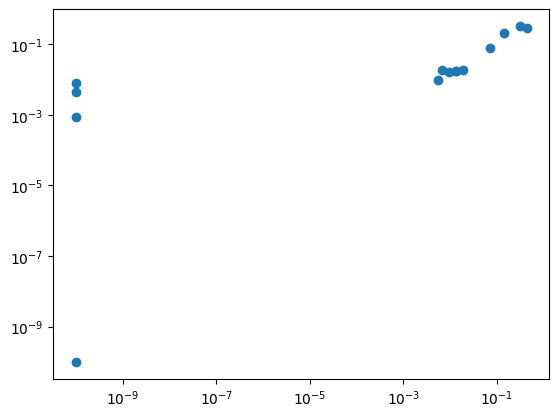

In [17]:
import matplotlib.pyplot as plt
dict1 = prob_dict
dict2 = prob_dict_kaggle
keys = list(dict1.keys())
x = np.array([float(dict1[k]) for k in keys])
y = np.array([float(dict2[k]) for k in keys])

fig,ax = plt.subplots()
ax.scatter(x,y)
ax.set_yscale('log')
ax.set_xscale('log')
ax.axline((0,0),slope=1,color='grey',dashes=(3,3))
plt.show()

In [16]:
import ast
import re
import pandas as pd




# Find every line that looks like a Python list
text = r"""
Found 5500 notebooks across 1 folders
Processing 0
FAILED: kaggle_notebooks\a763337092_blending-tensorflow-and-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\a7madmostafa_customer-churn-with-logistic-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakash2121995_new-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashjoshi123_data-science-salaries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashnain_is-it-better-than-2017.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashnain_let-s-check-what-the-survey-says.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaronds_us-traffic-accidents-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaronpumm_aml-projekt-artworks.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaryanmavaninew_hyperparameter-tuned-crop-yield-ml-based.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aarzookuhar_cardiovascular-disease-data-by-aarzoo-kuhar.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaybeedee_transfer-learning-for-text-data-in-pytorch-bert.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaysbt_titanic-datasets-eda-fe-dc-model-predictions.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aayushmishra1512_emotion-detector.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abaojiang_lmsys-detailed-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abaojiang_network-intrusion-detection-a-simple-ml-workflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abazdyrev_nn-w-o-skew.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abbas829_streamlit-cheat-sheet.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abbvieraiders_learning-risk-factors-as-a-topic-from-mesh.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\abdallahsaadelgendy_diabetes-prediction-eda-preprocessing-models.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\abdallahwagih_data-science-end-to-end-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdallahwagih_nlp-pipeline-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdalrahmanshahrour_a-z-handwritten-alphabets-accuracy-98-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdalrahmanshahrour_predict-smoking-status-accuracy-99-2-93-6.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdellahaitelouli_sentiment-analysis-using-tenerflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdelrahmanamer08_cyberattack-eda-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdelruhmanessam_wine-quality.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\abdmental01_bank-churn-lightgbm-and-catboost-0-8945.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abdmental01_delicious-delights-exploring-online-food.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdmental01_embark-on-titanic-a-beginner-s-journey-through-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdmental01_fork-improvements.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\abdmental01_gre-admissions-forecasting-success-with-data.ipynb
['norm_min_max']

===================
kaggle_notebooks\abdmental01_heart-disease-prediction-binary-classification.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\abdmental01_lgbm-cat-ensemble-isic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdmental01_multimodel-isic.ipynb
Notebook does not appear to be JSON: ''
Processing 50

===================
kaggle_notebooks\abdmental01_nlp-email-spam-detection-a-beginner-s-guide.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\abdmental01_ps4e6-eda-modeling-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdmental01_sparkle-forecast-predicting-diamond-prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdmental01_text-preprocessing-nlp-steps-to-process-text.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdmental01_unmasking-deception-innovations-in-credit-card.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdoashraf90_drug-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdoashraf90_helthcare-diabetes-with-acuracy-99-using-knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdoashraf90_plantvillage-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdoashraf90_price-of-airline-tickets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdrakhmanmurat_domestic-violence-in-colombia.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdullah0a_ensamble-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdullah182_spotify-churn-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdullahmeda_8th-lb-solution-ppl-gltr-features.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdullahmeda_enter-ing-the-timeseries-space-sec-3-new-aggs.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdulrahmanelbanna_predict-with-all-reg-models-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abdurrafae_improved-code-interpretation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abelwahabbahaa_bigmartsalesprediction-using-regressionmodels.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhashrai_customer-retention-analysis-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\abhaymudgal_intrusion-detection-system.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhayparashar31_best-numpy-functions-for-data-science-50.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhi011097_s3-e5-eda-multi-approach-models-w-o-smote.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhijitdahatonde_data-cleaning-pro-tips.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhijitsingh001_suicidal-thought-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhilash1910_nlp-workshop-playing-with-transformers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhinand05_covid-19-digging-a-bit-deeper.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhinand05_predicting-housingprices-simple-approach.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhinavsuri_anatomy-image-visualization-overview-rsna-raids.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhiroopbasak_videogames.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.


===================
kaggle_notebooks\abhishek0032_data-science-toolkit-codes-skills-to-succeed.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishek0032_exploring-regression-models-on-wine-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek0032_learn-classify-the-iris-dataset-adventure.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\abhishek0032_titanic-survival-prediction-feature-engineering.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishek14398_automatic-ticket-classification-case-study-nlp.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\abhishekmamidi_time-series-analysis-artificial-neural-networks.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishektripathy_beginner-machine-learning-linear-logistic-example.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_bert-base-uncased-using-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_competition-part-1-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_pytorch-inference-kernel-lazy-tta.ipynb
Notebook does not appear to be JSON: ''
Processing 100
FAILED: kaggle_notebooks\abhishek_roberta-inference-5-folds.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_two-longformers-are-better-than-1.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\abinanthank_crop-production-rice-and-wheat-abinanthan-k.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abusaideshohan_decision-theory-201736001-shohan.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adachowicz_house-prices-random-forest-regression-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adamml_my-spaceship-titanic-80-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adamml_titanic-to-beginner.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adamml_water-quality-with-acc-88.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adamschroeder_countvectorizer-tfidfvectorizer-predict-comments.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adarshsng_complexity-cleaning-f-engg-bi-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adarshsng_predicting-job-type-cat-using-job-description.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adarshvishwakarma12_hr-analytics-reducing-employee-turnover.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adaubas_2nd-place-solution-categorical-fe-callenge.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adavydenko_titanic-solution-a-beginner-s-guide-russian.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adelinmil_pg-s03e23-quick-and-dirty-implementation.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\adhamtarek147_alzheimer-s-disease-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\adhamtarek147_recurrence-of-thyroid-disease.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adhang_telco-customer-churn-prediction-complete-guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adilashrafi_simple-blood-cell-cancer-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adilshamim8_eda-on-data-science-salaries-2026.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adilshamim8_student-depression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adinishad_looking-for-a-job-as-data-analyst.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aditidutta_learning-more-about-the-kaggle-community.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\aditimulye_imdb-5000-movie-dataset-analysis.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\aditya1220_speech-emotion-recognition.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\adityaecdrid_initial-eda.ipynb
['norm_log']
FAILED: kaggle_notebooks\adityaecdrid_translate-them-to-tamil-language-external-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adityapaagare_indirailway.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adityarahul_fakenewsdetection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adityasheth_financial-distress-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adnanzaidi_basic-tutorial-exploratory-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\adrian1903_cleaning-users-features-engineering.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\adrianoavelar_bond-calculaltion-lb-0-82.ipynb
['norm_log']
FAILED: kaggle_notebooks\adrianoavelar_template-analisys-pt.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\adrienmorel97_eda-lightgbm-optuna-1-0644.ipynb
['bin_equal_width_10']
FAILED: kaggle_notebooks\adrienmorel97_predicting-depression-with-ensemble-learning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\advikmaniar_heart-attack-eda-prediction-with-9-model-95.ipynb
['IQR', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'IQR', 'norm_min_max']
Processing 150
FAILED: kaggle_notebooks\aerdem4_fast-basic-lstm-with-proper-k-fold-sentimentembed.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\aeryan_spotify-music-analysis.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\agentauers_incredible-tpus-finetune-effnetb0-b6-at-once.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\agewerc_corporate-credit-rating-forecasting.ipynb
['IQR', 'IQR']
FAILED: kaggle_notebooks\aggarwalrahul_nlp-speech-recognition-model-development.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_3rd-type1-2-3-1-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_3rd-type1-3-3-1-3.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\agileteam_3rd-type2-3-2-baseline.ipynb
['norm_min_max']

===================
kaggle_notebooks\agileteam_insurance-starter-tutorial.ipynb
['norm_log']
FAILED: kaggle_notebooks\agileteam_mock-exam-t2-baseline-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_mock-exam1-type1-1-tutorial.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\agileteam_py-t1-1-iqr-expected-questions.ipynb
['IQR']

===================
kaggle_notebooks\agileteam_py-t1-4-expected-questions.ipynb
['norm_log']

===================
kaggle_notebooks\agileteam_t1-23-drop-duplicates.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\agileteam_t1-25-str-slicing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-26-str-contains.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-27-str-contains-replace.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-28-value-counts-index.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-29-datetime-format.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-30-datetime-percent.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-31-melt.ipynb
Notebook does not appear to be JSON: ''
Processing 200
FAILED: kaggle_notebooks\agileteam_t1-33-melt2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-33-timedelta-py.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t1-34-pattern-py.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\agileteam_t2-3-adult-census-income-tutorial.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\agileteam_t2-exam-question-3rd-round.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t3-chi2-contingency-py.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t3-correlation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t3-logit-py.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t3-probability-py.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t3-scl-py.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t3-ttest-anova-py.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\agileteam_t3-two-way-anova-py.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\agileteam_tutorial-t1-python.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\agileteam_wine-quality-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\agodwinp_stacking-house-prices-walkthrough-to-top-5.ipynb
['bin_equal_width_10', 'norm_log']
FAILED: kaggle_notebooks\aharless_rgf-or-xgb-k-fold-with-log-odds-averaging.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmadfadliramadhan_k-means-pada-kecepatan-internet-di-indonesia.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmadihossein_ecoopt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmadihossein_passive-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmadjaved097_classifying-heart-disease-patients.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmadpk_diabetic-visualization-with-predictions.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmadpk_eda-on-box-office-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmadpk_quick-guide-in-cross-validation.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ahmdayman_retail-sales-dataset.ipynb
['IQR']
FAILED: kaggle_notebooks\ahmedabbas757_coffee-shop-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedabdulhamid_4-data-transformation-using-pandas-python-for-da.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedashrafahmed_alzheimers-dataset-4-class-adni-using-cnn-99-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedashrafahmed_bone-fracture-classification-using-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedashrafahmed_lab-importing-datasets-laptop-pricing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedezzatibrahem_student-performance-factors.ipynb
Notebook does not appear to be JSON: ''
Processing 250
FAILED: kaggle_notebooks\ahmedgaitani_rohlik-orders-forecasting-code.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedgaitani_titanic-code.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedgaitani_top-3-advanced-house-prices-with-gboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedhanymetawaa_most-commonly-used-functions-in-ml-projects.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedhanymetawaa_textual-taming-a-practical-guide-to-nlp-basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedraafat666_credit-card-fraud-detection-model.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ahmedterry_restaurants-sales-during-covid-eda.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\ahmedterry_stroke-prediction-eda-classification-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedtronic_ann-breast-cancer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedtronic_company-bankruptcy-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedtronic_fake-news-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmedxmahmoud_phishing-url-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmetcalis_car-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ahmetcankaraolan_churn-prediction-using-machine-learning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ahmetcankaraolan_diabetes-prediction-using-machine-learning.ipynb
['IQR', 'IQR']
FAILED: kaggle_notebooks\ahsanulislam_hello-data-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aikhmelnytskyy_quick-start-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aimind_bottleneck-encoder-mlp-keras-tuner-8601c5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ainslie_credit-card-default-prediction-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aishwarya2210_prediction-of-sales-using-xgboost.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\aiswaryaramachandran_english-to-hindi-neural-machine-translation.ipynb
['drop_duplicates']

===================
kaggle_notebooks\aitude_ashrae-kfold-lightgbm-without-leak-1-08.ipynb
['norm_log']
FAILED: kaggle_notebooks\akadoc23_data-analysis-thedress.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akadoc23_nn-classifier-on-breast-cancer-wisconsin.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akarsh1_step-by-step-analysis-of-disaster-tweets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akarshvyas_notebook9fdd2dc0b8.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\akashkotal_heart-disease-eda-with-7-machine-learning-model.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\akashkotal_titanic-various-machine-learning-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akashsdas_abstractive-text-summarization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akdagmelih_five-personality-clusters-k-means.ipynb
Notebook does not appear to be JSON: ''
Processing 300
FAILED: kaggle_notebooks\akhiljethwa_playground-s4e2-eda-modeling-91-0.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akshat0007_cardiotocology.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akshathmangudi_importance-of-data-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akshayasrinivasan2_drought-prediction-using-ml-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akshitmadan_australia-rain-prediction-4-ml-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\akshitmadan_student-data-prediction-using-logistic-regression.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\akshitmadan_zomato-data-set-analysis-visualization.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\akshpreetsingh_gendervoicerecognition.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\alaasedeeq_house-price-prediction-top-8.ipynb
['norm_log']
FAILED: kaggle_notebooks\alaasedeeq_object-oriented-programming-for-data-science.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alaasedeeq_predicting-the-survival-of-titanic-top-6.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alandata666_automl-l-lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alankritamishra_covid-19-tweet-sentiment-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alayudaishimpee_multilayer-perceptron-from-scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aleaiest_lb-0-945-qwen2-5-32b-gptq.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alejandrolopezrincon_extra-data-with-fs-starting-point.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alejopaullier_nesp-eda-xgboost-baseline-0-025.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aleksandrmorozov123_h-m-personalized-fashion-recommendations.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aleksandrmorozov123_machine-learning-excercises.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexanderguentert_falldetection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexanderlazarev_simple-keras-1d-cnn-features-split.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexanderlundervold_simple-gradio-kaggle-example.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexandershumilin_ps-s3-e4-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexandershumilin_ps-s3-e7-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexandershumilin_ps-s3-e9-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexandervc_op2-models-cv-tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexandrelemercier_all-best-tabular-classifiers-comparative-study.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexandrelemercier_quantized-autoencoder-qae-ids-for-iot-devices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexandrpanarin_titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexcherniuk_imdb-review-word2vec-bilstm-99-acc.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\alexioslyon_lgbm-baseline.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\alexisbcook_bar-charts-and-heatmaps.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexisbcook_character-encodings.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexisbcook_choosing-plot-types-and-custom-styles.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexisbcook_distributions.ipynb
Notebook does not appear to be JSON: ''
Processing 350
FAILED: kaggle_notebooks\alexisbcook_inconsistent-data-entry.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexisbcook_parsing-dates.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexisbcook_scaling-and-normalization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexisbcook_scatter-plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexisbcook_your-first-map.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexklibisz_songs-csv-quote-errors-cause-513-missing-songs.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alexteboul_diabetes-health-indicators-dataset-notebook.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\alfathterry_customer-churn-analysis.ipynb
['IQR', 'norm_min_max']

===================
kaggle_notebooks\alfathterry_house-price-prediction.ipynb
['IQR', 'norm_min_max', 'IQR', 'norm_min_max']
FAILED: kaggle_notebooks\alfathterry_telco-customer-churn-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aliaformo_house-sales-analysis.ipynb
Notebook does not appear to be JSON: ''
Processing 400
FAILED: kaggle_notebooks\alicanpayasli_94-accuracy-score-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alijs1_arc-prize-2024-solution-3rd-place-score-40.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alirezaai_mobile-pricing.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\alirezahasannejad_data-preprocessing-in-machine-learning.ipynb
['norm_min_max']

===================
kaggle_notebooks\alizgrdede_global-information.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\alizgrdede_gold-price.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alizgrdede_horse-health-playground-series-3-22.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alizgrdede_store-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alkanerturan_speakerrecognition.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\alkidiarete_apple-quality-roc-0-97.ipynb
['IQR', 'norm_min_max']
FAILED: kaggle_notebooks\alkidiarete_heartattack-accuracy-92.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\allegich_arc-2024-starter-notebook-eda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\allunia_hidden-treasures-in-our-groceries.ipynb
['norm_min_max', 'IQR', 'IQR']

===================
kaggle_notebooks\allunia_m5-sales-uncertainty-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\allunia_patterns-of-colorectal-cancer-wally.ipynb
Notebook does not appear to be JSON: ''

<unknown>:6: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.


===================
kaggle_notebooks\allunia_santander-customer-transaction-eda.ipynb
['bin_equal_frequency_10']
FAILED: kaggle_notebooks\allunia_shaking-earth.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alnourabdalrahman9_prediction-of-obesity-risk.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alperkaraca1_androml-ml-based-android-apk-file-analyzer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alperkaraca1_deep-fake-voice-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alphiree_cvds-risk-prediction-notebook-full.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\altafk_pakistani-traffic-sentiment-analysis-with-nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alvinai9603_predict-next-point-with-the-imu-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alvinbimo_curah-hujan-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alwannabilhanif_prediksi-biaya-asuransi-kesehatan.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\amalyasser_shhh-i-want-to-sleep.ipynb
['bin_equal_width_2']
FAILED: kaggle_notebooks\aman2000jaiswal_vggmodel-for-agriculture-crop-image-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\aman9d_data-science-london-scikit.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\amanchoudhary86_diabetes-prediction-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amanrosekaursethi_crop-analysis-clustering-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amarpreetsingh_stock-prediction-lstm-using-keras.ipynb
Notebook does not appear to be JSON: ''
Processing 450
FAILED: kaggle_notebooks\ambrosm_msci-citeseq-keras-quickstart.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ambrosm_pss3e11-zoo-of-models.ipynb
['norm_log', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\ambrosm_pss3e23-eda-which-makes-sense.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ambrosm_pss4e4-eda-which-makes-sense.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\ambrosm_pss4e8-eda-which-makes-sense.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ambrosm_tpsapr22-best-model-without-nn.ipynb
['IQR']

===================
kaggle_notebooks\ambrosm_tpsaug22-eda-which-makes-sense.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\ambrosm_tpsfeb22-01-eda-which-makes-sense.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ambrosm_tpsmay22-gradient-boosting-quickstart.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amelinvladislav_map-of-temperatures-and-analysis-of-global-warming.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\amerhu_rfm-customer-segmentation.ipynb
['IQR', 'IQR']

===================
kaggle_notebooks\amerwafiy_titanic-competition-journey-to-100-accuracy.ipynb
['drop_duplicates', 'drop_duplicates']

<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:23: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:24: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\aminejallouli_genre-classification-based-on-wiki-movies-plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amirhosseinmirzaie_bank-loan-offer-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amirhosseinmirzaie_pistachio-types-prediction-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amirmotefaker_supply-chain-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\amirrezaeian_time-series-data-analysis-using-lstm-tutorial.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\amisha0528_crime-rate-prediction-and-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amitabhac_rl-nlp-first-attempt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amitazadi_emotion-detection-from-speech-using-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amlanmohanty1_build-web-app-for-heart-disease-with-streamlit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ammar111_youtube-trending-videos-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ammarnassanalhajali_cnn-with-keras-stater.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ammarnassanalhajali_riiid-lgbm-bagging2-sakt-0-781.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\amrabdelatyfathalla_e-commerce-customer-churn-end-to-end-ml-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amritachatterjee09_eda-bank-loan-default-risk-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\amrut11_multiple-linear-regression-on-50-startups-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\analystoleksandra_marketing-analytics-customer-segmentation.ipynb
['IQR']
FAILED: kaggle_notebooks\analyticaobscura_1st-place-binary-smoke-detector.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\analyticaobscura_mabe-v1-mouse-action-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\analyticaobscura_optimal-fertilizers-eda-playground-0-38265.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\analyticaobscura_s5e11-loan-payback-xgb-lgbm-ann.ipynb
['IQR', 'bin_equal_width_10', 'bin_equal_width_10', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\analyticaobscura_what-is-automl.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anandaramg_f1-champ-eda-classification-100-accuracy.ipynb
Notebook does not appear to be JSON: ''
Processing 500

===================
kaggle_notebooks\ananthr1_parkinson-disease-detection-using-xgbooster.ipynb
['norm_min_max']

===================
kaggle_notebooks\anaskad_step-by-step-solving-titanic-problem.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\anastasiyaigonina_diabetes-eda-hypothesis-testing-predictions.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anatpeled_spotify-popularity-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anbarivan_indian-air-quality-analysis-prediction-using-ml.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\anbarivan_indian-rainfall-analysis-and-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\andradaolteanu_freezingofgate-xgboost-multiclass-with-rapids.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andradaolteanu_g2net-searching-the-sky-pytorch-effnet-w-meta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andradaolteanu_how-i-taught-myself-deep-learning-vanilla-nns.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andradaolteanu_pulmonary-fibrosis-competition-eda-dicom-prep.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andradaolteanu_wids-datathon-rapids-ensembles-w-b.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andreasbis_aimo-3-gpt-oss-120b-with-tools.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\andreipaulavets_titanic-prediction-0-794-score.ipynb
['norm_log']
FAILED: kaggle_notebooks\andreispurim_challenge-data-science-andreis-e-eduarda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andreispurim_workshop-respostas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andresboteroumng_conceptos-basicos-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andreshg_churn-prediction-0-99-auc-h2o-sklearn-smote.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andreshg_eda-beginner-to-expert-plotly.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\andreshg_timeseries-analysis-a-complete-guide.ipynb
['norm_log', 'norm_min_max']

<unknown>:6: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:31: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:35: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:39: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\+" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\+"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\+" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\+"? A raw string is also an option.
<unknown>:13: SyntaxWarning: "\+" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\+"? A raw string is also an option.

FAILED: kaggle_notebooks\andreshg_tps-apr-data-visualization-and-highlights.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andreshg_tps-march-a-complete-study.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andresionek_geospatial-analysis-of-brazilian-e-commerce.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andrevitoria_natural-language-processing-with-disaster-tweets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andrewmvd_divorce-prediction-with-rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andrewmvd_enriched-lightgbm-pr-86-auc-92-68.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\andydollin21_seaborn-en-espa-ol-ipynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anezka_cnn-with-keras-for-humpback-whale-id.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\angadp_simple-cnn-to-predict-digits.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\angqx95_data-science-workflow-top-2-with-tuning.ipynb
['norm_log']
Processing 550
FAILED: kaggle_notebooks\aninditapani_will-it-rain-tomorrow.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\anirbank_callcenteroptimization.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\anirbank_covid19-timeseries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anirudhlakhotia5_starter-notebook-from-the-tas-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anisayari_your-1st-data-science-project-simple-explanation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anishsamantaray_pancreatic-cancer-disease-detection-87-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anjanatiha_sentiment-analysis-with-lstm-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ankitverma2010_e-commercecustomerchurn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anlgrbz_data-cleaning-feature-generation-eda-segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anmolbajpai_student-mental-analysis-eda-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anmoltripathi_what-s-cooking-top-7-solution.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\annastasy_brazilian-e-commerce-eda-nlp-ml.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\annastasy_diabetes-prediction-simple-to-advanced.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\annastasy_mental-health-eda-ensemble.ipynb
['bin_equal_width_10', 'bin_equal_width_10', 'isolationForest']

===================
kaggle_notebooks\annastasy_predicting-students-grades.ipynb
['zscore']
FAILED: kaggle_notebooks\annastasy_pregnancy-risks-eda-modeling-hypothesis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\annastasy_ps4e7-xgboost-in-insurance-eda-visuals.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\annastasy_ps4e8-data-cleaning-and-eda-of-mushrooms.ipynb
['drop_duplicates', 'zscore', 'isolationForest']
FAILED: kaggle_notebooks\annastasy_sales-forecasting-fighting-data-leakage.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\annielylemos_classificador-anemia.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anokas_data-exploration-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anshigupta01_diabetes-prediction-eda-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anshigupta01_heart-disease-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anshigupta01_titanic-prediction-top-17.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\anshtanwar_credit-risk-prediction-training-and-eda.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\anshulrai_cudnnlstm-implementation-93-7-accuracy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\anshulranjan2004_worksheet-3b-student-copy.ipynb
['norm_min_max']

===================
kaggle_notebooks\anshuls235_covid19-explained-through-visualizations.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\anshuls235_siim-isic-melanoma-analysis-eda-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anubhavgoyal10_customer-churn-prediction-eda-ann.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\anubhavgoyal10_laptop-price-prediction.ipynb
['drop_duplicates', 'IQR']
FAILED: kaggle_notebooks\anubhavgoyal10_students-exam-performance-eda-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anubhavgoyal10_titanic-survival-prediction-top-10.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anuragraj03_automated-resume-job-categorization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\anuragraj03_titanic-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aohorodnyk_pandas-sql-restart-kernel.ipynb
Notebook does not appear to be JSON: ''
Processing 600
FAILED: kaggle_notebooks\apalladi_top-10-with-simple-eda-votingclassifier.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\apapiu_regularized-linear-models.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\ar2017_basics-of-feature-selection-with-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ar89dsl_predicting-building-damage-from-earthquakes.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aradhanapratap_consumer-buying-behavior-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arashnic_an-overview-of-categorical-encoding-methods.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ardapr_unlocking-the-voice-of-customer-with-gemini-1-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ardava_klasifikasi-jenis-cuaca-92-accuracy-score.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aremoto_retail-sales-forecast.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arezalo_bank-personal-loan-modeling.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\arezalo_customer-behaviour-prediction-naive-bayes.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arezalo_ml-studytime-10-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arezalo_ml-studytime-7-handling-missing-values.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arezoodahesh_customer-churn-with-oversampling-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arezoodahesh_heart-failure-prediction-with-ensemble-models.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arezoodahesh_home-credit-default-risk-part02-boosting-models.ipynb
['IQR', 'norm_min_max']

===================
kaggle_notebooks\aritrag_kerascv-starter-notebook-train.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\arjunayyangar_asteroidanalysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arjunjoshua_predicting-fraud-in-financial-payment-services.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\arjunsurendran_using-lstm-on-training-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\armandsauzay_sklearn-all-you-need-to-know.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arnavr10880_acoustic-ext-fire-eda-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arootda_the-basic-process-of-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arootda_titanic-eda-modeling-for-beginners-top3.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\artgor_eda-feature-engineering-and-model-interpretation.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\artgor_eda-on-basic-data-and-lgb-in-progress.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\artgor_even-more-features.ipynb
Notebook does not appear to be JSON: ''
Processing 650
FAILED: kaggle_notebooks\artgor_it-is-time-for-m5-going-step-by-step.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\artgor_march-madness-2020-ncaam-eda-and-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\artgor_oop-approach-to-fe-and-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\artgor_santander-eda-fe-fs-and-models.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\artgor_segmentation-in-pytorch-using-convenient-tools.ipynb
['drop_duplicates']

===================
kaggle_notebooks\artgor_where-do-the-robots-drive.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\arthurdoamaral_mlp-2-bim.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arthurlu_exploratory-tutorial-titanic.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arthurtok_feature-ranking-rfe-random-forest-linear-models.ipynb
['norm_min_max']

===================
kaggle_notebooks\arthurtok_introduction-to-ensembling-stacking-in-python.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\arthurtok_the-console-wars-ps-vs-xbox-vs-wii.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunjangir245_google-playstore-apps-rating-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunjangir245_titanic-machine-learning-decisiontreeclassifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunjangir245_titanic-machine-learning-logistic-regression.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arunklenin_advanced-feature-engg-techniques-beyond-basics.ipynb
['norm_min_max', 'norm_min_max', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\arunklenin_in-depth-analysis-five-anomaly-detection-methods.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunklenin_ps3e14-blueberry-yield-prediction-challenge.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arunklenin_ps3e15-iterative-catboost-imputer-ensemble.ipynb
['norm_min_max', 'norm_log', 'norm_log']

===================
kaggle_notebooks\arunklenin_ps3e16-eda-feature-engineering-ensemble.ipynb
['norm_min_max', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'drop_duplicates']
FAILED: kaggle_notebooks\arunklenin_ps3e20-co2-emissions-prediction-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunklenin_ps3e23-eda-feature-engineering-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arunklenin_ps3e24-smoking-cessation-prediction-binary.ipynb
['norm_min_max', 'norm_min_max', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\arunklenin_ps3e25-material-hardness-prediction-with-ml.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arunklenin_ps3e26-cirrhosis-survial-prediction-multiclass.ipynb
['norm_min_max', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\arunklenin_ps4e01-text-transformations-pca-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arunklenin_ps4e1-advanced-feature-engineering-ensemble.ipynb
['norm_min_max', 'norm_min_max', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\arunklenin_ps4e11-mental-health-prediction-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arunklenin_ps4e3-steel-plate-fault-prediction-multilabel.ipynb
['norm_min_max']
Processing 700

<unknown>:37: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: invalid decimal literal


===================
kaggle_notebooks\arunklenin_ps4e4-abalone-age-prediction-regression.ipynb
['norm_min_max', 'norm_min_max', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'isolationForest']
FAILED: kaggle_notebooks\arunklenin_ps4e6-academic-success-classification-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunklenin_ps4e8-binary-class-mathews-correlation-coeff.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\arunklenin_ps5e3-rainfall-prediction-classification.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\arunklenin_space-titanic-eda-advanced-feature-engineering.ipynb
['norm_min_max', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\arunklenin_wids-datathon-2-metastatic-cancer-diagnosis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunkumar1809_youtube-comments-sentiment-analyser.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunmohan003_pruning-decision-trees-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arunmohan003_transformer-from-scratch-using-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\arwameissa_different-techniques-to-handle-large-csv-files.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aryantiwari123_breast-cancer-eda-and-prediction-98.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aryantiwari123_handwriting-recognition-deep-learning-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aryantiwari123_hotel-booking-eda-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aryantiwari123_nlp-sms-spam-detection-text-processing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aryashah2k_emergency-vehicle-siren-sound-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\asadfarooqi_birthday-wisher-32.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\asarvazyan_imc-understanding-the-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ash316_learn-pandas-with-pokemons.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ash316_let-s-play-cricket.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\ashfakyeafi_random-forest-with-water-quality.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashishkumarak_credit-card-fraud-detection-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashishkumarak_heart-stroke-prediction-by-nn-model-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashishpatel26_dask-why-every-data-scientist-should-use-dask.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashishpatel26_ensemble-learning-for-beginner-to-advance.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashishpatel26_vowpal-wabbit-best-text-classification-fe.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashishsingh226_text-summarization-with-transformers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashokkumarbibbab_birds-classification-in-rfc-model-accuracy-87.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ashydv_bank-customer-clustering-k-modes-clustering.ipynb
Notebook does not appear to be JSON: ''
Processing 750

===================
kaggle_notebooks\ashydv_housing-price-prediction-linear-regression.ipynb
['IQR', 'IQR', 'norm_min_max']

<unknown>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: kaggle_notebooks\asimzahid_robot-positioning-and-control-hackathon.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\asindico_customer-segments-with-pca.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aspillai_bank-churn-dataset-classification-lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aspillai_obesity-risk-lgb-xgb-cat-92.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aspillai_obesity-risk-prediction-xgboost-91-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\assetn_resume-dataset-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aswinjose_incremental-learning-for-multiclass-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\atamakhdoom_predict-pakistan-election-2018.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\atasaygin_mushroom-classification-and-eda-rf-svm-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\athoul01_predicting-yelp-ratings-from-review-text.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\atifaliak_tip-prediction-on-tips-dataset-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\atishadhikari_fake-news-cleaning-word2vec-lstm-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\atishadhikari_placement-dataanalysis-classification-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aviadl_starter-chest-x-ray-images-pneumonia-d498de7c-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\avijitduttta_xgboost-try2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\avikumart_classif-hr-why-do-employees-join-the-company.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\avikumart_timeseries-stock-price-analysis-forecasting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\avinashvyas_nokia-bell-labs-task-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\avk256_nsl-kdd-anomaly-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\avrahamcalev_time-series-models-pamap2-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awsaf49_aimo-kerasnlp-starter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awsaf49_detect-fake-text-kerasnlp-tf-torch-jax-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awsaf49_great-barrier-reef-yolov5-infer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awsaf49_uwmgi-2-5d-infer-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awsaf49_uwmgi-unet-infer-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awsaf49_uwmgi-unet-train-pytorch.ipynb
Notebook does not appear to be JSON: ''
Processing 800
FAILED: kaggle_notebooks\awsaf49_vinbigdata-cxr-ad-yolov5-14-class-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awsaf49_xgboost-tabular-data-ml-cv-85-lb-787.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awwalmalhi_extreme-fine-tuning-lgbm-using-7-step-training.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\awwalmalhi_titanic-eda-and-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ayaberour_e-commerce-product-recommendation-using-amazon-rev.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aymanlafaz_titanic-feature-engineering-and-random-forests.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aymenmouffok_non-alcoholic-fatty-liver-disease-92-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ayucha_s4e10-loan-approval-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ayucha_s4e11-exploring-mental-health-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ayucha_s4e12-the-insurance-game-red-light-green-light.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ayushchandramaurya_banana-quality-eda-and-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ayushnitb_basic-lgbm-based-forecast.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ayushnitb_cc-fraud-detection-indeptheda-multimod-hyperopt.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\azizozmen_customer-segmentation-cohort-rfm-analysis-k-means.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\azizozmen_heart-failure-predict-8-classification-techniques.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\azizozmen_telco-churn-detailed-eda-8-classification-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\azminetoushikwasi_classification-comparing-different-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\azminetoushikwasi_divorce-reasons-machine-interpretation-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\azunre_ghananlp-abena-usage-demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\b08502105_ml2023spring-hw1-samplecode.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bachrr_detecting-covid-19-in-x-ray-images-with-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\backpaker_rid-catboost-nonlog-as-feature.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bacsmpc_kernel2f7ecc6491.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\baktisiregar_klasifikasi-supervised-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\baktisiregar_regression-complete-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\balavashan_weather-prediction-ensemble-methods.ipynb
['IQR']

===================
kaggle_notebooks\bandiatindra_telecom-churn-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\bannourchaker_credit-top5-solution-evaluation-all.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bansodesandeep_cardiovascular-risk-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bansodesandeep_loan-default-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bansodesandeep_multilabel-classification-cnn-dnn-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\barankutluay_titanic-submission.ipynb
Notebook does not appear to be JSON: ''
Processing 850
FAILED: kaggle_notebooks\barelydedicated_intro-to-keras-sklearn-for-detecting-bank-exits.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\basicgo_bayes-classifier-0-37990.ipynb
Notebook does not appear to be JSON: ''

<unknown>:31: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:32: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:34: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

FAILED: kaggle_notebooks\batprem_godaddy-mixing-technique.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\batprem_llm-daigt-analyse-edge-cases.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\baturalpsert_covid19-xgboost-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bayomars12_starter-heart-disease-dataset-408f5662-7.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bbergerud_bayesian-a-b-testing-fast-food-marketing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bbergerud_bayesian-prophet-forecasting-airline-passengers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\beckpro_lightgbm-fold-voting-baseline-lb-0-408.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\beckpro_previous-2022-xgboost-solution-simple-submission.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\beezus666_ensemble-weighted-average.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\benfraser_regression-with-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bennyfung_easy-to-use-automl-autogluon-flaml-autosklearn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bennyfung_heart-failure-ensemble-by-voting-auc-85.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bennyfung_model-interpretability-xgboost-shap.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bennyfung_titanic-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\benroshan_bank-marketing-campaign-predictive-analytics.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\benroshan_you-re-hired-analysis-on-campus-recruitment-data.ipynb
['IQR']
Processing 900
FAILED: kaggle_notebooks\berkereryilmaz_rainfall-prediction-0-90-with-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\berkinkaplanolu_banking-analyze.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\bertcarremans_data-preparation-exploration.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\bertcarremans_deep-learning-for-sentiment-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\bestpredict_location-eda-8eb410.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\bextuychiev_20-burning-xgboost-faqs-answered-to-use-like-a-pro.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bextuychiev_25-pandas-functions-you-didn-t-know-existed.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bextuychiev_lasso-regression-with-pipelines-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bextuychiev_write-powerful-code-w-custom-sklearn-transformers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\beyzanks_stellar-classification-98-4-acc-100-auc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\beyzanks_waste-classification-with-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bguberfain_a-simple-model-using-the-market-and-news-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bhaktipradhan_batch-8-exploratory-data-analysis-tutorial.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\bhaktipradhan_exploratory-data-analysis-tutorial.ipynb
['IQR', 'norm_log']

===================
kaggle_notebooks\bhanupratapbiswas_arc-prize-2024-01.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\bhanupratapbiswas_speech-emotion-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bharath25_hypothesis-testing-and-predictive-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bharathraja_statistical-approach-for-predicting-imdb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bhartiprasad17_student-academic-performance-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\bhatnagardaksh_gradient-descent-from-scratch.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\bhatnagardaksh_pca-and-lda-implementation.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\bhatnagardaksh_stock-predictions-with-backtesting-arima-and-gru.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bhaveshjain1612_machine-failure-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bhavikardeshna_catboost-gradient-boosting-ensemble-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bhavikjikadara_student-performance-linear-regression-100.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bhuvanchennoju_women-and-cancer-analysis-and-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bibanh_lb-0-72-resnet34-melspectrogram-stage-1-training.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bibanh_lb-0-944-the-art-of-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bibanh_lb-0-947-the-art-of-ensemble-v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bibanh_simple-submission-classification-99-training.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\bibanh_update-57-4-train-inference-randomforest.ipynb
['norm_min_max', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\bibek777_light-check.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bijucyborg_day-1-30-days-of-kaggle.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\billiardo_pandas-exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\billiardo_pemodelan-beasiswa.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\blackblitz_gaussian-naive-bayes.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\blamerx_s6e3-ridge-xgb-n-gram-0-91927-cv.ipynb
Notebook does not appear to be JSON: ''
Processing 950
FAILED: kaggle_notebooks\blehyaric_how-to-boostrap-a-covid-19-semantic-search-engine.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\blighpark_t2-4-house-prices-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\blitzapurv_speech-emotion-recognition-using-lstm.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\blurredmachine_titanic-survival-a-complete-guide-for-beginners.ipynb
['bin_equal_width_5']

===================
kaggle_notebooks\bminixhofer_5th-place-solution-code.ipynb
['norm_log', 'norm_log']

===================
kaggle_notebooks\bminixhofer_aggregated-features-lightgbm.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\bminixhofer_simple-lstm-pytorch-version.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\bobber_gpu-rapids-xgb-lgb-cat-nnbase-autoencoder.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_min_max', 'norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\boliu0_monai-3d-cnn-inference.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\boss0ayush_extensive-eda-plus-top2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\botmandieng_beromasr-v2.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\braquino_convert-to-regression.ipynb
['norm_min_max', 'norm_min_max']

<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:25: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:77: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<unknown>:19: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

FAILED: kaggle_notebooks\bromotdi_spam-email-detector.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_crowd-detection-prediction-all-process.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_emotional-speech-recognition-audio-process-all.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_heart-attack-prediction-detailed-explanation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_heartbeat-sounds-classification-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_land-use-scene-classification-all-process.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_parkinson-prediction-by-hand-drawing-dl-ml-process.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_personality-prediction-with-handwriting-end-to-end.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brsdincer_satellite-road-extraction-auto-encoder-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\brunovinicius154_predicting-the-delay-of-flights-auc-0-88.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\bryanb_stock-prices-forecasting-with-lstm.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\btangak_m15-prediction-01.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\btangak_m15-prediction-final-version.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\bulentsiyah_classifying-dna-sequences-markov-models-knn-svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\burakergene_diamonds-eda-comparing-all-ml-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\burakergene_titanic-eda-comparing-all-ml-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\burakkahveci_diabetic-patients-classification-with-ml-model.ipynb
Notebook does not appear to be JSON: ''
Processing 1000
FAILED: kaggle_notebooks\byeongsunlight_student-alcohol-consumption-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\byungeunhwang_added-comments-to-the-highest-scoring-public-codes.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\caesarlupum_ashrae-start-here-a-gentle-introduction.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\caesarlupum_modeling-give-me-some-credit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\caesarmario_clustering-for-effective-marketing-strategy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\caesarmario_data-to-destiny-titanic-survival-prediction.ipynb
['bin_equal_frequency_5']

<unknown>:9: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.


===================
kaggle_notebooks\caesarmario_loan-prediction-w-various-ml-models.ipynb
['IQR', 'norm_min_max']

===================
kaggle_notebooks\caesarmario_python-magic-big-mart-sales-data-transformed.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\calebreigada_clustering-dbscan-customer-response-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\calumwilsonsipbs_05a-limiting-data-to-ec-ion-channels.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\calumwilsonsipbs_05b-limiting-data-to-ec-gpcrs.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\calumwilsonsipbs_2-tabula-muris-loading-smart-seq-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\canozensoy_ps-s5e7-personality-classification-with-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\carlkirstein_clustering-methods-for-the-wine-data-set.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\carlkirstein_predictive-maintenance-milling-machine-98-6.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\carlkirstein_unsw-nb15-modelling-97-7.ipynb
['norm_log', 'norm_log']

===================
kaggle_notebooks\carlmcbrideellis_jane-street-eda-of-day-0-and-feature-importance.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\carlmcbrideellis_lstm-time-series-stock-price-prediction-fail.ipynb
Notebook does not appear to be JSON: ''

<unknown>:7: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.

FAILED: kaggle_notebooks\carmensirena_palmer-penguins-dataset-visualizacao-e-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\casper6290_car-purchase-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\casper6290_lung-cancer-prediction-98.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\cchangyyy_lb-0-482-beginner-friendly-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdabakoglu_time-series-forecasting-arima-lstm-prophet.ipynb
Notebook does not appear to be JSON: ''
Processing 1050
FAILED: kaggle_notebooks\cdeotte_chatgpt-vibe-coding-3xgpu-models-cv-0-9178.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\cdeotte_deberta-starter-cv-0-930.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\cdeotte_efficientnetb0-starter-lb-0-43.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\cdeotte_ettin-encoder-1b-cv-0-943.ipynb
['drop_duplicates']

===================
kaggle_notebooks\cdeotte_first-place-single-model-cv-1-016-lb-1-016.ipynb
['norm_log']

===================
kaggle_notebooks\cdeotte_gemma2-9b-it-cv-0-945.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\cdeotte_gnn-starter-cv-0-9155-with-hill-climbing-demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdeotte_keras-unet-with-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdeotte_lstm-feature-importance.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\cdeotte_modernbert-large-cv-0-938.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\cdeotte_pseudo-labeling-qda-0-969.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdeotte_pytorch-bigbird-ner-cv-0-615.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdeotte_rapids-knn-30-seconds-0-938.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdeotte_recommend-items-purchased-together-0-021.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\cdeotte_tensorflow-gru-starter-0-790.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\cdeotte_tensorflow-longformer-ner-cv-0-633.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdeotte_tensorflow-roberta-0-705.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cdeotte_triple-stratified-kfold-with-tfrecords.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\cdeotte_xgboost-5000-mutations-200-pdb-files-lb-0-410.ipynb
['drop_duplicates']

===================
kaggle_notebooks\cdeotte_xgboost-starter-0-793.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\ceyhunmamedzade_tweeter-me.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cf020031308_23-flags-w-o-the-big-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chadalee_olympics-data-cleaning-exploration-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chahinovic_zindi-geoai-eda-pre.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\challenge1a3_convert-to-regression.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\chamathsajeewa_text-classification-basics.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\chanakyavivekkapoor_house-price-prediction.ipynb
['norm_log']
FAILED: kaggle_notebooks\chanchal24_credit-card-fraud-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\chanchal24_diabetes-dataset-eda-prediction-with-7-models.ipynb
['IQR', 'IQR']
FAILED: kaggle_notebooks\chanchal24_emotion-dataset-acc-0-90.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chanchal24_heart-disease-eda-prediction-7-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chanchal24_liver-disease-prediction-using-7-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chanchal24_twitter-and-reddit-sentimental-analysis-dataset.ipynb
Notebook does not appear to be JSON: ''
Processing 1100
FAILED: kaggle_notebooks\chandrimad31_climate-risk-identifying-major-earthquake-regions.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chandrimad31_flight-passenger-satisfaction-eda-and-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\chandrimad31_rainfall-prediction-7-popular-models.ipynb
['IQR']
FAILED: kaggle_notebooks\chandrug_symptoms-based-disease-prediction-accuracy-99.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\changyeop_how-to-fine-tune-gpt-2-for-beginners.ipynb
Notebook does not appear to be JSON: ''

<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:22: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


===================
kaggle_notebooks\chapagain_titanic-solution-a-beginner-s-guide.ipynb
['bin_equal_width_5']

===================
kaggle_notebooks\charel_learn-by-example-rnn-lstm-gru-time-series.ipynb
['norm_min_max']

===================
kaggle_notebooks\cheesu_house-prices-1st-approach-to-data-science-process.ipynb
['norm_log']
FAILED: kaggle_notebooks\chekoduadarsh_starters-guide-convolutional-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chelseabrk_fake-news-detection-detailed-explanations.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chenguangyang_2016-us-presidential-social-media.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\chinmayadatt_obesity-risk-prediction-multi-class-0-92160.ipynb
['drop_duplicates']

===================
kaggle_notebooks\chirag9073_airbnb-analysis-visualization-and-prediction.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\chirag9073_hr-analysis-prediction-and-visualisation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chiranjeevbit_movie-review-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chitrakshsingh_cic-ddos2019-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chittalpatel_wind-turbine-power-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chitwanmanchanda_fake-news-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chityeaung_brain-tumor-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\chleungpolyu_descriptive-statistics-answer.ipynb
['zscore', 'zscore', 'zscore']

===================
kaggle_notebooks\chleungpolyu_mm3425-descriptive-statistics.ipynb
['zscore']
FAILED: kaggle_notebooks\chocojh_starter-credit-card-fraud-detection-249b5984-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chocozzz_beginner-challenge-house-prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chocozzz_lightgbm-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chocozzz_santander-lightgbm-baseline-lb-0-899.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\chongzhenjie_ecuador-store-sales-global-forecasting-lightgbm.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\chrisbutch_nju-cheminformatics-and-modelling-class-10-2.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ChristianDenich_quantile-reg-lr-schedulers-checkpoints.ipynb
['drop_duplicates', 'drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\christophries_statwr-01-cars-on-e-bay-ries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chuanguy_titanic-data-processing-with-python-0-813.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chumajin_easy-to-understand-the-competition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\chumarshahzad_mobile-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cirtan_how-can-we-predict-the-sentiment-by-tweets.ipynb
Notebook does not appear to be JSON: ''
Processing 1150
FAILED: kaggle_notebooks\cjansen_90-accuracy-artificial-neural-network-demo.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\clemchris_pytorch-backfin-convnext-arcface.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\clkmuhammed_credit-score-classification-part-1-data-cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cod10phile_mnist-stacking-cnn-keras.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\code1110_houseprice-data-cleaning-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\code1110_jquants-end-to-end-starter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\code1110_numeraisignals-starter-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\codealpha07_heartdisease-eda-and-prediction-91-8-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\codename007_a-very-extensive-kiva-exploratory-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\codingloading_experiment-no-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\codlife_baseline-with-xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cody11null_squeeze-gbt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\colinmorris_exercise-exploring-embeddings-with-gensim.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\colinmorris_exercise-matrix-factorization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\colinmorris_exercise-strings-and-dictionaries-daily.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\colinmorris_exercise-strings-and-dictionaries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\colinmorris_exercise-visualizing-embeddings-with-t-sne.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\colinpearse_google-analytics-data-without-pesky-json.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\computervisi_all-best-models.ipynb
['bin_equal_width_5']

===================
kaggle_notebooks\computervisi_best-models-spaceship-titanic.ipynb
['norm_log']
FAILED: kaggle_notebooks\computervisi_eda-housing-prices-competition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\contentgenai_mastering-ai-audio-generation-using-f5-tts.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\corazzon_how-to-use-pandas-filter-in-survey-eda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\corochann_ashrae-training-lgbm-by-meter-type.ipynb
['norm_log']
FAILED: kaggle_notebooks\corochann_covid-19-current-situation-in-2021.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cosmann_measuring-distances-and-similarities-in-datasets.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\craigmthomas_amp-eda-models.ipynb
['norm_log']

<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\crawford_exercise-time-series-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\creepycrap_heart-attack-pred.ipynb
Notebook does not appear to be JSON: ''
Processing 1200
FAILED: kaggle_notebooks\crucifer_houseloan-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\csanskriti_amazon-sales-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\csanskriti_loan-prediction-using-neural-network.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\cv13j0_efficient-prediction-of-smoker-status.ipynb
['drop_duplicates', 'isolationForest']
FAILED: kaggle_notebooks\cv13j0_ncaa-gradient-boosted-trees-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cv13j0_pss-3-episode-4-quick-start-gbdt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\cyberia_eda-set-theory-contingency-tables.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\d231ai_titanic-zajecia-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\d4rklucif3r_amazon-stock-prediction-plotly-luciferml-100.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\daisukelab_cnn-2d-basic-solution-powered-by-fast-ai.ipynb
['norm_min_max']

===================
kaggle_notebooks\damienpark_artificial-neural-network-using-keras.ipynb
['norm_min_max']

<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.


===================
kaggle_notebooks\dandrocec_location-eda-with-rusher-features.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\dangnguyen97_0-38006-lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dangnguyen97_feature-eng-clean-outlier-lgbm-with-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\daniarlert_xgboost-with-basic-features.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\daniel09817_3-analyzing-real-world-dataset-with-sql-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\daniel601_pytorch-fasterrcnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danielabosch_spaceship-titanic-parte-1-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danielfesalbon_ecg-signals-emotion-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danielhanchen_fixed-kaggle-llama-3-2-1b-3b-conversation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danielhanchen_kaggle-llama-3-1-8b-conversational-unsloth.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danielhanchen_kaggle-llama-3-2-1b-3b-conversational-unsloth.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danielhavir_vesuvius-challenge-example-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\daniellongml_poem-nlg.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danielwolffram_topic-modeling-finding-related-articles.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\daniilkrasnoproshin_quick-intro-to-random-forest-for-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danishammar_spam-email-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danishmubashar_auto-eda-medical-cost-predict.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\danishmubashar_diabetes-hypertension-predict-acc-97.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\danishmubashar_heart-disease-prediction-by-danish.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\danishmubashar_superstore-sales-profit-discount-predict.ipynb
['drop_duplicates']

===================
kaggle_notebooks\danishmubashar_telco-customer-churn-80-accuracy.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\danishmubashar_titanic-survival-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danishmubashar_water-quality-potability.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dankok_heart-disease-eda-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dannyperez014_project-5-sephora-products-and-reviews-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danofer_fork-baseline-multilabel-t5-embeds-cafa5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\danofer_wids-2020-starter-catboost-0-9045-lb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dansbecker_as-with.ipynb
Notebook does not appear to be JSON: ''
Processing 1250
FAILED: kaggle_notebooks\dansbecker_exercise-getting-started-with-sql-and-bigquery.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dansbecker_group-by-having-count.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dansbecker_how-models-work.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dansbecker_learning-materials-on-kaggle.ipynb
Notebook does not appear to be JSON: ''

<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

FAILED: kaggle_notebooks\dantefilu_lgbm-on-store-level-with-3-fold-cv-store-wrmsse.ipynb
Notebook does not appear to be JSON: ''
Processing 1300
FAILED: kaggle_notebooks\danwheble_churn-prediction-telco-customer-churn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\daosword_jpx-neural-network-starter-keras.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\daralm_linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\darkdevil18_0-84042-ensemble-voting-no-feature-eng.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\darkdevil18_0-97362-loan-or-no-loan.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\darkdevil18_0-98530-can-you-eat.ipynb
['drop_duplicates']

===================
kaggle_notebooks\darkknight91_predicting-stock-buy-sell-signal-using-cnn.ipynb
['norm_min_max']

===================
kaggle_notebooks\darkside92_detailed-examination-for-house-price-top-10.ipynb
['norm_log']
FAILED: kaggle_notebooks\darkstardata_data-viz-with-diagrammer-and-wordcloud.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\darkswordmg_rohlik-2024-2nd-place-solution-single-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\darrylljk_data-cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\darrylljk_predicting-promotions-in-the-workplace.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\datafan07_heart-disease-and-some-scikit-learn-magic.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\datafan07_titanic-eda-and-several-modelling-approaches.ipynb
['bin_equal_frequency_5']

===================
kaggle_notebooks\datafan07_what-takes-to-be-a-data-scientist-story-of-robert.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\datahobbit_cnn-for-digit-recognition-in-the-kannada-script.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\datajameson_telecom-churn-indian-and-south-east-asian-market.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\datajmcn_baseline-model-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\datatattle_battle-of-ml-classification-models.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\datatattle_predicting-loan-default-classification.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\datayier_cat-lgbm-xgb-ridge-stacking.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\datayier_catboost-with-some-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\datayier_lightgbm-with-bayesian-optimizatian-gp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\davero_market-data-only-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\davidcairuz_feature-engineering-lightgbm.ipynb
['norm_log', 'norm_log']

===================
kaggle_notebooks\davidcoxon_titanic-practice-by-davidcoxon.ipynb
['bin_equal_width_5', 'bin_equal_width_5', 'bin_equal_frequency_5']
FAILED: kaggle_notebooks\daviddirethucus_home-credit-risk-lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\davidedwards1_tabularmarch21-dae-starter-cv-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\davidgasquez_user-data-exploration.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\davidumaa_predict-the-survival-of-patients.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\davinci23_house-price-prediction-using-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\davorbudimir_multiple-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dawgwelder_keras-cnn-build.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dboland77_sberbank-basic-eda-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dcstang_bigquery-ml-austin-bike-share-2013-2019.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ddarkk007_usd-try-gau-try-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ddosad_fitness-class-attendance-eda-ml-datacamp.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ddosad_ps4e2-visual-eda-lgbm-obesity-risk.ipynb
['drop_duplicates']
Processing 1350
FAILED: kaggle_notebooks\ddosad_ps4e3-starter-eda-lgbm-steel-plate-defects.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ddosad_twitter-sentiment-analysis-eda-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\debarshichanda_bert-multi-label-text-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\debarshichanda_handling-missing-values.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\debarshichanda_pytorch-supervised-contrastive-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\deepak525_dementia-classification-compare-classifiers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\deepakdeepu8978_covid-19-analysis-eda-forecasting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\deepanshu08_prediction-of-lendingclub-loan-defaulters.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\deeppcoder_k-nearest-neighbor.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dejavu23_house-prices-eda-to-ml-beginner.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\dejavu23_house-prices-plotly-pipelines-and-ensembles.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dejavu23_sms-spam-or-ham-beginner.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\dekxrma_no-models-no-algorithms-0-973279.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\demidova_titanic-ml-tutorial-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dennismathewjose_emplolyeesurvey.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\depture_multiclass-and-multi-output-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\derrelldsouza_imdb-sentiment-analysis-eda-ml-lstm-bert.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\desalegngeb_student-s-test-performance-eda-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\desalegngeb_tps08-logisticregression-qlattice.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\deshitha210173t_ipl-data-analysis-2025-winner-prediction-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dev523_complete-machine-learning-hand-on.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devahuja2808_churn-modelling-using-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devanshm_zillow-end-to-end-ml-workflow-top-250-0-06416.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devansodariya_student-performance-analytics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devassaxd_student-performance-prediction-complete-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devbilalkhan_advanced-predictive-analysis-heart-disease-uci.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devbilalkhan_ml-heart-disease-detection-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devbilalkhan_titanic-beginner-friendly-with-92-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devishu14_95-auc-diabetes-prediction-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devraai_nanofluid-thermal-conductivity-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devsubhash_amex-eda-default-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\devsubhash_tps-feb-2022-eda-models-extratrees-rf-xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dewminawijekoon_week-03-data-preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dgawlik_house-prices-eda.ipynb
['norm_log', 'norm_log']
Processing 1400
FAILED: kaggle_notebooks\dgluesen_sales-and-workload-in-retail-industry.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dgomonov_fires-analysis-with-plotly.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dhainjeamita_resume-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dhamur_machine-learning-in-agriculture.ipynb
['IQR']
FAILED: kaggle_notebooks\dhanyajothimani_basic-visualization-and-clustering-in-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dheerajanumula_eda-project-3-covid-19-report.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dhimananubhav_feature-engineering-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dhruv1234_emotion-classification-roberta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\diaaessam_cnn-for-digit-recognizing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\diaaessam_resnet-50-for-cifar-100.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dibkb9_titanic-disaster.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\diegoeliascosta_soen691-germancreditreport.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\diegoinacio_imdb-genre-based-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dimitreoliveira_model-stacking-feature-engineering-and-eda.ipynb
['drop_duplicates', 'norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\dimitreoliveira_time-series-forecasting-with-lstm-autoencoders.ipynb
['drop_duplicates']

===================
kaggle_notebooks\dimitriosroussis_electricity-price-forecasting-with-dnns-eda.ipynb
['drop_duplicates', 'drop_duplicates', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\dineshseervi_complete-data-visualization-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dirktheeng_anserini-bert-squad-for-semantic-corpus-search.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\discdiver_category-encoders-examples.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\diveki_classification-with-nlp-xgboost-and-pipelines.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\divyam6969_best-solution-multiclass-obesity-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\divyam6969_easy-solution-91-accuracy-xgboost-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dixhom_data-analysis-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dj67rockers_cattle-disease-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dj67rockers_railway-anomaly-detection-91-accuracy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dkomyagin_predict-future-sales-lightgbm-framework.ipynb
['drop_duplicates']

===================
kaggle_notebooks\dkson1_heart-disease-explainable-catboost-100-recall.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\dktalaicha_credit-card-fraud-detection-using-smote-adasyn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dlarionov_mnist-spiking-neural-network.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dlaststark_fpe-no-fancy-stuff.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\dlaststark_gb-vpp-whoppity-dub-dub.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmitriych_fork-of-ensemble-stacking-modified.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmitrybabko_speech-emotion-recognition-conv1d.ipynb
Notebook does not appear to be JSON: ''
Processing 1450
FAILED: kaggle_notebooks\dmitrykonovalov_cp3403-cp5634-prac2-v250129a.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmitrykonovalov_fastai-lesson-5-linear-model-and-neural-net.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dmitrykonovalov_fastai-lesson-6a-random-forests.ipynb
['norm_log']
FAILED: kaggle_notebooks\dmitrypukhov_cnn-with-imagedatagenerator-flow-from-dataframe.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmitryuarov_ps-s3e1-coordinates-key-to-victory.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmitryuarov_ps3e20-rwanda-emission-advanced-fe-20-88.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmitryuarov_stroke-eda-prediction-with-6-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmitryuarov_ventilator-pressure-eda-lstm-0-189.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmkravtsov_4-1-titanic-with-acc-91-and-f1-87.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dmtrrr_lstm-based-nn-and-data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dnkumars_disaster-management-exploratory-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\docxian_depression-and-motor-activity.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\docxian_it-salary-survey-eu-2020.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\docxian_stroke-prediction.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:39: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:64: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:92: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.


===================
kaggle_notebooks\donaldst_stackingandensembling.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\donottalk_complete-research-for-icr.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\doomdiskday_full-tutoria-eda-to-ensembles-embeddings-zoo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dougcresswell_time-series-forecasting-with-ml-lesson-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\doyouevendata_kiva-exploration-by-a-kiva-lender-and-python-newb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\drbeane_abc-titanic-v01.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dreamingtree_single-nn-with-pairwise-ranking-loss-0-689-lb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dreamingtree_xgboost-with-monotonicity.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dreamsofbunnies_up-and-running-set-up-eda-and-images-explained.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\drhabib_starter-kernel-for-0-79.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\drscarlat_predict-hospital-length-of-stay-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dschettler8845_gislr-learn-eda-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dschettler8845_isic-detect-skin-cancer-let-s-learn-together.ipynb
['norm_log']
FAILED: kaggle_notebooks\dschettler8845_train-sartorius-segmentation-eda-effdet-tf.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dschettler8845_uwm-gi-tract-image-segmentation-eda.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\dster_nfl-big-data-bowl-official-starter-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dster_nyc-taxi-fare-starter-kernel-simple-linear-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\duncanlarzelere_march-madness-upset-prediction-2024.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dungdore1312_session-info-as-sequence-use-lstm-to-predict.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\durgancegaur_a-guide-to-any-classification-problem.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\durgaprasadk10_blog-authorship-corpus-solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\durgeshrao9993_cycle-case-study-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\durgeshrao9993_fake-instagram-profile-detection-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\duygut_airbnb-nyc-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\duygut_eda-booking-cancelation-prediction.ipynb
Notebook does not appear to be JSON: ''
Processing 1500

===================
kaggle_notebooks\dvasyukova_a-linear-model-on-apps-and-labels.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\dvasyukova_brand-and-model-based-benchmarks.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dwin183287_tps-april-2021-models-feature-enginering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\dwin183287_tps-august-2021-eda-base-model.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\dwit392_expanding-on-simple-lgbm.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\edwardcrookenden_otto-getting-started-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\edwinjaya_analisa-rasio-tingkat-keberhasilan-space-craft.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\edwinjaya_asian-countries-intentional-homicide-rate-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\edwinjaya_dating-apps-reviews-eda-and-sentiment-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\edwinjaya_nlp-practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eeeaaa_xgboost-hyperparams-optimisation-with-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\egorchik_treaky-leaky.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ehsanesmaeili_predicting-loan-payback-eda-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ehsanesmaeili_road-accident-risk-xbg-lgb-cat.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ehycika_is-affordable.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eikedehling_top-10-with-svm-and-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eikedehling_tune-and-compare-xgb-lightgbm-rf-with-hyperopt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eisgandar_car-prices-predict-with-ensemble-methods.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eisgandar_heart-failure-eda-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eisgandar_house-prices-predictions-jump-top-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eisgandar_oversampling-methods-on-unbalanced-datasets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eisgandar_predicting-effective-arguments.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\eisgandar_red-wine-quality-eda-classification.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\eisgandar_sarcastic-headlines-detector-lstm.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\eisgandar_smoking-signal-of-body-classification.ipynb
['norm_min_max']

===================
kaggle_notebooks\eisgandar_spam-sms-detector-deep-learning-methods.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\eishkaran_shortest-code.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eishkaran_spotify-music-recommendation-system.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ejlok1_audio-emotion-part-1-explore-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ejlok1_audio-emotion-part-6-2d-cnn-66-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ekajaya_analysis-dataset-sales-transaction-v-4a-csv.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ekrembayar_a-b-testing-step-by-step-hypothesis-testing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ekrembayar_rfm-analysis-online-retail-ii.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ekrembayar_store-item-demand-forecasting-with-lgbm.ipynb
['bin_equal_width_5']

===================
kaggle_notebooks\ekrembayar_store-sales-ts-forecasting-a-comprehensive-guide.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\elakapoor_predictive-electrical-fault-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\elcaiseri_titanic-getting-starts-with-kaggle-competitions.ipynb
Notebook does not appear to be JSON: ''
Processing 1550
FAILED: kaggle_notebooks\eleni30fillou_run-unlearn-finetune.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eliasdabbas_coffee-and-cafe-search-engine-rankings-on-google.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


===================
kaggle_notebooks\elikplim_predict-the-burned-area-of-forest-fires.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\elikplim_xgboost-vs-ann-with-swish.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eliotbarr_text-mining-with-sklearn-keras-mlp-lstm-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\elnahas_phishing-email-detection-using-svm-rfc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\elvenmonk_high-performance-rps-dojo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\elzawie_us-permanent-visa-applications-v1-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\emelaon_ericsson-cord-19-challenge-task-8.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\emg826_baseline-for-predicting-cc-strength.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\emiz6413_inference-gemma-2-9b-4-bit-qlora.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\emmanouilgionanidis_titanic-baseline-approach.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\emmanueldjegou_house-prices-advanced-regression-techniques.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\emmaruyiyang_lending-club-loan-default-prediction-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\emphymachine_63-69-pandas-tips.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\emreiekyurt_anemia-classification-with-eda-100-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\endlesslethe_siwei-digit-recognizer-top20.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\endofnight17j03_nlp-beginner-text-classification-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\enerrio_scikit-learn-ml-from-start-to-finish.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\enigmak_tabnet-deep-neural-network-for-tabular-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\enricofindley_chicago-etl-using-sqlite.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\enzus01_daraspeeding-decision-features-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eponymous_blinky-pinky-inky-and-clyde.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\equinxx_chronic-kidney-disease-prediction-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\equinxx_stock-prediction-gan-twitter-sentiment-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eraikako_cmi-problematic-internet-use-eda-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ericanacletoribeiro_cicids2017-comprehensive-data-processing-for-ml.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\erick5_predicting-house-prices-with-machine-learning.ipynb
['norm_log']
FAILED: kaggle_notebooks\erickp1502_covid-ml-per.ipynb
Notebook does not appear to be JSON: ''
Processing 1600

===================
kaggle_notebooks\erikbruin_data-science-bowl-2019-eda-and-baseline.ipynb
['drop_duplicates']

===================
kaggle_notebooks\erikbruin_riiid-comprehensive-eda-baseline.ipynb
['bin_equal_frequency_5']
FAILED: kaggle_notebooks\eryash15_handwritten-signature-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eskilie_asthma-disease-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eslamhani_breast-cancer-wisconsin-diagnostic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\esmaascioglu_predicting-good-bad-customers-for-credit-cards.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\esraameslamsayed_heart-failure-eda-predication-using-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\essammohamed4320_human-activity-recognition-scientific-prespective.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\essiahouaoui_fake-news-detection.ipynb
Notebook does not appear to be JSON: ''

<unknown>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\eu1234_spaceship-81-1-leaderboard-top-2-step-by-step.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eugeniokukes_loan-default-prediction-eda-multiples-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eugeniyosetrov_xgboost-and-log-regression-cancer-preds.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\evanmiller_python-for-padawans.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\evanoleary_gpu-utilization-regression-alibaba.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\evansussex_rogii-public-score-frontier-lab-visuals.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\evrenermis_association-rule-based-learning-explained.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eward96_harry-potter-character-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eward96_speech-emotion-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\expertjha001_corona-testing-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\exterex_credit-card-fraud-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\exterex_numerical-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\eyadwin_classification-mnist.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faber24_face-anti-spoofing-detection-using-mobilenetv2.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\fabiendaniel_customer-segmentation.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\fadibadine_credit-card-fraud-detection-playground.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fadymamdouh01_mall-customer-segmentation-data-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faeghehghofrani_compare-7-classification-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fahadmehfoooz_credit-analysis-with-knn-dtree-rf-bagging-ann.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\fahadmehfoooz_heartattack-prediction-with-91-8-accuracy.ipynb
['drop_duplicates']

===================
kaggle_notebooks\fahadmehfoooz_human-activity-recognition-with-neural-networks.ipynb
['norm_min_max']

===================
kaggle_notebooks\fahadmehfoooz_rain-prediction-with-90-65-accuracy.ipynb
['zscore']
FAILED: kaggle_notebooks\fahadmehfoooz_sentiment-analysis-svm-nb-bagging-boosting-rf-lstm.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\fahadrehman07_salifort-motors-providing-data-driven-suggestions.ipynb
['drop_duplicates', 'IQR']
Processing 1650
FAILED: kaggle_notebooks\fahim1998_22-fahim.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fahim1998_fahim-montasir-22-decision-theory.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faizalkarim_multi-label-classification-name-freshness.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fanbyprinciple_pytorch-text-1-creating-an-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fanconic_starter-skin-cancer-malignant-vs-benign.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fanvacoolt_tutorial-on-hyperopt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faraahanwaaar_car-sales-price-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\fareedalianwar_amazon-delivery.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\fareedalianwar_supermarket-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fareise_multi-head-self-attention-for-text-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fareselmenshawii_kmeans-iris-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faressayah_analysis-of-airbnb-data-new-york-city.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faressayah_cifar-10-images-classification-using-cnns-88.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faressayah_data-science-best-practices-with-pandas-2-0-p2.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\faressayah_ibm-hr-analytics-employee-attrition-performance.ipynb
['drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\faressayah_lending-club-loan-defaulters-prediction.ipynb
['norm_min_max']

===================
kaggle_notebooks\faressayah_logistic-regression-for-binary-classification-task.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\faressayah_predict-employee-absenteeism-from-work.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\faressayah_stock-market-analysis-prediction-using-lstm.ipynb
['norm_min_max']

===================
kaggle_notebooks\faressayah_support-vector-machine-pca-tutorial-for-beginner.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\faressayah_xgboost-vs-lightgbm-vs-catboost-vs-adaboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\farhanmd29_multiple-linear-regression-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\farnazmirfeizi_diabetes-diagnosis-tensorflow-dnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\faryarmemon_factors-affecting-usa-home-prices.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\farzadnekouei_customer-segmentation-recommendation-system.ipynb
['drop_duplicates', 'drop_duplicates', 'isolationForest']
FAILED: kaggle_notebooks\farzadnekouei_employee-turnover-prediction-xgboost-vs-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\farzadnekouei_flight-data-eda-to-preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\farzadnekouei_gold-price-prediction-lstm-96-accuracy.ipynb
['norm_min_max']

===================
kaggle_notebooks\farzadnekouei_heart-disease-prediction.ipynb
['IQR']

===================
kaggle_notebooks\farzadnekouei_imbalanced-personal-bank-loan-classification.ipynb
['zscore', 'zscore']

===================
kaggle_notebooks\farzadnekouei_polynomial-regression-regularization-assumptions.ipynb
['IQR', 'IQR']
Processing 1700
FAILED: kaggle_notebooks\fatihyavuzz_house-price-prediction-advanced-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fatmakursun_disaster-tweets-nlp-for-beginners.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\fatsaltyfish_convert-to-regression-feature-test.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\fazalf2023016_sectionb-pai-worksheet-pandasintro.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\fccuser_who-does-quincy-larson-talk-to.ipynb
['drop_duplicates']

===================
kaggle_notebooks\feiwenxuan_arc-prize-2024-10-14.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\ferasalshash_house-prices-prediction-using-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fernandobordi_fb-regresi-n-lineal-m-ltiple-caso-medios.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fiftythirtyfour_store-sales-random-forest-0-67.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\filterjoe_time-series-bonus-lesson-unofficial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\firmanabduljabar_lenet5-architecture.ipynb
Notebook does not appear to be JSON: ''

<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

FAILED: kaggle_notebooks\flavioquaresma_amazon-product-analysis-recommendation-system.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fnands_a-quick-gnn-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fnugget_eda-comment-lengths-and-punctuation-emoji-use.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\francescoliveras_ps-s3-e13-eda-model-en-es.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\francescoliveras_ps-s3-e14-eda-model-en-es.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\francescoliveras_ps-s3-e25-eda-model-en-es.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\franciscosantos2_is-99-accuracy-good-maybe-not-credit-card-fraud.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\freespirit08_time-series-for-beginners-with-arima.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\frendyrachman_prediksi-harga-saham-pt-aneka-tambang-tbk-antm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\frendyrachman_transjakarta-rfm-segmentation-with-k-means.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\frtgnn_introduction-to-pytorch-a-very-gentle-start.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\frtgnn_ml-101-beginner-s-stop-xgb-lgbm-blend.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\frtgnn_yam-potatoes-thanksgiving-2018.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ftmichel_exploratory-study-on-ml-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fulrose_kakr-4th-seminar-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\funxexcel_c2-text-cleansing-and-extraction-new.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\funxexcel_c2-text-cleansing-and-extraction.ipynb
Notebook does not appear to be JSON: ''
Processing 1750
FAILED: kaggle_notebooks\funxexcel_don-t-get-kicked-pipeline-improved.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\funxexcel_p2-random-forest-tuning-gridsearchcv.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\funxexcel_titanic-solution-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\funxexcel_titanic-solution-rf-base-model-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\fvincentmo_smart-home-data-processing-weather-vs-energy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gaborfodor_dog-breed-pretrained-keras-models-lb-0-3.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\gaborfodor_from-eda-to-the-top-lb-0-367.ipynb
['norm_log']
FAILED: kaggle_notebooks\gaborfodor_greyscale-mobilenet-lb-0-892.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gaborvecsei_fruit-juice-mix-of-pca-random-forest-svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gabrielbchacon_nlp-model-to-predict-hate-speech.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gabrielsober_diabetes-eda-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gaganmaahi224_9-clustering-techniques-for-customer-segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gallo33henrique_house-price-ml-regression-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gallo33henrique_ml-classification-thyroid-cancer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gallo33henrique_model-ml-xgboost-90-new-medicines-belka.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gallo33henrique_ps4e6-ml-turing-hyperparameters-lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gallo33henrique_reviews-amazon-ml-nlp-lda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gangadharganga_rice-type-prediction-rf-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\garydf_fork-from-bilstm-attention-kfold-0115.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gauravarena_students-performance-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gauravmalik26_food-delivery-fe-stacking-and-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gauravmehta13_data-science-101.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gbiamgaurav_aml-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gcdatkin_top-10-house-price-regression-competition-nb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gcmadhan_ensemble-techniques-80-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gcmadhan_water-quality-prediction-76-h2o-80-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gelarerouzbahani_data-analysis-supply-chain-optimization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\georgearnall_yale-face-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\georgymamarin_measure-your-noise-floor-graded-by-the-shake-up.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\georgyzubkov_mobile-price-eda-guide-to-using-optuna-with-svc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\georgyzubkov_spaceship-eda-catboost-with-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\georgyzubkov_students-adaptability-eda-and-mini-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\georgyzubkov_titanic-simple-eda-machine-learning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\georgyzubkov_water-quality-exploratory-data-analysis-ml-rf.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\geraseva_gemme.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\getanmolgupta01_bank-churn-eda-catboost-lgbm-xgboost.ipynb
['drop_duplicates']
Processing 1800
FAILED: kaggle_notebooks\getanmolgupta01_employe-attrition-eda-ensemble-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\getanmolgupta01_obese-pred-92-eda-catboost-lgbm-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\getanmolgupta01_regression-model.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\getanmolgupta01_unsw-nb15-cybersecurity-threat-detection-ann.ipynb
['drop_duplicates', 'norm_log', 'norm_log']

<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\ghazouanihaythem_knn-kmeans-acp-for-heart-disease-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ghazouanihaythem_lstm-for-time-series-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\ghazouanihaythem_nlp-illustration-text-classification-using-lstmlu.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gilbertly_practice-pyspark.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ginelledsouza_bankruptcy-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\giriabhijeet_insights-with-numpy-pandas-matplotlib-seaborn.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\girmdshinsei_for-japanese-beginner-with-wrmsse-in-lgbm.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\gizemtanriver_disease-classification-by-cnn-using-mfcc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gkanamoto_ensemble-stacking-modified.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gkt123_abcxy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\glukalex_time-usage.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\glushko_mall-customer-segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gobyeonggeon_preprocess-visualize-spatial-data-eda-xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gogo827jz_data-augmentation-ctgan.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gogo827jz_jane-street-neural-network-starter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gogo827jz_jane-street-supervised-autoencoder-mlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gogo827jz_lotto-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\goldendime_data-cleaning-viz-and-stat-analysis-on-e-com.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gordonyip_host-starter-solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gordonyip_update-calibrating-and-binning-astronomical-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gorkemgunay_drug-classification-with-different-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\goyaladi_house-prices-regression-analysis-eda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\goyalshalini93_car-price-prediction-linear-regression-rfe.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\gpayen_building-a-prediction-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gpreda_porto-seguro-exploratory-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
Processing 1850
FAILED: kaggle_notebooks\gsmfnc_heart-disease-competition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guanlintao_0-814-optuna-xgb-space-titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guanlintao_convnexttiny-emotion-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guanlintao_eda-autogluon-hair-loss-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guanlintao_ml-optuna-eda-housing-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guanlintao_stacking-binary-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guanlintao_voting-stacking-heart-attack-risk.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guecoraph_titanic-data-cleaning-model-fitting.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\guesejustin_91-genetic-algorithms-explained-using-geap.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\guilhermeoliveira42_glass-classification-visualizacao-e-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guiude_logit-approach-for-the-titanic-challenge-78-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gulsahdemiryurek_mushroom-classification-with-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gulsahdemiryurek_video-game-sales-exploratory-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gunesevitan_optiver-realized-volatility-prediction-1d-cnn.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\gunesevitan_titanic-advanced-feature-engineering-tutorial.ipynb
['bin_equal_frequency_10']
FAILED: kaggle_notebooks\guochangzhang_ai-generated-text-detection-quick-baselin-f6d640.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guslovesmath_cnn-brain-tumor-classification-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\guslovesmath_tesla-stock-forecasting-multi-step-stacked-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gusthema_cafa-5-protein-function-with-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\gzs5735_simple-neural-network-with-88-52-accuracy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\habedi_ubaar-starter-kernel.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\habibmrad1983_habib-mrad-detection-malicious-url-using-ml-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_auto-simple-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_kor-eng-eda-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_kor-eng-simple-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_kor-eng-simple-light-gbm-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_kor-eng-simple-xgboost-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_kor-simple-xgboost-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_lgbm-regressor.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_simple-ensemble.ipynb
Notebook does not appear to be JSON: ''
Processing 1900
FAILED: kaggle_notebooks\hadeux_simple-lightgbm-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_simple-xgboost-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_spaceship-titanic-auto-ensemble-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_titanic-survivor-predict-eda-lightgbm-kor-eng.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadeux_tps-nov-xgboost-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hadibakhsh_decision-tree-play-tennis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hafidhfikri_loan-approval-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hahahaj_single-xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\halimedogan_sentiment-analysis-with-nlp-for-amazon-reviews.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamditarek_market-prediction-xgboost-with-gpu-fit-in-1min.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamedghorbani_90-different-animals-image-classification-92-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamelg_python-for-data-1-getting-started.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamelg_python-for-data-15-working-with-text-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamelg_python-for-data-16-preparing-numeric-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamelg_python-for-data-21-descriptive-statistics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamelg_python-for-data-3-basic-data-types.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamzaali89_student-score-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hamzaben_eda-feature-eng-and-model-blending-top-20.ipynb
['IQR', 'IQR', 'norm_min_max']

===================
kaggle_notebooks\hamzaben_employee-churn-model-w-strategic-retention-plan.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\hamzamanssor_detection-malware-using-machine-learning-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hamzashakeel30_trained-3-ml-models-on-heart-disease-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hanchenwang114_waveform-inversion-kaggle-competition-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\haneenhossam_airline-passengers-using-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\haoruili_lb24-deepseek-r1-with-more-prompt-engineering.ipynb
Notebook does not appear to be JSON: ''

<unknown>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<unknown>:31: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.


===================
kaggle_notebooks\hardikgarg03_bank-churn-random-forest-xgboost-and-lightbgm.ipynb
['winsorize', 'winsorize']
FAILED: kaggle_notebooks\hardikgarg03_house-price-random-forest-linear-regression.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hardikgarg03_obesity-risk-random-forest-xgboost-96-2-accuracy.ipynb
['drop_duplicates', 'IQR']

===================
kaggle_notebooks\hardikgarg03_smoker-status-signal-80-accuracy.ipynb
['norm_min_max']

===================
kaggle_notebooks\hardikgarg03_software-defects-using-randomforest-xgboost-lgbm.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\hardikgarg03_table-reservation-xgb-random-forest-and-logistic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hardikgarg03_titanic-using-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harishnandhakumar_ericsson-cord-19-challenge-task-9.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harisyammnv_liver-disease-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harrykeys_ticket-priority-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harshadeepvattikunta_predicting-movie-success.ipynb
Notebook does not appear to be JSON: ''
Processing 1950
FAILED: kaggle_notebooks\harshalbhamare_us-accident-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harshalgadhe_heart-disease-uci.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harshalgadhe_imdb-sentiment-classifier-97-accuracy-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harshgods_credit-card-fraud-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harshithakondampally_notebook56e9064dab.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harshjain123_breast-cancer-exploratory-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harshjain123_step-by-step-ml-project.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\harshkothari21_100-accurate-results-with-eda-all-ml-models.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\harshwalia_end-to-end-ml-project-all-steps-in-detail.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harunshimanto_pandas-with-data-science-ai.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\harvindarjunrai_predicting-house-prices-v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hasanbasriakcay_tps-feb22-eda-ignore-important-cols.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hasanbasriakcay_tps-mar21-xgb-catboost-lgbm-optuna-lb-14.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hasanbasriakcay_tpssep22-insightful-eda-fe-gdp-covid19.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hasanburakavci_titanic-eda-and-classification-top-5.ipynb
['bin_equal_width_5']

===================
kaggle_notebooks\hasibalmuzdadid_anime-ratings-analysis-recommender-system.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\hasibalmuzdadid_brain-stroke-analysis-accuracy-96-03.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\hasibalmuzdadid_data-science-jobs-salary-analysis-retro-vibe.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hasibalmuzdadid_diamond-price-analysis-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hasibalmuzdadid_fire-alarm-triggering-analysis-accuracy-100.ipynb
['drop_duplicates']

===================
kaggle_notebooks\hasibalmuzdadid_lung-cancer-analysis-accuracy-96-4.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\hasibur013_phishing-url-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hbsaakashyadav_superstore-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hechtjp_jpx-lgbmranker-learning-from-past-jpx-competition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\heemalichaudhari_brain-tumour-detection-using-deep-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\heeraldedhia_movie-ratings-and-recommendation-using-knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hegdesoums_retail-sale-prediction-team-14.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.

FAILED: kaggle_notebooks\hellbuoy_gdp-analysis-of-india-eda-for-begineers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hellbuoy_humanitarian-aid-pca-clustering.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hely333_eda-regression.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\hely333_explore-avocados-from-all-sides.ipynb
['drop_duplicates']

===================
kaggle_notebooks\hely333_what-is-the-secret-of-academic-success.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\hendlabib12_resume-extraction.ipynb
Notebook does not appear to be JSON: ''
Processing 2000
FAILED: kaggle_notebooks\hendrixwilsonj_liar-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hengzheng_link-writing-simple-lgbm-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hetulmehta_classification-of-websites.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\heyanlin_predicting-protein-loc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\heyrobin_14-models-water-quality-eda-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\heyrobin_house-price-prediction-beginner-s-notebook.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\heyytanay_stack-overflow-qa-classification-87-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hidehisaarai1213_inference-pytorch-birdcall-resnet-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hideyukizushi_cmi25-imu-thm-tof-tf-bilstm-gru-attention-lb-75.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hieungouit_simple-xgb-add-explanation-for-beginers.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hieyong0302_categoricalfeatureencodingchallenge-jeong.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\himako_allennlp-jsonnet-weak-example-using-roberta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\himako_lb-0-424-naive-lstm-model-and-glove-embeddings.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\himanshu007121_covid-19-cough-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\himanshunakrani_bitcoin-price-prediction-updated-daily.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hjd810_keras-lgbm-aug-feature-eng-sampling-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hkhamnakhalid_breast-cancer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hmendonca_mask-rcnn-and-coco-transfer-learning-lb-0-155.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hmendonca_shapley-values-for-feature-selection-ashrae.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hmthanh_the-ultimate-gpt-4-guide.ipynb
Notebook does not appear to be JSON: ''

<unknown>:31: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:32: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:34: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\hodaibrahim_parkinsons.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\holybread_mm3425-lecture-4-5.ipynb
['zscore']

===================
kaggle_notebooks\holybread_mm3425-tutorial-5-answers.ipynb
['zscore']
FAILED: kaggle_notebooks\hosamwajeeh_super-learning-on-the-titanic-dataset.ipynb
Notebook does not appear to be JSON: ''
Processing 2050

===================
kaggle_notebooks\hoshi7_goodreads-analysis-and-recommending-books.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\hrhuynguyen_lung-cancer-detection-using-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hsankesara_image-captioning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hsankesara_unet-image-segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hseyinkalkan_spaceshiptitanic-xgbclassifier-optuna.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hubert101_0-960-phrases-are-keys.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\humananalog_inference-demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hungdo1291_iris-multi-class.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\huseyincenik_police-killing-us-data-visualization-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\husnakhan_titanic-survival-eda-classification-imputation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hwangsujung4_first-tackle-the-titanic-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hydantess_ai4code0729.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hyewon328_zillow-analysis-with-eda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\hyunseokc_detecting-early-alzheimer-s.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\hzning_top-3-0-97-introvert-vs-extrovert-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\hzning_top12-solution-0-855-esay-is-all-you-need.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iabhishekbhardwaj_supermarket-sales-prediction-solution.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\iabhishekofficial_prediction-on-hospital-readmission.ipynb
['drop_duplicates', 'norm_log', 'norm_log', 'drop_duplicates', 'zscore']
FAILED: kaggle_notebooks\iafoss_image-preprocessing-128x128.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iafoss_panda-16x128x128-tiles.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\iamleonie_intro-to-time-series-forecasting.ipynb
['norm_log']
FAILED: kaggle_notebooks\iamramzanai_seaborn-tutorial-beginner-to-advanced.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ian650_youcubed-box-plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ibrahimelgmmal_mental-disorder-predictor.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ibrezmohd_amex-credit-default-multi-model-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ibtesama_getting-started-with-a-movie-recommendation-system.ipynb
['drop_duplicates']

===================
kaggle_notebooks\ichigoe_en-jp-deck-image-renderer-visual-your-deck-diff.ipynb
['drop_duplicates']

<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:40: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\icrybaby_blend-of-eda-and-a-candid-movie-recommender.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\icrybaby_cheat-code-101.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\icrybaby_prediction-model-using-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\icrybaby_simplest-code-for-sentiment-analysis-with-98-acc.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ididur_nn-based-recommender-engine.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\igorvolianiuk_loan-approval-eda-catboost-optuna.ipynb
Notebook does not appear to be JSON: ''
Processing 2100
FAILED: kaggle_notebooks\ihabsherbiny_lung-cancer-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ihelon_brain-tumor-eda-with-animations-and-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ihelon_default-prediction-eda-and-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ihelon_hubmap-exploratory-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ihsncnkz_research-of-results-of-ml-models-and-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iketuba_titanic-hait.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ikjotsingh221_obesityensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ikjotsingh221_obesityt1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ikjotsingh221_obesityt2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ikrizanic_twitter-sentiment-and-emotions-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ilya9711nov_first-place-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\imaadmahmood_birdclef-2026-perch-v2-protossm-0-925.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\imakash3011_customer-analysis-eda-report-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\imbikramsaha_introduction-to-pandas.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\imoore_intro-to-exploratory-data-analysis-eda-in-python.ipynb
['drop_duplicates', 'IQR']

===================
kaggle_notebooks\imoore_titanic-the-only-notebook-you-need-to-see.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\imtkaggleteam_7-clustering-algorithm-mental-health.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\imtkaggleteam_ensemble-learning-with-rf-dts-knn-acc-0-89.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\imtkaggleteam_heart-disease-prediction-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\imtkaggleteam_plant-diseases-detection-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\infrarosso_tps-nov-2022-eda-hybrid-stacking.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\infrarosso_tps-oct-2022-eda-hybrid-model-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\init27_fastai-v3-lesson-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\insightprogramme_shopping-trends-hints-answers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\insightprogramme_shopping-trends.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\interestednoob_drw-competition-hanging.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\introverstein_build-neural-network-for-tabular-data-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\inversion_atomic-distance-benchmark.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\inversion_run-length-decoding-quick-start.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\inversion_santa-s-2019-starter-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\inversion_science-exam-simple-approach-w-model-hub.ipynb
Notebook does not appear to be JSON: ''
Processing 2150
FAILED: kaggle_notebooks\iqbalsyahakbar_11th-place-solution-code.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_optiver-a-starter-s-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_ps3e12-simple-eda-fe-and-model-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_ps3e14-eda-fe-models-ensemble-for-starters.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_ps3e15-eda-imputing-ensemble-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_ps3e20-time-series-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_ps3e22-multi-class-classification-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_ps3e23-binary-classification-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqbalsyahakbar_ps3e25-mohs-hardness-regression-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqmansingh_bank-churn-kfold-lgbm-cat-xgb-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iqmansingh_smoker-status-oof-preds-lgbm-catboost-xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\iremakdogan_python-practice-importing-datasets-laptop-prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\isaienkov_fifa2019-eda-modeling-field-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\isaienkov_lgbm-optuna-rfe.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\isaienkov_lightgbm-fe-1-19.ipynb
['norm_log', 'norm_log']

===================
kaggle_notebooks\isaienkov_riiid-answer-correctness-prediction-eda-modeling.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\isanbel_depression-on-twitter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\isanidhyasoni_basic-operations-using-pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ishandutta_petfinder-data-augmentations-master-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ishank201202_online-retail-k-means-hierarchical-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ishanpurohit_top-5-solution-with-detailed-explanation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ishanvardhan_black-friday-sales-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ishivinal_tweet-emotions-analysis-using-lstm-glove-roberta.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\isiborihianle_faml-lab5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\issacchanjj_anti-money-laundering-detection-with-gnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\itahiro_deepseek-r1-distill-qwen-7b.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\itahiro_perplexity-baseline-phi-2-gemma-7b-it.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\itslek_baseline-sf-dst-car-price-prediction-v16.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\itsmesunil_campaign-for-selling-personal-loans.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\itsuki9180_detect-sleep-states-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ivankhrulenko_pop-rap-or-heavy-metal-lyrics-classifier.ipynb
Notebook does not appear to be JSON: ''
Processing 2200
FAILED: kaggle_notebooks\ivannatarov_amazon-s-books-eda-plotly-hypothesis-test.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\izzettunc_introduction-to-time-series-clustering.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\j12839_kaggle-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jackzh_the-4th-place-approach-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jacopoferretti_bbc-news-classification-w-countvectorizer-cnns.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jacopoferretti_gate-e-learning-analysis-on-customers-conversion.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jacopoferretti_tiktok-videos-google-advanced-data-analytics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jacopoferretti_waze-users-churn-google-advanced-data-analytics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jaderlima_aplica-es-em-nlp-aula-03.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jagangupta_understanding-approval-donorschoose-eda-fe-eli5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jagannathrk_twitter-us-airline-sentiment-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jainaru_eda-visualization-and-100-prediction-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jairofreitas_covid-19-influence-of-exams-in-recall-precision.ipynb
Notebook does not appear to be JSON: ''

<unknown>:3: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.

FAILED: kaggle_notebooks\jakeli666_logistic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jakobzerbs_foodprint-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jamesleslie_titanic-eda-wrangling-imputation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jamesleslie_titanic-random-forest-grid-search.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\janeloh_heart-disease-prediction-with-machine-learning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\janiobachmann_patient-charges-clustering-and-regression.ipynb
['norm_log']
FAILED: kaggle_notebooks\janiobachmann_s-p-500-time-series-forecasting-with-prophet.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\janmejaisingh_basics-of-image-denoising-using-autoencoders.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\janmpia_feature-eng-xgb-cat-ensemble-0-29265.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jannatul06_decision-theory-201736006-shorna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jannesklaas_structured-data-code.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jarupula_iris-classifier-beginner.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jarvis11_nlp-beginner-text-classification-using-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jason3_titanic-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jasonduncanwilson_predicting-iowa-house-prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jasonduncanwilson_urination-in-nyc-and-other-fun-exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jasonkung98_defects-classification-for-steel-defects-gc10-det.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jaswanthhbadvelu_comparison-of-ml-models-with-rnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jatturat_finding-important-factors-to-survive-titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javiermartnezmartnez_concurso-facebook-javimm.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\javiervallejos_titanic-simple-decision-tree-model-score-top-3.ipynb
['bin_equal_width_5']
Processing 2250
FAILED: kaggle_notebooks\javiervlab_integer-sequences-and-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javigallego_top-3-fe-tuning-ensembling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javigallego_tps-apr22-eda-fe-lstm-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javihm77_xgboost-gameplay-chapu.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javohirtoshqorgonov_credit-card-fraud-detection-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javohirtoshqorgonov_credit-card-fraud-eda-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javohirtoshqorgonov_employee-attrition-prediction-eda-roc-auc-0-88.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javohirtoshqorgonov_gemstone-price-prediction-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javohirtoshqorgonov_house-price-prediction-eda-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\javohirtoshqorgonov_pulsar-stars-binary-classification-research.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jayaantanaath_student-habits-vs-academic-performance-ml-90.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jayantawasthi_nlp-corona-tweet-with-random-forest-and-naivebayes.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jaypradipshah_multiple-linear-regression-from-scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jaytonde_deepseekmath-7b-lb-0-944.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jazivxt_deepseek-math.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jazivxt_why-not.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jboysen_quick-tutorial-flatten-nested-json-in-pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jcaliz_ps-s03e01-a-complete-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jcaliz_ps-s03e02-a-complete-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jcaliz_tps-nov22-quickstart-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jcaliz_tps-sep22-eda-baseline-you-were-looking-for.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jcastanonv_lungs-x-ray-class-covid-pneumonia.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jdelamorena_recall-97-by-using-undersampling-neural-network.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jdragonxherrera_using-the-augmented-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jebathuraiibarnabas_predicting-heart-disease-using-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeeelsheikh_diabetes-prediction-eda-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeevikasharma2003_ml-powered-maintenance-smarter-proactive.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeevikasharma2003_who-survived-the-titanic-ml-approach.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeffatennis_starter-cyber-security-breaches-data-dc99ad12-a.ipynb
Notebook does not appear to be JSON: ''

<unknown>:11: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.

FAILED: kaggle_notebooks\jeffd23_deep-learning-in-the-deep-blue-lb-1-279.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jefferyakuffo_bigmart-sales-forecasting-without-historical-sale.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeffmoser_kagglegym-api-overview.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jelenanikolicelfak_cicids-2017-data-and-classifiers-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jellyfish0821_wine-reviews-machine-learning-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jemseow_machine-learning-to-predict-app-ratings.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jennifercrockett_marketing-analytics-eda-task-final.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\jenniferturley_reading-a-large-file-assignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeongyoonlee_dae-with-2-lines-of-code-with-kaggler.ipynb
Notebook does not appear to be JSON: ''
Processing 2300
FAILED: kaggle_notebooks\jerifate_future-sales-time-series-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jerifate_tweet-sentiment-blue-visualization-with-bert.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jerryhkl_data-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeru666_aptos-preprocessing-update-histogram-matching.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jesperdramsch_intro-chest-xray-dicom-viz-u-nets-full-data.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jessemostipak_animal-crossing-villager-analysis.ipynb
['drop_duplicates']

===================
kaggle_notebooks\jesucristo_1-house-prices-solution-top-1.ipynb
['norm_log', 'norm_log']

===================
kaggle_notebooks\jesucristo_1-smart-robots-most-complete-notebook.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\jesucristo_gan-introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jeyasrisenthil_milk-quality-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jhoward_getting-started-with-llms.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jhoward_how-random-forests-really-work.ipynb
['norm_log']
FAILED: kaggle_notebooks\jhoward_improved-lstm-baseline-glove-dropout.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jhoward_linear-model-and-neural-net-from-scratch.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\jhoward_multi-target-road-to-the-top-part-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jhoward_practical-deep-learning-for-coders-chapter-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jhoward_small-models-road-to-the-top-part-2.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jhoward_why-you-should-use-a-framework.ipynb
['norm_log']
FAILED: kaggle_notebooks\jhskaggle_data-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jhskaggle_l12-select-ipo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jianlizhou_customer-segmentation-by-rfm-model-and-k-means.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiaoyouzhang_calorie-only-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiashenliu_different-classifier-showcase-and-question.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiashenliu_nlp-practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiazhuang_cmi-imu-only-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiegeng94_everyone-do-this-at-the-beginning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jieyima_income-classification-model.ipynb
['bin_equal_width_10', 'bin_equal_width_10']
FAILED: kaggle_notebooks\jillanisofttech_human-activity-recognition-with-smartphones-99-acc.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jillanisofttech_sleep-health-and-lifestyle-predication-with-94-ac.ipynb
['IQR']
FAILED: kaggle_notebooks\jing2629_jigsaw-classifier.ipynb
Notebook does not appear to be JSON: ''
Processing 2350
FAILED: kaggle_notebooks\jinghanna_ericsson-cord-19-challenge-task-10.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jingzongwang_usa-car-accidents-severity-prediction.ipynb
['drop_duplicates']

<unknown>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:23: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\jirakst_titanic-auc-92.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jirkaborovec_cancer-subtype-lightning-torch-inference-tiles.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jirkaborovec_interactive-browse-cima-images-landmarks.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiuzhang_aicamp-tensorflow-introduction-in-class.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiuzhang_aicamp-tensorflow-introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiweiliu_amex-catboost-rounding-trick.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiweiliu_dask-with-simple-xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jiweiliu_lgb-2-leaves-augment.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jiweiliu_rapids-cudf-feature-engineering-xgb.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\jjmewtw_actuarial-study-eda-pca-cluster-estimation-0-88.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jlfritz_data-analysis-training.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jnegrini_covid-19-radiography-data-eda-and-cnn-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jocelyndumlao_birdclef-2025-mfcc-feature-roc-auc-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jocelyndumlao_cardiovascular-health-analysis.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\jocelyndumlao_march-ml-mania-2025-brier-score-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jocelyndumlao_multiple-regression-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jocelyndumlao_neural-network-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jocelyndumlao_unleashing-the-healing-potential-abdominal-trauma.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\joebeachcapital_titanic-eda-feature-engineering-models-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\joelqv_multioutput-mlp-weighted-loss.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\johanvandenheuvel_lstm-model-of-stockdata.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jojoyin_text-mining-of-sgsr.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jonaspalucibarbosa_telco-customer-churn-eda-predictions-shap.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jonnedtc_cnn-segmentation-connected-components.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\joseguzman_8-models-that-predict-autism-spectrum-disorder.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\josephchan524_bankchurnersclassifier-recall-97-accuracy-95.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\josephmiguel_vgg16-re-trained-model-78-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\josh24990_simple-end-to-end-ml-workflow-top-5-score.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\joshi1289_ml-from-scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\joshuajhchoi_titanic-tutorial-for-absolute-beginners-kr-en.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\joshuajhchoi_titanic-tutorial-for-beginners-2020.ipynb
['bin_equal_frequency_10', 'bin_equal_frequency_10']

===================
kaggle_notebooks\joshuaswords_awesome-eda-2021-happiness-population.ipynb
['bin_equal_frequency_10', 'bin_equal_frequency_10', 'drop_duplicates']
FAILED: kaggle_notebooks\joshuaswords_awesome-eda-predicting-heart-disease.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\joshuaswords_covid-19-vaccination-progress.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\joshuaswords_does-hosting-the-olympics-improve-performance.ipynb
['norm_log']

===================
kaggle_notebooks\joshuaswords_netflix-data-visualization.ipynb
['drop_duplicates']
Processing 2400

===================
kaggle_notebooks\joshuaswords_time-series-anomaly-detection.ipynb
['isolationForest', 'isolationForest']
FAILED: kaggle_notebooks\josiagiven_ddos-attack-detection-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\joydeb28_ml-models.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jphoon_bitcoin-time-series-prediction-with-lstm.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\jpmiller_creating-a-good-analytics-report.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jpmiller_go-with-the-flow-lb-1-447.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jraddick_1-get-rosters-and-games.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jraddick_2-get-events-and-handedness.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jraddick_3-process-situations.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\jrw2200_smart-pricing-with-xgb-rfr-interpretations.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\jtirado_riiids-educational-to-pickle-format.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jturkewitz_allstate-eda-cont-features.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\juanluisrosa_anime-reviews.ipynb
['drop_duplicates', 'norm_min_max']

===================
kaggle_notebooks\juebrauer_predicting-pump-failure-with-a-mlp.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\juhi1994_superstore-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\juhjoo_4-41-tpg-sep-ridge-lasso-linear-elastic-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\julian3833_1-learning-out-of-the-box-bert-lb-0-577.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\julianguo_fork-of-riiid-lgbm-bagging2-1-471152.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\julianowakowska_students-performance-in-exams.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\juliencs_a-study-on-regression-applied-to-the-ames-dataset.ipynb
['norm_log']
FAILED: kaggle_notebooks\julienjta_tiktok-popularity-prediction-stackblend-etc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jumpingmandt_sleep-data-study.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\junhyeok99_stacking-ensemble-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\junhyeok99_titanic-tutorial-for-beginner.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\juniorbueno_analyzing-credit-default.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\junkal_breast-cancer-prediction-using-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jurk06_dengue-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\justicevil_short-code-with-detailed-eda-prediction-96.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\juwonoindo_book-recommendation-system-cbf-and-cf.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\jvedarutvija_music-genre-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\jwilda3_classifying-fraud-by-decision-trees.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kaamraankhan_heart-attack-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kabure_almost-complete-feature-engineering-ieee-data.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_log', 'norm_log']

===================
kaggle_notebooks\kabure_credit-card-fraud-prediction-rf-smote.ipynb
['norm_log']
Processing 2450

===================
kaggle_notebooks\kabure_extensive-eda-and-modeling-xgb-hyperopt.ipynb
['norm_log', 'norm_log', 'norm_min_max']

===================
kaggle_notebooks\kabure_extensive-usa-youtube-eda.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\kabure_houseprices-pipeline-featuretools-tpot.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kabure_insightful-eda-churn-customers-models-pipeline.ipynb
['norm_log']

===================
kaggle_notebooks\kabure_insightful-eda-modeling-lgbm-hyperopt.ipynb
['norm_min_max', 'drop_duplicates']

===================
kaggle_notebooks\kabure_kickstarter-projects-eda-stat-tests-pipeline.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_min_max']

===================
kaggle_notebooks\kabure_predicting-credit-risk-model-pipeline.ipynb
['norm_log']
FAILED: kaggle_notebooks\kabure_simple-eda-lightgbm-autotuning-w-hyperopt.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kacperrabczewski_horse-health-a-beginner-friendly-guide.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kacperrabczewski_last-minute-forecasting.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kacperrabczewski_rwanda-co2-step-by-step-guide.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\kadircandrisolu_efficientnet-b0-pytorch-train-birdclef-25.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kadirduran_employee-churn-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kadirduran_fraud-detection-with-deployment.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kaggleguyreall_predict-time-series-data-with-lstm-autoencoder.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kaggleguyreall_predicting-time-series-data-with-tcn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kagleo123_student-perform-in-exam-eda-ml-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kagleo123_titanic-eda-machine-deep-learning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kairosart_machine-learning-for-mental-health-1.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\kaito510_goto-conversion-optiver-baseline-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kaledhoshme_classification-foliar-diseases-in-apple-trees.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kalelpark_happy-whale-dolphin-eda-with-pytorch-a-z.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kalyancheerla_random-forest-0-84-f1-score-90-06-acc.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kamalchhirang_eda-feature-engineering-lgb-xgb-cat.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\kandij_job-analysis-content-recommendation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kaniya_covid-global-forecast-sir-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kankanashukla_class-2.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

FAILED: kaggle_notebooks\kanncaa1_rare-visualization-tools.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kanncaa1_recommendation-systems-tutorial.ipynb
Notebook does not appear to be JSON: ''
Processing 2500
FAILED: kaggle_notebooks\kanncaa1_visualization-bokeh-tutorial-part-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kanojiyakavita_author-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kanuriviveknag_ai-mental-fitness-tracker.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kanuriviveknag_breast-cancer-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kanuriviveknag_road-accidents-severity-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kanzariachref_3-chicago-datasets-in-a-sqlite-database.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kapturovalexander_kapturov-s-solution-of-ps-s3e24.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kapturovalexander_kapturov-s-solution-of-ps-s4e2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kapturovalexander_kapturov-s-solution-of-ps-s4e3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karakasatarik_2nd-place-solution-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karanjakhar_facial-keypoint-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karanprinja_neural-network-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karansarpal_insurance-data-science-project-ks.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kareem3egm_learn-machine-learning-faster-1.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\kareemellithy_diabeties-prediction-eda-svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kareemellithy_houseprice-prediction-lr.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kareemellithy_weather-prediction-naive-bayes-gaussian.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karell_xgb-baseline-advanced-feature-engineering.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\karelrv_nyct-from-a-to-z-with-xgboost-tutorial.ipynb
['norm_log']
FAILED: kaggle_notebooks\karnikakapoor_art-by-gan.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karthickaravindan_k-means-clustering-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karthikkumar2000_eda-of-machine-downtime-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kartik2112_fraud-detection-on-paysim-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kartik2112_keystroke-dynamics-analysis-and-prediction-w-xgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kartik2khandelwal_ravdess-dataset-as-csv.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kartikdetroja_pandas-tutorial.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kartikpradyumna92_housing-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\karzanmohammed_exercice-solution-exploratory-data-analysis.ipynb
Notebook does not appear to be JSON: ''
Processing 2550
FAILED: kaggle_notebooks\kashnitsky_assignment-and-first-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kashnitsky_dota-2-win-prediction-random-forest-starter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kashnitsky_topic-10-practice-with-logit-rf-and-lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kashnitsky_topic-2-part-2-seaborn-and-plotly.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kashnitsky_topic-4-linear-models-part-4-pros-cons.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kashnitsky_topic-5-ensembles-part-2-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kashnitsky_topic-5-ensembles-part-3-feature-importance.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kashnitsky_topic-6-feature-engineering-and-feature-selection.ipynb
['norm_min_max', 'norm_min_max']

<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

FAILED: kaggle_notebooks\katearb_sentiment-analysis-in-twitter-93-test-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kaushal2896_ashrae-eda-fe-lightgbm-1-12.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kaustabhkumarpatel_leaf-disease-classify.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kavakkaracalar_cuma-nevsehir.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kavakkaracalar_deneyap-cuma-karbon-emisyonu.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kavakkaracalar_deneyap-emisyon.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kayveen_simple-notebook-to-make-a-first-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kcs93023_2019-ml-month-2nd-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kcs93023_kakr-4th-seminar-model-validation-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kdsharma_banking-churn-analysis-modeling.ipynb
['norm_log']

===================
kaggle_notebooks\kdsharma_spaceship-titanic-competition-end-to-end-project.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\kdsharma_titanic-machine-learning-from-disaster.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\keenoglanville_a-fool-s-complete-guide-to-logistic-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\keishibata_netflix-movies-and-shows-eda-wordcloud.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kellibelcher_heart-disease-predictions-with-shapley.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kellibelcher_jpx-stock-market-analysis-prediction-with-lgbm.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kelvinclark_disease-prediction-using-gridsearchcv-b-m-100.ipynb
Notebook does not appear to be JSON: ''
Processing 2600

===================
kaggle_notebooks\kenjee_titanic-project-example.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\keremkarayaz_ensemble-learning-max-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\keremkarayaz_obesity-analysis-and-accuracy-96.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kerneler_starter-animal-crossing-new-horizons-1dd94d5e-b.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kerta27_mabe-lgb-xgb-catboost.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\keshavjangid60_starter-fruits-360-dataset-41015069-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\keshavramaiah_hotel-recommender.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kevinarvai_genomic-visualization-via-dimensionality-reduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kevinm6720_sba-loan-approval-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khadtareneeta_assign-8-neeta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khairulislam_unsw-nb15-anomaly-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khangtran94vn_classification-of-insurance-cross-selling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khashayarrahimi94_gold-price-forecasting-using-lstm-cnn-gru.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khashayarrahimi94_gold-price-prediction-using-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khashayarrahimi94_votingclassifier-ensemble-with-just-5-feature.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khashayarrahimi94_what-not-to-do-in-titanic-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khawajaabaidullah_starting-strong-xgboost-lightgbm-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khizarkhan_breast-cancer-detection-using-resnet50.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\khoongweihao_data-science-bowl-2019-regression-to-convert-lb.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\khoongweihao_efficientnets-quantile-regression-inference.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\khotijahs1_churn-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khotijahs1_predict-salary-social-network-ads.ipynb
Notebook does not appear to be JSON: ''

<unknown>:129: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:26: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.

FAILED: kaggle_notebooks\khozzy_kobe-shots-show-me-your-best-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khyeh0719_pytorch-efficientnet-baseline-inference-tta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\khyeh0719_pytorch-efficientnet-baseline-train-amp-aug.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kimtaehun_complete-baseline-code-with-various-ml-model.ipynb
Notebook does not appear to be JSON: ''
Processing 2650
FAILED: kaggle_notebooks\kimtaehun_nice-eda-and-quick-xgb-baseline-in-2minutes.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kimtaehun_simple-eda-and-xgb-baseline-you-can-read-in-3min.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\kimtaehun_simple-eda-with-lgmb-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kimtaehun_simple-lgbm-multi-class-classification-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kimtaehun_spaceship-complete-template-for-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kingabzpro_story-of-gufhtugu-publications.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kingajohnsjoe_covid-19-knowledge-graph-with-bert-weighted-edges.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kingychiu_keras-nn-starter-crps-early-stopping.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kirillklyukvin_playground-series-february-21.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kirollosashraf_cardiomegaly-disease-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kirollosashraf_hate-speech-and-offensive-language-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kirollosashraf_phishing-email-detection-using-deep-learning.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kirollosashraf_twitter-sentiment-analysis-nlp-using-bert.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kishanvavdara_inference-llama-3-8b.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kishanvavdara_map-deepseekmath-7b-it-tpu-train-bf16.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kishanvavdara_test-on-testdataset-qwenemdding-llama-lr.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kishkun_house-pricing-analysis-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kiyotah_reinforcement-learning-and-mcts-sample-code.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kk0105_cic-ids2017-intrusion-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\klaudiajankowska_binary-classification-multiple-method-comparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kleedg_cmi-piu-lee-dong-gi.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kmader_attention-on-pretrained-vgg16-for-bone-age.ipynb
['bin_equal_width_10']

===================
kaggle_notebooks\kmader_deep-learning-skin-lesion-classification.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kmader_finding-good-parts-of-resumes.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kmader_inceptionv3-for-retinopathy-gpu-hr.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kmader_pretrained-vgg16-for-mammography-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kmkarakaya_a-baseline-neural-network-model-with-keras-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\knightbearr_analysis-pizza-price-data-knightbearr.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\knowledgegrappler_a-simple-nn-solution-with-keras-0-48611-pl.ipynb
['norm_log', 'norm_min_max']
FAILED: kaggle_notebooks\kobeerose_bitcoin-trading-bot.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kocayinana_skin-cancer-recognition-with-resnet-50.ipynb
Notebook does not appear to be JSON: ''
Processing 2700

===================
kaggle_notebooks\koheimuramatsu_iot-temperature-forecasting.ipynb
['drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\kononenko_lgbm-x2-nn-fusion.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\kononenko_tuned-lgbm-best-public-score.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\konradb_ts-0-the-basics.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\konstantinmasich_titanic-0-82-0-83.ipynb
['bin_equal_frequency_5']
FAILED: kaggle_notebooks\kooaslansefat_wids-2023-woman-life-freedom.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kopfstein_house-price-prediction-using-linear-regression.ipynb
Notebook does not appear to be JSON: ''

<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.


===================
kaggle_notebooks\korfanakis_titanic-a-beginner-friendly-approach-to-top-3.ipynb
['bin_equal_frequency_5', 'bin_equal_frequency_5']
FAILED: kaggle_notebooks\kosovanolexandr_crimes-in-boston-multiclass-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kospintr_health-stacked-hgbc-catb-xgb-lgbm-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kospintr_heart-xgb-lightgbm-catb-baseline-k-fold.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kowpunrachata_midterm-kowpun-5-3-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kratisaxena_stock-market-technical-indicators-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\krishnaraj30_crab-age-prediction-regression-random-forest.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\krishnaraj30_xgboost-loan-defaulters-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\krishonaveen_xtreme-boost-and-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\krutarthhd_breast-cancer-detection-using-cnn-98-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ksevta_ps4e2-xgb-lgbm-0-92.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kstathou_word-embeddings-logistic-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kuanauk_ml2023spring-hw3-sample-code.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kuchhbhi_pandas-zero-to-hero.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\kuldeeprathoree_0-92196-multi-class-obesity.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kulkarnivishwanath_ashrae-great-energy-predictor-iii-eda-model.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\kumarandatascientist_cibmtr-ensemble-weights-updated-new-version-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kumarandatascientist_hct-survival-prediction-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kunwar31_simple-lstm-with-identity-parameters-fastai.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kushagranull_crop-yield-prediction.ipynb
['norm_min_max']

===================
kaggle_notebooks\kushal1506_titanic-81-1-leader-board-score-guaranteed.ipynb
['bin_equal_frequency_10']
Processing 2750
FAILED: kaggle_notebooks\kushbhatnagar_movie-recommendation-system.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kutlukatalay_informatiqs.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kutlukatalay_telco-churn-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kyakovlev_1st-place-solution-part-1-hands-on-data.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\kyakovlev_ieee-basic-fe-part-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kyakovlev_ieee-catboost-baseline-with-groupkfold-cv.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kyakovlev_ieee-cv-options.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kyakovlev_ieee-data-minification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\kyakovlev_ieee-fe-for-local-test.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\kyakovlev_ieee-fe-with-some-eda.ipynb
['drop_duplicates', 'norm_log', 'norm_log']

===================
kaggle_notebooks\kyakovlev_ieee-gb-2-make-amount-useful-again.ipynb
['norm_log', 'norm_log']

===================
kaggle_notebooks\kyakovlev_m5-simple-fe.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\kytamnh_split-lr.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\l3r4nd_titanic-prediction-with-svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lalbabusah_predict-future-sales.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

FAILED: kaggle_notebooks\lambertosu_exploratory-analysis-with-density-based-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lankadaramganesh_unet3d-brain-tumour-segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\larsroholm_leveling-time-from-level-70-to-level-80.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lashkingl_eda-kc-house-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\latifahsul_project-keyextraction-nlp.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\lava18_all-that-you-need-to-know-about-the-android-market.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\lavanyashukla01_battle-of-the-boosting-algos-lgb-xgb-catboost.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\lavanyashukla01_how-i-made-top-0-3-on-a-kaggle-competition.ipynb
['norm_log']
FAILED: kaggle_notebooks\lavanyashukla01_picking-the-best-model-a-whirlwind-tour-of-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lavrikovav_0-968-to-onnx-30-200-speedup-pii-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lazer999_time-series-tps-eda-xgb-simplified.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ldfreeman3_a-data-science-framework-to-achieve-99-accuracy.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\ldm314_quest-encoding-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leafar_give-me-some-credit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leandrodoze_sentiment-analysis-in-portuguese.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leehomhuang_2023-psp-catboost-baseline-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leekahwin_text-classification-using-n-gram-0-8-f1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leewanhung_association-rules-with-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leeyj0511_model-evaluation-1-classification-metrics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leilahasan_parkinson-prediction-classifiers-neuralnetwork.ipynb
Notebook does not appear to be JSON: ''
Processing 2800
FAILED: kaggle_notebooks\lennart4711_baselinemodels-roc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\leolu1998_lgbm-tabnet-nn-no-leaks-stratifiedgroupkfold.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lesageethan_predicting-lego-model-appreciation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\levantaokkz_arc-2024-v1-from-arc2020.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lewtun_updated-code-interpretation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lextoumbourou_feedback3-eda-hf-custom-trainer-sift.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lhllmlt_sdip-clip-knnregression-clip-vit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lieselurban_movie-character-personality-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lightforever_severstal-mlcomp-catalyst-infer-0-90672.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\liliyak_job-recommendation-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\liluferyasminlipa_lipa-kernel1-decision-theory-in-optimization-09.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\limyenwee_stacked-ensemble-models-top-3-on-leaderboard.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\linhlpv_vietnamese-sentiment-analyst-base.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\linxinzhe_tensorflow-deep-learning-to-solve-titanic.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\lionsai_cnn-nsl-kdd-multi-class-2022.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\liuhdme_moa-competition.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\liyenhsu_titanic-neural-network.ipynb
['bin_equal_frequency_5']
FAILED: kaggle_notebooks\lkergalipatak_speech-emotion-recognition-with-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\llabhishekll_fraud-transaction-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lmonnguyn_clipbased-syntheticdetection-test.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\loaiabdalslam_sales-data-analysis-report.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\locpham2001_breast-cancer-eda-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\locpham2001_fraud-detection-using-randomforest-smote-tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lonnieqin_titanic-prediction-with-different-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lonnieqin_ubiquant-market-prediction-with-dnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lordozvlad_leaky-relu-dropout-sigmoid-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lotfimanseur_hyperscale-data-center-failure-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\louisong97_neural-network-approach-to-iris-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lovedeepsaini_fraud-detection-with-naive-bayes-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lovroselic_houseprices-ls.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lschneider_bertie-botts-every-flavour-beans.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lsimulik_pawpets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\luaubrey_uspppm-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lucabasa_the-data-science-book-of-love.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lucamassaron_eda-target-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lucamassaron_kaggle-days-paris-gbdt-workshop.ipynb
Notebook does not appear to be JSON: ''
Processing 2850

===================
kaggle_notebooks\lucamassaron_steel-plate-eda-xgboost-is-all-you-need.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\lucasdecordova_bodyfat.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lucasdecordova_lucas-benedetti-notebook-de-an-lise-de-dados.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lucasjt_getting-started.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lucasmorin_realised-vol-weighted-regression-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\lucidlenn_data-analysis-and-classification-using-xgboost.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\ludovicocuoghi_detecting-bullying-tweets-pytorch-lstm-bert.ipynb
['drop_duplicates']

<unknown>:19: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:34: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.


===================
kaggle_notebooks\ludovicocuoghi_twitter-sentiment-analysis-with-bert-vs-roberta.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\luficergfree_simplicity-is-the-key-to-success.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\luigiassom_relative-poverty-food-prices-vs-minimum-wages.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\luisresendiz_digit-recognizer-rf-nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lukastaylor2_tutorial-python-in-excel-new-beta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lukhilaksh_customer-behavior-92-prediction-beats.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lukmoda_covid-19-optimizing-recall-with-smote.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lusfernandotorres_data-science-for-financial-markets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lusfernandotorres_kaggle-llm-science-exam-eda-deberta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lusfernandotorres_kaggle-llm-science-exam-voting-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lusfernandotorres_text-summarization-with-large-language-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lusfernandotorres_wine-quality-eda-prediction-and-deploy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lvpeiyuan_titaniclvpeiyuan.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lxyuan0420_facial-expression-recognition-using-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\lytvyiv1_bpm-predictions-with-stacking-lgbm-xgb-mlp.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\lytvyiv1_polymer-property-prediction-with-xgb-svr-lgbm.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\lytvyiv1_single-lgbm-with-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maaath_fifa-world-cups-visualizacao-e-an-lise.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maddieamie_data-visualization-spotify-and-youtube.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\madhurisivalenka_cleansing-eda-modelling-lgbm-xgboost-starters.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\madhurpant_beautiful-titanic-eda-with-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\madhvendrasingh946_madhvendraml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mah20050_code-python-for-job-data-scientest-part-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mahdavi1202_mobile-price-calssification-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mahendrasinghrajpoot_brain-stroke-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\maheshdadhich_strength-of-visualization-python-visuals-tutorial.ipynb
['norm_log']
FAILED: kaggle_notebooks\maheshnanavare_housing-prices2-xgboost-gridsearch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maheshnanavare_titanic-using-pipelined-xgboost-gridsearch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mahmoudelfahl_cohort-analysis-customer-segmentation-with-rfm.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mahmoudlimam_chronic-kidney-disease-clustering-and-prediction.ipynb
['norm_min_max']
Processing 2900
FAILED: kaggle_notebooks\mahnazarjmand_mobile-price-prediction-dts-rf-svm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\majiaqi111_home-credit-lgb-cat-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\makinpancakes_revisiting-dota.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\makinpancakes_space-titanic-automatic-submission-experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\malakalaa2004_multiple-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\malekzadeh_human-activity-recognition-with-mobile-sensing.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mammadabbasli_bank-marketing-campaign.ipynb
['norm_min_max']

===================
kaggle_notebooks\manifoldix_inceptionv3-for-retinopathy-gpu-hr.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\manish2104_predictive-model-90-accuracy-titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\manishkumar7432698_pse17-feature-engineering-tuning-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\manisood001_indian-startup-funding-in-depth-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\manohar676_forex-eurusd-predictive-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\manosakthit_fake-scene-classification-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mansimeena_facebook-ad-campaigns-analysis-sales-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mansoorsarookhh_2-numpy-zero-to-hero.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\manthanbarhate_llamma-cae55d.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\manthanx_employee-s-future-eda-precision-0-97.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maozragab_use-r-cnn-digit-recognizer-99.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\marcinrutecki_best-techniques-and-metrics-for-imbalanced-dataset.ipynb
['drop_duplicates']

===================
kaggle_notebooks\marcinrutecki_clustering-methods-comprehensive-study.ipynb
['isolationForest']
FAILED: kaggle_notebooks\marcinrutecki_gridsearchcv-kfold-cv-the-right-way.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\marcinrutecki_one-hot-encoding-everything-you-need-to-know.ipynb
['drop_duplicates']

===================
kaggle_notebooks\marcinrutecki_outlier-detection-methods.ipynb
['isolationForest']

<unknown>:5: SyntaxWarning: "\-" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\-"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

FAILED: kaggle_notebooks\marcinrutecki_smote-and-tomek-links-for-imbalanced-data.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\marcinrutecki_stacking-classifier-ensemble-for-great-results.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\marcinrutecki_telco-churn-eda-model-voting-boosting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\marcogdepinto_let-s-discover-more-about-the-olympic-games.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\marcovasquez_basic-ml-logistic-dt-pca-xgboost.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\marcovasquez_machine-learning-on-board-titanic-17-algothim.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\marcovasquez_useful-html-for-jupyter-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\marcuswingen_analysis-of-covid-19-data-from-south-korea.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\margaritakr_project-3-booking-com-margaritak.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mariapushkareva_credit-card-fraud-detection-f1-score-0-86.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mariapushkareva_medical-insurance-cost-with-linear-regression.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
Processing 2950
FAILED: kaggle_notebooks\mariushinsberger_xgboost-on-obesity-risk.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\marketneutral_purged-time-series-cv-xgboost-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\markmedhat_house-prices-advanced-regression-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\markpeng_deepinsight-efficientnet-b3-noisystudent.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maroberti_fastai-with-transformers-bert-roberta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\martinapreusse_ps4e9-cat-svr-lgbm-nn-py.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\martinpiotte_whale-recognition-model-with-score-0-78563.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\marto24_bankruptcy-detection.ipynb
['norm_log']

===================
kaggle_notebooks\marto24_beginners-prediction-top3.ipynb
['norm_log']

===================
kaggle_notebooks\martynovandrey_eda-and-lgb-cat-xgb.ipynb
['norm_log']

<unknown>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

FAILED: kaggle_notebooks\martynovandrey_ps-3-7-eda-cv-weights-optimizer-15th-place.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\marwanelmahalawy_fake-news-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maryamanwer_ddos-attack-detection-using-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maryamnoroozi68_ibm-hr-attrition-analysis-98-model-accuracy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\marynaborovska_birdclef-26-two-pass-ssm-advanced-pp.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\masatakasuzuki_pytorch-template.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\massquantity_all-you-need-is-pca-lb-0-11421-top-4.ipynb
['bin_equal_frequency_10', 'norm_log']
FAILED: kaggle_notebooks\massquantity_end-to-end-process-for-titanic-problem.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mastmustu_saving-fraud-loss-using-machine-learning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\masumrumi_a-detailed-regression-guide-with-house-pricing.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_min_max']

===================
kaggle_notebooks\masumrumi_a-pyspark-tutorial-with-titanic.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\mateuscco_air-pollution-in-seoul-eda-with-maps.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mateuszk013_playground-series-s3e20-co2-emission-in-rwanda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mateuszk013_playground-series-s3e25-mohs-hardness.ipynb
['norm_min_max']

===================
kaggle_notebooks\mathchi_churn-problem-for-bank-customer.ipynb
['IQR', 'IQR']

===================
kaggle_notebooks\mathchi_credit-risk-evaluation.ipynb
['IQR', 'IQR', 'IQR']

===================
kaggle_notebooks\mathchi_diagnostic-a-patient-has-diabetes.ipynb
['IQR']
FAILED: kaggle_notebooks\mathchi_life-expectancy-who-with-several-ml-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\matheusbuenofaria_atividade-diabetes-acousticfeatures.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\matheusderezende_iemocap-audio-text-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mathormad_knowledge-distillation-with-nn-rankgauss.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\matinmahmoudi_complete-guide-to-a-b-testing-a-to-z.ipynb
['drop_duplicates', 'IQR']
Processing 3000

===================
kaggle_notebooks\matinmahmoudi_complete-guide-to-data-quality-part-1.ipynb
['IQR', 'IQR', 'isolationForest']

===================
kaggle_notebooks\matinmahmoudi_complete-guide-to-data-transformation-a-to-z.ipynb
['norm_min_max']

===================
kaggle_notebooks\matinmahmoudi_loan-eda-project-quick-start-for-beginners.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\matinmahmoudi_pandas-mastery-series-advanced.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\matinmahmoudi_pandas-mastery-series-ultimate-challenge.ipynb
['IQR', 'isolationForest']
FAILED: kaggle_notebooks\matleonard_feature-generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\matleonard_feature-selection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\matleonard_text-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mattcarter865_sonar-mines-vs-rocks.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\matthewmasters_pytorch-nn-starter-baseline-inference-0-380.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\matthewmasters_pytorch-nn-starter-baseline-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\matthewmcnulty_bank-account-fraud.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mattiaangeli_mabe-extra-trees-gpu.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\mattiaangeli_maybe-remix-fps-corrected-v2.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\mattiaangeli_maybe-remix-fps-corrected.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mattop_ps-s3-e26-lgbm-xgb-preprocessing-fasteda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mattop_zoo-animal-classification-rf-gridsearchcv.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maunish_osic-super-cool-eda-and-pytorch-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mauricioasperti_automobile-customer-segmentation-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mauriciofigueiredo_introdu-o-ao-aprendizado-de-m-quina.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mauriciofigueiredo_introdu-o-ao-ml-regress-o.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mauriciofigueiredo_methods-for-sound-noise-reduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mauriciovellasquez_esg-risk-analysis-insights-from-s-p-500-companies.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maverickss26_map-charting-student-math-misunderstanding-v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maverickss26_regression-modellng-using-insurance-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maximdrejdink_predicting-football-match-results-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maximmazurok_titanic-random-forest-79.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maxmiao_the-importance-of-a-good-title.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\maxskoryk_sepsis-prediction-from-clinical-data.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mayangrui_lgbm-ffnn.ipynb
['norm_min_max', 'norm_min_max']
Processing 3050
FAILED: kaggle_notebooks\mayankvashisht_notebookfe9ca3cc5f.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mayukh18_dinov3-no-tta-postprocess.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\mayukh18_feature-eng-cv-voting-xgb-catb-lgb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mbalvi75_08-knn-diabetes-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mbanaei_86-2-with-only-270k-articles.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mbeierling_retraining-inception-v3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mbmmurad_lb-20-qwq-32b-preview-optimized-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mcpenguin_writing-processes-baseline-v2-lgbm-nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mcpenguin_writing-processes-to-quality-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mdey555_starter-plantvillage-dataset-43229150-d.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mdismielhossenabir_games-playing-reason.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mdismielhossenabir_prediction-preprocessing-and-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mdismielhossenabir_preprocessing-and-prediction-air-quality.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mdismielhossenabir_student-s-dropout-and-academic-success.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mdmahmudferdous_titanic-survivor-prediction-0-804-top-8.ipynb
['bin_equal_frequency_5', 'bin_equal_frequency_5']

===================
kaggle_notebooks\mdsultanulislamovi_comprehensive-analysis-student-stress-datasets.ipynb
['IQR', 'IQR']
FAILED: kaggle_notebooks\medali1992_hms-efficientnetb0-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\medali1992_hms-resnet1d-gru-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\meddulla_predict-buys.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\meeraajayakumar_spotify-user-behavior-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\meeratif_end-to-end-data-science-project-netflix-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\meeratif_titanic-eda-and-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\meetnagadia_bitcoin-price-prediction-using-lstm.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\mehakiftikhar_classification-of-bank-deposit-using-decision-tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehakiftikhar_enhanced-date-fruit-recognition-with-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehakiftikhar_iris-multiclass-classification-problem.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mehakiftikhar_ml-for-email-spam-detection-nlp-classification.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\mehakiftikhar_paddy-disease-classification-efficientnetb4-98.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehakiftikhar_titanic-survival-prediction-using-rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetcanyenikan_multivariate-time-series-forecasting-lstm-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetisik_airbnb-nyc-eda-price-prediction-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetisik_amazon-reviews-boosting-sales-sentiment-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetisik_bankas-yar-ma.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetisik_baseball-salary-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mehmetisik_data-science-salary-eda-graphics-prediction.ipynb
['norm_min_max']
Processing 3100
FAILED: kaggle_notebooks\mehmetisik_sentiment-analysis-twitter-nlp-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetisik_titanic-ml-pipeline-34-step-masterclass.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetisik_titanic-survival-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetisik_u-s-farms-biogas-ml-prediction-livestock.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehmetzahitylmaz_machine-learning-for-beginners-with-7-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehrankazeminia_3-3-g6-snap-to-grid-fix-the-timestamps.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mehrankazeminia_3-arc24-developed-2020-winning-solutions.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\mehrankazeminia_ps3e17-gaussiannb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehrankazeminia_ps3e18-gaussiannb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mehrdadsadeghi_netflix-appetency-consumer-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\meisamraz_titanic-prediction-top-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\melikedilekci_eda-pizza-restaurant-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\melissamonfared_diabetes-prediction-eda-logistic-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\melissamonfared_diabetes-prediction-eda-naive-bayes.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:39: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:41: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:43: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:45: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:47: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.

FAILED: kaggle_notebooks\merishnasuwal_document-classification-using-bert.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mesutssmn_disease-symptoms-ml-modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mesutssmn_sentiment-analysis-for-mental-health.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mewmlelswm_improve-llm-science-exam-voting-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mfaaris_content-based-and-tensorflow-recommender-system.ipynb
['norm_min_max']

===================
kaggle_notebooks\mfmfmf3_clean-code-detect-ai-generated.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\mfmfmf3_clean-code-steel-plate-fault.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mfmfmf3_clean-code-voting-regressor-base-3-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mgecmez_introduction-to-python-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\michaelapers_the-plasticc-astronomy-classification-demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\michaeldc_loading-a-pytorch-data-set-example.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\michaelnation_predicting-compensation-with-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\michielkalkman_kaggle-titanic-001.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\microtang_predicting-btc-price-using-rnn.ipynb
Notebook does not appear to be JSON: ''
Processing 3150
FAILED: kaggle_notebooks\midouazerty_bigmart-sales-data-set-for-beginner.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\midouazerty_breast-cancer-prediction-99.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\midouazerty_heart-failure-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\midouazerty_rainfall-prediction-with-6-machine-learn-algo-98.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\midouazerty_restaurant-recommendation-system-using-ml.ipynb
['drop_duplicates', 'norm_min_max', 'drop_duplicates']
FAILED: kaggle_notebooks\midouazerty_symptoms-covid-19-using-7-machine-learning-98.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mihailodin1_101-pandas-the-solution-from-the-documentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mihirpaghdal_lung-cancer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mikeskim_gold-medal-solution-mike-kim.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mikhailnaumov_loan-approval-ensemble-nn-xgb-lgbm-cat.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mikhailnaumov_regression-with-an-insurance-cat-lgb-xgb-hgb-ydf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\miklgr500_cqt-g2net-efficientnetb7-tpu-training-w-b.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\milankalkenings_feature-engineering-tutorial.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\milanvujkovic_cicidsclassifiers.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\milanzdravkovic_pharma-sales-data-analysis-and-forecasting.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\milara_uplift-modeling-using-advertising-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\milesnezhad_enews-new-landing-page-ab-test.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\miljan_customer-segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\miljan_predicting-tags-for-stackoverflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\minaba_degree-distribution-and-centrality-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\minaeghtedarian_libraries-in-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\minanabil11111212_credit-card-fraud-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\minerppdy_1st-place-simplified-private-lb-0-700.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\minhajulhoque_deep-learning-rnn-for-m5-forecasting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\miracl16_basic-xgboost-tfidf-russian-version.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mirzamujtaba_face-mask-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mistrzuniu1_tutorial-eda-feature-selection-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mithrillion_know-your-objective.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\miyaryj_titanic-2022-06-23-ex.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mkoncurat_tale-twist.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mksaad_sentiment-analysis-in-arabic-tweets-using-sklearn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mlshff_red-wine-quality-classes-density-estimation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mlstackcafe_machine-learning-interview-questions-answered.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mlwhiz_feature-selection-using-football-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mlwhiz_multiclass-text-classification-pytorch.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mnassrib_convert-to-regression-random-score.ipynb
['norm_min_max', 'norm_min_max']
Processing 3200
FAILED: kaggle_notebooks\mnurnabi_ml-l-13decision-tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mnurnabi_mll-10multipleregression-data-mydrive-kaggle.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mnurnabi_mll-11scalefeatures.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\moeinshariatnia_indonesian-distilbert-finetuning-with-arcmargin.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\moghazy_ensemble-learning-with-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohaiminul101_avocado-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohaiminul101_credit-card-fraud-detection-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohaiminul101_video-game-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohamadalhasan_metoo-insights.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohamedabidi97_eda-plotly-data-science-jobs.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mohamedelaziz_customer-churn-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\mohamedgobara_augmented-alzheimer-mri-dataset-with-93-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohamedkhaledelsafty_intrusion-detection-system-with-binary-classifiers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohamedmeqlad_pandas-in-action-core-pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohamedmohsen3330_data-analysis-students-performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohamedsameh0410_eda-rain-prediction-random-forest-xg-boost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohamedsameh0410_eda-random-forest-heart-disease-prediction-98.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohammadfikri_startup-success-prediction-precision-recall-94.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohammedezzeldean_breast-cancer-prediction-5-models-97.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohammedomda_knn-vs-d-trees-vs-randomforest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohannapd_mobile-price-prediction-with-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohidabdulrehman_laptop-price-prediction-eda-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohit98765_medlit-gemma4-medical-literacy-assistant.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mohsinsial_sentiment-analysis-by-nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\momo062_79-47-pima-indians-diabetes-log-reg-and-svc.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\monolith0456_2xlgbm-fnn-ensemble.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\monolith0456_ubiquant-dnn-tabnet-v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\monthepp_house-prices-advanced-regression-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\monthepp_predict-future-sales.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\monthepp_titanic-machine-learning-from-disaster.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\morrisb_how-to-recommend-anything-deep-recommender.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mostafa808_nih-chest-x-rays-cnn-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\motohiro_notebooke9b25a365d.ipynb
Notebook does not appear to be JSON: ''

<unknown>:29: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.

Processing 3250
FAILED: kaggle_notebooks\motono0223_isic-pytorch-training-baseline-eva02.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\motono0223_isic-tabular-model-image-model-features.ipynb
['norm_log']
FAILED: kaggle_notebooks\motono0223_ubc-infer-cnn-crop-resize-thumbnails.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\motono0223_ubc-pytorch-cnn-training-fold1of5.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mouadberqia_bank-churn-prediction-beginner-friendly-0-88959.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\mpwolke_cosmidata-tar-zst.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mpwolke_covid-breakthrough-infections.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mpwolke_fuel-prices-in-italy-autoviz.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mpwolke_runoff-river-basins-km2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mpwolke_wine-target-encoding.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mragpavank_flight-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mragpavank_predicting-customer-churn-for-a-telecom-company.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mrkmakr_covid-ae-pretrain-gnn-attn-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mrkmakr_lgbm-multiple-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mruanova_heart-disease-prediction-random-forest-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\msahamed_safe-driver-prediction-top-1-lightgbm-0-29132.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\msaif90_starter-amazon-reviews-for-sentiment-6ae74616-d.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\msjahid_diabetes-risk-analysis-pima-indians-exploration.ipynb
['IQR', 'zscore', 'winsorize']
FAILED: kaggle_notebooks\msjahid_exploring-laptop-price-trends.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\msjahid_iris-diversity-analysis-modeling-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\msjahid_loan-status-analysis-exploring-approval-patterns.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mtgcc11_average-annual-daily-flow-3d-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mtgcc11_traffic-accidents-in-the-uk-3d-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mtinti_xgboost-catboost-baseline-cv-668-lb-668.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mudithsilva_unit-sold-predict-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mugichaa_load-train-csv-with-datatable.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammad4hmed_0-12-lb-1-01-cv-10-fold-cross-validation.ipynb
Notebook does not appear to be JSON: ''
Processing 3300
FAILED: kaggle_notebooks\muhammadaammartufail_tips-and-tricks-to-do-eda-in-desi-style-codanics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadahmed68_credit-card-approval-predictions-85-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadehabmuhammad_forecasting-employee-retention-streamlit-app.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadehabmuhammad_heart-failure-prediction-streamlit-app.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadfaizan65_facial-emotion-recognition-using-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadfaizan65_flight-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadfaizan65_parkinsons-disease-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadfurqan0_heart-disease-prediction-complete-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammadfurqan0_ps4e2-obesity-risk-gb-0-90.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\muhammadimran112233_employee-promotion-end-to-end-solution.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\muhammadmelsherbini_30d-of-ml-extensive-eda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\muhammadsaifwaheed_toxicity-unmasked-nlp-for-hate-speech.ipynb
['drop_duplicates']

<unknown>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\muhammadshoaibahmad_adult-census-income-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muhammedaliyilmazz_full-mobile-pricing-ml-analysis-step-by-step.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muki2003_faster-rcnn-drone-detection-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mukuldsagupta_riiid-answer-correctness-prediction-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mumtarinrahman_mumtarin-kernel1-decision-theory-in-optimization25.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\muonneutrino_wikipedia-traffic-data-exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\musgan_wheat-detectection-faster-r-cnn-by-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mushfirat_heartdisease-eda-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mustafagerme_how-to-calculate-clv-using-python.ipynb
['norm_log']
FAILED: kaggle_notebooks\mustafaoz158_telco-customer-churn-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mustafaunlu_simple-neural-network-of-one-complex-valued-neuron.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\mvanshika_diabetes-prediction.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\mviola_titanic-wcg-knns-ensemble-0-82775-top-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mychen76_automatic-urban-sound-classification-with-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\myeongwang_lgbm-lgbm-xgb-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\mysarahmadbhat_chances-of-attack.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\myzziah_e-commerce-a-b-testing-full-experiment.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\n1sarg_covid-19-india-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\naelaqel_data-processing-performance-benchmark.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nafisur_predictive-maintenance-using-lstm-on-sensor-data.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\nageshsingh_mask-and-social-distancing-detection-using-vgg19.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nageshsingh_stock-market-forecasting-arima.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nahman_0-908-don-t-try-this-at-home.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\naina04_quick-data-analysis-using-pandas-profilling.ipynb
Notebook does not appear to be JSON: ''
Processing 3350
FAILED: kaggle_notebooks\nalkrolu_mtcars.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\namanmanchanda_pima-indian-diabetes-eda-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\namansood_resnet50-training-on-mnist-transfer-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nancyalaswad90_study-explore-your-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nancyalaswad90_study-getting-started-with-sql-and-bigquery.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nandinibagga_apriori-algorithm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nandinibagga_fertilizer-type-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nanomathias_distribution-of-test-vs-training-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nanomathias_predicting-r-vs-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nareshbhat_air-quality-analysis-eda-and-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nareshbhat_outlier-the-silent-killer.ipynb
['IQR', 'isolationForest', 'norm_log', 'IQR', 'IQR', 'IQR']

===================
kaggle_notebooks\nasirislamsujan_bank-customer-churn-prediction.ipynb
['norm_min_max']

===================
kaggle_notebooks\nathanlauga_ethics-and-ai-how-to-prevent-bias-on-ml.ipynb
['drop_duplicates', 'drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\navinmundhra_birdcall-starter-tablular-image-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nawidsayed_lightgbm-and-cnn-3rd-place-solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nazimcherpanov_0-8922-steel-plate-defect-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nazimcherpanov_0-96298-loan-approval-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nazimzerrouki_data-science-house-regression-final.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nbroad_donut-infer-lb-0-44-benetech.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ndrewgele_omg-nlp-with-the-djia-and-reddit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ndrewgele_visualizing-pok-mon-stats-with-seaborn.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\neelkudu28_covid-19-visualizations-predictions-forecasting.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\nehagoyal1611_superstore-sql-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\neilash_team-ndl-algorithms-and-illnesses.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nelima_decision-theory-in-optimization-30-chanda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nemanjagojkovic_using-advanced-feature-engineering-with-featurewiz.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\neomatrix369_chaieda-india-s-air-quality-2015-20.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\netopedro_nn-approach-to-ghouls-goblins-and-ghosts.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\neupane9sujal_ps04e03-steel-plate-defect-xgboost-oof-preds.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nezarabdilahprakasa_sentiment-analysis-lazada-review-tf-idf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nghiabui73_torch-mvl.ipynb
Notebook does not appear to be JSON: ''
Processing 3400
FAILED: kaggle_notebooks\nhattruong1009_cat-boost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nhttinnguynbch_optiver-baseline-models-5df5d6.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nicholascomuni_notebook15cd36d95a.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nicholasdominic_wids2023-data-buddies.ipynb
['IQR']

===================
kaggle_notebooks\nicholasjhana_multi-variate-time-series-forecasting-tensorflow.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\nickel_pet-finder-primer-modelo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nicolleribeiro17_classificador-geral.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nigelclinton_energy-price-prediction-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\niharika41298_food-nutrition-analysis-eda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\niharika41298_netflix-visualizations-recommendation-eda.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\niharpatel03_california-house-price-pred-eda-linear-reg-pca.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nikhilkohli_stock-prediction-using-linear-regression-starter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nikitakudriashov_musical-preferences-example-solution.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nikitakudriashov_top-1-titanic-solution.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\nikunjm88_carefully-dealing-with-missing-values.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nikunjm88_creating-additional-features.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nilanml_telecom-customer-churn-voting-80-1-accuracy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nilaychauhan_etl-pipelines-tutorial-world-bank-datasets.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'IQR', 'IQR', 'IQR', 'IQR']

===================
kaggle_notebooks\nimapourmoradi_healthcare-stroke.ipynb
['norm_min_max']

===================
kaggle_notebooks\nimapourmoradi_red-wine-quality.ipynb
['norm_min_max']

<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:15: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:21: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.


===================
kaggle_notebooks\nimapourmoradi_water-potability.ipynb
['norm_min_max']

===================
kaggle_notebooks\nina2025_birdclef-2026-eos-9.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\nina2025_cmi-ensemble-of-3-solutions-horizontal-blend.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nina2025_cmi-enumeration-voting-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nina2025_cmi-h-blend-enumerate-voting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nina2025_cmi25-there-model-ensemble-copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nina2025_h-blend.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nina2025_just-changed-the-ensemble-weights-copy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nirajvermafcb_principal-component-analysis-with-scikit-learn.ipynb
Notebook does not appear to be JSON: ''
Processing 3450
FAILED: kaggle_notebooks\nischaydnk_beginners-trends-neuroimaging-decent-score.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nischaydnk_covid19-week5-visuals-randomforestregressor.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nishantrajadhyaksha_cars4u-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\niteshhalai_sales-of-summer-clothes-in-e-commerce-wish.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\niteshranjansingh_titanic-top-solution-which-leads-you-into-top-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\niteshsinghal_sms-spam-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\niteshx2_top-50-beginners-stacking-lgb-xgb.ipynb
['norm_log']
FAILED: kaggle_notebooks\niteshyadav3103_customer-churn-prediction-using-ann.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\niteshyadav3103_hotel-booking-prediction-99-5-acc.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\niteshyadav3103_medical-cost-eda-regression-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\niteshyadav3103_red-wine-quality-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\niteshyadav3103_titanic-eda-prediction-top-8.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log']

<unknown>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

FAILED: kaggle_notebooks\nitinsss_image-classification-with-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\niyamatalmass_machine-learning-for-time-series-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\njalan_healthcare-dataset-stroke-data-pyspark.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nkitgupta_advance-data-preprocessing.ipynb
['norm_log']
FAILED: kaggle_notebooks\nkitgupta_bank-churn-prediction-auc-0-98.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nkitgupta_evaluation-metrics-for-multi-class-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nksusth_lb-0-78-quaternions-tf-bilstm-gru-attention.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nmaguette_up-to-date-list-of-slangs-for-text-preprocessing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nnjjpp_pipelines-for-preprocessing-a-tutorial.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\norbertsolymosi_python-course-2024-03.ipynb
['drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\norbertsolymosi_python-course-2024-04.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\noshintasnimtuli_decision-theory-in-optimization-201736031-noshin.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\notadithyabhat_face-mask-detector.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nourhankarm_sentiment-analysis-of-movie-reviews-imdb-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nprice_trying-out-keras-0-77990-accuracy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nrcjea001_lgbm-baseline-no-leaks-stratifiedgroupkfold.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\nroman_melanoma-pytorch-starter-efficientnet.ipynb
Notebook does not appear to be JSON: ''
Processing 3500
FAILED: kaggle_notebooks\nroman_moa-lightgbm-206-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nroman_recursive-feature-elimination.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nsff591_popular-ml-nn-cnn-rnn-model-code-snippets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nursrijan_pokemon-tcg-eda-deck-engine.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nvukobrat_mutual-funds-and-etfs-analysis-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nxrprime_bert-base-pretrained-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nxrprime_fibrosis-eda-fast-ai.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nxrprime_grid-search-with-xgboost-and-cv.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\nxrprime_transformer-xl-intro-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\nyanpn_1st-place-public-2nd-place-solution.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_log']

===================
kaggle_notebooks\oaktechacademy_up-to-date-heart-attack-analysis-and-prediction.ipynb
['zscore', 'zscore', 'winsorize', 'IQR', 'IQR', 'winsorize', 'norm_log']
FAILED: kaggle_notebooks\octavianwr_dsf-day-4-titanic-supervised.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\octavianwr_employee-churn-dibimbing-id.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\odaymourad_detailed-and-full-solution-step-by-step-80-score.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\odaymourad_detailed-and-typical-solution-ensemble-modeling.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\odins0n_nbme-detailed-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\odins0n_playground-s-3-e-4-eda-modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\odins0n_song-popularity-prediction-eda-modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ogrellier_feature-selection-with-null-importances.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ohmgsomean_popular-song-topics-from-the-60s-to-today-ish.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ohseokkim_creditcard-fraud-balance-is-key-feat-pycaret.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ohseokkim_house-price-all-about-house-price.ipynb
['norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\ohseokkim_house-price-simple-but-not-simpler.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ohseokkim_house-prices-are-you-a-real-estate-agent.ipynb
['norm_log', 'norm_log', 'norm_log']

===================
kaggle_notebooks\ohseokkim_predicting-future-by-lstm-prophet-neural-prophet.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\ohseokkim_preprocessing-encoding-categorical-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ohseokkim_water-potability-can-our-model-find-safe-water.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oisikak_pandas-basic-w-multiple-datasets-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oldgun_imdb-bert-exercise.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olelele_diabetes-logisticregression-test.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olelele_heart-attack-classification-90.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olgabelitskaya_customer-segments.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olgabelitskaya_multi-label-classification-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olgabelitskaya_sberbank-russian-housing-market.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olgakp_amazon-reviews-nlp-bi-grams-pmi-wordcloud.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oliverright_eeg-brain-signals-emotion-classification.ipynb
Notebook does not appear to be JSON: ''
Processing 3550
FAILED: kaggle_notebooks\ollyattwood_ranzcr-basic-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olyatsimboy_5-fold-deberta-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\olyatsimboy_81-1-aes2-5folddeberta-lgbm-stacking.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omaralhory_ids-data-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omariovic_boston-houses-regression.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\omariovic_mnist-with-cnn-99-95.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omariovic_one-shot-learning-with-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omariovic_seq2seq-model-using-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omariovic_variational-autoencoder-for-text-generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omarkhd99_home-credit-default-risk-challeng.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omercansvgn_machine-learning-tutorial-for-beginners.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\omershect_learning-pytorch-lstm-deep-learning-with-m5-data.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\omgits0mar_chatbot-from-scratch-llms-finetune.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omgl93_energy-consumption-eda-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\omkarsabnis_diabetes-prediction-using-ml-pima-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\onedatareader_titanic-data-analysis.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\onurkoc83_overfit-champion.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\onydrive_eda-depression-student-dataset.ipynb
['IQR']
FAILED: kaggle_notebooks\opamusora_optimized-0-06.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\orestxherija_the-status-of-ml-in-african-countries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\orhankaramancode_ensemble-stacked-regressors-top-3-91-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\orkatz2_diabetic-retinopathy-preprocess-rgba-update.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\orkatz2_yolov5-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oscardavidperilla_regression-for-note-predictions.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oscarm524_fraud-detection-eda-fe-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oscarm524_ps-s3-ep16-eda-modeling-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oscarm524_ps-s3-ep22-eda-modeling-submission.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\oscarm524_ps-s3-ep23-eda-modeling-submission.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\oscarm524_ps-s3-ep24-eda-modeling-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oscarm524_ps-s3-ep25-eda-modeling-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oscarm524_ps-s3-ep26-eda-modeling-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\osemds_first-titanic-and-also-kaggle-attempt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\oswind_stockchat-a-stock-market-assistant.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\overload10_income-prediction-on-uci-adult-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\owaiskhan9654_training-of-eeg-schizophrenia-disorder-using-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\owaiskhan9654_uae-car-used-dataset-scrapping.ipynb
Notebook does not appear to be JSON: ''
Processing 3600
FAILED: kaggle_notebooks\oykuer_wine-quality-prediction-0-92.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ozgurbayram00_data-science-salaries-advanced-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ozgurhakan_godaddy-eda-xgb-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pahulpreet_german-credit-risk-analysis-beginner-s-guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\palmer0_tutorial-basico-pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\para24_xgboost-stepwise-tuning-using-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\paradiselost_tutorial-automl-capabilities-of-h2o-library.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\param302_iitmbs-mlp-oppe-1-mock-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\param302_mlp-session-25-oppe-1-practice-sep-25.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\param302_practice-oppe-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\paramaggarwal_fashion-product-images-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\parasmani_data-driven-exploration-of-survival-on-titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pariaagharabi_step-by-step-fetal-health-prediction-99-detailed.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\parrotlife_example-cours-velo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\parthsharma5795_comprehensive-twitter-airline-sentiment-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\parulpandey_breathe-india-covid-19-effect-on-pollution.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\parulpandey_deep-dive-into-logistic-regression-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\parulpandey_eda-and-preprocessing-for-bert.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\parulpandey_useful-python-libraries-for-data-science.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pashupatigupta_introduction-to-ensembling-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\patelris_crop-prediction-analysis-w-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\patelris_crop-yield-eda-viz.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\patrickfleith_nasa-battery-life-prediction-dataset-cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\patrickgaspar_esg-fund-performance-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\paulmorio_simple-pytorch-mnist.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\paulorzp_laborat-rio-12b-usando-lstm-em-s-ries-temporais.ipynb
['norm_min_max']

<unknown>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:79: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:127: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:175: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.

FAILED: kaggle_notebooks\paultimothymooney_decision-trees-for-binary-classification-0-99.ipynb
Notebook does not appear to be JSON: ''
Processing 3650
FAILED: kaggle_notebooks\paultimothymooney_medical-symptoms-text-and-audio-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pavankumar4757_co2-emissions-prediction-r-0-99-rmse-5-48.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pavankumar4757_credit-card-fraud-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pavansanagapati_ad-ctr-prediction-with-din-model.ipynb
['norm_min_max']

===================
kaggle_notebooks\pavansanagapati_ensemble-learning-techniques-tutorial.ipynb
['bin_equal_frequency_10', 'norm_log']

===================
kaggle_notebooks\pavansanagapati_google-analytics-simple-exploration.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\pavansanagapati_pandas-bokeh-visualization-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pavelvpster_cat-in-dat-ohe-vs-thermometer-logit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pavelvpster_google-q-a-labeling-tf-idf-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\payamamanat_bank-loan-classification-models-and-dl.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\payamamanat_tf-idf-countervec-classification-description.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pazindushane_fertilizers-recommendation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pcbreviglieri_cropland-mapping-random-forest-neural-network.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pedrodematos_titanic-a-complete-approach-for-data-scientists.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\pedroisrael_all-years-clean-data-happines-report.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pedroisrael_beginner-s-project-guide-netflix-database.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pelinsoylu_spotify-popularity-prediction-ml-practice.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pepushi_imu-tof-thm-fusion-with-physics-fe-mixup-lb0-8.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pereradulina_credit-risk-prediction-with-lightgbm-and-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\peretzcohen_us-vaccine-tracker.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\perryxiao_chapter-11.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\pestipeti_pytorch-starter-fasterrcnn-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\petebleackley_stroke-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\petebleackley_the-grammar-of-truth-and-lies.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\petersaints_chapter-2-manipulating-data-with-pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pgirish_comparing-regression-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\phalanx_train-swin-t-pytorch-lightning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\philbowman212_life-expectancy-exploratory-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\philculliton_inferring-birds-with-kaggle-models.ipynb
Notebook does not appear to be JSON: ''
Processing 3700
FAILED: kaggle_notebooks\philculliton_using-tensorflow-2-0-w-bert-on-nq.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\philschmidt_quora-eda-model-selection-roc-pr-plots.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\phip2014_ml-to-predict-accident-severity-pa-mont.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\phmngchiu_17020025-ph-m-ng-c-hi-u.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\phongnguyen1_s3e3-from-eda-to-final-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\phongnguyen1_s3e5-from-eda-to-final-submission.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\piantic_osic-pulmonary-fibrosis-progression-basic-eda.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\pierra_credit-card-dataset-svm-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pierrefritsch_titanic-tensorflow-only-gender-export-to-csv.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pierreholat_3d-exploration-of-papers-ranked-by-keyphrases.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\pierreholat_keyphrases-ranking-of-data-supplemented-by-api.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pierremegret_gensim-word2vec-tutorial.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\pileatedperch_predicting-charge-off-from-initial-listing-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pinuto_ai-cyber-threat-detector.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\piotrekga_kd-paris-baseline-solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pitchumca_nlp-perform-summarization-and-keyword-generation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pjbhaumik_0-453-leash-bio-predict-new-medicines-with-belka.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pkdarabi_brain-tumor-detection-by-cnn-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pkdarabi_detection-of-pistachio-types-by-classifier-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pkdarabi_marketing-campaign-patterns.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pkdarabi_multi-text-classification-f1-score-0-95.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pkdarabi_prediction-diabetes-by-xgboostclassifier.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pkdarabi_prediction-of-ticket-cancellation-acc-98.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\pkuashi_personalized-recommending-system-for-techcrunch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pkuszboi_0-0358-ensemble-stacking-modified-metamodel.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\plarmuseau_symptom-disease-recommender.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\plasticgrammer_kaggle-titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\plasticgrammer_titanic-predict-survivors.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\plenoi_bdm-week4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pmandrik_anime-data-exploration.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pmarcelino_comprehensive-data-exploration-with-python.ipynb
['norm_log', 'norm_log', 'norm_log']

===================
kaggle_notebooks\pmarcelino_data-analysis-and-feature-extraction-with-python.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\poojagupta0710_h2oautoml-demo2.ipynb
Notebook does not appear to be JSON: ''

<unknown>:59: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<unknown>:60: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: kaggle_notebooks\pourchot_stacking-xgb-lgb-cat-histgrad-grad.ipynb
Notebook does not appear to be JSON: ''
Processing 3750

===================
kaggle_notebooks\pouryaayria_a-complete-ml-pipeline-tutorial-acu-86.ipynb
['isolationForest', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\pqnguyen92_data-modeling-with-power-bi.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prabhanjannayak_fake-news-personaltests.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pradneshlachake_twitter-sentiment-analysis-nlp-smote.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pradumansalunkhe_pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pramod7_data-science-jobs-opening-in-us-analysis-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pramodchandrayan_dimensionality-reduction-using-pca.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pranjalgupta098_pandas-library-for-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pranjalverma08_catboost-with-optuna-starter-tps-06.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pranjalverma08_tps-08-cb-lgbm-xgb-starter.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\prasadmenonsrees_project-nlp-sentiment-analysis-twitter-us-air.ipynb
['drop_duplicates']

===================
kaggle_notebooks\prasadperera_the-boston-housing-dataset.ipynb
['norm_log']

===================
kaggle_notebooks\prashant111_a-reference-guide-to-feature-engineering-methods.ipynb
['norm_log', 'norm_log']

===================
kaggle_notebooks\prashant111_extensive-analysis-eda-fe-modelling.ipynb
['norm_min_max']

===================
kaggle_notebooks\prashant111_k-means-clustering-with-python.ipynb
['norm_min_max']

===================
kaggle_notebooks\prashant111_logistic-regression-classifier-tutorial.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\prashant111_matplotlib-tutorial-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prashant111_mnist-deep-neural-network-with-keras.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prashantjadhav20_imbalancing-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prashantkikani_help-humanity-by-helping-robots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prashantverma13_house-rent-prediction-in-depth-analysis-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prashfio_clinical-decision-support-system.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pratyushakar_time-series-analysis-using-arima-sarima.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\praveengovi_classify-emotions-in-text-with-bert.ipynb
['drop_duplicates', 'drop_duplicates']

<unknown>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\praxitelisk_microsoft-malware-detection-eda-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prazhant_restaurant-data-analysis-using-plotly.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\preejababu_titanic-data-science-solutions.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\prena0808_data-science-job-analysis-and-insights-using-nlp.ipynb
Notebook does not appear to be JSON: ''
Processing 3800
FAILED: kaggle_notebooks\prith189_starter-code-for-3rd-place-solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pritishmishra_image-captioning-on-coco-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\priyang_credit-card-fraud-detect-under-over-sampling.ipynb
['drop_duplicates']

===================
kaggle_notebooks\priyankdl_titanic-eda-demo-for-students.ipynb
['bin_equal_frequency_5']
FAILED: kaggle_notebooks\programminghut_imagecaptioning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\prokaj_bert-joint-baseline-notebook.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ptheru_google-stock-price-prediction-rnn.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\purplejester_pytorch-deep-time-series-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\putrafurqan_analisis-data-banjir.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pyim59_5-cifar-v3-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pyim59_en-machine-learning-1-starter-v2-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pyim59_en-machine-learning-1-starter-v2-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pyim59_exercice-zalando.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pyim59_fr-machine-learning-3-classification-v2-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pyim59_zh-machine-learning-1-starter-v2-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pyim59_zh-machine-learning-1-starter-v2-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pythonafroz_categorical-to-numerical-encoding-methods.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pythonafroz_cnn-vgg16-used-for-solar-panel-fault-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pythonafroz_eda-heart-disease-prediction-roc-pr-curve.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\pythonafroz_evaluation-metrics-used-in-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pythonafroz_heart-disease-prediction-using-11-algorithms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pythonafroz_pipeline-step-by-step-guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\pythonafroz_step-by-step-guide-to-gridsearchcv.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\pythonafroz_titanic-survival-prediction-with-20-algorithm.ipynb
['norm_min_max']

===================
kaggle_notebooks\pythonafroz_transformer-fault-prediction-with-99-auc.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\pythonash_end-to-end-simple-and-powerful-dnn-with-leakyrelu.ipynb
Notebook does not appear to be JSON: ''

<unknown>:31: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:32: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:34: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.

FAILED: kaggle_notebooks\quickhawk_keras-blueprint.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\qusaybtoush1990_heart-attack-accuracy-88-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\qusaybtoush1990_predict-smoking-status-accuracy-82-6.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\qusaybtoush1990_predicting-bank-loan-defaults.ipynb
Notebook does not appear to be JSON: ''
Processing 3850
FAILED: kaggle_notebooks\qusaybtoush1990_students-adaptability-accuracy-91-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\racksonsit_multiple-linear-regression-price-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\radek1_fast-ai-starter-pack-train-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\radek1_new-dataset-deberta-v3-large-training.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rafagc98_nyc-data-science-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rafalplis_my-approach-to-titanic-competition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rafetcan_red-wine-quality-classification-95-76-acc.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rafjaa_dealing-with-very-small-datasets.ipynb
['isolationForest']
FAILED: kaggle_notebooks\rafsanrahat9_decision-theory-alternatives-payoff-201736016.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rafsanrahat9_decision-theory-alternatives-payoff.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\raghadalharbi_breast-cancer-survival-prediction-acc-0-779.ipynb
['IQR', 'IQR']
FAILED: kaggle_notebooks\raghavkachroo_supreme-court-judgement-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\raghuchaudhary_mushroom-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ragnar123_bert-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ragnar123_exploratory-data-analysis-and-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ragnar123_flm-xlmroberta-inference-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ragnar123_unsupervised-baseline-arcface.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ragnar123_very-fst-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rahulrajpandey31_logistic-regression-from-scratch-iris-data-set.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rahulstephenites2_airline-flight-delaytime-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rajacsp_pandas-cheatsheet-125-exercises.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']

<unknown>:10: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.


===================
kaggle_notebooks\rajacsp_pandas-dundas-challenge-100.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\rajasekharkv_ericsson-cord-19-challenge-task7-ai007model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajeev102001_svm-support-vector-machine-for-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajeevnair676_airline-satisfaction-xgboost-96-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajeevsharma993_battery-health-nasa-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajesh2609_medicare-provider-fraud-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajeshjnv_heart-disease-exploration-ml-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajeshjnv_ml-to-visualization-prediction-of-app-ratings.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajjain_eda-for-snli.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rajjain_github-messages-dataset-visualisation.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\rajjain_predict-mbti-type-from-text-using-tpu.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rajmehra03_a-complete-text-classfication-guide-word2vec-lstm.ipynb
['drop_duplicates']
Processing 3900
FAILED: kaggle_notebooks\rajmehra03_a-comprehensive-guide-to-transfer-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajmehra03_a-detailed-explanation-of-keras-embedding-layer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajnathpatel_multilingual-text-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rajuchepuri7_clean-and-analyze-employee-exit-surveys.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rakeshkapilavai_predicting-human-personality.ipynb
['IQR']

===================
kaggle_notebooks\rakibhossainsajib_ddos-detection-using-machine-learning.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\ramjasmaurya_oil-field-exploration-with-94-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ramkumarb_starter-face-detection-in-images-f10fe913-6.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ramprasad273_simple-data-pre-processing-steps.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ramsesmdlc_titanic-linear-regression-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ranasabrii_academic-student-success-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ranasabrii_life-expectancy-regression-with-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ranasabrii_sales-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\randalaidi_femuna-to-be-submit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\randipratama_resource-forecasting-week4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ranjoranjan_stacking-kernels-lb-0-442.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\raoulma_mnist-image-class-tensorflow-cnn-99-51-test-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\raphael2711_catboost-pipeline-nested-crossvalidation-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\raphael2711_customer-segmentation-with-gmm-clustering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\raphael2711_rfm-segmentation-and-clv-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rashikrahmanpritom_heart-attack-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rastislav_mri-brain-tumor-survival-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ratan123_m5-forecasting-lightgbm-with-timeseries-splits.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\rattans_logistic-regression-ps-s6e2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ratthachat_quest-cv-analysis-on-different-splitting-methods.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ratthachat_quest-nlpaug-0-0-11-example.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\raulparis_spaceship-titanic-81-easy-to-understand.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rautaki0127_pokemon-data-science-challenge.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravaghi_s04e06-academic-success-voting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravaghi_s04e10-loan-approval-prediction-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravaghi_s05e05-calorie-expenditure-prediction-ridge.ipynb
Notebook does not appear to be JSON: ''
Processing 3950
FAILED: kaggle_notebooks\ravaghi_s05e06-fertilizer-optimization-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ravaghi_s05e07-personality-type-prediction-ensemble.ipynb
['drop_duplicates']

===================
kaggle_notebooks\ravaghi_social-action-recognition-in-mice-xgboost.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\ravi20076_aes2024-baseline-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_cmi2024-baseline-v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_enefit-baseline-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_fiverr-featureselection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ravi20076_houseprice-bootstrappingensembles-pipelines.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\ravi20076_icr-bestpublicscore-metriccorrected.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_lmsys2024-baseline-v1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds3e11-extensiveeda-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds3e12-extensiveeda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds3e18-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds3e19-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds3e23-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds3e25-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds3e26-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds4e01-baseline-v2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds4e01-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_playgrounds4e04-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_sleepstate-eda-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ravi20076_sptitanic-bootstrapensemble-pipeline.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\ravi20076_tpsapr22-lgbm-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_tpsaug22-featureengineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravi20076_tpssep22-featureengineeringpipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\raviolli77_random-forest-in-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravivarmaodugu_heartdisease-eda-accuracy-log-loss.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ravivarmaodugu_salary-classification-eda-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rayalizing1_binary-classification-using-smote-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rayenghali023_simple-lightgbm-gridsearchcv-cross-val-5-93.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rcfreitas_python-ml-breast-cancer-diagnostic-data-set.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rcratos_herbi-cure-gemini-rag-ayurveda-chatbot.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rcratos_symptoms-to-disease-prediction-webapp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rcushen_topic-modelling-with-lsa-and-lda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rdhnw1_covid-19-clinical-trial-results-stage-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\readoc_ncaam-prediction-stage-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\readoc_ncaaw-prediction-stage-2.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\realtimshady_2lgbm-2nn.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
Processing 4000
FAILED: kaggle_notebooks\reapers0v_netflix-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\redpen12_12-classification-models-detailed-explanations.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\redpen12_loan-default-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\refiaozturk_soldier-race-prediction-with-supervised-ml.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rehamh_credit-card-fraud-detection.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\rehan597r_23f2002420-assisgment-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\reighns_augmentations-data-cleaning-and-bounding-boxes.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\reighns_lb-0-98-cv-0-9915-forward-ensembling-technique.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\reihanenamdari_brain-stroke-prediction-decisiontree.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rem4000_xgboost-iot-malicious-detection-99-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\remekkinas_ensemble-learning-meta-classifier-for-stacking.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\remekkinas_yolox-training-pipeline-cots-dataset-lb-0-507.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\renatoreggiani_icr-bestpublicscore-add-xgb-lgbm.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\renokan_2-deberta-1-roberta-analysis-and-using.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\residentmario_faceting-with-seaborn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\residentmario_multivariate-plotting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\residentmario_styling-your-plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\residentmario_subplots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\residentmario_time-series-plotting-optional.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\returnofsputnik_remove-2007-and-2008-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rewidashabaanmohamed_machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\reynoldms_predictive-credit-default-customer-by-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rezasemyari_mobile-price-prediction-0-983.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rezashokrzad_xgboost-mcc-0-985.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rftexas_nlp-cheatsheet-master-nlp.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rheajgurung_energy-consumption-forecast.ipynb
['norm_min_max', 'norm_min_max']
Processing 4050
FAILED: kaggle_notebooks\rhtsingh_pytorch-training-inference-efficientnet-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rhtsingh_utilizing-transformer-representations-efficiently.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.


===================
kaggle_notebooks\richeyjay_kidney-stone-prediction-eda-binary-classification.ipynb
['IQR']
FAILED: kaggle_notebooks\richolson_cmi-2025-1d-cnn-imu-only-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\richolson_deberta-tf-idf-word2vec-length.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\richolson_isic-2024-magic-noise-for-lb-overfit.ipynb
['isolationForest', 'norm_log', 'zscore']

===================
kaggle_notebooks\rikdifos_credit-card-approval-prediction-using-ml.ipynb
['norm_log']
FAILED: kaggle_notebooks\rishabh057_healthcare-dataset-stroke-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ritabratanag_captcha-95-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\riteshpatil8998_top-11-leaderboard-titanic-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\riteshrhyme_starter-credit-card-scoring-bbe98584-0.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\riteshsinha_feedback-prize-data-exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ritikmeena_covid-19-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ritikpnayak_autumn-of-matriarch-the-complete-guide-to-eda-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ritzig_classification-feature-selection-shap-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rktqwe_lb-0-76-imu-thm-tof-tf-bilstm-gru-attention.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rkuo2000_induction-motor-faults-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_ieee-fraud-detection-first-look-and-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_kaggle-deepfake-detection-introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_pandas-introduction-youtube-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_pt2-time-series-forecasting-with-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_time-series-forecasting-with-prophet-yt.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_working-with-audio-in-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_working-with-image-data-in-python.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\robikscube_working-with-video-in-python-youtube-tutorial.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\robinteuwens_anomaly-detection-with-auto-encoders.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\robjbutlermei_text-analysis-hotel-reviews-maths-ai.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\roccoli_data-analysis-so-survey-2017-insights.ipynb
Notebook does not appear to be JSON: ''
Processing 4100

<unknown>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.

FAILED: kaggle_notebooks\rockystats_apriori-algorithm-or-market-basket-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rockystats_understanding-auto-encoders.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rodrigolima82_using-neural-network.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rodsaldanha_stock-prediction-pytorch.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rohan1506_pandas-tips-tricks-tutorial.ipynb
['bin_equal_frequency_5']
FAILED: kaggle_notebooks\rohandeysarkar_instant-gratification-qda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rohandx1996_recommendation-system-with-83-accuracy-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rohanrao_ashrae-divide-and-conquer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rohit0906_stock-sentiment-analysis-using-news-headlines.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rojindarafarin_stunting-balita-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\romyleferink_final-dl-project-alzheimer-s-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\root5566_notebookd63489b4c2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\roshan77_pyspark-classification-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\roshanchoudhary_forest-cover-walkthrough-in-python-knn-96-51.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rounakbanik_ted-data-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\rounakbanik_the-story-of-film.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\roydatascience_ashrae-energy-prediction-using-stratified-kfold.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\roydatascience_elo-merchant-recommendation-fathers-day-specials.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\roydatascience_light-gbm-on-stratified-k-folds-malwares.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\roydatascience_light-gbm-with-complete-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rprkh15_titanic-survival-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rpsuraj_outlier-detection-techniques-simplified.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rsuhara_ai-generated-text-detection-quick-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_bigquery-machine-learning-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_careercon-intro-to-apis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_careercon-making-an-app-from-your-modeling-code.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_datasets-for-regression-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_download-a-csv-file-from-a-kernel.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_fun-beginner-friendly-datasets.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_the-5-day-data-challenge.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rtatman_the-5-day-regression-challenge.ipynb
Notebook does not appear to be JSON: ''
Processing 4150
FAILED: kaggle_notebooks\rtombs_linear-combinations-of-linear-models-moa.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rubakdabbas_fork-of-titanic-survival-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ruchibahl18_cats-vs-dogs-basic-cnn-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\rushabhwadkar_deep-learning-with-keras-on-iris-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ruslankl_airplane-crashes-data-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ruslankl_eeg-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ruvenguna_industry-s-impact-on-environment-singapore.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ryanholbrook_a-single-neuron.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ryanholbrook_aimo-2-submission-demo.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ryanholbrook_aimo-3-submission-demo.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ryanholbrook_creating-features.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\ryanholbrook_rsna-aneurysm-detection-demo-submission.ipynb
Notebook does not appear to be JSON: ''
Processing 4200

===================
kaggle_notebooks\ryannolan1_kaggle-housing-youtube-video.ipynb
['zscore', 'zscore', 'norm_log']

===================
kaggle_notebooks\ryannolan1_titanic-voting-classifier-0-78947.ipynb
['bin_equal_frequency_5', 'bin_equal_frequency_5', 'bin_equal_frequency_5', 'bin_equal_frequency_5']
FAILED: kaggle_notebooks\ryotasueyoshi_alakazam-deck-best-5th-place.ipynb
Notebook does not appear to be JSON: ''

<unknown>:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


===================
kaggle_notebooks\rzatemizel_lgbm-catb-xgb-nn-voting-or-stacking.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\rzatemizel_single-model-baseline-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saadatkhalid_consumer-electronics-sales-eda-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saadatkhalid_social-media-vs-emotions-eda-model-99-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saadmansakib_human-fall-detection-using-random-forest-97-47.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saadmuhammad17_a-beginners-guide-to-data-science-top-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sachin7yadav2511_house-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sachin7yadav2511_tips-lab-3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sadihurayv_cic-ids2018-binary-classification-with-xai.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saeedghamshadzai_image-caption-generator-lstm-cnn-flickr8k.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\safavieh_ultimate-feature-engineering-xgb-lgb-nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sahib12_housing-price-problem-top-20.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sahidvelji_cleaning-the-ontario-sunshine-list-data.ipynb
['drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\sahillyraina_electric-faults-detection-classification.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\sahityasetu_neural-network-dl-regression-on-car-price.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sakami_tfqa-pytorch-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sakarilukkarinen_case-1-balancing-classes.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sakarilukkarinen_preprocessing-uci-heart-disease-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\salamunhm_face-completion-and-super-resolution-of-occluded-i.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\salehahmedrony_hr-analytics-employee-attrition-eda-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\salemali7_teen-mental-health-prediction-multiple-ml-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\salimhammadi07_esc-50-environmental-sound-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\salmamaamouri_weather-prediction-regression-neural-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\salmaokishk_lab-4-notebook-manual.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saloni1712_credit-score-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samadazimiabriz_clf-kfold.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samanfatima7_a-dive-into-success-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\samanfatima7_accurate-classification-simplified.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\samanfatima7_baseline-poisonous-mushrooms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samanfatima7_cibmtr-bridging-gaps-in-survival.ipynb
Notebook does not appear to be JSON: ''
Processing 4250

===================
kaggle_notebooks\samanfatima7_heart-health-insights-eda.ipynb
['zscore']
FAILED: kaggle_notebooks\samanfatima7_rohlik-order-forcasting-simple-guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samanfatima7_visual-insights-into-online-food-taste.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samanyuk_user-behavior-class-100-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samarthpratapsingh94_breastcancer-using-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samiatisha_optiver-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samiraalipour_genomics-of-drug-sensitivity-in-cancer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samithsachidanandan_lb-0-72-cmi-2025-tensor-flow.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\samlakhmani_easy-92-196-single-model.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\samprati97_digits-recognizer-using-keras-0-974-accuracy.ipynb
Notebook does not appear to be JSON: ''

<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\+" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\+"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:23: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:24: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:27: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:28: SyntaxWarning: "\-" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\-"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\:" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\:"? A raw string is also an option.
<unknown>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:43: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:46: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.


===================
kaggle_notebooks\samratp_beginner-tutorial-using-votingclassifier-82-27.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\samratp_predict-show-noshow-eda-visualization-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samuelcortinhas_credit-cards-data-cleaning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samuelcortinhas_gaussian-mixture-model-gmm-from-the-ground-up.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samuelcortinhas_ps-s3e3-hill-climbing-like-a-gm.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\samuelcortinhas_spaceship-titanic-a-complete-guide.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\samuelcortinhas_tps-aug-22-failure-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samuelcortinhas_tps-jan-22-quick-eda-hybrid-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samuelcortinhas_tps-sept-22-timeseries-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samuelkali_depression-dataset-analysis-and-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\samusram_covid-19-person-level-drill-down-czechia-canada.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sana096_fork-of-machine-assignments.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sandeep2812_covid19-case-study.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sandeepbhogaraju_word2vec.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sandhyakrishnan02_face-mask-detection-using-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sandragracenelson_emotion-recognition-using-facial-expressions.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sandragracenelson_logistic-regression-on-user-data-csv.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sandragracenelson_lung-cancer-prediction.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\sandy1112_create-and-train-resnet50-from-scratch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sangcrazy4_imdb-top-250-tv-shows-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sangeetrajshrestha_cyber-complaint-loss-trend-analysis-2019-2024.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sanjanabasu_tips-dataset.ipynb
['norm_log']
FAILED: kaggle_notebooks\santosh1974_iris-multi-class-using-keras-deep-learning-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sanya9_efficientnetb0-based-skin-cancer-detection.ipynb
Notebook does not appear to be JSON: ''
Processing 4300
FAILED: kaggle_notebooks\sarazahran1_advanced-scam-message-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sarazahran1_emotion-detection-using-cnn-for-nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sarazahran1_emotion-preserving-text-summarization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sarazahran1_explainable-fair-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sarazahran1_global-career-prediction-ai-system.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sarazahran1_human-vs-ai-text-classifier.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sarazahran1_road-accident-risk-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sarazahran1_world-cup-2026-match-predictor.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\sasakitetsuya_multivariate-time-series-forecasting-with-lstms.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sathianpong_let-dask-schedule-very-large-dataset-for-you.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sathianpong_marketing-campaign-visualization-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sathyannarayan_predicting-outcome-of-ipl-match-based-on-variables.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satishgunjal_advanced-reg-techniques-linear-models-top-6.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satoru90_music-genre-classification-xgb-deep-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satoshiss_titanic-binary-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyajeetrai_credit-card-fraud-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyanarayanam_song-popularity-prediction-spotify.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_bank-customer-churn-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_birdclef-prediction-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_countvectorizer-essay-scoring-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\satyaprakashshukl_droput-graduate-analysis.ipynb
['norm_log']
FAILED: kaggle_notebooks\satyaprakashshukl_flood-analysis-h20.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_h20-podcast-listening-time-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_h20-predict-calorie-expenditure.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_h20-predict-introverts-from-extroverts.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_h20-predicting-optimal-fertilizers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_h2o-automl-academic-performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\satyaprakashshukl_predict-podcast-listening-time.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\satyaprakashshukl_used-car-price-prediction.ipynb
['IQR']
FAILED: kaggle_notebooks\satyaprakashshukl_xgb-ensemble-nvz-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saulotoledopereira_simple-data-cleaning-and-comparing-9-models.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\saurabhbadole_cardiovascular-disease-prediction.ipynb
['IQR']
Processing 4350
FAILED: kaggle_notebooks\saurabhbadole_predictive-credit-risk-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saurabhbadole_wholesale-customer-purchasing-behavior.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\saurabhbagchi_fmst-semiconductor-manufacturing-project.ipynb
['IQR', 'IQR', 'isolationForest']
FAILED: kaggle_notebooks\saurabhshahane_stock-prices-predictions-eda-lstm-deepexploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saurabhshahane_voting-classifier.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\saurav9786_imdb-score-prediction-for-movies.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\sauravmaheshkar_auto-completion-using-n-gram-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\saxinou_imbalanced-data-xgboost-tunning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sayanroy729_titanic-eda-model-building.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\schlerp_getting-to-know-dicom-and-the-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\scipygaurav_icr-improved-tabpfn-xgb-lb-0-10.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\scirpus_santander-gp-clustering-ii.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\seesee_siamese-pretrained-0-822.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sehlibellhassen_regression-real-estate-rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\seifmechi_credit-default-risk.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\seijoh_wc-gan.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\selener_multi-class-text-classification-tfidf.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\selfishgene_visualizing-pca-with-leaf-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sentdex_first-pass-through-data-w-3d-convnet.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\seohyeondeok_yolov3-rsna-starting-notebook.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\seraquevence_ensemble-weighted-average-iii-0-797.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sergiosaharovskiy_icr-iarc-2023-eda-and-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sergiosaharovskiy_ps-s3e7-2023-eda-and-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sergiosaharovskiy_tps-dec-2021-a-complete-guide-eda-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sergiosaharovskiy_tps-nov-2021-a-complete-guide.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\serhanayberkkl_marketing-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\serigne_stacked-regressions-top-4-on-leaderboard.ipynb
['norm_log']
FAILED: kaggle_notebooks\seriousran_just-speed-up-calculating-atomic-distances.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\serkanpeldek_ev-fiyatlar-n-n-tahmini.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\serkanpeldek_keras-cnn-transfer-learnings-on-cats-dogs-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\serkanpeldek_object-oriented-titanics.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\serkanp_resume-screening-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\seuwenfei_online-payment-fraud-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\seyered_eda-novozymes-enzyme-stability.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\sfktrkl_titanic-hyperparameter-tuning-gridsearchcv.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sflender_comparing-random-forest-pca-and-knn.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sgedela_30-days-of-ml-competition.ipynb
['IQR', 'drop_duplicates']
FAILED: kaggle_notebooks\shabnamranjbari_shabnamranjbari-datascience2024.ipynb
Notebook does not appear to be JSON: ''
Processing 4400
FAILED: kaggle_notebooks\shadabhussain_automated-image-captioning-flickr8.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shadechen_eda-otuna-ensemble-lgb-xgb-cat.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shadesh_cnn-implementation-for-mnist-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shadesh_proceed-with-regression-using-the-lightgbm-algorit.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shafinulhaque_notebookdbaf4bd90a.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shahules_complete-eda-baseline-model-0-708-lb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shahules_discovering-opportunities-at-la.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shanth84_rnn-detailed-explanation-0-2246.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sharanharsoor_ctr-analysis-of-different-ml-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sharanharsoor_skin-cancer-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sharathnair_digit-recognizer-using-decision-tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shariful07_student-mental-health-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sharmasanthosh_exploratory-study-of-ml-algorithms-1.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sharmasanthosh_exploratory-study-of-ml-algorithms.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\sharmasanthosh_exploratory-study-on-feature-selection.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\sharmasanthosh_exploratory-study-on-ml-algorithms.ipynb
['norm_log']
FAILED: kaggle_notebooks\shatiilrahman_decision-theory-in-optimization-201736004-ashiq.ipynb
Notebook does not appear to be JSON: ''

<unknown>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:25: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<unknown>:41: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:31: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.

FAILED: kaggle_notebooks\shayanengr_data-gathering-process.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shayanzk_chocolate-sales-complete-eda-ml-pipeline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sheepwang_leaf-classification-eda-model.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\shefaligoyal_eye-disease-classification-through-deep-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shelterw_training-llama3-8b-4-bit-qlora-sft.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\shep312_deep-learning-in-tf-with-upsampling-lb-758.ipynb
['norm_min_max']

===================
kaggle_notebooks\sherinclaudia_movie-rating-prediction.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\shikha130vv_kernel-with-news-features.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shikhar1_base-random-forest-lb-532.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shilongzhuang_attack-on-titanic-solution-no-data-leakage.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shilongzhuang_space-titanic-a-beginner-guide-80-24-acc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shilongzhuang_statistical-testing-guide-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shirantha_bank-marketing-data-a-decision-tree-approach.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shiratorizawa_age-gender-ethnicity-classifier.ipynb
Notebook does not appear to be JSON: ''
Processing 4450

===================
kaggle_notebooks\shiratorizawa_nyse-stock-price-prediction-and-transfer-learning.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\shiratorizawa_wcgan.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\shirellamosi_sentiment-analysis-nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shirinymn_youtube-dataset-simple-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shivamburnwal_nlp-98-acc-eda-with-model-using-spacy-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shivamb_a-visual-and-insightful-journey-donorschoose.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shivamb_an-insightful-story-of-crowdfunding-projects.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shivamb_exploratory-analysis-ga-customer-revenue.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\shivamb_in-depth-analysis-visualisations-avito.ipynb
['norm_log']

===================
kaggle_notebooks\shivamb_semi-supervised-classification-using-autoencoders.ipynb
['bin_equal_width_5']

<unknown>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:21: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\shivampanchal_learning-from-the-disaster-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shivan118_blood-donation-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shivan118_fifa-world-cup-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shivan118_student-performance-analisys.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\shivansh002_hit-and-trial-2.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\shivarajmishra_etutorial-ml-based-prediction-for-titanic-disaster.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\shivavashishtha_zomato-eda-tutorial.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\shivmalhotra26_titanic-survival-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shizenkenmae_best-nba-player-per-draft-position.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shonenkov_inference-efficientdet.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shouheikuniyoshi_ibis-kaggle-titanic-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shoumikgoswami_ner-using-random-forest-and-crf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shprit_house-price-predicting-system.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shree1992_predicting-house-price.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shresthapundir_titanic-machine-learning-from-disaster.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shreyaspj_confused-student-eeg-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shreyaspj_swell-dataset-analysis-for-stress-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shreyasvedpathak_titanic-survival-prediction-top-4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shrutimechlearn_deep-tutorial-1-ann-and-classification.ipynb
Notebook does not appear to be JSON: ''
Processing 4500
FAILED: kaggle_notebooks\shrutimechlearn_step-by-step-pca-with-iris-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\shtrausslearning_building-an-asset-trading-strategy.ipynb
['norm_min_max']

===================
kaggle_notebooks\shtrausslearning_eda-perth-housing-price-prediction.ipynb
['IQR', 'IQR', 'drop_duplicates']
FAILED: kaggle_notebooks\shtrausslearning_geospatial-data-visualisation-australia.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shtrausslearning_heart-disease-gaussian-process-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shtrausslearning_nlp-natural-language-processing-reference.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\shtrausslearning_perth-housing-price-prediction-models.ipynb
['IQR', 'drop_duplicates']
FAILED: kaggle_notebooks\shtrausslearning_postprocessing-cfd-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shtrausslearning_pytorch-cnn-binary-image-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\shtrausslearning_twitter-emotion-classification.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\shubhabnayak_ml-project-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shubhamksingh_create-beautiful-notebooks-formatting-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shubhamptrivedi_health-insurance-price-predict-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shubhlaxmi_liver-disease-competetion-includ-ensembl-adaboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\shyamsondagar_beginner-regression-modelling-top-15.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\siavrez_2020fatures.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log']

<unknown>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:32: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:33: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:34: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:35: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\sid321axn_gold-price-prediction-using-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sid321axn_malicious-url-detection-using-ml-feat-engg.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sid321axn_stacked-ensemble-for-heart-disease-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\siddharthaduggirala2_crime-analysis-in-india.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\siddharthkumar25_detect-malicious-url-using-ml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\siddharthsehgal_store-sales-visualizations.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\siddheshpujari_eda-and-prediction-of-house-price.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\siddhvr_cmi-ensembling-models-for-better-results.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\siddhvr_ps-s3-e23-feature-selection-and-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\simgeerek_churn-prediction-using-machine-learning.ipynb
['bin_equal_frequency_5', 'bin_equal_frequency_10', 'IQR', 'IQR', 'IQR']
FAILED: kaggle_notebooks\simgeerek_diabetes-prediction-using-classification-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\siminalavizadeh_marketing-ab-testing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\simjeg_platypus2-70b-with-wikipedia-rag.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\simonpfish_comp-stats-group-data-project-final.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\simulacra_titanic-with-xgboost.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sinakhorami_titanic-best-working-classifier.ipynb
['bin_equal_width_5']
Processing 4550
FAILED: kaggle_notebooks\singhakash_flight-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sinjoysaha_federated-learning-mnist-cifar-10.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sirvana_first-autogloun-dslanders.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sisharaneranjana_advanced-analysis-with-resampling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sisharaneranjana_machine-learning-to-the-fore-to-save-lives.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sishihara_gig-pca-baseline-with-tqdm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sishihara_py310-python-kaggle-start-book-ch02-01.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sishihara_py310-python-kaggle-start-book-ch02-05.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sishihara_python-kaggle-start-book-ch02-03.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sivahemang_fifa-world-2022-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sjagkoo7_health-of-horses-s3-ep22-xgb-lgbm-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sjb1988_lgb-python-basic-features-only.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sjj118_movie-visualization-recommendation-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\slowlearnermack_amex-lgbm-dart-cv-0-7963-improved.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\smasar_tutorial-preprocessing-processing-evaluation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\smitisinghal_explainable-ai-on-heart-disease-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\smitshah00_sentiment-analysis-ml-rnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\smlopezza_elliptic-data-set-eda-graphs-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\smnuruzzaman_feature-engineering-and-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\smoestergaard_some-s22-reddit-toolbox.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\smokingkrils_indian-e-commerce-analysis-and-customer-retention.ipynb
['norm_min_max']

===================
kaggle_notebooks\smrime_lstm-for-time-series-forecasting.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\snagaoka_numerical-data-pt-1-metadata-and-dictionaries.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\snanilim_video-games-sales-analysis-and-visualization.ipynb
['drop_duplicates', 'drop_duplicates', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\snehagilada_nyc-taxi-fare-eda-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\snmahsa_breast-cancer-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\snnclsr_tabular-ensemble-lgbm-catboost.ipynb
['norm_log']

===================
kaggle_notebooks\soham1024_titanic-data-science-eda-with-meme-solution.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\soheiltehranipour_how-to-detect-fraud-in-crypto.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sohier_competition-api-detailed-introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sohier_hull-tactical-market-prediction-demo-submission.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sohommajumder21_7-models-with-params-tuning-beginner-friendly.ipynb
Notebook does not appear to be JSON: ''
Processing 4600
FAILED: kaggle_notebooks\solomonk_bayesian-logistic-regression-and-pymc3.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\someadityamandal_bitcoin-time-series-forecasting.ipynb
['norm_min_max']

<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:13: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:14: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:15: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:19: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:28: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:30: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:31: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:32: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:37: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:38: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:39: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:40: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:41: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<unknown>:43: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:44: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:45: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:46: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:47: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:62: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:63: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:65: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:66: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:67: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:68: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:69: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:70: SyntaxWarning: "\]" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\]"? A raw string is also an option.
<unknown>:71: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:87: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:89: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:91: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:95: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:96: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:104: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:105: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:108: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:109: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:111: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:112: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:113: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:114: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:115: SyntaxWarning: "\}" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\}"? A raw string is also an option.
<unknown>:116: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:117: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:118: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:119: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:120: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:122: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:123: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:124: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:127: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<unknown>:128: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:129: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:130: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:131: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:132: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:133: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:134: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:135: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:136: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:137: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:138: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:139: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:140: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:141: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:142: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:143: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:144: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:145: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:146: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:147: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:148: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:149: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:150: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:151: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:152: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:153: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:154: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:155: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:156: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:157: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:162: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:163: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:166: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:167: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:168: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:169: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:170: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:171: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:172: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:173: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:174: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:175: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:176: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:177: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:178: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:179: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:180: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:181: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:182: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<unknown>:183: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:184: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:185: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:186: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:187: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:188: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:189: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:190: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:191: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:192: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:193: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<unknown>:194: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:195: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:196: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:197: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:198: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:199: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:200: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:201: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:202: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:203: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:204: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:205: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:206: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:207: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:208: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:209: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:210: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:211: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:212: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:213: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:214: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<unknown>:217: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:218: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:220: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:221: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.

FAILED: kaggle_notebooks\sonalisingh1411_customer-churn-eda-top-5-models-95.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sonalisingh1411_detailed-eda-placements-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sonalisingh1411_employee-trends-storytelling-predictive-insights.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sonalisingh1411_multiple-linear-regression-model-on-50-startup.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sonalisingh1411_quick-dashboard-stroke-analysis-using-pyspark.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sonalisingh1411_red-wine-quality-prediction-87-accuracy-using-pca.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sonalisingh1411_survival-forecasting-with-eda-prediction-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sondosaabed_iris-eye-recognition-endtoend-93.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sondosaabed_linear-regression-predict-roughness.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\songulerdem_health-insurance-cross-sell-prediction-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\soujanyag_modcloth-data-preprocessing-for-beginner.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\soumya044_disease-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\soumya044_lane-line-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\soumya9977_autograding-using-lstm-tf-keras.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sowmya96_spotify-song-prediction-and-recommendation-system.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\speedwagon_quadratic-discriminant-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\spirosrap_bilstm-attention-kfold-clr-extra-features-capsule.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sreeharshanaik_padhai-mp-neuron-like-unlike-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\srikanth917_home-loan-approval-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\srimanthtenneti_solar-radiation-predictor.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\srinivas24_predict-the-burned-area-of-forest-fires.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\stainsby_data-extraction-and-exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\startalks_pii-detection-with-score-0-967.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\startupsci_titanic-data-science-solutions.ipynb
['bin_equal_width_5']
FAILED: kaggle_notebooks\stefanbergstein_byo-tweets-predict-your-myers-briggs-personality.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\stefanbergstein_keras-deep-learning-on-titanic-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\stefanozakher94_eda-and-forecasting-with-rfregressor-final-updated.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\stephaniestallworth_nyc-taxi-eda-regression-fivethirtyeight-viz.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\stkbailey_teaching-notebook-for-total-imaging-newbies.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\subashdump_california-housing-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\subbhashit_car-price-approaching-any-regression-problem-99.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\subhadeepdebnath_titanic-ml-from-disaster-perfect-template.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\subhajeetdas_twitter-hate-speech-detection-different-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\subinium_basic-of-statistical-viz-plotly-seaborn.ipynb
Notebook does not appear to be JSON: ''
Processing 4650
FAILED: kaggle_notebooks\subinium_subinium-tutorial-titanic-beginner.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sudalairajkumar_simple-exploration-baseline-ga-customer-revenue.ipynb
['norm_log']
FAILED: kaggle_notebooks\sudalairajkumar_simple-exploration-baseline-notebook-avito.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sudalairajkumar_simple-exploration-notebook-2-connect.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sudalairajkumar_simple-exploration-notebook-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sudalairajkumar_where-do-people-learn-ml-ds.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sudhanshu2198_oil-spill-classification.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sudhirnl7_linear-regression-tutorial.ipynb
['norm_log']

===================
kaggle_notebooks\sugataghosh_e-commerce-text-classification-tf-idf-word2vec.ipynb
['drop_duplicates']

<unknown>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

FAILED: kaggle_notebooks\sugataghosh_icr-the-devil-is-in-the-greeks.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sugghi_training-3rd-place-solution.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\sukanyachinwicha_association-rule.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sulagnanandi_students-vs-professionals-kaggle-survey.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sulaniishara_lightgbm-unleashed-premiums-decoded.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sulaniishara_plant-health-prediction-with-ml.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sulaniishara_student-stress-performance-insights.ipynb
['isolationForest']
FAILED: kaggle_notebooks\sulianova_eda-cardiovascular-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sumedh1507_predicting-phone-addiction-level.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sumitchavhan7_student-performance-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sumukhija_tip-of-the-iceberg-eda-prediction-0-80861.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sunayanagawde_ml-algorithms-usage-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\suneelpatel_graduate-admission-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\suniliitb96_tutorial-keras-transfer-learning-with-resnet50.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\sunilthite_crop-recommendation-system-rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\supawitongkariyapong_project-credit-score-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\super13579_simple-transfer-learning-detect-ship-exist-keras.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\supreethrao_bert-s-a-stock-market-guru-86-22-huggingface.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\suprematism_eda-visualisation-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\suprematism_ml-house-prices-top-7-encoding-techniques.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\suraj520_40-pandas-functions-their-polars-equivalent.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\surajkumar88_covid19-case-study-analysis-viz-predictions.ipynb
Notebook does not appear to be JSON: ''
Processing 4700
FAILED: kaggle_notebooks\surekharamireddy_e-commerce-data-set.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\surekharamireddy_spam-detection-with-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\surya635_forest-fire-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\surya635_house-price-prediction.ipynb
['norm_log']
FAILED: kaggle_notebooks\suryanshsharma1_lgbm-nn-fusion-xgb-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\suvroo_complete-nlp-pipeline.ipynb
['drop_duplicates']

===================
kaggle_notebooks\suvroo_ps4e7-optuna-xgboost-klib.ipynb
['zscore', 'drop_duplicates']
FAILED: kaggle_notebooks\svpons_three-level-classification-architecture.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\svyatoslavsokolov_tps-feb-2021-lgbm-simple-version.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\swandipsingha_best-fe-ensemble-of-3-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\swandipsingha_s5e3-eda-xgb-lgbm-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\swathiunnikrishnan_consumer-behaviour-analysis-of-amazon-a-study.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\swimmy_stacking-xgboost-lgbm-ridge-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\syedali110_car-price-prediction-and-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\syedali110_chatgpt-sentiment-analysis-using-tf-idf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\syedali110_loan-eligiblity-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\syedali110_weather-prediction-using-rnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\syedanwarafridi_mental-health-trends-in-the-age-of-social-media.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\syedfaizanalii_medicine-recommendation-system.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\sz8416_6-ways-for-feature-selection.ipynb
['norm_min_max']

===================
kaggle_notebooks\szhou42_predict-future-sales-top-11-solution.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\t88take_openvaccine-simple-lgb-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\taha07_jobs-of-data-analyst.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tahmidmir_3d-point-cloud-classification-lar-inspired-viz.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tahmidmir_customer-subscription-using-ml-and-xai.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tahmidmir_dark-triad.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tahmidmir_explainable-ai-for-autophagy-biomarker-discovery.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tahmidmir_house-prices-advanced-regression-techniques.ipynb
['norm_min_max']

===================
kaggle_notebooks\tahmidmir_predicting-heart-disease.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\tahmidmir_smart-grid-stability-with-adversarial-safety.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\takahiro1127_starter-data-exploration-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\takaito_icr-iarc-gradient-boosting-ensemble-lb-0-22.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\takamotoki_lgbm-iii-part3-adding-lecture-features.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\takedown_complete-tutorial-for-beginners.ipynb
Notebook does not appear to be JSON: ''
Processing 4750
FAILED: kaggle_notebooks\tanayatipre_stress-level-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanchris_digit-recognizer-comparing-knn-mlp-and-keras.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanchris_telco-customer-churn-36-classification-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanguypledel_topic-modeling-lda-implementation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanishqjazz_project-walmart-sale-forecasting-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tanmay111999_avocado-price-forecast-arima-sarima-detailed.ipynb
['norm_log']

===================
kaggle_notebooks\tanmay111999_clustering-pca-k-means-dbscan-hierarchical.ipynb
['norm_min_max']

===================
kaggle_notebooks\tanmay111999_diabetes-classification-xgb-lgbm-stack-smote.ipynb
['norm_min_max']

===================
kaggle_notebooks\tanmay111999_heart-failure-prediction-cv-score-90-5-models.ipynb
['norm_min_max']

===================
kaggle_notebooks\tanmay111999_heart-failure-prediction-eda-model-comparison.ipynb
['norm_min_max']

===================
kaggle_notebooks\tanmay111999_hr-analytics-data-leakage-eda-f1-score-80.ipynb
['norm_min_max']

===================
kaggle_notebooks\tanmay111999_stroke-prediction-effect-of-data-leakage-smote.ipynb
['norm_min_max']

===================
kaggle_notebooks\tanmay111999_telco-churn-eda-cv-score-85-f1-score-80.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\tanmay111999_titanic-submission-0-79904-using-knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanmay111999_unsupervised-learning-3-6-clusters-k-means-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanmayunhale_titanic-top-4-hyperparameter-tuning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanmoyie_how-to-learn-data-science-use-kaggle.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanmoyie_statistical-thinking-in-python-part-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanujtaneja_single-model-xgboost-nelson-cv-681-lb-685.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanulsingh077_metric-learning-pipeline-only-text-sbert.ipynb
Notebook does not appear to be JSON: ''

<unknown>:5: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:61: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:54: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:128: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:195: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:381: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.

FAILED: kaggle_notebooks\tanulsingh077_what-s-cooking.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanvirahmedroudra_wan-lora-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanvirsei_wan-lora-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tanzilislam021_201736021-md-tanzil-islam.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tarekhassan024_panda-cheat-shit-for-insurance-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tarekmuhammed_classification-project-titanic-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tarequebasharovi_random-forest-classifier-ovi.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tariqbashir_world-population-all-countries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tarkkaanko_diabetes-feature-engineering-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tarlannazarov_own-jane-street-with-keras-nn.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\taronzakaryan_predicting-stock-price-using-lstm-model-pytorch.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\tarundirector_backpack-pred-baseline-ensemble-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tarundirector_binary-classification-bank-churn-eda.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tarundirector_rev-rain-pred-eda-time-series-ai-news.ipynb
['norm_log', 'norm_min_max']
Processing 4800

===================
kaggle_notebooks\tarunpaparaju_vsb-competition-attention-bilstm-with-features.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\tasnimnishatislam_jigsaw-multilingual-preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tatudoug_stock-embedding-ffnn-features-of-the-best-lgbm.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\tatudoug_stock-embedding-ffnn-my-features.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\taylorsamarel_change-python-version-kaggle-v2-taylor-amarel.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\taylorsamarel_mabe-challenge-eda-starter-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\taylorsamarel_maybe-remix.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tayyabli_online-food-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tcmaso_mnist-guide-cnn-augmentation-tuning-99-5.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tcvieira_simple-random-forest-iris-dataset.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\teckmengwong_tps2201-hybrid-time-series.ipynb
['norm_log', 'norm_min_max']
FAILED: kaggle_notebooks\tecnologiamorpheus_morpheus-titanic-v01.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tejasurya_wind-power-generation-in-germany.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tensorchoko_jpx-eda-model-jp-en.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\terryyue_data-analysis-tutorial-for-beginners.ipynb
['drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\tetsutani_ps3e11eda-shap-permutation-k-means-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tetsutani_ps3e12-eda-ensemble-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tetsutani_ps3e13-eda-decomposition-ensemble-rankpredict.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tetsutani_ps3e15-eda-ensemble-and-stacking-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tetsutani_ps3e16-eda-ensemble-ml-pipeline.ipynb
['norm_min_max']

===================
kaggle_notebooks\tetsutani_ps3e17-eda-ensemble-ml-pipeline-shap.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\tetsutani_ps3e18-eda-ensemble-ml-pipeline-binarypredictict.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tetsutani_ps3e19-eda-ensemble-ml-pipeline-rnn-by-skorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tetsutani_ps3e8-xgb-lgbm-cat-ensemble-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\teyang_drivers-of-hdb-resale-price-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thadat_62010425-assignment-5-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thanepi_journal-clean-logistic-regression-decision-tree.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\thangnm1_baseline-public-0-44.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\thanhvudz_magic-code-explicitly.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thanhxuancun_blackboard-expert-agent-by-duong.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thayalanbiranavi_analyse-pr-dictive.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\thebrownviking20_intro-to-recurrent-neural-networks-lstm-gru.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\thebrownviking20_who-said-this-line-eda-classification-keras-ann.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thedankdel_disease-symptom-prediction-ml-99.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thedatabeast_where-to-invest-to-combat-air-pollution-in-india.ipynb
Notebook does not appear to be JSON: ''
Processing 4850
FAILED: kaggle_notebooks\thedevastator_the-fine-art-of-hyperparameter-tuning.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\theeyeschico_crop-analysis-and-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\theeyeschico_food-classification-using-tensorflow.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thehemen_pytorch-transfer-learning-with-k-folds-by-drug-ids.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\themlphdstudent_cheat-sheet-seaborn-charts.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\theodorospsarras_ensemble-xgb-tabpfn-lgbm-stratified-kfold.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\theoviel_deep-learning-starter-simple-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\theoviel_improve-your-score-with-some-text-preprocessing.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\theoviel_it-s-that-time-of-the-year-again.ipynb
['drop_duplicates']

===================
kaggle_notebooks\theoviel_using-last-year-s-2nd-place.ipynb
['drop_duplicates']

===================
kaggle_notebooks\therealsampat_early-stage-diabetes-prediction.ipynb
['norm_min_max', 'norm_min_max']

<unknown>:87: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:29: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.

FAILED: kaggle_notebooks\therocket290_lstm-unified-wi-fi-training-x-and-y-with-floor.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_carprice-eda-model-get-started.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_earthquake-damage-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_ml-olympiad-ai-ml-malaysia-eda-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_ps3e19-time-series-get-started.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_ps4e02-obesity-risk-eda-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_ps4e03-steel-plate-defect-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_ps4e5-flood-prediction-get-started.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_ps4e6-classification-academic-get-started.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagomantuani_ps4e7-binary-classification-get-started.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\thiagomantuani_rohlik-orders-2024-eda-modeling-get-started.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\thiagomantuani_wids-2025-baseline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\thiagopanini_e-commerce-sentiment-analysis-eda-viz-nlp.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\thiagopanini_exploring-and-modeling-housing-prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagopanini_global-terrorism-eda-nlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagopanini_insights-from-netflix-the-show-must-go-on.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thiagopanini_predicting-credit-risk-eda-viz-pipeline.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\thisishusseinali_malicious-url-detection.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\thitinan_lab05-neural-networks.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thomasmeiner_ps4e1-eda-feature-engineering-modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thomasmeiner_ps4e2-eda-feature-engineering-modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\thrineshduvvuru_digit-recognizer-99-13-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tianchengchenziggy_notebook7df88a8797.ipynb
Notebook does not appear to be JSON: ''
Processing 4900
FAILED: kaggle_notebooks\tilii7_boruta-feature-elimination.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\timesler_facial-recognition-model-in-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\timetraveller98_testing-pandas-read-csv-performance.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\timolee_a-home-for-pandas-and-sklearn-beginner-how-tos.ipynb
['norm_log']
FAILED: kaggle_notebooks\timon88_lgbm-baseline-small-fe-no-blend.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tirendazacademy_housing-prices-prediction-with-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tmadhukarthik_friday-features-databricks-and-pandas.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tmhrkt_grownet-gradient-boosting-neural-networks.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\todnewman_keras-neural-net-for-champs.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\tohuangjia_cnn-network.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tolgadincer_moa-tensorfow-mx10.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tolgahancepel_lightgbm-single-model-and-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tolgahancepel_red-wine-quality-classification-analysis-eda.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tolgahancepel_toyota-corolla-prices-regression-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tomasmantero_predicting-house-prices-keras-ann.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tombresee_next-gen-eda.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']

<unknown>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:11: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:25: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<unknown>:39: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<unknown>:40: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<unknown>:23: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<unknown>:24: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<unknown>:22: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<unknown>:23: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.

FAILED: kaggle_notebooks\tombutton_mei-ds-lesson-2-activity-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tombutton_uk-weather-by-month-4-stations.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tomokihirose_use-vector-search-for-diffusion-db-cleansing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tomooinubushi_postprocessing-based-on-leakage.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\topinfrassi_titanic-disaster-78.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\topinfrassi_titanic-disaster-fe-decision-tree.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\toramky_eda-for-automobile-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\toshimelonhead_forecasting-sktime-edition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\toshimelonhead_ncaa-march-madness-sabermetric-spin.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\touba7_insurance-prediction-with-five-regressor-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tourist55_pothole-detection-final-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tr1gg3rtrash_finding-you-next-perfect-house.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\travelcodesleep_end-to-end-regression-pipeline-using-scikitlearn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\traviscleek_custom-trained-ai.ipynb
Notebook does not appear to be JSON: ''
Processing 4950
FAILED: kaggle_notebooks\trnmtin_phobert-classification-for-vietnamese-text.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\trongnghia8696_anova-nesarc.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\trongnghia8696_nesarc-chi-square.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\trongnghia8696_nesarc-linear-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\trongnghia8696_nesarc-logistics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\trongnghia8696_nesarc-visuallize.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tronrover_among-the-elite-top-100-spaceship-titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\trupologhelper_boosting-synergy-six-model-blend-for-loan-predict.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\trushk_2023-kaggle-ai-report-generative-ai.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tshephisho_ecommerce-behaviour-using-xgboost.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\tsilveira_applying-heatmaps-for-categorical-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ttalbitt_car-values-krappy-knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ttalbitt_countries-and-cholera.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ttalbitt_predicting-tip-amount.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tumpanjawat_coffee-eda-geo-cluster-regression.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\tumpanjawat_diabetes-eda-random-forest-hp.ipynb
['drop_duplicates']

===================
kaggle_notebooks\tumpanjawat_ds-salary-full-eda-geo-cluster-xgboost.ipynb
['norm_min_max', 'IQR']
FAILED: kaggle_notebooks\tumpanjawat_eda-and-handling-missing-value.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tumpanjawat_heart-attack-eda-cluster-8-ml-models.ipynb
['drop_duplicates']

===================
kaggle_notebooks\tumpanjawat_heart-disease-eda-fe-resam-xgboost.ipynb
['drop_duplicates', 'drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\tumpanjawat_internet-use-geo-cluster-time-series.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tumpanjawat_k-pop-idols-data-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tumpanjawat_ps3e16-eda-cluster-ensemble-xg-cat.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tumpanjawat_stroke-prediction-eda-resampling-xgboost.ipynb
['IQR', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\tunguz_simple-linear-regression-benchmark.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\tuosun493_credit-card-approval-prediction-eda.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\twhitehurst3_stanford-dogs-keras-vgg16.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\twtylerwilson_starter-ecg-heartbeat-categorization-8431d523-6.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tylerswann_commercial-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tylerswann_plant-pathology-2021-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tylerx_melbourne-vacation-rental-market-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\tyrionlannisterlzy_xgboost-dnn-ensemble-lb-0-980.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\uladzimirkapeika_feature-engineering-lightgbm-top-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ulrich07_osic-multiple-quantile-regression-starter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ulrikthygepedersen_analysis-feature-engineering-and-modelling.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ulyanovantonamaranta_birdclef-2026-gate-fake008-head0015.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\umerkk12_credit-card-predictive-analysis.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\ummehabu_umme-habiba-201736049.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\underwearfitting_how-to-properly-split-folds.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\unmoved_classify-credit-card-risk.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\unmoved_classify-fake-bills.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\unmoved_classify-hotel-reservations.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\unmoved_classify-possum-population.ipynb
Notebook does not appear to be JSON: ''
Processing 5000
FAILED: kaggle_notebooks\unmoved_classify-smoker-status.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\unmoved_multi-classify-hepatitis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\unmoved_regress-boston-house-prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\uomislab_instacart-xgboost-gridsearch-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\uomislab_mbads-2023-24.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\usharengaraju_tensorflow-maskedautoencoders-w-b.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\utcarshagrawal_birdclef-audio-pytorch-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\utcarshagrawal_water-quality-prediction-using-sparkml.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\utkarshm25_data-preprocessing-basics.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\utkarshsaxenadn_breast-cancer-image-segmentation-attention-unet.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\utkukubilay_pytorch-moa-0-01867.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\uyeanil_titanic-simple-ml-workflow-gradient-boosting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vahidehdashti_loan-prediction-case-study-dt-rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vaibhavsagar_titanic-by-a-beginner.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vaishvik25_titanic-eda-fe-3-model-decision-tree-viz.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\valchovalev_ml-multiple-regression-predict-co2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\valentinbiryukov_audio-classification-on-toloka.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\valentinbiryukov_audio-collection-on-toloka.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\valentinbiryukov_spatial-crowdsourcing.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\valentinwerner_915-deberta3base-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\valkling_mercari-rnn-2ridge-models-with-notes-0-42755.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\varunjain113_exploratory-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\varunsaikanuri_chennai-houses-sales-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\varunsaikanuri_financial-crisis-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
Processing 5050

===================
kaggle_notebooks\varunsaikanuri_flight-fare-prediction-10-ml-models.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\varunsaikanuri_spotify-data-visualization.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vatsalmavani_shopee-training-eff-b4.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vatshimanshu_mnist-dataset-mlp-gpu-pytorch.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vbmokin_20-models-for-cardiovascular-disease-prediction.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\vbmokin_50-advanced-tips-data-science-for-tabular-data.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vbmokin_50-tips-data-science-tabular-data-for-beginner.ipynb
['drop_duplicates', 'norm_min_max']

===================
kaggle_notebooks\vbmokin_autoselection-from-20-classifier-models-l-curves.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\vbmokin_biomechanical-features-20-popular-models.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vbmokin_convert-to-regression-with-tuning.ipynb
['norm_min_max']

===================
kaggle_notebooks\vbmokin_crypto-btc-advanced-analysis-forecasting.ipynb
['norm_min_max']

===================
kaggle_notebooks\vbmokin_heart-disease-automatic-adveda-fe-20-models.ipynb
['drop_duplicates', 'norm_min_max']

===================
kaggle_notebooks\vbmokin_higher-lb-score-by-tuning-mloss-upgrade-visual.ipynb
['drop_duplicates']

===================
kaggle_notebooks\vbmokin_stock-embedding-ffnn-upgrade-3d.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\vedatgul_house-prices-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vencerlanz09_0-80266-eda-feature-engineerng.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vencerlanz09_electric-cars-eda-with-feature-engineering.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\vencerlanz09_mango-leaf-disease-detection-using-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vencerlanz09_ships-object-detection-using-yolov8.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\venky12347_insurance-premium.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\venky73_icc-cricket-world-cup-2019-analysis.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\verracodeguacas_7-se7en-prompts.ipynb
['drop_duplicates']

<unknown>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

FAILED: kaggle_notebooks\verracodeguacas_spacy-linguistic-features-svr-and-optuna.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\verracodeguacas_xgboost-kenpom-gagarin-ranks-modified-raddar.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vetrirah_30th-rank-solution-for-beginners-healthcare.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vetrirah_beginner-10-step-solution-janatahack-healthcare.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vetrirah_beginner-time-series-in-iot-top-10-solution.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vetrirah_post-hackathon-analysis-3-ml-models-in-gpu.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vetrirah_top-5-winning-solution-customer-segmentation.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\vexxingbanana_mmdetection-neuron-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vexxingbanana_sartorius-mmdetection-training.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vicsonsam_sst-eda-17-models-dl-top-7.ipynb
Notebook does not appear to be JSON: ''
Processing 5100

===================
kaggle_notebooks\victorambonati_unsupervised-anomaly-detection.ipynb
['isolationForest']
FAILED: kaggle_notebooks\vidhirana10_speech-emotion-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vidhuran07_speech-emotion-recognition-ipynb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vignesh1609_patients-condition-prediction-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vignesh1609_potential-customer-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vijayprayagala_correlation-heat-map-and-scatter-matrix.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vikassingh1996_titanic-classification-comprehensive-modeling.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vikasukani_detecting-parkinson-s-disease-machine-learning.ipynb
['norm_min_max']

===================
kaggle_notebooks\viktortaran_space-titanic.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'isolationForest']
FAILED: kaggle_notebooks\vikumsw_beginners-basic-workflow-introduction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vikumsw_explaining-random-forest-model-with-lime.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vikumsw_explaining-random-forest-model-with-shapely-values.ipynb
Notebook does not appear to be JSON: ''

<unknown>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.


===================
kaggle_notebooks\vinayak123tyagi_damage-propagation-modeling-for-aircraft-engine.ipynb
['norm_min_max']

===================
kaggle_notebooks\vinayakshanawad_industrial-safety-complete-solution.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\vinayshaw_airfare-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vincentgupo_classifying-cyberbullying-94-accuracy.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vincentschuler_enefit-baseline-cross-validation.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\vinicius150987_bank-full-machine-learning.ipynb
Notebook does not appear to be JSON: ''

<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\vipin20_breast-cancer-classification-eda-with-score-0-99.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vipin20_heart-attack-analysis-prediction-eda.ipynb
['drop_duplicates', 'norm_min_max']
FAILED: kaggle_notebooks\vipin20_titanic-prediction-eda-hyperparameter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vipulgote4_ensemble-learning-lib-mlens-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vishnu123_tps-aug-22-top-2-logistic-regression-cv-fe.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vishnupriyagarige_child-mind-institute-problematic-internet-use.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vishnupriyagarige_forecasting-sticker-sales.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vishnupriyagarige_obesity-risk.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\vishnupriyagarige_used-car-price-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vishwasmishra1234_final-with-99-accuracy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\viswajithkn_fraud-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vitaleey_tfidf-ridge.ipynb
Notebook does not appear to be JSON: ''
Processing 5150
FAILED: kaggle_notebooks\viveksrinivasan_eda-ensemble-model-top-10-percentile.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vjchoudhary7_kmeans-clustering-in-customer-segmentation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vjgupta_reach-top-10-with-simple-model-on-housing-prices.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vladimirzelenov_notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vmanav_read-large-datasets-in-seconds.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\volhaleusha_titanic-tutorial-encoding-feature-eng-81-8.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\volker48_xgboost-custom-rmsle-eval-function.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\volodymyrgavrysh_bank-marketing-campaigns-dataset-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vshakhray_dls-petfinder.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vshantam_house-prices-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\vslaykovsky_train-pytorch-aux-targets-weighted-loss-thres.ipynb
['bin_equal_frequency_10']
FAILED: kaggle_notebooks\vtella_starter-loan-prediction-problem-36866eee-e.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vuppalaadithyasairam_98-test-accuracy-thyroid-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vuqarxxx_starter-huge-stock-market-dataset-cf10d29c-2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\vyankteshdwivedi_birdclef-2026-onnx-perch-sequence-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\waalbannyantudre_bigmart-sales-prediction-project.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\waalbannyantudre_crab-age-predictions-eda-f-e-modeling-10th.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\waalbannyantudre_ps3-e18-eda-multioutputclassifier-xgb-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wajahat1064_skin-cancer-prediction-score-0-183.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\waleedabujaish_wids-starter-0-807-lb.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\waltuu_mnist-fast-ai.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wangqihanginthesky_baseline-tabnet.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wangxin9991_jlu-ml-mlp.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\warotjanpinitrat_lovely-doggo-with-bonky-fastai-timm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wasimkhan_ml-model-for-gender-age-detection-from-voice.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wasiqaliyasir_gender-comparision-prediction-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wasp12_notebooka00a6f5a91.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\wassimderbel_nasa-predictive-maintenance-rul.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\wasupandceacar_lb-0-82-5fold-single-bert-model.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wasupandceacar_lb-0-841-5fold-single-model-with-split-sensors.ipynb
Notebook does not appear to be JSON: ''
Processing 5200

===================
kaggle_notebooks\wchan757_achieving-lb-0-47-with-just-lightgbm-detail.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\weiyunchen_lgbm-mlp.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\werooring_ch7-modeling.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\werooring_ch8-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\werooring_ch8-lgb-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\werooring_top-3-5-lightgbm-with-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\werus23_sleep-critical-point-infer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wesamelshamy_trackml-problem-explanation-and-data-exploration.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\what0919_intrusion-detection-classification-by-jinner.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\widhiwinata_smart-home-data-processing-weather-vs-energy.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wikaiqi_titaniclearningqi.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wikiabhi_image-caption-generator.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\williamsabodunrin_kernel174ab58047.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\willkoehrsen_a-complete-introduction-and-walkthrough.ipynb
['norm_min_max']

<unknown>:18: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<unknown>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\willkoehrsen_neural-network-embedding-recommendation-system.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\willkoehrsen_start-here-a-gentle-introduction.ipynb
['norm_min_max', 'norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\willkoehrsen_visualize-a-decision-tree-w-python-scikit-learn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winfredmumbingure_c02-emission-africa.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winternguyen_churning-customers-98-95-detected.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winternguyen_credit-card-fraud-detection-smote-adasyn.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\winternguyen_used-car-price-estimation-96-accuracy.ipynb
['norm_log']
FAILED: kaggle_notebooks\winternguyen_water-pump-maintenance-shutdown-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\winternguyen_wind-power-curve-modeling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wissams_titanic-competition-step-by-step-using-xgboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wlifferth_starter-notebook-ranked-predictions-with-bert.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\wltjd54_insurance-prediction-full-ver.ipynb
['IQR']
FAILED: kaggle_notebooks\wonderdavid_e-commerce-customer-churn-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wonduk_analysis-on-pokemon-dataset-is-or-not-legendary.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wonduk_eda-ml-lstm-classification-on-spam-email.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wonduk_predict-eda-on-adaptivity-in-online-education.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\wonghoitin_centralized-examples-not-federated.ipynb
['norm_log']
FAILED: kaggle_notebooks\wonghoitin_hotel-xgboost-lr.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wonghoitin_housing-lr-rsquared8788.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wonghoitin_smoking-xgb-auc8177.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wordroid_inceptionresnetv2-resize256-f1loss-lb0-419.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\wrecked22_pyspark-practice.ipynb
Notebook does not appear to be JSON: ''
Processing 5250
FAILED: kaggle_notebooks\x1wello1x_prediction-of-strokes.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xb12345_icr-improve-based-on-icr-first-version.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xhlulu_disaster-nlp-keras-bert-using-tfhub.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xhlulu_intro-to-tf-hub-for-object-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xhlulu_jigsaw-tpu-xlm-roberta.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xiafire_lb-t15-msci-multiome-catboostregressor.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xiangmeng123_transformers-gbm-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xianhellg_more-feature-engineering-feature-selection-0-817.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xiaocao123_lb-0-45.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xiaoleilian_home-credit-ensemble-infer-lgb-cat.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xiefei_01-titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xiyuewang_lol-how-to-win.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\xynonners_stable-textual-inversion-cafe-kaggle-public.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yaaangzhou_pg-s3-e20-eda-modeling.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yaaangzhou_pg-s3-e22-eda-modeling.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\yaaangzhou_pg-s3-e24-eda-modeling-ensemle-nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yaaryiitturan_credit-score-prediction-using-ann-smote.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yacermeftah_email-spam-detection.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yaheaal_loan-status-with-different-models.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\yahiaomar_now-you-can-eat-mushrooms-acc-0-9922.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yairhadad1_cnn-for-handwritten-alphabets.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\yakeworld126_class-pima-data-explorer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yannicksteph_u-net-cv-brain-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yannisp_sf-crime-analysis-prediction.ipynb
['drop_duplicates', 'drop_duplicates']

===================
kaggle_notebooks\yantxx_xgboost-binary-classifier-machine-failure.ipynb
['norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\yash9439_loan-prediction-and-visualisation.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\yashsharmabharatpur_advertising-budget-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yashvi_car-price-prediction-eda-rfe-with-random-forest.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yashvi_vehicle-insurance-eda-and-boosting-models.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\yasmeenhany_arabic-sentiment-analysis-using-arabic-bert.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yasserhessein_classification-maternal-health-5-algorithms-ml.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\yasserhessein_predict-future-sales-using-7-algorithms-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasserhessein_severstal-steel-defect-detection-with-xception.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasserhessein_stroke-prediction-with-eda-10-algorithms.ipynb
Notebook does not appear to be JSON: ''
Processing 5300
FAILED: kaggle_notebooks\yasserhessein_thyroid-disease-detection-using-deep-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasserh_breast-cancer-diagnosis-best-ml-algorithms.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yasserh_email-spam-detection-comparing-best-ml-models.ipynb
['drop_duplicates']

===================
kaggle_notebooks\yasserh_housing-price-prediction-best-ml-algorithms.ipynb
['drop_duplicates', 'IQR']

===================
kaggle_notebooks\yasserh_insurance-claim-prediction-top-ml-models.ipynb
['drop_duplicates', 'IQR']
FAILED: kaggle_notebooks\yasserh_online-customer-segmentation-clustering-approach.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasserh_song-popularity-prediction-best-ml-models.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yasserh_uber-fare-prediction-comparing-best-ml-models.ipynb
['drop_duplicates', 'IQR']

===================
kaggle_notebooks\yasserh_walmart-sales-prediction-best-ml-algorithms.ipynb
['drop_duplicates', 'IQR']
FAILED: kaggle_notebooks\yassineghouzam_don-t-know-why-employees-leave-read-this.ipynb
Notebook does not appear to be JSON: ''

<unknown>:10: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.

FAILED: kaggle_notebooks\yasufuminakama_fb3-deberta-v3-base-baseline-inference.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasufuminakama_fb3-deberta-v3-base-baseline-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasufuminakama_nbme-deberta-base-baseline-train.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasufuminakama_ranzcr-resnet200d-3-stage-training-step1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasufuminakama_ranzcr-resnet200d-3-stage-training-step2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yasufuminakama_ranzcr-resnet200d-3-stage-training-step3.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_directly-read-google-drive-file.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_download-dataset-from-openml-org.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_introduction-to-google-colab-notebook.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_iris-naive-bayes-classification-with-pyspark.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_pandas-install-update-and-help.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_pandas-reading-and-writing-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_pyspark-for-beginners.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_read-data-as-dataframe.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_seaborn-inbuild-data-sets-for-machine-learning.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_seaborn-inbuilt-dataset.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ybifoundation_sklearn-inbuild-data-sets-for-machine-learning.ipynb
Notebook does not appear to be JSON: ''
Processing 5350
FAILED: kaggle_notebooks\yeechern_reddit-depression-classification-cnn-lstm-rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yekenot_aimo-2-deepseek-r1-distill-qwen-7b-awq.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yekenot_explore-ts-with-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yekenot_mcts-deeptables-nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yeoyunsianggeremie_fe-ensemble-added-period-3600.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yeoyunsianggeremie_how-to-perform-cv-gradient-boosting.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yeoyunsianggeremie_private-lb-9-61-s3e20-kmeans-lightgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yerramvarun_fine-tuning-faster-rcnn-using-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yichenzhang1226_ibm-credit-card-fraud-detection-eda-random-forest.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yifanxie_porto-seguro-tutorial-end-to-end-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yingfu46_interpretable-ml-and-shap-value.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yingfu46_titanic-yingfu46.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yiqingge_m15-prediction-01.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yiqingge_m15-prediction-final-version.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yixinchen1_ashrae-1-1-to-1-06-with-ucl.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ykojima1989_fine-tune-bert-use-on-sklearn-pipeline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ymlai87416_titanic-score-over-80-part-1-data-preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ymlai87416_titanic-using-tensorflow-nn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ynouri_random-forest-k-fold-cross-validation.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yogidsba_pandas-tutorial-and-cheat-sheet.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yogidsba_predict-used-car-prices-linearregression.ipynb
['norm_log']

===================
kaggle_notebooks\yogidsba_travelpackageprediction-ensemble-techniques.ipynb
['IQR']
FAILED: kaggle_notebooks\yohanesnuwara_wind-turbine-scada-analytics.ipynb
Notebook does not appear to be JSON: ''

<unknown>:13: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:20: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:16: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:19: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:21: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.

FAILED: kaggle_notebooks\yongsukprasertsuk_writing-processes-to-quality-0-584.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yoohwanseol_pandas-cheatsheet-125-exercises.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yorkyong_churn-prediction-ensemble-w-cb-xgb-lgbm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yorkyong_wids-datathon-predicting-timely-treatment.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yossefmohammed_true-and-fake-news-lstm-accuracy-97-90.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youcefbel_old-car-price-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youcubeddatascience_youcubed-box-plots.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youhanlee_3250feats-532-feats-using-shap-lb-0-436.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youhanlee_stratified-sampling-for-regression-lb-1-4627.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youhanlee_youhan-s-baseline.ipynb
Notebook does not appear to be JSON: ''
Processing 5400
FAILED: kaggle_notebooks\youneseloiarm_simple-tabpfn-approach-for-score-of-15-in-1-min.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\younusmohamed_50-06-feature-engineering.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yousefalbasel_oulad-personalized-learning-path-recommender-sys.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yousefelshahat2_simple-xgboost-only-competition-data-s5e11.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yousefelsonbaty_ml0101en-skillup-finalassignment.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yousefmohamed20_text-classification-using-cnn-acc-95.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yousefmohamed20_titanic.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssefabdelghfar_e-commerce-customer-behavior.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssefaboelwafa_hotel-booking-cancellation-multiple-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssefelbadry10_spam-sms-detection.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssefelbadry10_time-series-analysis-tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssefemad004_bank-churn-eda-classification.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssefismail20_synthfluencers-ai-generated-influencers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssifhassan_student-performance-eda-modelling.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssifhassan_telco-customer-churn2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\youssifshaabanqzamel_wind-turbine-eda-and-modeling-0-986-r2.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ysaspb_statsmodels-getting-started.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ysjf13_cis-fraud-detection-visualize-feature-engineering.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\ysthehurricane_bitcoin-dogecoin-etc-price-prediction-xgboost.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\ysthehurricane_stock-market-predictions-with-5-algorithms.ipynb
['norm_min_max']

===================
kaggle_notebooks\ysthehurricane_tesla-stock-price-prediction-using-gru-tutorial.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\yuanchunhong_dual-branch-cfd-acceleration-network-dcfdan.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yuankang731_tatanic-rescue-problem.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yuanwangzhang_updated-code-interpretation-n-repetitions-17.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yuanzhezhou_baseline-lgb-xgb-and-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yuanzhezhou_jane-street-baseline-lgb-xgb-and-catboost.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yufengg_fashion-mnist.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yufengsui_ml-project-bank-telemarketing-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yuliadewipuspitasari_rice-production-prediction-on-sumatera-island.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yuliagm_how-to-work-with-big-datasets-on-16g-ram-dask.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yuliagm_talkingdata-eda-plus-time-patterns.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\yunsuxiaozi_cnn-lstm.ipynb
['norm_min_max']

===================
kaggle_notebooks\yunsuxiaozi_isic-2024-starter.ipynb
['norm_log', 'norm_log', 'norm_log', 'norm_log', 'norm_log']
FAILED: kaggle_notebooks\yunusemreturkoglu_anti-money-laundering-vis-by-shap.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yus002_realized-volatility-prediction-lgbm-infer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yusufmurtaza01_pantanal-distill-birdclef2026-improvement.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yutodennou_competition-simple-xgboost-with-gridsearchcv.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yutodennou_tips-auto-model-generate-by-gemini-api.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yutodennou_tips-auto-model-generate-by-open-interpreter.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\yygqwjl_notebookforbert.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zabihullah18_car-price-prediction.ipynb
['norm_log']
Processing 5450

===================
kaggle_notebooks\zabihullah18_email-spam-detection.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\zabihullah18_student-performance.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zahidmahar_data-science-project-lifecycle-a-case-study.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zahraaalaatageldein_diabetic-retinopathy-detection-cnn.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zain280_bank-customer-churn-prediction-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zain280_online-food-analysis-trends-and-insights.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zaralavii_loan-credit-prediction.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zeeshanlatif_brain-tumor-segmentation-using-u-net.ipynb
['norm_min_max']

<unknown>:26: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<unknown>:44: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<unknown>:55: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.


===================
kaggle_notebooks\zeeshanlatif_pandas-tutorial.ipynb
['drop_duplicates']

===================
kaggle_notebooks\zeeshanyounas001_heart-disease-uci.ipynb
['IQR']
FAILED: kaggle_notebooks\zeeshanyounas001_titanic-dataset-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zephyrwang666_riiid-lgbm-bagging2-1.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhaoxinyu0121_amex-feature-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhaoyunma_credit-risk-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhejing178_data-import-and-exploration-answers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhejing178_descriptive-statistics-answers.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhonghaozhan_fork-of-smart-home-data-processing-weather-vs-en.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhukovoleksiy_5-solution-ps3e13-ensemble.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zhukovoleksiy_icr-stacking-xgb-models.ipynb
['norm_log', 'norm_log']
FAILED: kaggle_notebooks\zhukovoleksiy_netflix-dataset-cleaning-dashboard.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhukovoleksiy_ps-s3e13-simple-eda-ensemble-baseline.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhukovoleksiy_ps-s3e14-simple-eda-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhukovoleksiy_ps-s3e18-eda-ensembles-tabpfn.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zhukovoleksiy_ps-s3e22-eda-preprocessing-ensemble.ipynb
['drop_duplicates']
FAILED: kaggle_notebooks\zhukovoleksiy_ps-s3e23-explore-data-stacking-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhunqiang_customer-segmentation-and-churn-model-for-telecom.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zhy450324080_death-prediction-battle-analysis.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\ziadaymantesla_horses-max-score-0-83536.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zikazika_analysis-of-world-crime.ipynb
['drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates', 'drop_duplicates']
FAILED: kaggle_notebooks\zikazika_predicting-sickness-with-weather-data.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zikazika_using-rnn-and-arima-to-predict-bitcoin-price.ipynb
['norm_min_max', 'norm_min_max']
FAILED: kaggle_notebooks\zinebkhanjari_disaster-tweets-multiple-vectorizers-and-models.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zivanwan_home-credit-lgb-more-robust.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zlatankr_titanic-random-forest-82-78.ipynb
['bin_equal_frequency_5', 'bin_equal_frequency_5', 'bin_equal_frequency_5', 'bin_equal_frequency_5', 'bin_equal_frequency_5']
FAILED: kaggle_notebooks\zohaib123_image-caption-generator-using-cnn-and-lstm.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zoheirelhouari_disaster-tweets-analysis-using-cnn-neural-network.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zolboo_recommender-systems-knn-svd-nn-keras.ipynb
Notebook does not appear to be JSON: ''

===================
kaggle_notebooks\zoupet_neural-network-model-for-house-prices-tensorflow.ipynb
['isolationForest', 'norm_min_max', 'norm_min_max', 'norm_min_max', 'isolationForest', 'norm_min_max', 'norm_min_max', 'norm_min_max']

===================
kaggle_notebooks\zsinghrahulk_crop-yield-estimation-regression.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\zubairrahmantusar_pyspark-for-data-science-personal.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\zusmani_786-exploratory-analysis.ipynb
Notebook does not appear to be JSON: ''

"""
list_strings = re.findall(r"^\[.*\]$", text, flags=re.MULTILINE)

# Convert them into actual Python lists
lists = [ast.literal_eval(s) for s in list_strings]

# print("Lists:")
# print(lists)

print(f"found {len(lists)} pipes")
# Average list size
avg_size = sum(len(lst) for lst in lists) / len(lists) if lists else 0

print(f"\nAverage list size: {avg_size:.2f}")

# Save to CSV (one row per list)
df = pd.DataFrame({
    "list": [str(lst) for lst in lists],
    "size": [len(lst) for lst in lists]
})
df.to_csv("pipelinesDataPrep_kaggle.csv", index=False)

print("\nSaved to lists.csv")

found 629 pipes

Average list size: 1.82

Saved to lists.csv


In [18]:
(
    transform_probabilities_combined,
    transition_probabilities_combined,
) = analyze_corpus(["kaggle_notebooks", "notebooks"])

Found 14292 notebooks across 2 folders
Processing 0
FAILED: kaggle_notebooks\a763337092_blending-tensorflow-and-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\a7madmostafa_customer-churn-with-logistic-regression.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakash2121995_new-ensemble.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashjoshi123_data-science-salaries.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashnain_is-it-better-than-2017.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aakashnain_let-s-check-what-the-survey-says.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaronds_us-traffic-accidents-analysis-and-prediction.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaronpumm_aml-projekt-artworks.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\aaryanmavaninew_hyperparameter-tu

<unknown>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.



kaggle_notebooks\abhishek0032_data-science-toolkit-codes-skills-to-succeed.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishek0032_exploring-regression-models-on-wine-data.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek0032_learn-classify-the-iris-dataset-adventure.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\abhishek0032_titanic-survival-prediction-feature-engineering.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishek14398_automatic-ticket-classification-case-study-nlp.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\abhishekmamidi_time-series-analysis-artificial-neural-networks.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\abhishektripathy_beginner-machine-learning-linear-logistic-example.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_bert-base-uncased-using-pytorch.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\abhishek_competition-part-1-baseline.

<unknown>:6: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:12: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<unknown>:10: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:8: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:9: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<unknown>:17: SyntaxWarning: "\e" is a


kaggle_notebooks\allunia_hidden-treasures-in-our-groceries.ipynb
['norm_min_max', 'IQR', 'IQR']

kaggle_notebooks\allunia_m5-sales-uncertainty-prediction.ipynb
['norm_min_max']
FAILED: kaggle_notebooks\allunia_patterns-of-colorectal-cancer-wally.ipynb
Notebook does not appear to be JSON: ''

kaggle_notebooks\allunia_santander-customer-transaction-eda.ipynb
['bin_equal_frequency_10']
FAILED: kaggle_notebooks\allunia_shaking-earth.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alnourabdalrahman9_prediction-of-obesity-risk.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alperkaraca1_androml-ml-based-android-apk-file-analyzer.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alperkaraca1_deep-fake-voice-recognition.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\alphiree_cvds-risk-prediction-notebook-full.ipynb
Notebook does not appear to be JSON: ''
FAILED: kaggle_notebooks\altafk_pakistani-traffic

...

<unknown>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<unknown>:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.



notebooks\Yashrajgk__ds__1_DS.ipynb
['norm_min_max']
FAILED: notebooks\yashsharm884__Marketing-Project__Marketing .ipynb
Notebook does not appear to be JSON: ''
Processing 14050

notebooks\yaskyj__housing-price-regression__Housing Price Regression.ipynb
['norm_log', 'norm_log', 'norm_min_max']
FAILED: notebooks\YassineSdk__data-analysis-with-python__python revision N1 .ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yaswanth-142004__Aura_llm__Attention_mechanism_1.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yaswanth-142004__DL_Projects__experiments.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yatharthchopra2424__Smart-Parking-Assistant__tutorial.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yathindu__AML_CANCER_CLASSIFICATION__03_imageBranchComparison.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yatin-t__XRP-prediction__EDA.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\yauheni

<unknown>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.



notebooks\Zeyad-Daowd__VoiceProfiler__eda.ipynb
['drop_duplicates']
FAILED: notebooks\Zeyad10101__Project-Portfolio__Collect_Data_Reddit_BI.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zeyuyaoy__mapexploc__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zeyuyaoy__mapexploc__ybs.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhanghekai__THBagging__rf.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhaoyiCC__cs231n__knn.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\Zhaoyu9929__Master-thesis__1. Data cleaning and preparation.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZhDmitriy__master_mpgu__Задание_11_Жданов_Д_Е_.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\ZhenbinChan__verl4prm__verl_getting_started.ipynb
Notebook does not appear to be JSON: ''
FAILED: notebooks\zhengzhang1106__sat-hap-gs-qkd__hap-qkd-online-path-based-dynamic-SIMPLE-NEW.ipynb
Notebook does no

<unknown>:62: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<unknown>:63: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:62: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<unknown>:61: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.


In [19]:
prob_dict_combined = {}
eps = 1e-10
for transform_op in transformations:
    prob_dict_combined[transform_op] = transform_probabilities_combined.get(transform_op, eps)

prob_dict_combined['zscore_clip_3'] = transform_probabilities_combined.get('zscore', eps)
prob_dict_combined['zscore_filter_3'] = transform_probabilities_combined.get('zscore', eps)
print(prob_dict_combined)


{'bin_equal_frequency_2': 1e-10, 'bin_equal_frequency_5': 0.014308426073131956, 'bin_equal_frequency_10': 0.00794912559618442, 'bin_equal_width_2': 0.0005299417064122947, 'bin_equal_width_5': 0.01377848436671966, 'bin_equal_width_10': 0.0047694753577106515, 'norm_min_max': 0.34022257551669316, 'norm_log': 0.18494965553789083, 'zscore_clip_3': 0.01589825119236884, 'zscore_filter_3': 0.01589825119236884, 'winsorize': 0.002649708532061473, 'IQR': 0.07472178060413355, 'isolationForest': 0.018547959724430314, 'drop_duplicates': 0.32167461579226286}
